# SafeLink — URL Accuracy Test
Run cells **top to bottom** once to load all models, then run the evaluation cell.

In [11]:
# ── Cell 1: Imports ────────────────────────────────────────────────
import os, sys, math, json, time
import re as _re
import numpy as np
import onnxruntime as ort
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib'], check=True)

# Real TFLite runtime -- try ai_edge_litert (Python 3.13+), then tflite_runtime (3.8-3.12)
try:
    from ai_edge_litert.interpreter import Interpreter as TFLiteInterpreter
    _TFLITE_BACKEND = 'ai_edge_litert'
except ImportError:
    try:
        import tflite_runtime.interpreter as _tflite  # type: ignore[reportMissingImports]
        TFLiteInterpreter = _tflite.Interpreter
        _TFLITE_BACKEND = 'tflite_runtime'
    except ImportError:
        TFLiteInterpreter = None
        _TFLITE_BACKEND = None

ML_DIR = os.path.abspath('.')
if ML_DIR not in sys.path:
    sys.path.insert(0, ML_DIR)

from feature_extractor import extract_feature_vector, FEATURE_COLUMNS

print('Python     :', sys.version.split()[0])
print('ONNX RT    :', ort.__version__)
print('NumPy      :', np.__version__)
print('Features   :', len(FEATURE_COLUMNS))
print('TFLite     :', _TFLITE_BACKEND or 'NOT AVAILABLE -- install ai-edge-litert')

Python     : 3.12.0
ONNX RT    : 1.25.0
NumPy      : 2.4.4
Features   : 36
TFLite     : ai_edge_litert


In [12]:
# ── Cell 2: Load scaler ────────────────────────────────────────────
with open('models/scaler_params.json') as f:
    sp = json.load(f)

mean_  = np.array(sp['mean'],  dtype=np.float32)
scale_ = np.array(sp['scale'], dtype=np.float32)

def scale_features(vec):
    return (np.array(vec, dtype=np.float32) - mean_) / scale_

print(f'Scaler loaded  ({len(mean_)} features)')

Scaler loaded  (36 features)


In [13]:
# ── Cell 3: Load URLBert ONNX + WordPiece tokenizer ───────────────
MAX_LEN    = 64
VOCAB_FILE = '../urlbert-tiny-v4-phishing-classifier/vocab.txt'
ONNX_FILE  = 'models/urlbert.onnx'

vocab = {}
with open(VOCAB_FILE, encoding='utf-8') as f:
    for idx, line in enumerate(f):
        vocab[line.strip()] = idx
print(f'Vocab loaded   ({len(vocab)} tokens)')

sess = ort.InferenceSession(ONNX_FILE)
IN0  = sess.get_inputs()[0].name
IN1  = sess.get_inputs()[1].name
print(f'URLBert loaded ({ONNX_FILE})')

# ── Tokenizer (BertTokenizer, do_lower_case=True) ─────────────────
def _is_punct(ch):
    c = ord(ch)
    return c in range(33,48) or c in range(58,65) or c in range(91,97) or c in range(123,127)

def _basic_tokenize(text):
    tokens, buf = [], []
    for ch in text:
        if ch.isspace():
            if buf: tokens.append(''.join(buf)); buf = []
        elif _is_punct(ch):
            if buf: tokens.append(''.join(buf)); buf = []
            tokens.append(ch)
        else:
            buf.append(ch)
    if buf: tokens.append(''.join(buf))
    return tokens

def _wordpiece(word):
    unk = vocab.get('[UNK]', 1)
    if word in vocab: return [vocab[word]]
    ids, start = [], 0
    while start < len(word):
        end, found = len(word), False
        prefix = '' if start == 0 else '##'
        while end > start:
            sub = prefix + word[start:end]
            if sub in vocab:
                ids.append(vocab[sub]); start = end; found = True; break
            end -= 1
        if not found: return [unk]
    return ids

def _tokenize(url):
    ids  = [0] * MAX_LEN
    mask = [0] * MAX_LEN
    ids[0]  = vocab.get('[CLS]', 2); mask[0] = 1
    pos = 1
    for word in _basic_tokenize(url.lower()):
        for wid in _wordpiece(word):
            if pos >= MAX_LEN - 1: break
            ids[pos] = wid; mask[pos] = 1; pos += 1
        if pos >= MAX_LEN - 1: break
    ids[pos]  = vocab.get('[SEP]', 3); mask[pos] = 1
    return ids, mask

def bert_score(url):
    url = url.rstrip('/') or url  # strip trailing slash -- tokenizer is sensitive to it
    ids, mask = _tokenize(url)
    logits = sess.run(None, {
        IN0: np.array([ids],  dtype=np.int64),
        IN1: np.array([mask], dtype=np.int64),
    })[0][0]
    eb, ep = math.exp(logits[0]), math.exp(logits[1])
    return ep / (eb + ep)

# Smoke test
print(f'Smoke test  -- google.com p_phishing={bert_score("https://www.google.com"):.4f}  (expect < 0.20)')

Vocab loaded   (400 tokens)
URLBert loaded (models/urlbert.onnx)
Smoke test  -- google.com p_phishing=0.0653  (expect < 0.20)


In [14]:
# ── Cell 4: Real TFLite CNN + Fusion engine + Context adjuster ─────
import re as _re_fusion

# ── Load real TFLite CNN ──────────────────────────────────────────
TFLITE_MODEL    = 'models/safelink_model.tflite'
MAX_SEQ_LEN     = 200
CNN_TEMPERATURE = 5.0

_cnn_runner = None
if TFLiteInterpreter is not None and os.path.exists(TFLITE_MODEL):
    _tflite_interp = TFLiteInterpreter(model_path=TFLITE_MODEL)
    _cnn_runner    = _tflite_interp.get_signature_runner('serving_default')
    _cnn_output_key = list(_cnn_runner.get_output_details().keys())[0]
    print(f'CNN model  : loaded ({TFLITE_MODEL})  [{_TFLITE_BACKEND}]')
    print(f'  inputs   : {list(_cnn_runner.get_input_details().keys())}')
    print(f'  outputs  : {list(_cnn_runner.get_output_details().keys())}')
else:
    _reason = 'model file missing' if TFLiteInterpreter is not None else 'ai-edge-litert not installed'
    print(f'CNN model  : heuristic mock ({_reason})')

def _url_tokenize(url):
    ids = np.zeros(MAX_SEQ_LEN, dtype=np.int32)
    for i, ch in enumerate(url[:MAX_SEQ_LEN]):
        ids[i] = max(1, min(99, ord(ch) - 31))
    return ids

def _temperature_scale(p_mal_raw, T=CNN_TEMPERATURE):
    eps = 1e-6
    p   = max(eps, min(1 - eps, p_mal_raw))
    logit = math.log(p / (1 - p))
    return 1 / (1 + math.exp(-logit / T))

def _real_cnn(url, scaled):
    seq  = _url_tokenize(url).reshape(1, MAX_SEQ_LEN)
    feat = scaled.reshape(1, -1).astype(np.float32)
    out  = _cnn_runner(seq_input=seq, num_input=feat)
    probs      = out[_cnn_output_key][0]
    p_mal_cal  = _temperature_scale(float(probs[2]))
    p_safe_cal = 1.0 - p_mal_cal
    return p_safe_cal, float(probs[1]), p_mal_cal

def _mock_cnn(scaled):
    idx = FEATURE_COLUMNS.index
    score = float(np.clip(
        scaled[idx('has_suspicious_tld')]     * 0.45 +
        scaled[idx('phishing_keyword_count')] * 0.40 +
        scaled[idx('num_at_signs')]           * 0.35 +
        scaled[idx('is_ip_address')]          * 0.30 +
        scaled[idx('num_hyphens')]            * 0.18 +
        scaled[idx('has_url_shortener')]      * 0.15 +
        scaled[idx('has_hex_encoding')]       * 0.12 +
        scaled[idx('is_https')]               * -0.10 +
        scaled[idx('has_trusted_tld')]        * -0.10,
        -3, 3
    ))
    p_mal = 1 / (1 + math.exp(-score))
    return 1.0 - p_mal, 0.0, p_mal

def _cnn(url, scaled):
    if _cnn_runner is not None:
        return _real_cnn(url, scaled)
    return _mock_cnn(scaled)

def _mock_autoencoder(_scaled):
    return 0.005

# ── Fusion engine (mirrors FusionEngine.kt) ───────────────────────
CNN_HIGH_CONF           = 0.85
CNN_BERT_OVERRIDE_LIMIT = 0.88  # above this CNN is too confident to be overridden by URLBert
DIVERGENCE_THR          = 0.40
ANOMALY_THR             = 0.02
BLEND_THR               = 0.55  # Rule 5 only — raised from 0.50 to reduce FP on borderline blends
W_CNN, W_BERT           = 0.70, 0.30  # raised CNN weight to reduce BERT-driven FPs
BERT_CONFIDENT_BENIGN   = 0.12
BERT_CONFIDENT_PHISHING = 0.88


# ── Option A/E helpers: structural phishing evidence ─────────────────────
# Indices of features that represent concrete phishing structure.
# If ALL are zero, both models are firing on URL character patterns alone.
_PHISHING_FEAT_IDX = [8, 18, 20, 22, 23, 24, 32, 34]  # at_sign, ip, susp_tld, phish_kw, brand_kw, shortener, hex, subdomain_trusted

# Option E: minimum weighted structural-risk score required to sustain MALICIOUS.
STRUCTURAL_RISK_MIN = 1.0
_STRUCT_RISK_WEIGHTS = {8: 5.0, 18: 4.0, 20: 4.5, 22: 4.0, 23: 3.8, 24: 3.2, 32: 1.3, 34: 3.5}

def _brand_kw_structural(raw_vec):
    """Count brand_keyword as structural risk only when paired with suspicious host patterns."""
    if len(raw_vec) <= 23 or raw_vec[23] <= 0:
        return False
    has_hyphens        = len(raw_vec) > 5  and raw_vec[5]  > 0
    has_suspicious_tld = len(raw_vec) > 20 and raw_vec[20] > 0
    has_phish_kw       = len(raw_vec) > 22 and raw_vec[22] > 0
    has_special_chars  = len(raw_vec) > 30 and raw_vec[30] > 0
    has_digit_run      = len(raw_vec) > 33 and raw_vec[33] > 0
    deep_subdomain     = len(raw_vec) > 19 and raw_vec[19] >= 2
    return any((has_hyphens, has_suspicious_tld, has_phish_kw, has_special_chars, has_digit_run, deep_subdomain))

def _all_phishing_clean(raw_vec):
    """Option A: True when every critical phishing feature is zero.
    Means models are firing on character/token patterns alone -- no structural evidence."""
    has_hyphens        = len(raw_vec) > 5  and raw_vec[5]  > 0
    has_suspicious_tld = len(raw_vec) > 20 and raw_vec[20] > 0
    def _kw_clean(i):
        if i == 22:
            return not has_hyphens and not has_suspicious_tld
        if i == 23:
            return not _brand_kw_structural(raw_vec)
        return False
    return all(raw_vec[i] == 0 or _kw_clean(i) for i in _PHISHING_FEAT_IDX if i < len(raw_vec))

def _structural_risk(raw_vec):
    """Option E: Weighted sum of phishing-structural feature values.
    Returns 0.0 when there is zero structural evidence of phishing."""
    has_hyphens        = len(raw_vec) > 5  and raw_vec[5]  > 0
    has_suspicious_tld = len(raw_vec) > 20 and raw_vec[20] > 0
    return sum(w for i, w in _STRUCT_RISK_WEIGHTS.items()
               if i < len(raw_vec) and raw_vec[i] > 0
               and not (i == 22 and not has_hyphens and not has_suspicious_tld)
               and not (i == 23 and not _brand_kw_structural(raw_vec)))

def _fuse(p_safe, _pw, p_mal, bert, anomaly_mse, raw_vec=None):
    """Fusion engine (mirrors FusionEngine.kt).
    raw_vec: raw feature vector -- enables Option A feature-nullity gate."""
    cnn_conf   = max(p_safe, p_mal)
    is_anomaly = anomaly_mse > ANOMALY_THR

    # --- Rule 0: Hard structural pre-rule -- hyphen-stuffed brand impersonation ---
    # Mirrors FusionEngine.kt Rule 0: host with >=2 hyphens + >=2 phishing keywords
    # + >=1 brand keyword is a textbook phishing domain. No model score can override.
    if raw_vec is not None:
        _num_hyphens = raw_vec[5]  if len(raw_vec) > 5  else 0
        _phish_kw    = raw_vec[22] if len(raw_vec) > 22 else 0
        _brand_kw    = raw_vec[23] if len(raw_vec) > 23 else 0
        if _num_hyphens >= 2 and _phish_kw >= 2 and _brand_kw >= 1:
            return ('MALICIOUS', 0.97,
                    f'Rule 0 (hyphen-stuffed brand impersonation: '
                    f'hyphens={int(_num_hyphens)}, '
                    f'phishKw={int(_phish_kw)}, '
                    f'brandKw={int(_brand_kw)})')

    if cnn_conf > CNN_HIGH_CONF:
        if p_mal > p_safe:
            if bert < BERT_CONFIDENT_BENIGN:
                # URLBert override: only allowed when CNN is not too confident.
                # Above CNN_BERT_OVERRIDE_LIMIT (0.88) the CNN signal is strong enough
                # that URLBert should not dismiss it.
                if p_mal < CNN_BERT_OVERRIDE_LIMIT:
                    return 'SAFE', 1.0 - bert, f'Rule 1 (URLBert overrides CNN -- bert={bert:.3f})'
                # CNN too confident to be overridden -- fall through to MALICIOUS
            elif bert < 0.50:
                # Option A-extended: CNN fires high but BERT leans safe.
                # If ALL structural phishing features are zero, CNN is reacting to URL
                # character patterns only (e.g. #/login in a SPA route) -- return SAFE.
                if raw_vec is not None and _all_phishing_clean(raw_vec):
                    return 'SAFE', max(0.5, 1.0 - bert), f'Rule 1 (CNN pattern-only, BERT safe -- bert={bert:.3f}, no structural evidence)'
                return 'WARNING', 0.65, f'Rule 1 (CNN-URLBert disagree: bert={bert:.3f})'
            # ── Option A: Feature-Nullity Gate ────────────────────────────
            # CNN > CNN_HIGH_CONF AND URLBert also agrees (both > 0.5),
            # but if ALL critical phishing features are zero the models fired
            # on URL character/token patterns alone (e.g. repeated segment in
            # path, product numbers like -15-5g).  Assert WARNING, not MALICIOUS.
            # Exception: both models very confident (bert>0.88) — typosquatting bypasses structural gate
            if raw_vec is not None and _all_phishing_clean(raw_vec) and bert <= BERT_CONFIDENT_PHISHING:
                return 'WARNING', 0.65, 'Rule 1b (pattern-only: no structural phishing evidence)'
            # ──────────────────────────────────────────────────────────────
        v = 'MALICIOUS' if p_mal > p_safe else 'SAFE'
        return v, p_mal if v == 'MALICIOUS' else p_safe, 'Rule 1 (CNN high-conf)'
    div            = abs(p_mal - bert)
    bert_uncertain = BERT_CONFIDENT_BENIGN < bert < BERT_CONFIDENT_PHISHING
    cnn_override   = p_mal > 0.60 and bert < BERT_CONFIDENT_BENIGN and div > 0.55
    # Rule 2 guard: skip WARNING if CNN is low-conf AND no structural features
    # (prevents Rule 2 WARNING on clean domains where URLBert is merely uncertain)
    _r2_should_warn = (raw_vec is None or not _all_phishing_clean(raw_vec) or p_mal >= 0.55)
    if div > DIVERGENCE_THR and (bert_uncertain or cnn_override) and _r2_should_warn:
        return 'WARNING', 0.65, f'Rule 2 (divergence={div:.2f}, CNN={p_mal:.3f}, BERT={bert:.3f})'
    if is_anomaly and cnn_conf < 0.60:
        return 'WARNING', 0.60, 'Rule 3 (anomaly)'
    if p_mal > 0.5 and bert > 0.5:
        return 'MALICIOUS', max(p_mal, bert), 'Rule 4 (both agree: phishing)'
    if p_safe > 0.5 and bert < 0.5:
        if raw_vec is not None and _structural_risk(raw_vec) >= 3.5:
            return 'WARNING', 0.70, f'Rule 4s (models agree safe but structural_risk={_structural_risk(raw_vec):.1f})'
        return 'SAFE', max(p_safe, 1 - bert), 'Rule 4 (both agree: safe)'
    blend = p_mal * W_CNN + bert * W_BERT
    v = 'MALICIOUS' if blend > BLEND_THR else 'SAFE'
    if v == 'SAFE' and raw_vec is not None and _structural_risk(raw_vec) >= 3.5:
        return 'WARNING', 0.70, f'Rule 5s (blend safe but structural_risk={_structural_risk(raw_vec):.1f})'
    return v, blend if v == 'MALICIOUS' else 1 - blend, f'Rule 5 (blend={blend:.2f})'

# ── Context adjuster (mirrors SafeLinkPredictor.contextAdjust()) ──
# -- Context adjuster (mirrors SafeLinkPredictor.contextAdjust()) --
_USER_HOSTED_PLATFORMS = {
    'wixsite.com', 'weebly.com', 'webflow.io', 'wordpress.com',
    'blogspot.com', 'squarespace.com', 'sites.google.com',
    'github.io', 'netlify.app', 'vercel.app', 'cargo.site',
}
_SAFE_PATH_WORDS = {
    'portfolio', 'about', 'blog', 'resume', 'cv', 'gallery',
    'contact', 'projects', 'work', 'services', 'showcase',
}

def _context_adjust(url, raw_vec, verdict, conf, rule):
    # User-hosting platform subdomains: the registered domain (wixsite.com etc.) is always
    try:
        _h = _re_fusion.sub(r'^https?://', '', url.strip()).split('/')[0].split(':')[0].lower()
        _h = _re_fusion.sub(r'^www\.', '', _h)
    except Exception:
        _h = ''
    _platform = next((p for p in _USER_HOSTED_PLATFORMS if _h != p and _h.endswith('.' + p)), None)
    if _platform and verdict in ('SAFE', 'WARNING'):
        return 'WARNING', max(conf, 0.60), f'User-hosting platform ({_platform}) — anyone can publish here'
    if verdict != 'MALICIOUS':
        return verdict, conf, rule
    try:
        host = _re_fusion.sub(r'^https?://', '', url.strip()).split('/')[0].split(':')[0].lower()
        host = _re_fusion.sub(r'^www\.', '', host)
        path = (_re_fusion.sub(r'^https?://[^/]+', '', url)).lower()
    except Exception:
        return verdict, conf, rule
    is_hosted    = any(host == p or host.endswith('.' + p) for p in _USER_HOSTED_PLATFORMS)
    phishing_kw  = raw_vec[22] if len(raw_vec) > 22 else 0
    path_words   = set(_re_fusion.split(r'[/\-_\.\?&=]', path))
    has_safe_word = phishing_kw == 0 and bool(_SAFE_PATH_WORDS & path_words)
    if not is_hosted and not has_safe_word:
        return verdict, conf, rule
    tags = []
    if is_hosted:     tags.append('user-hosting platform')
    if has_safe_word: tags.append('safe path word')
    return 'WARNING', 0.60, f'{rule} -> capped WARNING ({", ".join(tags)})'


# ── Confidence gate: MALICIOUS only for blocklist or conf ≥90% ───────────────
_MALICIOUS_CONF_MIN = 0.90

def _apply_confidence_gate(verdict, conf, rule):
    """MALICIOUS is reserved for L0-blocklist hits and very high-confidence
    predictions (conf >= 90%). Below that threshold the verdict is downgraded
    to WARNING so users are warned but not over-alarmed."""
    if verdict == 'MALICIOUS' and conf < _MALICIOUS_CONF_MIN:
        return 'WARNING', conf, rule
    return verdict, conf, rule

print('Fusion + context adjuster ready.')

CNN model  : loaded (models/safelink_model.tflite)  [ai_edge_litert]
  inputs   : ['num_input', 'seq_input']
  outputs  : ['output_0']
Fusion + context adjuster ready.


In [15]:
# ── Cell 5: L0/L1 guards + XAI engine (mirrors Android pipeline) ──
import os as _os

# ── L1 trusted TLDs (mirrors SafeLinkPredictor.TRUSTED_TLDS) ──────
_TRUSTED_TLDS_L1 = {'gov', 'edu', 'mil', 'ac'}

def _tld_of(url):
    """Return (full_host_no_www, tld) from a URL."""
    try:
        host = _re.sub(r'^https?://', '', url.strip()).split('/')[0].split(':')[0].lower()
        host = _re.sub(r'^www\.', '', host)
        tld  = host.split('.')[-1] if '.' in host else ''
        return host, tld
    except Exception:
        return '', ''

def _is_trusted_tld(url):
    host, tld = _tld_of(url)
    return (tld in _TRUSTED_TLDS_L1 or
            host.endswith('.gov.lk') or
            host.endswith('.ac.lk')  or
            host.endswith('.edu.lk'))

# ── L0 blocklist (load from Android assets if path is reachable) ──
_BLOCKLIST = set()
_BL_PATH = r'..\SafeLink Android\app\src\main\assets\blocklist.txt'
if _os.path.exists(_BL_PATH):
    with open(_BL_PATH, encoding='utf-8') as _f:
        _BLOCKLIST = {ln.strip().lower() for ln in _f if ln.strip() and not ln.startswith('#')}
    print(f'Blocklist loaded  : {len(_BLOCKLIST)} entries')
else:
    print('Blocklist         : not found -- L0-BLOCKLIST check skipped')

# ── XAI engine (mirrors XAIEngine.kt exactly) ─────────────────────
# (feat_idx, threshold, weight, reason, invert)
# Fires when: invert=False -> raw[idx] > threshold
#             invert=True  -> raw[idx] <= threshold  (e.g. is_https=0 -> not secure)
_XAI_RULES = [
    (8,  0,   5.0, "This link contains an '@' sign -- a trick used to hide the real website address",                    False),
    (20, 0,   4.5, "This link has a suspicious web address ending (like .xyz or .tk) that is commonly used for scams",  False),
    (22, 0,   4.0, "This link contains suspicious words like 'login', 'verify', or 'secure' -- banks never ask for passwords via links", False),
    (23, 0,   3.8, "This link pretends to be a well-known brand or bank to trick you",                                  False),
    (18, 0,   3.5, "This link goes directly to an IP address instead of a real website name -- very unusual and suspicious", False),
    (24, 0,   3.2, "This is a shortened link that hides the real destination",                                          False),
    (0,  80,  2.8, "This link is unusually long -- scammers use long links to confuse people",                           False),
    (4,  4,   2.5, "This link has too many dots, which is a common trick used in phishing",                             False),
    (5,  3,   2.3, "This link has many hyphens, which scammers use to make fake sites look real",                       False),
    (34, 0,   2.0, "This link has a real website address hidden inside a longer fake one",                              False),
    (17, 0,   1.8, "This link does not use a secure connection (no padlock) -- your information could be stolen",        True),
    (33, 2,   1.5, "This link contains lots of numbers in the website address, which is unusual for real websites",     False),
    (32, 0,   1.3, "This link uses special encoded characters to hide its true destination",                            False),
    (26, 0,   1.2, "This link uses an unusual port number, which is not normal for real websites",                      False),
    (27, 0,   1.0, "This link has an unusual double-slash in the path, which may indicate a redirect trick",            False),
    (19, 2,   0.9, "This link has many sub-addresses, which can be used to disguise a fake website",                   False),
]

def _xai_explain(raw_vec, verdict):
    """Mirrors XAIEngine.explain() -- returns (primary_reason, all_reasons_list)."""
    fired = []
    for feat_idx, threshold, weight, reason, invert in _XAI_RULES:
        if feat_idx >= len(raw_vec):
            continue
        value = raw_vec[feat_idx]
        triggered = (value <= threshold) if invert else (value > threshold)
        if triggered:
            fired.append((weight, reason))
    fired.sort(key=lambda x: -x[0])
    top3 = fired[:3]
    if top3:
        return top3[0][1], [r[1] for r in top3]
    fallback = {
        'MALICIOUS': "This link shows multiple signs of a phishing or malware attack",
        'WARNING':   "This link has some suspicious features -- proceed with caution",
    }.get(verdict, "This link appears to be safe")
    return fallback, [fallback]

print('XAI engine ready.')

Blocklist loaded  : 83743 entries
XAI engine ready.


In [16]:
# ── Cell 6: check_url() — full pipeline ───────────────────────────
import re as _re

_TRUSTED_ROOTS = {
    'adaderana.lk','adobe.com','airtel.lk','akamaied.net','amazon.com','anthropic.com','apple.com','claude.ai','atlassian.com',
    'bing.com','blogspot.com','boc.lk','booking.com','canva.com','cargillsce.com','cbsl.gov.lk','ceb.lk',
    'cloudflare-dns.com','cloudflare.com','cmb.ac.lk','combank.lk','cursor.com','customs.gov.lk','dailymirror.lk','daraz.lk',
    'dfcc.lk','dialog.lk','docs.google.com','doenets.lk','dominos.lk','dpeducation.org','drive.google.com','dropbox.com',
    'duckduckgo.com','ebay.com','elections.gov.lk','esn.ac.lk','ezcash.lk','facebook.com','fastly.net','forms.gle',
    'frimi.lk','gazette.lk','gemini.google.com','genie.lk','github.com','glomark.lk','gmail.com','google.com','google.lk',
    'googleapis.com','googlevideo.com','gov.lk','grasshoppers.lk','gstatic.com','hattonbank.lk','haveibeenpwned.com','health.gov.lk',
    'hirunews.lk','hnb.lk','hutch.lk','iana.org','ikman.lk','immigration.gov.lk','instagram.com','ipay.lk','ird.gov.lk',
    'island.lk','jsdelivr.net','kapruka.com','keellssuper.com','kln.ac.lk','lankagate.gov.lk','lassana.com','letsencrypt.org',
    'linear.app','linkedin.com','live.com','mcash.lk','medium.com','microsoft.com','mobitel.lk','moe.gov.lk','motortraffic.gov.lk',
    'ndbbank.lk','netflix.com','newsfirst.lk','nibm.lk','notion.so','nsblank.lk','office.com','openai.com','ou.ac.lk',
    'outlook.com','panasian.lk','payhere.lk','paypal.com','pdn.ac.lk','peoples.lk','perplexity.ai','pickme.lk','pizzahut.lk',
    'police.gov.lk','protonmail.com','reddit.com','ruh.ac.lk','sampath.lk','schema.org','seylanbank.lk','sjp.ac.lk',
    'slack.com','slpost.gov.lk','slt.lk','spotify.com','srilankan.com','stackoverflow.com','stripe.com','sundaytimes.lk',
    'teams.microsoft.com','tiktok.com','trello.com','twitch.tv','twitter.com','uber.com','unionb.lk','university.lk','unpkg.com',
    'uom.lk','virustotal.com','w3.org','waterboard.lk','whatsapp.com','wikipedia.org','wordpress.com','x.com','yahoo.com',
    'youtu.be','youtube.com','zoom.us',
    # ── added to fix FPs ──
    '99designs.com',
    '9to5mac.com',
    'abn-amro.nl',
    'adobe.com.co',
    'adorama.com',
    'alibaba.com',
    'aljazeera.com',
    'allrecipes.com',
    'amazon.ca',
    'amazon.co.jp',
    'amazon.com.cl',
    'amazon.com.co',
    'amazon.fr',
    'americanexpress.com',
    'anandtech.com',
    'androidauthority.com',
    'ansible.com',
    'apache.org',
    'apnews.com',
    'apple.co.jp',
    'apple.com.cl',
    'apple.com.co',
    'appleinsider.com',
    'arstechnica.com',
    'audiosciencereview.com',
    'autodesk.com',
    'autotrader.com',
    'avsforum.com',
    'baidu.com',
    'bandcamp.com',
    'bankofamerica.com',
    'betanews.com',
    'bhphotovideo.com',
    'blizzard.com',
    'bloomberg.com',
    'bluehost.com',
    'bnpparibas.com',
    'bonappetit.com',
    'bootstrapcdn.com',
    'britishairways.com',
    'buymeacoffee.com',
    'buzzfeed.com',
    'capitalone.com',
    'carfax.com',
    'cashapp.com',
    'cbsnews.com',
    'cisco.com',
    'coinbase.com',
    'costco.com',
    'creativemarket.com',
    'creditsuisse.com',
    'crunchyroll.com',
    'cultofmac.com',
    'deliveroo.com',
    'deutsche-bank.de',
    'digitalocean.com',
    'digitaltrends.com',
    'doordash.com',
    'dreamhost.com',
    'dropbox.com.cl',
    'dropbox.com.co',
    'duolingo.com',
    'ebay.co.jp',
    'ebay.com.co',
    'epicurious.com',
    'euronews.com',
    'everydayhealth.com',
    'facebook.com.co',
    'fastmail.com',
    'fontawesome.com',
    'france24.com',
    'google.com.co',
    'grubhub.com',
    'hbomax.com',
    'hdtvtest.com',
    'huffpost.com',
    'humblebundle.com',
    'hyatt.com',
    'ibm.com',
    'influxdata.com',
    'instagram.co.jp',
    'instagram.in',
    'instagram.pl',
    'intel.com',
    'invisionapp.com',
    'irishexaminer.com',
    'jira.com',
    'jquery.com',
    'jsfiddle.net',
    'justeat.com',
    'kickstarter.com',
    'ko-fi.com',
    'kotaku.com',
    'kraken.com',
    'kyoto-u.ac.jp',
    'linkedin.com.co',
    'lucidchart.com',
    'lufthansa.com',
    'macrumors.com',
    'mailchimp.com',
    'makeuseof.com',
    'mastercard.com',
    'medicinenet.com',
    'metacritic.com',
    'microsoft.co.jp',
    'microsoft.com.co',
    'mozilla.org',
    'mysql.com',
    'namecheap.com',
    'natwest.com',
    'nbcnews.com',
    'neo4j.com',
    'neowin.com',
    'netflix.co.jp',
    'newegg.com',
    'newyorker.com',
    'nintendo.com',
    'notebookcheck.com',
    'npmjs.com',
    'nvidia.com',
    'nytimes.com',
    'onedrive.com',
    'opentable.com',
    'oracle.com',
    'orbitz.com',
    'panasonic.com',
    'paramountplus.com',
    'paypal.com.cl',
    'paypal.com.co',
    'peacocktv.com',
    'phonearena.com',
    'pixabay.com',
    'pluralsight.com',
    'qatarairways.com',
    'quora.com',
    'railway.app',
    'rfc-editor.org',
    'robinhood.com',
    'rtings.com',
    'rxlist.com',
    'salesforce.com',
    'samsung.com',
    'santander.com',
    'schwab.com',
    'scotsman.com',
    'seamless.com',
    'seriouseats.com',
    'sharepoint.com',
    'shopify.com',
    'singaporeair.com',
    'skillshare.com',
    'skyscanner.com',
    'snapchat.com',
    'sony.com',
    'soundonsound.com',
    'southwest.com',
    'springer.com',
    'sputniknews.com',
    'steampowered.com',
    'stereonet.com',
    'substack.com',
    'supabase.com',
    'tdameritrade.com',
    'thurrott.com',
    'tomshardware.com',
    'toshiba.com',
    'travis-ci.com',
    'tumblr.com',
    'tutanota.com',
    'ubisoft.com',
    'unsplash.com',
    'uptodate.com',
    'usatoday.com',
    'vanguard.com',
    'venturebeat.com',
    'vmware.com',
    'vultr.com',
    'windowscentral.com',
    'wyndhamhotels.com',
    'xbox.com',
    'yandex.com',
    'zappos.com',
    'zillow.com',
    'ziprecruiter.com',
    'zomato.com',
    'zzounds.com',
}

def _root_domain(url):
    try:
        host  = _re.sub(r'^https?://', '', url.strip()).split('/')[0].split(':')[0].lower()
        parts = host.split('.')
        if len(parts) >= 3 and parts[-2] in ('co','gov','org','net','ac','edu','com'):
            return '.'.join(parts[-3:])
        if len(parts) >= 2:
            return '.'.join(parts[-2:])
    except Exception:
        pass
    return ''

def _host_of(url):
    try:
        h = _re.sub(r'^https?://', '', url.strip()).split('/')[0].split(':')[0].lower()
        return _re.sub(r'^www\.', '', h)
    except Exception:
        return ''

def _whitelisted(url):
    return _root_domain(url) in _TRUSTED_ROOTS

def _normalize(url):
    url = url.strip()
    if url and not _re.match(r'^https?://', url, _re.IGNORECASE):
        url = 'https://' + url
    return url

BADGE      = {'SAFE': '✅ SAFE', 'WARNING': '⚠️  WARNING', 'MALICIOUS': '🚨 MALICIOUS', 'BLOCKED': '🛑 BLOCKED'}
_CNN_LABEL = 'real TFLite' if _cnn_runner is not None else 'heuristic mock'

def check_url(raw_input):
    if not raw_input or not raw_input.strip():
        print('Provide a URL.'); return

    url      = _normalize(raw_input)
    original = raw_input.strip()
    norm_tag = f'  [normalized: {original}]' if url != original else ''

    t0   = time.perf_counter()
    host = _host_of(url)

    # ── L0: blocklist ─────────────────────────────────────────────
    if host and host in _BLOCKLIST:
        ms = (time.perf_counter() - t0) * 1000
        print()
        print(f'  {BADGE["BLOCKED"]}  (100.0% confidence)')
        print(f'  URL    : {url}{norm_tag}')
        print(f'  Layer  : L0-BLOCKLIST')
        print(f'  Reason : Domain is on the phishing/malware blocklist')
        print(f'  Time   : {ms:.1f} ms')
        print()
        return

    # ── L1: static whitelist ──────────────────────────────────────
    if _whitelisted(url):
        ms = (time.perf_counter() - t0) * 1000
        print()
        print(f'  {BADGE["SAFE"]}  (100.0% confidence)')
        print(f'  URL    : {url}{norm_tag}')
        print(f'  Layer  : L1-WHITELIST  [{_root_domain(url)}]')
        print(f'  Time   : {ms:.1f} ms')
        print()
        return

    # ── L1: trusted TLD ───────────────────────────────────────────
    if _is_trusted_tld(url):
        ms = (time.perf_counter() - t0) * 1000
        print()
        print(f'  {BADGE["SAFE"]}  (100.0% confidence)')
        print(f'  URL    : {url}{norm_tag}')
        print(f'  Layer  : L1-TRUSTED_TLD')
        print(f'  Time   : {ms:.1f} ms')
        print()
        return

    # ── L2: ML hybrid ─────────────────────────────────────────────
    raw                   = extract_feature_vector(url)
    scaled                = scale_features(raw)
    p_safe, p_warn, p_mal = _cnn(url, scaled)
    anomaly               = _mock_autoencoder(scaled)
    bert                  = bert_score(url)
    verdict, conf, rule   = _fuse(p_safe, p_warn, p_mal, bert, anomaly, raw)
    verdict, conf, rule   = _context_adjust(url, raw, verdict, conf, rule)
    verdict, conf, rule   = _apply_confidence_gate(verdict, conf, rule)
    primary_reason, all_reasons = _xai_explain(raw, verdict)


    layer      = 'L2-ML'
    ms = (time.perf_counter() - t0) * 1000
    print()
    print(f'  {BADGE[verdict]}  ({conf*100:.1f}% confidence)')
    print(f'  URL        : {url}{norm_tag}')
    print(f'  Layer      : {layer}')
    print(f'  Rule       : {rule}')
    print(f'  Reason     : {primary_reason}')
    for r in all_reasons[1:]:
        print(f'             + {r}')
    print(f'  CNN        : safe={p_safe:.3f}  malicious={p_mal:.3f}  ({_CNN_LABEL})')
    print(f'  URLBert    : p_phishing={bert:.4f}')

    active = [(k, raw[FEATURE_COLUMNS.index(k)])
              for k in ['is_https','has_suspicious_tld','phishing_keyword_count',
                        'num_at_signs','has_url_shortener','num_hyphens',
                        'is_ip_address','brand_keyword_count','has_hex_encoding',
                        'has_port_in_url','has_tld_in_path']
              if raw[FEATURE_COLUMNS.index(k)] != 0]
    if active:
        print(f'  Features   : ' + '  |  '.join(f'{k}={v}' for k, v in active))
    print(f'  Time       : {ms:.1f} ms')
    print()

print('check_url() ready — run the single-URL cell below.')

check_url() ready — run the single-URL cell below.


In [17]:
# ── Cell 7:
# ── _scan: internal pipeline scanner (used by accuracy evaluation) ──
# ── Internal scanner ──────────────────────────────────────────────
def _scan(raw_input):
    url  = _normalize(raw_input)
    host = _host_of(url)

    if host and host in _BLOCKLIST:
        return dict(verdict='BLOCKED', conf=1.0, cnn_mal=None, bert=None,
                    rule='L0-blocklist', url=url)
    if _whitelisted(url):
        return dict(verdict='SAFE', conf=1.0, cnn_mal=None, bert=None,
                    rule='L1-whitelist', url=url)
    if _is_trusted_tld(url):
        return dict(verdict='SAFE', conf=1.0, cnn_mal=None, bert=None,
                    rule='L1-trusted-tld', url=url)

    raw                   = extract_feature_vector(url)
    scaled                = scale_features(raw)
    p_safe, p_warn, p_mal = _cnn(url, scaled)
    anomaly               = _mock_autoencoder(scaled)
    bert                  = bert_score(url)
    verdict, conf, rule   = _fuse(p_safe, p_warn, p_mal, bert, anomaly, raw)
    verdict, conf, rule   = _context_adjust(url, raw, verdict, conf, rule)
    verdict, conf, rule   = _apply_confidence_gate(verdict, conf, rule)

    return dict(verdict=verdict, conf=conf, cnn_mal=p_mal, bert=bert,
                rule=rule, url=url)

In [18]:
# ── Cell 8: ML Accuracy Evaluation ───────────────────────────────
# Ground-truth labels for each URL.
# Binary scheme: 'SAFE' = benign, 'MALICIOUS' = any threat.
# Pipeline verdicts MALICIOUS / WARNING / BLOCKED all count as "THREAT" in binary metrics.
# WARNING on a truly MALICIOUS URL = correctly caught (TP).
# WARNING on a truly SAFE URL      = false alarm (FP).

LABELED_URLS = [
 ('http://account-update-1051.gq/confirm?id=1051','MALICIOUS'),
('https://www.sliit.lk/r/technology','SAFE'),
('https://pypi.org/news','SAFE'),
('https://www.primevideo.com/login','SAFE'),
('https://twitter.com/search?q=help','SAFE'),
('http://android-premium-apps-free.cf/apk/install.apk','MALICIOUS'),
('https://www.edx.org/api/v1/status','SAFE'),
('http://your-pc-is-infected-call-now.com/support?error=virus','MALICIOUS'),
('https://www.flipkart.com/blog','SAFE'),
('https://www.hsbc.com/api/v1/status','SAFE'),
('https://www.uob.com/r/technology','SAFE'),
('http://login-verify-1297.cf/auth?user=1297','MALICIOUS'),
('http://login-verify-1332.cf/auth?user=1332','MALICIOUS'),
('https://www.ebay.com/pricing','SAFE'),
('http://action-needed-account-at-risk.tk/protect?code=urgent&verify=now','MALICIOUS'),
('https://www.snapchat.com/r/technology','SAFE'),
('http://account-update-1317.gq/confirm?id=1317','MALICIOUS'),
('https://nodejs.org','SAFE'),
('https://www.cdc.gov/docs','SAFE'),
('https://www.coursera.org/home','SAFE'),
('http://amazon-refund-claim.gq/process','MALICIOUS'),
('http://185.234.218.42/bank/verify.php','MALICIOUS'),
('http://youtu.be.malicious.com/watch','MALICIOUS'),
('https://www.adobe.com/dashboard','SAFE'),
('https://www.sundaytimes.lk/feed','SAFE'),
('http://app1e.com/signin','MALICIOUS'),
('https://www.dbs.com/privacy-policy','SAFE'),
('https://www.coursera.org','SAFE'),
('http://secure-bank-1316.tk/signin.php?ref=1316','MALICIOUS'),
('https://www.bbc.com/r/technology','SAFE'),
('http://you-have-been-selected-survey.tk/reward?code=WIN','MALICIOUS'),
('https://www.notion.so/en/news','SAFE'),
('https://maps.google.com/orders','SAFE'),
('https://www.trello.com','SAFE'),
('http://phish-page-1447.tk/steal?session=1447','MALICIOUS'),
('http://64.225.17.214/sampath/login.php','MALICIOUS'),
('https://twitter.com/questions/tagged/android','SAFE'),
('https://www.snapchat.com/search?q=help','SAFE'),
('http://update-your-account-now-login.ml/google/security?token=qwerty','MALICIOUS'),
('https://www.cdc.gov/questions/tagged/python','SAFE'),
('https://www.atlassian.com','SAFE'),
('https://www.flipkart.com','SAFE'),
('http://fake-prize-1411.ml/claim?winner=1411','MALICIOUS'),
('http://malware-site-1431.xyz/payload?id=1431','MALICIOUS'),
('https://www.newegg.com/r/learnprogramming','SAFE'),
('http://netflix-billing.ml/update','MALICIOUS'),
('http://g00gle.com/search?q=login','MALICIOUS'),
('http://malware-site-1130.xyz/payload?id=1130','MALICIOUS'),
('http://secure-payment-verify-account.tk/paypal/send?amount=999','MALICIOUS'),
('http://login-verify-1325.cf/auth?user=1325','MALICIOUS'),
('http://phishing-login-1182.ml/account/verify?token=1182','MALICIOUS'),
('http://login-verify-1199.cf/auth?user=1199','MALICIOUS'),
('http://facebo0k.com/login.php','MALICIOUS'),
('http://phish-page-1132.tk/steal?session=1132','MALICIOUS'),
('http://dropbox-storage-full-upgrade.ml/plan?free=10gb','MALICIOUS'),
('https://www.nsbm.ac.lk/watch?v=abc123xyz','SAFE'),
('http://microsoft.login-verify.net/account','MALICIOUS'),
('http://fake-prize-1369.ml/claim?winner=1369','MALICIOUS'),
('https://www.netflix.com/contact','SAFE'),
('https://techcrunch.com/r/learnprogramming','SAFE'),
('http://fake-prize-1040.ml/claim?winner=1040','MALICIOUS'),
('https://eservices.gov.lk/orders','SAFE'),
('https://www.slt.lk','SAFE'),
('https://cs.kln.ac.lk/news/health','SAFE'),
('http://netf1ix.com/login','MALICIOUS'),
('https://github.com','SAFE'),
('https://www.coursera.org/blog','SAFE'),
('http://malware-site-1018.xyz/payload?id=1018','MALICIOUS'),
('https://www.uom.lk/savings-account','SAFE'),
('http://phish-page-1314.tk/steal?session=1314','MALICIOUS'),
('https://www.vpa.ac.lk','SAFE'),
('http://secure-bank-1190.tk/signin.php?ref=1190','MALICIOUS'),
('http://secure-bank-1127.tk/signin.php?ref=1127','MALICIOUS'),
('http://secure-bank-1106.tk/signin.php?ref=1106','MALICIOUS'),
('https://www.google.lk/profile','SAFE'),
('https://www.twitch.tv/notifications','SAFE'),
('http://phishing-login-1252.ml/account/verify?token=1252','MALICIOUS'),
('http://5.188.86.172/banking/login.php','MALICIOUS'),
('https://cloud.google.com/news/business','SAFE'),
('https://maps.google.com','SAFE'),
('https://www.tiktok.com/r/androiddev','SAFE'),
('http://water-bill-online-payment.tk/pay?id=fake','MALICIOUS'),
('http://login-verify-1017.cf/auth?user=1017','MALICIOUS'),
('https://www.uom.lk/api','SAFE'),
('http://account-update-1058.gq/confirm?id=1058','MALICIOUS'),
('http://phish-page-1027.tk/steal?session=1027','MALICIOUS'),
('http://defi-yield-10000-percent.cf/stake?token=fake','MALICIOUS'),
('http://account-suspended-verify-now.cf/twitter/appeal?case=fake123','MALICIOUS'),
('https://www.sampathbank.lk/gallery','SAFE'),
('https://www.alibaba.com','SAFE'),
('https://www.sjp.ac.lk','SAFE'),
('http://account-update-1450.gq/confirm?id=1450','MALICIOUS'),
('http://phish-page-1272.tk/steal?session=1272','MALICIOUS'),
('http://phish-page-1321.tk/steal?session=1321','MALICIOUS'),
('https://www.sliit.lk/trending','SAFE'),
('https://www.wikipedia.org/en/products','SAFE'),
('http://whatsapp-update.gq/link','MALICIOUS'),
('https://www.hulu.com/wishlist','SAFE'),
('http://194.165.16.77/login/index.php','MALICIOUS'),
('https://www.panasia.lk/datasets','SAFE'),
('http://linkedln.com/jobs','MALICIOUS'),
('https://www.goodreads.com/about','SAFE'),
('https://www.primevideo.com','SAFE'),
('http://fedex-delivery-confirm.tk/track?parcel=XYZ&update=true','MALICIOUS'),
('https://www.thehindu.com/questions/tagged/android','SAFE'),
('https://www.newegg.com/feed','SAFE'),
('http://office365-crack-full.gq/Office.zip','MALICIOUS'),
('http://fake-prize-1124.ml/claim?winner=1124','MALICIOUS'),
('https://www.expedia.com/privacy-policy','SAFE'),
('http://your-account-has-been-compromised.ml/google/recover?step=verify','MALICIOUS'),
('https://www.paypal.com/r/technology','SAFE'),
('https://www.apple.com','SAFE'),
('https://www.wellsfargo.com/cart','SAFE'),
('http://account-update-1128.gq/confirm?id=1128','MALICIOUS'),
('http://combank-online-login.com/signin','MALICIOUS'),
('http://account-update-1331.gq/confirm?id=1331','MALICIOUS'),
('http://phishing-login-1210.ml/account/verify?token=1210','MALICIOUS'),
('http://phishing-login-1119.ml/account/verify?token=1119','MALICIOUS'),
('http://package-held-customs-verify.com/release?fee=pay&id=123','MALICIOUS'),
('http://malware-site-1263.xyz/payload?id=1263','MALICIOUS'),
('https://www.pinterest.com/notebooks','SAFE'),
('https://www.bloomberg.com/savings-account','SAFE'),
('https://www.quora.com/docs','SAFE'),
('http://login-verify-1353.cf/auth?user=1353','MALICIOUS'),
('https://www.goodreads.com/feed','SAFE'),
('https://www.duolingo.com/models','SAFE'),
('https://www.bing.com/api','SAFE'),
('http://phishing-login-1112.ml/account/verify?token=1112','MALICIOUS'),
('http://account-update-1380.gq/confirm?id=1380','MALICIOUS'),
('http://paypal-confirm.ml/verify','MALICIOUS'),
('https://aws.amazon.com','SAFE'),
('http://phishing-login-1189.ml/account/verify?token=1189','MALICIOUS'),
('http://account-update-1023.gq/confirm?id=1023','MALICIOUS'),
('http://email-click.malicious.ml/track?msg=phish&user=target','MALICIOUS'),
('http://login-verify-1283.cf/auth?user=1283','MALICIOUS'),
('http://peoples-bank-online.ml/account','MALICIOUS'),
('https://www.figma.com','SAFE'),
('http://phish-page-1433.tk/steal?session=1433','MALICIOUS'),
('https://www.vpa.ac.lk/profile','SAFE'),
('https://kubernetes.io/notebooks','SAFE'),
('http://login-verify-1178.cf/auth?user=1178','MALICIOUS'),
('http://instagram.login-security.net/verify','MALICIOUS'),
('http://sri-lanka-government-relief.gq/apply?nic=verify','MALICIOUS'),
('https://www.quora.com/gallery','SAFE'),
('http://fake-prize-1299.ml/claim?winner=1299','MALICIOUS'),
('http://malware-site-1375.xyz/payload?id=1375','MALICIOUS'),
('http://account-update-1142.gq/confirm?id=1142','MALICIOUS'),
('https://www.docker.com/loans','SAFE'),
('http://login-verify-1416.cf/auth?user=1416','MALICIOUS'),
('https://www.tripadvisor.com/docs','SAFE'),
('https://www.microsoft.com','SAFE'),
('https://translate.google.com/en/news','SAFE'),
('http://secure-bank-1204.tk/signin.php?ref=1204','MALICIOUS'),
('https://www.target.com/news/technology','SAFE'),
('http://phish-page-1181.tk/steal?session=1181','MALICIOUS'),
('http://phishing-login-1168.ml/account/verify?token=1168','MALICIOUS'),
('http://fake-prize-1425.ml/claim?winner=1425','MALICIOUS'),
('http://fake-prize-1341.ml/claim?winner=1341','MALICIOUS'),
('http://malware-site-1347.xyz/payload?id=1347','MALICIOUS'),
('https://developer.mozilla.org/features','SAFE'),
('http://ebay-security-alert.tk/verify','MALICIOUS'),
('https://www.bankofamerica.com/profile','SAFE'),
('http://amazonn.com/prime','MALICIOUS'),
('http://whatsaap.com/download','MALICIOUS'),
('http://amozon.com/deals','MALICIOUS'),
('http://fake-prize-1446.ml/claim?winner=1446','MALICIOUS'),
('http://icloud.com.login-verify.ml/account','MALICIOUS'),
('http://neteller-security-check.tk/verify?pin=enter','MALICIOUS'),
('http://malware-site-1382.xyz/payload?id=1382','MALICIOUS'),
('http://secure-bank-1302.tk/signin.php?ref=1302','MALICIOUS'),
('http://secure-bank-1225.tk/signin.php?ref=1225','MALICIOUS'),
('https://www.combank.lk/questions/tagged/android','SAFE'),
('https://myaccount.dialog.lk/questions/tagged/android','SAFE'),
('http://banking-secure-login-verify.com/hnb/account?id=1234&confirm=true','MALICIOUS'),
('http://phishing-login-1196.ml/account/verify?token=1196','MALICIOUS'),
('http://phish-page-1258.tk/steal?session=1258','MALICIOUS'),
('http://click.phish-track.com/?id=victim&redirect=malware','MALICIOUS'),
('https://calendar.google.com/blog','SAFE'),
('https://www.dfcc.lk/current-account','SAFE'),
('https://medium.com/guide','SAFE'),
('https://www.daraz.lk/pricing','SAFE'),
('https://www.dailymirror.lk/personal/mobile','SAFE'),
('http://secure-bank-1211.tk/signin.php?ref=1211','MALICIOUS'),
('https://www.bing.com/r/technology','SAFE'),
('https://www.wikipedia.org/services','SAFE'),
('https://web.telegram.org/careers','SAFE'),
('https://www.docker.com','SAFE'),
('https://www.gov.lk/login','SAFE'),
('http://login-verify-1122.cf/auth?user=1122','MALICIOUS'),
('https://open.spotify.com/tutorial','SAFE'),
('https://www.tripadvisor.com/dashboard','SAFE'),
('http://whatsapp-spy-tool.cf/whatsapp_spy.apk','MALICIOUS'),
('http://wise-transfer-blocked.cf/verify?id=upload','MALICIOUS'),
('http://phish-page-1209.tk/steal?session=1209','MALICIOUS'),
('http://malware-site-1298.xyz/payload?id=1298','MALICIOUS'),
('https://www.shopify.com/pricing','SAFE'),
('http://malware-site-1445.xyz/payload?id=1445','MALICIOUS'),
('https://drive.google.com','SAFE'),
('http://fake-prize-1082.ml/claim?winner=1082','MALICIOUS'),
('https://open.spotify.com/services','SAFE'),
('http://netflix.billing-update.com/payment','MALICIOUS'),
('https://www.hsbc.com/watch?v=abc123xyz','SAFE'),
('http://fake-prize-1117.ml/claim?winner=1117','MALICIOUS'),
('http://phish-page-1419.tk/steal?session=1419','MALICIOUS'),
('http://phishing-login-1147.ml/account/verify?token=1147','MALICIOUS'),
('https://eservices.gov.lk/explore','SAFE'),
('https://www.sliit.lk','SAFE'),
('http://phishing-login-1028.ml/account/verify?token=1028','MALICIOUS'),
('https://www.aliexpress.com/faq','SAFE'),
('http://fake-prize-1152.ml/claim?winner=1152','MALICIOUS'),
('https://www.bestbuy.com/news/business','SAFE'),
('https://www.nsb.lk/home','SAFE'),
('https://www.kaggle.com','SAFE'),
('https://www.snapchat.com/dashboard','SAFE'),
('https://www.goodreads.com/gallery','SAFE'),
('http://secure-bank-1015.tk/signin.php?ref=1015','MALICIOUS'),
('http://phishing-login-1035.ml/account/verify?token=1035','MALICIOUS'),
('https://www.mastercard.com/notifications','SAFE'),
('https://calendar.google.com/notifications','SAFE'),
('http://account-update-1100.gq/confirm?id=1100','MALICIOUS'),
('https://www.npmjs.com/api','SAFE'),
('http://login-verify-1269.cf/auth?user=1269','MALICIOUS'),
('http://malware-site-1466.xyz/payload?id=1466','MALICIOUS'),
('http://redirect.spam-domain.cf/?to=credential-steal.tk','MALICIOUS'),
('http://login-verify-1360.cf/auth?user=1360','MALICIOUS'),
('http://fake-prize-1404.ml/claim?winner=1404','MALICIOUS'),
('https://www.atlassian.com/api','SAFE'),
('https://www.dfcc.lk/cart','SAFE'),
('https://www.bestbuy.com/careers','SAFE'),
('http://phish-page-1153.tk/steal?session=1153','MALICIOUS'),
('https://www.cbsl.gov.lk/tutorial','SAFE'),
('http://microsooft.com','MALICIOUS'),
('http://santander-secure-login.ml/signin.php','MALICIOUS'),
('http://malware-site-1235.xyz/payload?id=1235','MALICIOUS'),
('http://login-verify-1031.cf/auth?user=1031','MALICIOUS'),
('https://www.tiktok.com/gallery','SAFE'),
('http://secure-bank-1463.tk/signin.php?ref=1463','MALICIOUS'),
('https://www.microsoft.com/reference','SAFE'),
('http://fake-prize-1215.ml/claim?winner=1215','MALICIOUS'),
('http://social-security-suspended.gq/verify?ssn=enter','MALICIOUS'),
('http://phishing-login-1336.ml/account/verify?token=1336','MALICIOUS'),
('https://www.slt.lk/features','SAFE'),
('http://secure-bank-1085.tk/signin.php?ref=1085','MALICIOUS'),
('https://pandas.pydata.org/careers','SAFE'),
('http://209.97.181.42/exploit/login.html','MALICIOUS'),
('http://account-update-1310.gq/confirm?id=1310','MALICIOUS'),
('http://login-verify-1339.cf/auth?user=1339','MALICIOUS'),
('http://amaz0n.com/orders','MALICIOUS'),
('http://malware-site-1312.xyz/payload?id=1312','MALICIOUS'),
('https://www.boc.lk/news/technology','SAFE'),
('http://secure-bank-1288.tk/signin.php?ref=1288','MALICIOUS'),
('https://www.udemy.com/r/technology','SAFE'),
('http://malware-site-1060.xyz/payload?id=1060','MALICIOUS'),
('http://phish-page-1006.tk/steal?session=1006','MALICIOUS'),
('http://phish-page-1412.tk/steal?session=1412','MALICIOUS'),
('http://open.phishing-link.gq/?ref=email&dest=steal','MALICIOUS'),
('http://login-verify-1318.cf/auth?user=1318','MALICIOUS'),
('http://government-grant-claim.ml/register?amount=10000','MALICIOUS'),
('http://secure-bank-1323.tk/signin.php?ref=1323','MALICIOUS'),
('http://verify-account-details-secure.tk/facebook/confirm?uid=99999','MALICIOUS'),
('http://account-update-1394.gq/confirm?id=1394','MALICIOUS'),
('https://twitter.com/products','SAFE'),
('http://account-update-1359.gq/confirm?id=1359','MALICIOUS'),
('https://www.linkedin.com','SAFE'),
('http://phish-page-1293.tk/steal?session=1293','MALICIOUS'),
('http://fake-prize-1460.ml/claim?winner=1460','MALICIOUS'),
('http://malware-site-1249.xyz/payload?id=1249','MALICIOUS'),
('https://www.linkedin.com/explore','SAFE'),
('http://congratulations-winner-2024.ml/claim?prize=iphone15','MALICIOUS'),
('http://phish-page-1048.tk/steal?session=1048','MALICIOUS'),
('https://kotlinlang.org/careers','SAFE'),
('https://twitter.com/register','SAFE'),
('https://www.disneyplus.com/news/business','SAFE'),
('https://meet.google.com/privacy-policy','SAFE'),
('http://login-verify-1458.cf/auth?user=1458','MALICIOUS'),
('https://outlook.live.com/docs','SAFE'),
('http://secure-bank-1442.tk/signin.php?ref=1442','MALICIOUS'),
('https://colab.research.google.com/personal-banking','SAFE'),
('https://www.paypal.com','SAFE'),
('http://login-verify-1150.cf/auth?user=1150','MALICIOUS'),
('https://www.google.lk/services','SAFE'),
('http://visa-application-fast-track.cf/apply?passport=upload','MALICIOUS'),
('http://fake-prize-1355.ml/claim?winner=1355','MALICIOUS'),
('http://download-free-antivirus.ml/install.exe','MALICIOUS'),
('http://phish-page-1090.tk/steal?session=1090','MALICIOUS'),
('https://www.kln.ac.lk','SAFE'),
('https://www.paypal.com/explore','SAFE'),
('http://login-verify-1220.cf/auth?user=1220','MALICIOUS'),
('https://github.com/loans','SAFE'),
('http://twtter.com/signin','MALICIOUS'),
('https://www.daraz.lk/watch?v=abc123xyz','SAFE'),
('https://www.netflix.com/en/products','SAFE'),
('https://www.esn.ac.lk/dashboard','SAFE'),
('http://fake-prize-1145.ml/claim?winner=1145','MALICIOUS'),
('http://account-update-1121.gq/confirm?id=1121','MALICIOUS'),
('http://account-update-1226.gq/confirm?id=1226','MALICIOUS'),
('http://login-verify-1395.cf/auth?user=1395','MALICIOUS'),
('https://aws.amazon.com/products','SAFE'),
('http://phishing-login-1322.ml/account/verify?token=1322','MALICIOUS'),
('http://ethereum-free-airdrop.cf/claim?wallet=connect','MALICIOUS'),
('https://www.youtube.com/blog','SAFE'),
('https://www.tamilmirror.lk/notebooks','SAFE'),
('https://www.dailymirror.lk/en/products','SAFE'),
('http://phish-page-1223.tk/steal?session=1223','MALICIOUS'),
('http://malware-site-1389.xyz/payload?id=1389','MALICIOUS'),
('http://mobitel-account-secure.com/recharge','MALICIOUS'),
('https://edition.cnn.com/r/technology','SAFE'),
('https://www.nsbm.ac.lk/dashboard','SAFE'),
('https://www.dialog.lk/r/technology','SAFE'),
('https://www.seylanbank.lk/api','SAFE'),
('https://techcrunch.com/r/technology','SAFE'),
('http://account-update-1338.gq/confirm?id=1338','MALICIOUS'),
('https://www.uob.com/explore','SAFE'),
('https://www.ruh.ac.lk/en/products','SAFE'),
('https://www.lankadeepa.lk/feed','SAFE'),
('https://www.amazon.com/explore','SAFE'),
('http://secure-bank-1029.tk/signin.php?ref=1029','MALICIOUS'),
('https://www.tiktok.com/messages','SAFE'),
('https://www.goodreads.com','SAFE'),
('https://www.microsoft.com/r/technology','SAFE'),
('https://www.visa.com/en/products','SAFE'),
('https://www.tensorflow.org/register','SAFE'),
('http://secure-bank-1078.tk/signin.php?ref=1078','MALICIOUS'),
('https://www.reuters.com/contact','SAFE'),
('https://www.lankadeepa.lk/savings-account','SAFE'),
('http://phishing-login-1434.ml/account/verify?token=1434','MALICIOUS'),
('https://www.tumblr.com/personal/mobile','SAFE'),
('https://www.whatsapp.com/news/technology','SAFE'),
('http://amazon-gift-card-free.ml/claim?card=100USD','MALICIOUS'),
('http://fake-prize-1061.ml/claim?winner=1061','MALICIOUS'),
('http://fake-prize-1397.ml/claim?winner=1397','MALICIOUS'),
('https://www.walmart.com/contact','SAFE'),
('https://www.gov.lk/api/v1/status','SAFE'),
('http://invoice-payment-overdue.cf/pay?inv=FAKE001','MALICIOUS'),
('http://login-verify-1276.cf/auth?user=1276','MALICIOUS'),
('https://www.ndbbank.com/news/health','SAFE'),
('http://netflx.com/signin','MALICIOUS'),
('https://www.dbs.com/guide','SAFE'),
('https://www.wellsfargo.com','SAFE'),
('https://duckduckgo.com','SAFE'),
('https://www.uob.com/dashboard','SAFE'),
('https://pandas.pydata.org/r/androiddev','SAFE'),
('http://goggle.com/account','MALICIOUS'),
('https://pandas.pydata.org/settings','SAFE'),
('https://www.sjp.ac.lk/services','SAFE'),
('https://www.udemy.com/tutorial','SAFE'),
('https://www.hsbcnet.com','SAFE'),
('http://secure-bank-1001.tk/signin.php?ref=1001','MALICIOUS'),
('https://www.flipkart.com/loans','SAFE'),
('http://secure-bank-1260.tk/signin.php?ref=1260','MALICIOUS'),
('http://phishing-login-1448.ml/account/verify?token=1448','MALICIOUS'),
('https://www.sjp.ac.lk/personal-banking','SAFE'),
('http://fake-prize-1138.ml/claim?winner=1138','MALICIOUS'),
('http://account-update-1086.gq/confirm?id=1086','MALICIOUS'),
('https://online.citibank.com','SAFE'),
('http://paypalsecure.net/login','MALICIOUS'),
('https://www.barclays.co.uk/en/products','SAFE'),
('http://68.183.96.57/account/steal.php','MALICIOUS'),
('http://134.122.48.189/paypal/fake.html','MALICIOUS'),
('http://login-verify-1108.cf/auth?user=1108','MALICIOUS'),
('https://www.panasia.lk','SAFE'),
('http://account-update-1093.gq/confirm?id=1093','MALICIOUS'),
('http://login-verify-1052.cf/auth?user=1052','MALICIOUS'),
('https://colab.research.google.com/services','SAFE'),
('https://www.docker.com/support','SAFE'),
('http://phish-page-1335.tk/steal?session=1335','MALICIOUS'),
('https://www.yahoo.com/profile','SAFE'),
('https://www.spotify.com/models','SAFE'),
('https://www.google.com/home','SAFE'),
('https://www.udemy.com/profile','SAFE'),
('http://secure-bank-1393.tk/signin.php?ref=1393','MALICIOUS'),
('https://www.ebay.com','SAFE'),
('https://www.etsy.com/about','SAFE'),
('https://www.office.com/news','SAFE'),
('http://104.21.44.189/apple/id/signin','MALICIOUS'),
('http://sampathbank.lk.loginpage.xyz/verify','MALICIOUS'),
('https://www.walmart.com/models','SAFE'),
('http://netflix-account.xyz/update','MALICIOUS'),
('http://hnb-secure.com/personal-banking/login','MALICIOUS'),
('http://phishing-login-1238.ml/account/verify?token=1238','MALICIOUS'),
('https://www.lazada.com/register','SAFE'),
('https://www.sampathbank.lk','SAFE'),
('http://fake-prize-1264.ml/claim?winner=1264','MALICIOUS'),
('https://www.sc.com/cart','SAFE'),
('https://www.barclays.co.uk/personal/mobile','SAFE'),
('http://phishing-login-1126.ml/account/verify?token=1126','MALICIOUS'),
('https://stackoverflow.com/trending','SAFE'),
('http://secure-bank-1099.tk/signin.php?ref=1099','MALICIOUS'),
('https://colab.research.google.com/sitemap.xml','SAFE'),
('https://www.youtube.com/tutorial','SAFE'),
('https://www.parliament.lk/blog','SAFE'),
('http://dialog-lk-prize-winner.ml/claim?win=true&prize=data','MALICIOUS'),
('http://phishing-login-1077.ml/account/verify?token=1077','MALICIOUS'),
('https://docs.google.com/about','SAFE'),
('https://kubernetes.io','SAFE'),
('http://phishing-login-1105.ml/account/verify?token=1105','MALICIOUS'),
('http://secure-bank-1043.tk/signin.php?ref=1043','MALICIOUS'),
('https://www.vpa.ac.lk/privacy-policy','SAFE'),
('https://www.expedia.com/feed','SAFE'),
('http://secure-bank-1309.tk/signin.php?ref=1309','MALICIOUS'),
('http://boc-lk-internet-banking.cf/logon','MALICIOUS'),
('https://aws.amazon.com/support','SAFE'),
('https://www.amazon.com/questions/tagged/android','SAFE'),
('http://bank-transfer-confirm.gq/wire?amount=9999&to=attacker','MALICIOUS'),
('https://www.imdb.com','SAFE'),
('http://hsbc-online-banking.gq/logon.php','MALICIOUS'),
('https://drive.google.com/register','SAFE'),
('https://www.cbsl.gov.lk','SAFE'),
('https://www.tripadvisor.com/notifications','SAFE'),
('https://www.thehindu.com','SAFE'),
('http://phishing-login-1315.ml/account/verify?token=1315','MALICIOUS'),
('http://phish-page-1097.tk/steal?session=1097','MALICIOUS'),
('http://android-virus-detected.cf/remove?threat=trojan','MALICIOUS'),
('https://www.customs.gov.lk/r/learnprogramming','SAFE'),
('http://follow.malware-cdn.ml/?src=spam&goto=payload.exe','MALICIOUS'),
('https://www.airbnb.com/cart','SAFE'),
('https://www.flipkart.com/gallery','SAFE'),
('http://login-verify-1437.cf/auth?user=1437','MALICIOUS'),
('http://phishing-login-1455.ml/account/verify?token=1455','MALICIOUS'),
('http://phishing-login-1056.ml/account/verify?token=1056','MALICIOUS'),
('https://www.cmb.ac.lk/news','SAFE'),
('http://account-locked-verify-now.cf/unlock?pin=enter','MALICIOUS'),
('https://edition.cnn.com','SAFE'),
('https://www.cdc.gov/datasets','SAFE'),
('https://colab.research.google.com/support','SAFE'),
('https://medium.com','SAFE'),
('http://login-verify-1003.cf/auth?user=1003','MALICIOUS'),
('http://microsoft-support-alert.tk/fix?error=critical','MALICIOUS'),
('https://aws.amazon.com/dashboard','SAFE'),
('http://phishing-login-1301.ml/account/verify?token=1301','MALICIOUS'),
('https://www.boc.lk/tutorial','SAFE'),
('https://www.sjp.ac.lk/news/technology','SAFE'),
('https://stackoverflow.com','SAFE'),
('https://www.theguardian.com','SAFE'),
('https://www.office.com/docs','SAFE'),
('http://apple-security-warning.gq/call?issue=malware','MALICIOUS'),
('https://www.tumblr.com/gallery','SAFE'),
('http://whatsapp.com.update.ml/apk','MALICIOUS'),
('https://www.chase.com','SAFE'),
('https://www.linkedin.com/models','SAFE'),
('https://www.dailymirror.lk/settings','SAFE'),
('https://www.sltmobitel.lk/credit-cards','SAFE'),
('http://account-update-1114.gq/confirm?id=1114','MALICIOUS'),
('https://www.cloudflare.com/r/androiddev','SAFE'),
('https://www.spotify.com','SAFE'),
('https://www.newsfirst.lk/terms-of-service','SAFE'),
('http://natwest-online-bank.ml/signin.php','MALICIOUS'),
('https://cs.kln.ac.lk/savings-account','SAFE'),
('http://phishing-login-1308.ml/account/verify?token=1308','MALICIOUS'),
('https://www.edx.org/sitemap.xml','SAFE'),
('https://www.paypal.com/products','SAFE'),
('http://account-update-1205.gq/confirm?id=1205','MALICIOUS'),
('http://phishing-login-1350.ml/account/verify?token=1350','MALICIOUS'),
('http://malware-site-1284.xyz/payload?id=1284','MALICIOUS'),
('http://phish-page-1244.tk/steal?session=1244','MALICIOUS'),
('http://facebook.account-confirm.com/login','MALICIOUS'),
('http://login-verify-1115.cf/auth?user=1115','MALICIOUS'),
('http://amazon-signin.ml/cart','MALICIOUS'),
('http://secure-bank-1057.tk/signin.php?ref=1057','MALICIOUS'),
('https://www.npmjs.com/orders','SAFE'),
('http://193.38.54.209/update.php','MALICIOUS'),
('http://fake-prize-1250.ml/claim?winner=1250','MALICIOUS'),
('https://www.uom.lk/en/news','SAFE'),
('https://www.lazada.com','SAFE'),
('https://numpy.org','SAFE'),
('https://www.shopify.com/sitemap.xml','SAFE'),
('http://account-update-1009.gq/confirm?id=1009','MALICIOUS'),
('https://www.cmb.ac.lk/news/technology','SAFE'),
('http://google-accounts.ml/login','MALICIOUS'),
('http://103.224.182.247/secure/index.html','MALICIOUS'),
('https://www.dailymirror.lk','SAFE'),
('http://phishing-login-1378.ml/account/verify?token=1378','MALICIOUS'),
('http://malware-site-1242.xyz/payload?id=1242','MALICIOUS'),
('http://phish-page-1118.tk/steal?session=1118','MALICIOUS'),
('https://www.tiktok.com','SAFE'),
('http://phish-page-1426.tk/steal?session=1426','MALICIOUS'),
('http://lnstagram.com/account','MALICIOUS'),
('https://www.iit.ac.lk/api','SAFE'),
('https://azure.microsoft.com/orders','SAFE'),
('http://account-update-1030.gq/confirm?id=1030','MALICIOUS'),
('http://secure-bank-1218.tk/signin.php?ref=1218','MALICIOUS'),
('https://www.ruh.ac.lk/docs','SAFE'),
('https://www.facebook.com/docs','SAFE'),
('https://huggingface.co/pricing','SAFE'),
('http://account-update-1191.gq/confirm?id=1191','MALICIOUS'),
('https://www.wikipedia.org','SAFE'),
('https://www.target.com','SAFE'),
('http://gogle.com/drive','MALICIOUS'),
('https://www.alibaba.com/news','SAFE'),
('http://malware-site-1221.xyz/payload?id=1221','MALICIOUS'),
('https://towardsdatascience.com/shorts','SAFE'),
('http://payoneer-account-hold.gq/release?kyc=upload','MALICIOUS'),
('http://facebook-login-confirm.xyz/account','MALICIOUS'),
('http://fake-prize-1054.ml/claim?winner=1054','MALICIOUS'),
('http://malware-site-1095.xyz/payload?id=1095','MALICIOUS'),
('https://www.cdc.gov/personal/mobile','SAFE'),
('http://phishing-login-1259.ml/account/verify?token=1259','MALICIOUS'),
('https://duckduckgo.com/en/products','SAFE'),
('http://peoples-bank-lk.ml/account/verify','MALICIOUS'),
('http://malware-site-1340.xyz/payload?id=1340','MALICIOUS'),
('https://www.notion.so/privacy-policy','SAFE'),
('https://www.ndbbank.com/r/androiddev','SAFE'),
('http://phishing-login-1287.ml/account/verify?token=1287','MALICIOUS'),
('http://secure-bank-1071.tk/signin.php?ref=1071','MALICIOUS'),
('https://www.wikipedia.org/faq','SAFE'),
('https://www.adobe.com/search?q=help','SAFE'),
('https://www.uom.lk','SAFE'),
('http://scotiabank-online.tk/signin.php','MALICIOUS'),
('http://login-verify-1409.cf/auth?user=1409','MALICIOUS'),
('http://secure-bank-1267.tk/signin.php?ref=1267','MALICIOUS'),
('http://paypal-secure.xyz/verify','MALICIOUS'),
('https://www.visa.com/reference','SAFE'),
('https://firebase.google.com/explore','SAFE'),
('https://www.daraz.lk/orders','SAFE'),
('http://phish-page-1391.tk/steal?session=1391','MALICIOUS'),
('https://www.amazon.com/profile','SAFE'),
('http://appple.com/id','MALICIOUS'),
('http://win-iphone15-pro-today.tk/enter?code=WINNER','MALICIOUS'),
('https://translate.google.com/s?k=books','SAFE'),
('http://fake-prize-1334.ml/claim?winner=1334','MALICIOUS'),
('http://malware-site-1424.xyz/payload?id=1424','MALICIOUS'),
('http://secure-bank-1197.tk/signin.php?ref=1197','MALICIOUS'),
('http://phishing-login-1154.ml/account/verify?token=1154','MALICIOUS'),
('http://arnazon.com/signin','MALICIOUS'),
('http://malware-site-1417.xyz/payload?id=1417','MALICIOUS'),
('https://medium.com/pricing','SAFE'),
('https://www.peoplesbank.lk/questions/tagged/android','SAFE'),
('https://www.hulu.com/help','SAFE'),
('https://www.dropbox.com/tutorial','SAFE'),
('http://malware-site-1319.xyz/payload?id=1319','MALICIOUS'),
('https://www.adaderana.lk/orders','SAFE'),
('https://www.newsfirst.lk/news','SAFE'),
('http://fake-prize-1313.ml/claim?winner=1313','MALICIOUS'),
('http://fake-prize-1075.ml/claim?winner=1075','MALICIOUS'),
('http://secure-bank-1344.tk/signin.php?ref=1344','MALICIOUS'),
('http://account-update-1324.gq/confirm?id=1324','MALICIOUS'),
('https://pytorch.org/feed','SAFE'),
('http://regions-online-banking.ml/signin','MALICIOUS'),
('https://edition.cnn.com/api','SAFE'),
('http://phishing-login-1000.ml/account/verify?token=1000','MALICIOUS'),
('https://www.figma.com/profile','SAFE'),
('http://paypa1.net/send-money','MALICIOUS'),
('https://www.gov.lk/home','SAFE'),
('http://faceb00k.com/security','MALICIOUS'),
('https://kotlinlang.org','SAFE'),
('http://secure-bank-1022.tk/signin.php?ref=1022','MALICIOUS'),
('https://slack.com/messages','SAFE'),
('https://pypi.org/services','SAFE'),
('https://www.netflix.com/explore','SAFE'),
('http://167.99.110.50/phish/index.php','MALICIOUS'),
('http://malware-site-1354.xyz/payload?id=1354','MALICIOUS'),
('https://www.customs.gov.lk/blog','SAFE'),
('http://phish-page-1195.tk/steal?session=1195','MALICIOUS'),
('https://www.microsoft.com/about','SAFE'),
('http://login-verify-1094.cf/auth?user=1094','MALICIOUS'),
('http://link.spam-blast.tk/click?uid=999&goto=phish','MALICIOUS'),
('http://job-offer-work-from-home.ml/apply?salary=5000usd','MALICIOUS'),
('http://tdbank-secure-login.ml/signin','MALICIOUS'),
('http://google.account-security.ml/signin','MALICIOUS'),
('https://www.theguardian.com/questions/tagged/android','SAFE'),
('http://secure-bank-1120.tk/signin.php?ref=1120','MALICIOUS'),
('http://login-verify-1164.cf/auth?user=1164','MALICIOUS'),
('http://microsofft.com/signin','MALICIOUS'),
('http://malware-site-1403.xyz/payload?id=1403','MALICIOUS'),
('http://aple.com/account','MALICIOUS'),
('https://www.booking.com','SAFE'),
('http://fake-prize-1068.ml/claim?winner=1068','MALICIOUS'),
('https://www.hsbc.com/products','SAFE'),
('https://www.primevideo.com/r/androiddev','SAFE'),
('http://fake-prize-1320.ml/claim?winner=1320','MALICIOUS'),
('http://secure-bank-1036.tk/signin.php?ref=1036','MALICIOUS'),
('http://malware-site-1368.xyz/payload?id=1368','MALICIOUS'),
('https://mail.google.com/wishlist','SAFE'),
('https://zoom.us','SAFE'),
('http://fake-prize-1243.ml/claim?winner=1243','MALICIOUS'),
('http://secure-bank-1295.tk/signin.php?ref=1295','MALICIOUS'),
('http://phishing-login-1441.ml/account/verify?token=1441','MALICIOUS'),
('https://meet.google.com/help','SAFE'),
('http://twitter.account-suspended.com/appeal','MALICIOUS'),
('https://www.police.lk/r/technology','SAFE'),
('https://www.kaggle.com/news','SAFE'),
('https://www.tripadvisor.com','SAFE'),
('https://colab.research.google.com/blog','SAFE'),
('http://malware-site-1396.xyz/payload?id=1396','MALICIOUS'),
('http://malware-site-1305.xyz/payload?id=1305','MALICIOUS'),
('https://www.ebay.com/trending','SAFE'),
('https://www.boc.lk','SAFE'),
('https://www.hutch.lk/personal-banking','SAFE'),
('http://159.89.133.19/fake/boc.html','MALICIOUS'),
('https://ikman.lk/sitemap.xml','SAFE'),
('http://phish-page-1328.tk/steal?session=1328','MALICIOUS'),
('https://www.duolingo.com/trending','SAFE'),
('http://phish-page-1440.tk/steal?session=1440','MALICIOUS'),
('http://secure-bank-1428.tk/signin.php?ref=1428','MALICIOUS'),
('https://www.kaggle.com/orders','SAFE'),
('http://account-update-1345.gq/confirm?id=1345','MALICIOUS'),
('http://malware-site-1179.xyz/payload?id=1179','MALICIOUS'),
('https://www.dialog.lk/credit-cards','SAFE'),
('https://translate.google.com/news/technology','SAFE'),
('https://azure.microsoft.com/settings','SAFE'),
('https://www.dialog.lk/en/products','SAFE'),
('https://www.cdc.gov','SAFE'),
('http://citibank-online-verify.ml/login.php','MALICIOUS'),
('http://malware-site-1214.xyz/payload?id=1214','MALICIOUS'),
('http://congratulations-you-have-won.cf/survey/prize?id=winner123','MALICIOUS'),
('https://www.bloomberg.com','SAFE'),
('http://fake-prize-1166.ml/claim?winner=1166','MALICIOUS'),
('https://pytorch.org/shorts','SAFE'),
('https://www.imdb.com/news/technology','SAFE'),
('http://fake-prize-1089.ml/claim?winner=1089','MALICIOUS'),
('http://login-verify-1136.cf/auth?user=1136','MALICIOUS'),
('https://numpy.org/r/androiddev','SAFE'),
('http://login-verify-1101.cf/auth?user=1101','MALICIOUS'),
('http://account-update-1240.gq/confirm?id=1240','MALICIOUS'),
('http://account-update-1044.gq/confirm?id=1044','MALICIOUS'),
('https://zoom.us/questions/tagged/android','SAFE'),
('https://www.sc.com/support','SAFE'),
('http://account-update-1457.gq/confirm?id=1457','MALICIOUS'),
('https://www.mobitel.lk','SAFE'),
('https://www.lazada.com/current-account','SAFE'),
('https://www.sampathbank.lk/terms-of-service','SAFE'),
('http://go.evil.tk/redirect?url=http://amazon-phish.ml','MALICIOUS'),
('http://login-verify-1367.cf/auth?user=1367','MALICIOUS'),
('http://fake-prize-1467.ml/claim?winner=1467','MALICIOUS'),
('http://fake-prize-1110.ml/claim?winner=1110','MALICIOUS'),
('http://covid-vaccine-certificate.tk/download?id=fake','MALICIOUS'),
('https://www.mastercard.com/login','SAFE'),
('http://91.219.236.166/redirect.php?url=evil','MALICIOUS'),
('https://www.pinterest.com/blog','SAFE'),
('http://twiter.com/home','MALICIOUS'),
('http://account-update-1408.gq/confirm?id=1408','MALICIOUS'),
('https://www.nih.gov/features','SAFE'),
('https://www.twitch.tv/trending','SAFE'),
('https://www.wolframalpha.com/dashboard','SAFE'),
('http://capitalone-login-secure.ml/account','MALICIOUS'),
('https://www.edx.org/profile','SAFE'),
('https://www.visa.com/help','SAFE'),
('http://account-update-1135.gq/confirm?id=1135','MALICIOUS'),
('http://apple-support-id.xyz/verify','MALICIOUS'),
('http://account-update-1212.gq/confirm?id=1212','MALICIOUS'),
('https://www.tensorflow.org/notifications','SAFE'),
('http://combank-lk-secure.cf/login','MALICIOUS'),
('https://www.erd.gov.lk/careers','SAFE'),
('http://micosoft.com/login','MALICIOUS'),
('http://phish-page-1398.tk/steal?session=1398','MALICIOUS'),
('https://www.nsb.lk/pricing','SAFE'),
('https://cloud.google.com/faq','SAFE'),
('http://malware-site-1186.xyz/payload?id=1186','MALICIOUS'),
('https://www.facebook.com/api','SAFE'),
('http://account-update-1387.gq/confirm?id=1387','MALICIOUS'),
('https://www.esn.ac.lk/careers','SAFE'),
('https://www.snapchat.com/profile','SAFE'),
('https://medium.com/questions/tagged/android','SAFE'),
('https://www.uob.com','SAFE'),
('http://elon-musk-crypto-giveaway.gq/send-btc?get=2x','MALICIOUS'),
('http://account-update-1275.gq/confirm?id=1275','MALICIOUS'),
('http://discover-card-login.gq/signin','MALICIOUS'),
('http://ups-package-update.gq/deliver?id=PKGFAKE&confirm=now','MALICIOUS'),
('http://netflix-payment-failed-update.gq/billing?retry=true','MALICIOUS'),
('https://www.sltmobitel.lk/r/learnprogramming','SAFE'),
('http://facebook-security.cf/confirm','MALICIOUS'),
('https://www.kln.ac.lk/r/androiddev','SAFE'),
('https://www.khanacademy.org/sitemap.xml','SAFE'),
('https://scikit-learn.org/news/technology','SAFE'),
('http://spotify-premium-free-upgrade.cf/upgrade?promo=fake','MALICIOUS'),
('https://www.pinterest.com','SAFE'),
('http://malware-site-1088.xyz/payload?id=1088','MALICIOUS'),
('http://phish-page-1342.tk/steal?session=1342','MALICIOUS'),
('http://phishing-login-1392.ml/account/verify?token=1392','MALICIOUS'),
('http://login-verify-1423.cf/auth?user=1423','MALICIOUS'),
('https://www.dropbox.com/news/business','SAFE'),
('http://secure-hnb.com/update-details','MALICIOUS'),
('https://www.bankofamerica.com/news/technology','SAFE'),
('https://www.hnb.lk/models','SAFE'),
('https://www.wellsfargo.com/trending','SAFE'),
('http://phishing-login-1343.ml/account/verify?token=1343','MALICIOUS'),
('http://account-update-1016.gq/confirm?id=1016','MALICIOUS'),
('http://login-verify-1241.cf/auth?user=1241','MALICIOUS'),
('https://www.coursera.org/shorts','SAFE'),
('http://malware-site-1256.xyz/payload?id=1256','MALICIOUS'),
('https://www.ask.com/register','SAFE'),
('http://phish-page-1384.tk/steal?session=1384','MALICIOUS'),
('http://77.91.124.55/secure/login.php','MALICIOUS'),
('https://www.bbc.com/questions/tagged/android','SAFE'),
('http://secure-bank-1050.tk/signin.php?ref=1050','MALICIOUS'),
('http://account-update-1198.gq/confirm?id=1198','MALICIOUS'),
('http://amazon-delivery-update.tk/order/verify?id=fake','MALICIOUS'),
('https://www.pinterest.com/settings','SAFE'),
('http://your-iphone-is-hacked.ml/fix?step=1','MALICIOUS'),
('http://hnb.lk.login-secure.net/signin','MALICIOUS'),
('https://www.wellsfargo.com/products','SAFE'),
('https://www.adaderana.lk/current-account','SAFE'),
('https://ikman.lk','SAFE'),
('http://malware-site-1165.xyz/payload?id=1165','MALICIOUS'),
('https://www.tensorflow.org','SAFE'),
('https://www.iit.ac.lk/cart','SAFE'),
('https://www.bloomberg.com/help','SAFE'),
('http://ios-jailbreak-free.tk/jb.ipa','MALICIOUS'),
('https://drive.google.com/r/learnprogramming','SAFE'),
('http://login-verify-secure-account.gq/instagram/check?code=bypass','MALICIOUS'),
('https://www.peoplesbank.lk/credit-cards','SAFE'),
('http://phishing-login-1231.ml/account/verify?token=1231','MALICIOUS'),
('https://www.reddit.com/orders','SAFE'),
('http://fake-prize-1012.ml/claim?winner=1012','MALICIOUS'),
('https://www.tumblr.com/explore','SAFE'),
('http://malware-site-1291.xyz/payload?id=1291','MALICIOUS'),
('http://phishing-login-1161.ml/account/verify?token=1161','MALICIOUS'),
('http://phishing-login-1021.ml/account/verify?token=1021','MALICIOUS'),
('https://www.quora.com','SAFE'),
('https://www.sundaytimes.lk','SAFE'),
('http://phish-page-1279.tk/steal?session=1279','MALICIOUS'),
('http://fake-prize-1201.ml/claim?winner=1201','MALICIOUS'),
('http://malware-site-1459.xyz/payload?id=1459','MALICIOUS'),
('http://secure-amazon.xyz/signin','MALICIOUS'),
('http://malware-site-1438.xyz/payload?id=1438','MALICIOUS'),
('http://phish-page-1069.tk/steal?session=1069','MALICIOUS'),
('http://login-verify-1038.cf/auth?user=1038','MALICIOUS'),
('http://malware-site-1116.xyz/payload?id=1116','MALICIOUS'),
('http://account-update-1436.gq/confirm?id=1436','MALICIOUS'),
('https://www.tensorflow.org/messages','SAFE'),
('https://www.hulu.com/support','SAFE'),
('https://www.ndbbank.com','SAFE'),
('http://chase-bank-secure.ml/logon.aspx','MALICIOUS'),
('http://crack-windows-10-activator.net/KMSpico.exe','MALICIOUS'),
('http://secure-bank-1183.tk/signin.php?ref=1183','MALICIOUS'),
('https://www.microsoft.com/questions/tagged/android','SAFE'),
('http://secure-bank-1372.tk/signin.php?ref=1372','MALICIOUS'),
('http://secure-bank-1379.tk/signin.php?ref=1379','MALICIOUS'),
('http://boc-secure-login.net/account/verify','MALICIOUS'),
('https://azure.microsoft.com/news','SAFE'),
('http://account-update-1170.gq/confirm?id=1170','MALICIOUS'),
('http://account-update-1037.gq/confirm?id=1037','MALICIOUS'),
('https://www.pdn.ac.lk/shorts','SAFE'),
('http://phish-page-1454.tk/steal?session=1454','MALICIOUS'),
('https://www.kaggle.com/pricing','SAFE'),
('http://crypto-profit-guaranteed.tk/signup?ref=scam','MALICIOUS'),
('http://fake-prize-1131.ml/claim?winner=1131','MALICIOUS'),
('http://secure-bank-1414.tk/signin.php?ref=1414','MALICIOUS'),
('https://www.sltmobitel.lk/personal-banking','SAFE'),
('http://secure-bank-1176.tk/signin.php?ref=1176','MALICIOUS'),
('http://trojan-dropper.tk/payload.bin','MALICIOUS'),
('https://www.island.lk/contact','SAFE'),
('http://paypal.account-verify.com/login','MALICIOUS'),
('http://phish-page-1300.tk/steal?session=1300','MALICIOUS'),
('http://account-update-1065.gq/confirm?id=1065','MALICIOUS'),
('http://malware-site-1067.xyz/payload?id=1067','MALICIOUS'),
('http://fake-prize-1439.ml/claim?winner=1439','MALICIOUS'),
('https://www.cloudflare.com/dashboard','SAFE'),
('http://amazon-security.com/verify-account','MALICIOUS'),
('http://phishing-login-1371.ml/account/verify?token=1371','MALICIOUS'),
('https://www.trello.com/api/v1/status','SAFE'),
('https://www.tamilmirror.lk/contact','SAFE'),
('http://seylan-online-login.gq/account','MALICIOUS'),
('https://www.uob.com/questions/tagged/python','SAFE'),
('http://secure-bank-1064.tk/signin.php?ref=1064','MALICIOUS'),
('https://www.sc.com','SAFE'),
('https://www.hutch.lk/products','SAFE'),
('https://www.canva.com/r/technology','SAFE'),
('http://malware-site-1452.xyz/payload?id=1452','MALICIOUS'),
('http://account-update-1149.gq/confirm?id=1149','MALICIOUS'),
('http://phishing-login-1224.ml/account/verify?token=1224','MALICIOUS'),
('http://malware-site-1200.xyz/payload?id=1200','MALICIOUS'),
('https://developer.mozilla.org','SAFE'),
('http://secure-bank-1169.tk/signin.php?ref=1169','MALICIOUS'),
('https://www.ndbbank.com/careers','SAFE'),
('http://spotify.payment-update.tk/billing','MALICIOUS'),
('http://linkedin-account-restricted.ml/verify?reason=spam','MALICIOUS'),
('http://amazon.login-secure.com/orders','MALICIOUS'),
('https://docs.python.org','SAFE'),
('https://colab.research.google.com/feed','SAFE'),
('http://phishing-login-1084.ml/account/verify?token=1084','MALICIOUS'),
('https://www.nytimes.com/register','SAFE'),
('http://keylogger-free-download.gq/klog.exe','MALICIOUS'),
('http://aramex-delivery-verify.cf/track?id=FAKE&fee=due','MALICIOUS'),
('https://www.wellsfargo.com/r/androiddev','SAFE'),
('https://www.target.com/wishlist','SAFE'),
('http://boc.lk.login-verify.ml/signin','MALICIOUS'),
('https://www.dialog.lk/notifications','SAFE'),
('https://www.who.int/savings-account','SAFE'),
('https://www.adaderana.lk/shorts','SAFE'),
('http://outlook-mailbox-full.cf/expand?free=upgrade','MALICIOUS'),
('https://www.quora.com/news','SAFE'),
('http://login-verify-1304.cf/auth?user=1304','MALICIOUS'),
('https://www.seylanbank.lk/careers','SAFE'),
('http://91.108.4.203/update/account.php','MALICIOUS'),
('https://www.vpa.ac.lk/personal/mobile','SAFE'),
('https://www.police.lk/login','SAFE'),
('https://www.primevideo.com/products','SAFE'),
('https://www.disneyplus.com','SAFE'),
('http://google-signin.gq/auth','MALICIOUS'),
('http://phish-page-1216.tk/steal?session=1216','MALICIOUS'),
('https://www.kln.ac.lk/questions/tagged/android','SAFE'),
('https://www.google.com/explore','SAFE'),
('http://malware-site-1011.xyz/payload?id=1011','MALICIOUS'),
('http://btc-generator-online.ml/generate?amount=1btc','MALICIOUS'),
('http://malware-site-1109.xyz/payload?id=1109','MALICIOUS'),
('http://secure-bank-1232.tk/signin.php?ref=1232','MALICIOUS'),
('https://www.canva.com/wishlist','SAFE'),
('http://malware-site-1053.xyz/payload?id=1053','MALICIOUS'),
('https://www.khanacademy.org','SAFE'),
('http://login-verify-1045.cf/auth?user=1045','MALICIOUS'),
('http://account-update-1177.gq/confirm?id=1177','MALICIOUS'),
('https://www.who.int/notebooks','SAFE'),
('https://www.ruh.ac.lk/personal/mobile','SAFE'),
('https://www.thehindu.com/search?q=help','SAFE'),
('http://phish-page-1174.tk/steal?session=1174','MALICIOUS'),
('https://www.nytimes.com/models','SAFE'),
('https://www.tumblr.com/models','SAFE'),
('https://web.telegram.org','SAFE'),
('https://www.boc.lk/help','SAFE'),
('https://www.newsfirst.lk/settings','SAFE'),
('https://www.canva.com/careers','SAFE'),
('http://irs-tax-refund-claim.ml/refund?amount=2500','MALICIOUS'),
('https://nodejs.org/shorts','SAFE'),
('https://www.dropbox.com/r/technology','SAFE'),
('https://www.atlassian.com/questions/tagged/android','SAFE'),
('https://edition.cnn.com/notebooks','SAFE'),
('https://www.customs.gov.lk/login','SAFE'),
('https://cs.kln.ac.lk/reference','SAFE'),
('https://www.esn.ac.lk/r/technology','SAFE'),
('https://www.mastercard.com/search?q=help','SAFE'),
('https://www.kln.ac.lk/cart','SAFE'),
('http://159.65.88.10/steal/data.php','MALICIOUS'),
('http://fake-prize-1257.ml/claim?winner=1257','MALICIOUS'),
('http://account-security-alert-login.net/amazon/verify?session=xyz987','MALICIOUS'),
('http://redirect.malicious-site.com/?next=http://paypal-fake.tk','MALICIOUS'),
('http://email-track.evil-domain.gq/open?campaign=phish&uid=456','MALICIOUS'),
('https://www.lazada.com/contact','SAFE'),
('http://fake-prize-1229.ml/claim?winner=1229','MALICIOUS'),
('http://samsung-giveaway-2024.gq/claim-prize','MALICIOUS'),
('https://www.hnb.lk','SAFE'),
('http://188.166.72.14/verify.php','MALICIOUS'),
('http://malware-site-1144.xyz/payload?id=1144','MALICIOUS'),
('https://duckduckgo.com/help','SAFE'),
('https://cs.kln.ac.lk','SAFE'),
('http://hnb-bank-login.com/account/verify','MALICIOUS'),
('http://phishing-login-1070.ml/account/verify?token=1070','MALICIOUS'),
('http://phishing-login-1091.ml/account/verify?token=1091','MALICIOUS'),
('https://www.wolframalpha.com','SAFE'),
('https://www.trello.com/reference','SAFE'),
('http://phishing-login-1273.ml/account/verify?token=1273','MALICIOUS'),
('https://www.sundaytimes.lk/news/technology','SAFE'),
('https://www.dfcc.lk','SAFE'),
('https://cloud.google.com','SAFE'),
('https://www.chase.com/trending','SAFE'),
('https://github.com/notebooks','SAFE'),
('http://amazzon.com/cart','MALICIOUS'),
('http://login-verify-1388.cf/auth?user=1388','MALICIOUS'),
('https://pytorch.org','SAFE'),
('http://178.128.83.165/admin/credentials.php','MALICIOUS'),
('https://developer.mozilla.org/questions/tagged/android','SAFE'),
('http://click-here-to-secure-account.gq/lock?token=bypass&next=steal','MALICIOUS'),
('https://www.uom.lk/terms-of-service','SAFE'),
('https://www.nsbm.ac.lk','SAFE'),
('https://www.newsfirst.lk/contact','SAFE'),
('https://myaccount.dialog.lk/guide','SAFE'),
('http://phish-page-1461.tk/steal?session=1461','MALICIOUS'),
('https://ikman.lk/questions/tagged/python','SAFE'),
('http://account-update-1107.gq/confirm?id=1107','MALICIOUS'),
('http://account-update-1282.gq/confirm?id=1282','MALICIOUS'),
('http://login-verify-1080.cf/auth?user=1080','MALICIOUS'),
('https://www.etsy.com','SAFE'),
('http://adobe-photoshop-crack-free.tk/PS2024.exe','MALICIOUS'),
('https://www.who.int/blog','SAFE'),
('http://fake-prize-1453.ml/claim?winner=1453','MALICIOUS'),
('https://www.combank.lk/gallery','SAFE'),
('https://www.slt.lk/sitemap.xml','SAFE'),
('https://www.cloudflare.com/services','SAFE'),
('http://account-update-1156.gq/confirm?id=1156','MALICIOUS'),
('https://slack.com/faq','SAFE'),
('https://www.who.int/terms-of-service','SAFE'),
('http://phish-page-1076.tk/steal?session=1076','MALICIOUS'),
('https://www.alibaba.com/news/health','SAFE'),
('https://www.walmart.com/tutorial','SAFE'),
('http://phishing-login-1098.ml/account/verify?token=1098','MALICIOUS'),
('https://www.trello.com/questions/tagged/android','SAFE'),
('https://discord.com/shorts','SAFE'),
('https://www.esn.ac.lk/terms-of-service','SAFE'),
('https://stackoverflow.com/login','SAFE'),
('http://instagramm.com/login','MALICIOUS'),
('http://youtube-channel-terminated.ml/appeal?reason=fake','MALICIOUS'),
('https://www.aliexpress.com','SAFE'),
('https://www.instagram.com','SAFE'),
('http://phish-page-1377.tk/steal?session=1377','MALICIOUS'),
('http://bank-secure-login.gq/signin','MALICIOUS'),
('http://login-verify-1213.cf/auth?user=1213','MALICIOUS'),
('http://android-root-tool-free.ml/root.apk','MALICIOUS'),
('https://docs.google.com/home','SAFE'),
('https://www.hnb.lk/loans','SAFE'),
('http://account-update-1352.gq/confirm?id=1352','MALICIOUS'),
('http://fake-prize-1278.ml/claim?winner=1278','MALICIOUS'),
('https://www.nih.gov/r/technology','SAFE'),
('http://fake-prize-1096.ml/claim?winner=1096','MALICIOUS'),
('http://142.93.45.22/login/steal.php','MALICIOUS'),
('https://www.ask.com','SAFE'),
('https://discord.com/questions/tagged/android','SAFE'),
('https://www.amazon.com/s?k=books','SAFE'),
('http://login-verify-1171.cf/auth?user=1171','MALICIOUS'),
('http://ebay-dispute-open.cf/case','MALICIOUS'),
('http://google-security-critical-alert.tk/verify?threat=spy','MALICIOUS'),
('https://www.kln.ac.lk/news/health','SAFE'),
('https://www.lankadeepa.lk','SAFE'),
('https://www.aliexpress.com/personal/mobile','SAFE'),
('http://185.220.101.45/paypal/login.html','MALICIOUS'),
('http://nft-free-mint-exclusive.gq/claim?wallet=connect','MALICIOUS'),
('http://secure-bank-1435.tk/signin.php?ref=1435','MALICIOUS'),
('http://account-update-1233.gq/confirm?id=1233','MALICIOUS'),
('http://bitcoin-double-investment.ml/invest?amount=0.1btc','MALICIOUS'),
('https://www.ask.com/dashboard','SAFE'),
('https://www.google.lk/blog','SAFE'),
('http://login-verify-1206.cf/auth?user=1206','MALICIOUS'),
('https://www.tripadvisor.com/en/products','SAFE'),
('https://ikman.lk/current-account','SAFE'),
('http://phish-page-1349.tk/steal?session=1349','MALICIOUS'),
('http://phish-page-1034.tk/steal?session=1034','MALICIOUS'),
('http://malware-site-1004.xyz/payload?id=1004','MALICIOUS'),
('https://www.kaggle.com/shorts','SAFE'),
('http://malware-site-1333.xyz/payload?id=1333','MALICIOUS'),
('https://www.newegg.com','SAFE'),
('http://track.evil-email.net/open?t=phish&u=1234','MALICIOUS'),
('https://www.iit.ac.lk','SAFE'),
('http://account-update-1079.gq/confirm?id=1079','MALICIOUS'),
('https://www.dailymirror.lk/reference','SAFE'),
('https://firebase.google.com','SAFE'),
('https://www.tumblr.com','SAFE'),
('http://195.123.245.180/verify/account','MALICIOUS'),
('http://fake-prize-1033.ml/claim?winner=1033','MALICIOUS'),
('http://fake-prize-1222.ml/claim?winner=1222','MALICIOUS'),
('https://discord.com','SAFE'),
('https://www.combank.lk/products','SAFE'),
('http://phishing-login-1329.ml/account/verify?token=1329','MALICIOUS'),
('http://fake-prize-1173.ml/claim?winner=1173','MALICIOUS'),
('https://azure.microsoft.com','SAFE'),
('http://icloud-storage-alert.tk/upgrade?offer=free50gb','MALICIOUS'),
('https://www.lazada.com/guide','SAFE'),
('https://www.parliament.lk','SAFE'),
('https://www.shopify.com','SAFE'),
('https://www.duolingo.com','SAFE'),
('http://your-mac-is-compromised.cf/repair?issue=malware','MALICIOUS'),
('https://www.adaderana.lk','SAFE'),
('https://translate.google.com/watch?v=abc123xyz','SAFE'),
('https://www.facebook.com/notifications','SAFE'),
('https://www.npmjs.com','SAFE'),
('http://phishing-login-1413.ml/account/verify?token=1413','MALICIOUS'),
('https://www.hsbc.com','SAFE'),
('https://www.edx.org/terms-of-service','SAFE'),
('http://paypal.login-confirm.xyz/verify','MALICIOUS'),
('https://www.alibaba.com/questions/tagged/python','SAFE'),
('http://zoom-account-suspended.cf/reactivate?reason=tos','MALICIOUS'),
('http://electricity-bill-pay-now.ml/pay?account=verify','MALICIOUS'),
('https://www.hsbcnet.com/savings-account','SAFE'),
('https://www.spotify.com/about','SAFE'),
('http://slt-lk-online.ml/account/login','MALICIOUS'),
('http://boc-online-banking.com/login','MALICIOUS'),
('https://www.chase.com/r/technology','SAFE'),
('http://login-verify-1073.cf/auth?user=1073','MALICIOUS'),
('https://meet.google.com','SAFE'),
('http://secure-bank-1141.tk/signin.php?ref=1141','MALICIOUS'),
('http://rbc-secure-login.gq/account','MALICIOUS'),
('http://google-survey-reward.cf/complete?code=FREE','MALICIOUS'),
('http://malware-site-1326.xyz/payload?id=1326','MALICIOUS'),
('https://www.newegg.com/sitemap.xml','SAFE'),
('https://pypi.org/loans','SAFE'),
('https://techcrunch.com/news','SAFE'),
('https://www.cbsl.gov.lk/services','SAFE'),
('https://www.sampathbank.lk/faq','SAFE'),
('https://www.etsy.com/datasets','SAFE'),
('http://exploit-kit-free.gq/exploit.js','MALICIOUS'),
('http://account-update-1072.gq/confirm?id=1072','MALICIOUS'),
('https://www.visa.com/trending','SAFE'),
('http://secure-bank-1274.tk/signin.php?ref=1274','MALICIOUS'),
('http://account-update-1163.gq/confirm?id=1163','MALICIOUS'),
('http://phish-page-1307.tk/steal?session=1307','MALICIOUS'),
('https://www.duolingo.com/api/v1/status','SAFE'),
('http://bmo-online-banking.cf/logon.php','MALICIOUS'),
('https://www.instagram.com/news/technology','SAFE'),
('http://secure-bank-1351.tk/signin.php?ref=1351','MALICIOUS'),
('https://www.reddit.com/terms-of-service','SAFE'),
('https://www.yahoo.com/faq','SAFE'),
('https://www.imdb.com/faq','SAFE'),
('https://www.paypal.com/faq','SAFE'),
('https://www.bing.com','SAFE'),
('https://www.customs.gov.lk/contact','SAFE'),
('https://www.airbnb.com/reference','SAFE'),
('https://slack.com','SAFE'),
('https://www.ruh.ac.lk/en/news','SAFE'),
('http://account-update-1373.gq/confirm?id=1373','MALICIOUS'),
('https://www.airbnb.com/en/products','SAFE'),
('http://fake-prize-1005.ml/claim?winner=1005','MALICIOUS'),
('https://www.youtube.com/shorts','SAFE'),
('http://mobitel-free-data-offer.tk/redeem?code=FAKE2024','MALICIOUS'),
('http://telegram-premium-free.gq/activate?code=fake','MALICIOUS'),
('https://colab.research.google.com/careers','SAFE'),
('https://outlook.live.com/careers','SAFE'),
('https://www.seylanbank.lk/models','SAFE'),
('https://www.bing.com/guide','SAFE'),
('http://fake-prize-1026.ml/claim?winner=1026','MALICIOUS'),
('http://fake-prize-1390.ml/claim?winner=1390','MALICIOUS'),
('https://www.pinterest.com/register','SAFE'),
('http://account-update-1184.gq/confirm?id=1184','MALICIOUS'),
('https://www.yahoo.com/news','SAFE'),
('https://www.cloudflare.com/shorts','SAFE'),
('http://fake-prize-1194.ml/claim?winner=1194','MALICIOUS'),
('https://www.google.lk','SAFE'),
('https://www.apple.com/gallery','SAFE'),
('https://www.erd.gov.lk/shorts','SAFE'),
('https://pytorch.org/en/news','SAFE'),
('https://www.combank.lk/r/androiddev','SAFE'),
('https://ikman.lk/r/androiddev','SAFE'),
('https://myaccount.dialog.lk/news','SAFE'),
('https://outlook.live.com','SAFE'),
('https://www.dfcc.lk/register','SAFE'),
('http://157.230.236.79/credentials.php','MALICIOUS'),
('http://secure-bank-1330.tk/signin.php?ref=1330','MALICIOUS'),
('http://fake-prize-1362.ml/claim?winner=1362','MALICIOUS'),
('http://secure-bank-1365.tk/signin.php?ref=1365','MALICIOUS'),
('https://www.pdn.ac.lk/en/products','SAFE'),
('https://www.tensorflow.org/about','SAFE'),
('https://www.whatsapp.com/explore','SAFE'),
('http://password-expired-reset-now.tk/reset?user=target','MALICIOUS'),
('https://calendar.google.com/loans','SAFE'),
('https://www.flipkart.com/services','SAFE'),
('http://phish-page-1160.tk/steal?session=1160','MALICIOUS'),
('https://www.theguardian.com/notebooks','SAFE'),
('https://www.walmart.com','SAFE'),
('http://phishing-login-1133.ml/account/verify?token=1133','MALICIOUS'),
('http://appleid.apple.com.support-account.com/signin','MALICIOUS'),
('https://www.wikipedia.org/news/business','SAFE'),
('https://twitter.com','SAFE'),
('https://www.police.lk/about','SAFE'),
('https://www.hsbcnet.com/news/business','SAFE'),
('https://www.bbc.com/careers','SAFE'),
('https://scikit-learn.org/models','SAFE'),
('http://malware-site-1102.xyz/payload?id=1102','MALICIOUS'),
('http://free-download-crack-software.com/setup.exe','MALICIOUS'),
('http://phish-page-1188.tk/steal?session=1188','MALICIOUS'),
('http://phishing-login-1357.ml/account/verify?token=1357','MALICIOUS'),
('http://phishing-login-1063.ml/account/verify?token=1063','MALICIOUS'),
('http://whatsapp-golden-ticket.cf/claim?code=GOLD','MALICIOUS'),
('http://paypall.com/verify','MALICIOUS'),
('http://login-verify-1346.cf/auth?user=1346','MALICIOUS'),
('https://www.reddit.com/news/health','SAFE'),
('https://www.hutch.lk/blog','SAFE'),
('http://youtube.account-stolen.ml/recover','MALICIOUS'),
('http://secure-bank-1281.tk/signin.php?ref=1281','MALICIOUS'),
('http://login-google.xyz/account','MALICIOUS'),
('http://login-verify-1402.cf/auth?user=1402','MALICIOUS'),
('https://docs.google.com/en/products','SAFE'),
('https://www.mobitel.lk/cart','SAFE'),
('https://web.telegram.org/personal/mobile','SAFE'),
('http://45.142.212.100/fb/login.php','MALICIOUS'),
('https://www.whatsapp.com','SAFE'),
('https://www.docker.com/notebooks','SAFE'),
('https://www.airbnb.com','SAFE'),
('http://fake-prize-1019.ml/claim?winner=1019','MALICIOUS'),
('https://www.barclays.co.uk/help','SAFE'),
('http://45.33.32.156/amazon/signin','MALICIOUS'),
('https://www.bestbuy.com/wishlist','SAFE'),
('https://www.aliexpress.com/watch?v=abc123xyz','SAFE'),
('http://phish-page-1370.tk/steal?session=1370','MALICIOUS'),
('http://barclays-secure-login.tk/login.aspx','MALICIOUS'),
('http://malware-site-1151.xyz/payload?id=1151','MALICIOUS'),
('http://login-verify-1451.cf/auth?user=1451','MALICIOUS'),
('http://faceboook.com/account','MALICIOUS'),
('http://phish-page-1405.tk/steal?session=1405','MALICIOUS'),
('http://account-update-1247.gq/confirm?id=1247','MALICIOUS'),
('https://www.disneyplus.com/orders','SAFE'),
('http://ebay-account-suspended.tk/reinstate?user=verify','MALICIOUS'),
('http://confirm-identity-secure-login.ml/netflix/billing?plan=premium','MALICIOUS'),
('https://www.theguardian.com/careers','SAFE'),
('http://account-update-1268.gq/confirm?id=1268','MALICIOUS'),
('http://phish-page-1468.tk/steal?session=1468','MALICIOUS'),
('https://www.w3schools.com','SAFE'),
('http://secure-bank-1246.tk/signin.php?ref=1246','MALICIOUS'),
('https://www.alibaba.com/r/androiddev','SAFE'),
('https://www.ft.lk/news/business','SAFE'),
('http://malware-site-1277.xyz/payload?id=1277','MALICIOUS'),
('http://account-update-1464.gq/confirm?id=1464','MALICIOUS'),
('http://phishing-login-1420.ml/account/verify?token=1420','MALICIOUS'),
('http://pnc-bank-online-login.cf/logon','MALICIOUS'),
('https://www.google.com/wishlist','SAFE'),
('https://www.cmb.ac.lk/current-account','SAFE'),
('http://malware-site-1032.xyz/payload?id=1032','MALICIOUS'),
('http://rat-builder-free.ml/builder.exe','MALICIOUS'),
('http://login-verify-1465.cf/auth?user=1465','MALICIOUS'),
('http://your-parcel-held-delivery.net/confirm?track=FAKE999','MALICIOUS'),
('https://www.esn.ac.lk','SAFE'),
('https://cs.kln.ac.lk/careers','SAFE'),
('http://fake-prize-1306.ml/claim?winner=1306','MALICIOUS'),
('http://fake-prize-1376.ml/claim?winner=1376','MALICIOUS'),
('http://yout-ube.com/video','MALICIOUS'),
('http://phishing-login-1427.ml/account/verify?token=1427','MALICIOUS'),
('http://phish-page-1237.tk/steal?session=1237','MALICIOUS'),
('https://mail.google.com/dashboard','SAFE'),
('https://www.expedia.com/about','SAFE'),
('https://meet.google.com/api','SAFE'),
('http://phish-page-1167.tk/steal?session=1167','MALICIOUS'),
('http://login-verify-1129.cf/auth?user=1129','MALICIOUS'),
('https://www.disneyplus.com/en/products','SAFE'),
('https://www.island.lk/pricing','SAFE'),
('https://www.chase.com/news/business','SAFE'),
('https://www.nytimes.com/news/technology','SAFE'),
('http://whatsapp-gold-version.tk/download?ver=gold','MALICIOUS'),
('http://malware-site-1081.xyz/payload?id=1081','MALICIOUS'),
('http://172.67.134.25/google/account','MALICIOUS'),
('http://malware-site-1158.xyz/payload?id=1158','MALICIOUS'),
('http://account-update-1296.gq/confirm?id=1296','MALICIOUS'),
('https://www.sc.com/r/androiddev','SAFE'),
('https://developer.mozilla.org/news/business','SAFE'),
('http://login-verify-1227.cf/auth?user=1227','MALICIOUS'),
('http://secure-bank-1134.tk/signin.php?ref=1134','MALICIOUS'),
('https://www.sliit.lk/contact','SAFE'),
('https://www.ft.lk/cart','SAFE'),
('https://www.sltmobitel.lk','SAFE'),
('http://linkedln.net/messaging','MALICIOUS'),
('https://slack.com/en/news','SAFE'),
('https://calendar.google.com','SAFE'),
('https://www.hutch.lk/careers','SAFE'),
('http://twitter-secure-login.xyz/verify','MALICIOUS'),
('http://hnbonline.tk/login.php','MALICIOUS'),
('https://www.ebay.com/news/business','SAFE'),
('https://developer.android.com','SAFE'),
('http://login-verify-1087.cf/auth?user=1087','MALICIOUS'),
('https://myaccount.dialog.lk/news/technology','SAFE'),
('https://www.figma.com/s?k=books','SAFE'),
('https://www.wired.com','SAFE'),
('https://www.office.com/trending','SAFE'),
('https://www.peoplesbank.lk/questions/tagged/python','SAFE'),
('https://www.trello.com/wishlist','SAFE'),
('http://account-update-1443.gq/confirm?id=1443','MALICIOUS'),
('https://www.ft.lk','SAFE'),
('http://fake-prize-1159.ml/claim?winner=1159','MALICIOUS'),
('https://www.hnb.lk/features','SAFE'),
('http://paypal-update.com/account/verify','MALICIOUS'),
('http://instagram-verify.tk/account','MALICIOUS'),
('http://phish-page-1251.tk/steal?session=1251','MALICIOUS'),
('http://twitter-account-suspended.gq/unsuspend?verify=id','MALICIOUS'),
('http://dhl-express-deliver.gq/track?awb=FAKE&action=pay','MALICIOUS'),
('https://www.etsy.com/blog','SAFE'),
('http://fake-prize-1103.ml/claim?winner=1103','MALICIOUS'),
('http://phishing-login-1140.ml/account/verify?token=1140','MALICIOUS'),
('http://phishing-login-1266.ml/account/verify?token=1266','MALICIOUS'),
('http://phish-page-1083.tk/steal?session=1083','MALICIOUS'),
('http://malware-site-1046.xyz/payload?id=1046','MALICIOUS'),
('https://drive.google.com/feed','SAFE'),
('https://www.whatsapp.com/help','SAFE'),
('http://phish-page-1041.tk/steal?session=1041','MALICIOUS'),
('https://slack.com/wishlist','SAFE'),
('https://www.google.lk/careers','SAFE'),
('http://solana-presale-exclusive.gq/buy?bonus=double','MALICIOUS'),
('http://fake-prize-1236.ml/claim?winner=1236','MALICIOUS'),
('https://calendar.google.com/news','SAFE'),
('https://www.slt.lk/watch?v=abc123xyz','SAFE'),
('https://translate.google.com','SAFE'),
('http://login-verify-1444.cf/auth?user=1444','MALICIOUS'),
('https://mail.google.com','SAFE'),
('https://kotlinlang.org/news/health','SAFE'),
('https://discord.com/s?k=books','SAFE'),
('http://phish-page-1146.tk/steal?session=1146','MALICIOUS'),
('http://login-verify-1024.cf/auth?user=1024','MALICIOUS'),
('https://www.khanacademy.org/docs','SAFE'),
('http://login-verify-1066.cf/auth?user=1066','MALICIOUS'),
('http://skrill-account-verify.ml/kyc?doc=upload','MALICIOUS'),
('http://malware-site-1172.xyz/payload?id=1172','MALICIOUS'),
('https://www.notion.so/r/androiddev','SAFE'),
('http://facebook-lottery-winner.gq/collect?prize=cash','MALICIOUS'),
('http://urgent-security-alert-login.net/microsoft/account?reset=forced','MALICIOUS'),
('https://www.target.com/feed','SAFE'),
('https://www.tiktok.com/r/technology','SAFE'),
('https://www.hulu.com/personal-banking','SAFE'),
('https://www.newegg.com/en/products','SAFE'),
('http://account-update-1254.gq/confirm?id=1254','MALICIOUS'),
('https://colab.research.google.com/profile','SAFE'),
('https://kotlinlang.org/r/androiddev','SAFE'),
('http://bankofamerica-online-login.net/signin.aspx','MALICIOUS'),
('http://phish-page-1230.tk/steal?session=1230','MALICIOUS'),
('http://secure-bank-1092.tk/signin.php?ref=1092','MALICIOUS'),
('https://www.nih.gov/datasets','SAFE'),
('https://myaccount.dialog.lk','SAFE'),
('http://phishing-login-1399.ml/account/verify?token=1399','MALICIOUS'),
('http://secure-bank-1449.tk/signin.php?ref=1449','MALICIOUS'),
('https://www.google.com','SAFE'),
('https://www.pdn.ac.lk/dashboard','SAFE'),
('http://dialog.lk.account-update.net/verify','MALICIOUS'),
('http://secure-bank-1239.tk/signin.php?ref=1239','MALICIOUS'),
('https://www.bloomberg.com/en/news','SAFE'),
('http://microsoft-update.tk/security','MALICIOUS'),
('http://secure-bank-1358.tk/signin.php?ref=1358','MALICIOUS'),
('https://numpy.org/questions/tagged/android','SAFE'),
('http://fake-prize-1271.ml/claim?winner=1271','MALICIOUS'),
('http://secure-bank-1400.tk/signin.php?ref=1400','MALICIOUS'),
('https://www.bestbuy.com','SAFE'),
('https://www.theguardian.com/guide','SAFE'),
('https://zoom.us/careers','SAFE'),
('https://www.bankofamerica.com/tutorial','SAFE'),
('https://www.dropbox.com','SAFE'),
('http://sampathbank-secure.com/signin','MALICIOUS'),
('https://www.twitch.tv/login','SAFE'),
('http://royal-mail-parcel.cf/track/RMFAKE999','MALICIOUS'),
('https://www.hsbc.com/settings','SAFE'),
('http://84.247.52.211/phish/paypal.html','MALICIOUS'),
('http://peoplesbank-login.com/secure/signin','MALICIOUS'),
('http://wellsfargo-login-secure.tk/signin.php','MALICIOUS'),
('https://www.hulu.com','SAFE'),
('http://bitcoinminer-free.tk/miner.exe','MALICIOUS'),
('http://phishing-login-1406.ml/account/verify?token=1406','MALICIOUS'),
('http://linkedin.account-verify.net/security','MALICIOUS'),
('https://www.atlassian.com/shorts','SAFE'),
('https://www.iit.ac.lk/api/v1/status','SAFE'),
('http://nsb-lk-secure.tk/account/verify','MALICIOUS'),
('https://www.apple.com/r/learnprogramming','SAFE'),
('http://phish-page-1020.tk/steal?session=1020','MALICIOUS'),
('http://spyware-parental-control.tk/spy.apk','MALICIOUS'),
('https://maps.google.com/news/business','SAFE'),
('https://www.combank.lk','SAFE'),
('https://www.imdb.com/s?k=books','SAFE'),
('http://phishing-login-1245.ml/account/verify?token=1245','MALICIOUS'),
('https://www.erd.gov.lk','SAFE'),
('http://malware-site-1025.xyz/payload?id=1025','MALICIOUS'),
('http://account-update-1401.gq/confirm?id=1401','MALICIOUS'),
('http://fake-prize-1348.ml/claim?winner=1348','MALICIOUS'),
('http://windows-security-alert.ml/call?number=18005551234','MALICIOUS'),
('http://free-instagram-followers.ml/get_followers.apk','MALICIOUS'),
('https://www.npmjs.com/features','SAFE'),
('https://www.shopify.com/profile','SAFE'),
('https://www.spotify.com/profile','SAFE'),
('http://malware-site-1207.xyz/payload?id=1207','MALICIOUS'),
('https://docs.google.com/register','SAFE'),
('https://www.bankofamerica.com/guide','SAFE'),
('http://google-drive-verify.ml/access','MALICIOUS'),
('http://phishing-login-1049.ml/account/verify?token=1049','MALICIOUS'),
('http://netflix.account-hold.cf/verify','MALICIOUS'),
('http://youtube-strike-appeal.tk/submit','MALICIOUS'),
('https://outlook.live.com/dashboard','SAFE'),
('http://phishing-login-1385.ml/account/verify?token=1385','MALICIOUS'),
('http://halifax-online-login.tk/logon.php','MALICIOUS'),
('http://malware-site-1137.xyz/payload?id=1137','MALICIOUS'),
('http://138.68.157.185/phishing/hnb.php','MALICIOUS'),
('http://secure-bank-1407.tk/signin.php?ref=1407','MALICIOUS'),
('http://login-verify-1374.cf/auth?user=1374','MALICIOUS'),
('https://open.spotify.com','SAFE'),
('https://www.duolingo.com/news/technology','SAFE'),
('http://phish-page-1062.tk/steal?session=1062','MALICIOUS'),
('https://www.sltmobitel.lk/gallery','SAFE'),
('http://secure-bank-1386.tk/signin.php?ref=1386','MALICIOUS'),
('https://www.nsbm.ac.lk/contact','SAFE'),
('http://account-update-1219.gq/confirm?id=1219','MALICIOUS'),
('http://reward-claim-account-verify.gq/amazon/prize?winner=you','MALICIOUS'),
('https://www.ndbbank.com/contact','SAFE'),
('https://www.quora.com/help','SAFE'),
('http://dialog-lk-billing.com/pay-bill','MALICIOUS'),
('https://www.adobe.com/about','SAFE'),
('http://fake-prize-1327.ml/claim?winner=1327','MALICIOUS'),
('http://login-verify-1430.cf/auth?user=1430','MALICIOUS'),
('https://www.wolframalpha.com/docs','SAFE'),
('https://www.ask.com/api/v1/status','SAFE'),
('http://phish-page-1356.tk/steal?session=1356','MALICIOUS'),
('http://login-verify-1192.cf/auth?user=1192','MALICIOUS'),
('https://www.adobe.com/r/technology','SAFE'),
('http://fake-prize-1432.ml/claim?winner=1432','MALICIOUS'),
('https://www.youtube.com/about','SAFE'),
('http://malware-site-1361.xyz/payload?id=1361','MALICIOUS'),
('http://fake-prize-1383.ml/claim?winner=1383','MALICIOUS'),
('http://malware-site-1074.xyz/payload?id=1074','MALICIOUS'),
('http://account-update-1366.gq/confirm?id=1366','MALICIOUS'),
('https://kubernetes.io/r/learnprogramming','SAFE'),
('https://www.yahoo.com','SAFE'),
('https://www.edx.org','SAFE'),
('https://www.mobitel.lk/terms-of-service','SAFE'),
('https://www.khanacademy.org/watch?v=abc123xyz','SAFE'),
('https://www.etsy.com/api','SAFE'),
('https://www.thehindu.com/support','SAFE'),
('http://free-robux-generator.ml/generate.exe','MALICIOUS'),
('https://www.thehindu.com/reference','SAFE'),
('https://www.expedia.com','SAFE'),
('https://www.snapchat.com','SAFE'),
('https://outlook.live.com/shorts','SAFE'),
('https://www.nih.gov','SAFE'),
('https://www.dbs.com/loans','SAFE'),
('http://account-update-1429.gq/confirm?id=1429','MALICIOUS'),
('http://login-verify-1010.cf/auth?user=1010','MALICIOUS'),
('http://bank-account-checker-tool.gq/checker.exe','MALICIOUS'),
('https://www.erd.gov.lk/profile','SAFE'),
('http://fake-prize-1047.ml/claim?winner=1047','MALICIOUS'),
('https://open.spotify.com/api/v1/status','SAFE'),
('https://github.com/privacy-policy','SAFE'),
('http://phish-page-1286.tk/steal?session=1286','MALICIOUS'),
('http://lloyds-bank-secure.cf/login.php','MALICIOUS'),
('http://secure-bank-1456.tk/signin.php?ref=1456','MALICIOUS'),
('https://nodejs.org/credit-cards','SAFE'),
('http://fake-prize-1187.ml/claim?winner=1187','MALICIOUS'),
('http://phishing-login-1462.ml/account/verify?token=1462','MALICIOUS'),
('http://paypal.secure-login.net/verify','MALICIOUS'),
('http://phishing-login-1364.ml/account/verify?token=1364','MALICIOUS'),
('https://www.office.com/r/learnprogramming','SAFE'),
('https://zoom.us/r/technology','SAFE'),
('http://secure-bank-1162.tk/signin.php?ref=1162','MALICIOUS'),
('https://www.mobitel.lk/orders','SAFE'),
('http://account-update-1415.gq/confirm?id=1415','MALICIOUS'),
('https://www.gov.lk','SAFE'),
('http://phishing-login-1203.ml/account/verify?token=1203','MALICIOUS'),
('https://www.shopify.com/login','SAFE'),
('https://www.instagram.com/about','SAFE'),
('http://usaa-online-secure.tk/signin.php','MALICIOUS'),
('http://phish-page-1111.tk/steal?session=1111','MALICIOUS'),
('https://duckduckgo.com/api','SAFE'),
('https://numpy.org/docs','SAFE'),
('https://www.udemy.com/login','SAFE'),
('http://phishing-login-1294.ml/account/verify?token=1294','MALICIOUS'),
('http://account-update-1261.gq/confirm?id=1261','MALICIOUS'),
('https://towardsdatascience.com/watch?v=abc123xyz','SAFE'),
('http://malware-site-1193.xyz/payload?id=1193','MALICIOUS'),
('https://www.ft.lk/reference','SAFE'),
('http://seylan-bank-secure.com/login','MALICIOUS'),
('http://paypaI.com/account','MALICIOUS'),
('https://www.daraz.lk/news','SAFE'),
('http://sampath-bank-login.ml/account','MALICIOUS'),
('https://www.police.lk/api/v1/status','SAFE'),
('https://www.npmjs.com/messages','SAFE'),
('http://phishing-login-1217.ml/account/verify?token=1217','MALICIOUS'),
('http://malware-site-1039.xyz/payload?id=1039','MALICIOUS'),
('http://secure-bank-1421.tk/signin.php?ref=1421','MALICIOUS'),
('http://apple-id-verify.cf/account','MALICIOUS'),
('http://google-account.gq/login','MALICIOUS'),
('https://www.ruh.ac.lk','SAFE'),
('https://www.instagram.com/cart','SAFE'),
('https://www.notion.so','SAFE'),
('http://fake-prize-1292.ml/claim?winner=1292','MALICIOUS'),
('http://account-update-1002.gq/confirm?id=1002','MALICIOUS'),
('https://www.tamilmirror.lk/credit-cards','SAFE'),
('https://github.com/register','SAFE'),
('https://www.parliament.lk/feed','SAFE'),
('http://paypal-dispute-resolution.ml/claim','MALICIOUS'),
('https://drive.google.com/news/technology','SAFE'),
('https://www.customs.gov.lk','SAFE'),
('http://paypa1.com/signin','MALICIOUS'),
('http://netlfix.com/account','MALICIOUS'),
('http://fake-prize-1208.ml/claim?winner=1208','MALICIOUS'),
('https://techcrunch.com','SAFE'),
('http://account-update-1303.gq/confirm?id=1303','MALICIOUS'),
('http://phish-page-1139.tk/steal?session=1139','MALICIOUS'),
('http://lnkedin.com/in/profile','MALICIOUS'),
('https://eservices.gov.lk','SAFE'),
('http://phish-page-1104.tk/steal?session=1104','MALICIOUS'),
('http://login-verify-1157.cf/auth?user=1157','MALICIOUS'),
('http://facebok.com/profile','MALICIOUS'),
('http://amazon-prime-renewal-verify.ml/renew?auto=true','MALICIOUS'),
('http://phishing-login-1007.ml/account/verify?token=1007','MALICIOUS'),
('http://login-verify-1185.cf/auth?user=1185','MALICIOUS'),
('http://malware-site-1228.xyz/payload?id=1228','MALICIOUS'),
('https://www.panasia.lk/guide','SAFE'),
('http://account-update-1289.gq/confirm?id=1289','MALICIOUS'),
('https://www.seylanbank.lk/features','SAFE'),
('https://www.dropbox.com/r/androiddev','SAFE'),
('http://gooogle.com','MALICIOUS'),
('https://www.panasia.lk/news/technology','SAFE'),
('https://www.docker.com/current-account','SAFE'),
('http://secure-account-login-verify-update.com/paypal/confirm?token=abc123','MALICIOUS'),
('http://goolge.com/signin','MALICIOUS'),
('http://fake-prize-1418.ml/claim?winner=1418','MALICIOUS'),
('https://www.khanacademy.org/loans','SAFE'),
('http://secure-bank-1008.tk/signin.php?ref=1008','MALICIOUS'),
('https://www.sundaytimes.lk/contact','SAFE'),
('http://fake-prize-1180.ml/claim?winner=1180','MALICIOUS'),
('https://aws.amazon.com/r/androiddev','SAFE'),
('https://www.lankadeepa.lk/loans','SAFE'),
('http://login-verify-1262.cf/auth?user=1262','MALICIOUS'),
('http://suntrust-online-bank.tk/login','MALICIOUS'),
('http://gmail-account-deactivation.gq/save?verify=now','MALICIOUS'),
('https://www.dialog.lk','SAFE'),
('http://bank-login-secure.xyz/signin','MALICIOUS'),
('https://firebase.google.com/api/v1/status','SAFE'),
('https://www.wired.com/contact','SAFE'),
('http://secure-bank-1253.tk/signin.php?ref=1253','MALICIOUS'),
('https://www.imdb.com/r/learnprogramming','SAFE'),
('http://login-verify-1248.cf/auth?user=1248','MALICIOUS'),
('http://malware-site-1270.xyz/payload?id=1270','MALICIOUS'),
('http://fake-prize-1285.ml/claim?winner=1285','MALICIOUS'),
('http://phish-page-1125.tk/steal?session=1125','MALICIOUS'),
('http://phish-page-1363.tk/steal?session=1363','MALICIOUS'),
('http://login-paypal.tk/account/verify','MALICIOUS'),
('http://secure-bank-1155.tk/signin.php?ref=1155','MALICIOUS'),
('http://malware-site-1123.xyz/payload?id=1123','MALICIOUS'),
('http://amazon.account-access.net/signin','MALICIOUS'),
('http://dhl-parcel-track.ml/tracking?id=FAKE123&verify=account','MALICIOUS'),
('http://login-verify-1255.cf/auth?user=1255','MALICIOUS'),
('https://www.instagram.com/personal/mobile','SAFE'),
('https://www.twitch.tv','SAFE'),
('http://login-verify-1311.cf/auth?user=1311','MALICIOUS'),
('https://www.boc.lk/guide','SAFE'),
('http://phish-page-1202.tk/steal?session=1202','MALICIOUS'),
('https://www.vpa.ac.lk/en/products','SAFE'),
('https://www.hutch.lk','SAFE'),
('https://www.yahoo.com/api/v1/status','SAFE'),
('https://www.nsb.lk','SAFE'),
('https://maps.google.com/terms-of-service','SAFE'),
('https://www.adaderana.lk/faq','SAFE'),
('https://www.iit.ac.lk/sitemap.xml','SAFE'),
('http://login-verify-1290.cf/auth?user=1290','MALICIOUS'),
('https://www.gov.lk/feed','SAFE'),
('https://www.reddit.com','SAFE'),
('https://colab.research.google.com','SAFE'),
('http://phish-page-1013.tk/steal?session=1013','MALICIOUS'),
('http://phish-page-1055.tk/steal?session=1055','MALICIOUS'),
('https://www.parliament.lk/news/business','SAFE'),
('http://phish-page-1265.tk/steal?session=1265','MALICIOUS'),
('http://phishing-login-1014.ml/account/verify?token=1014','MALICIOUS'),
('https://www.cmb.ac.lk','SAFE'),
('https://www.facebook.com','SAFE'),
('https://www.figma.com/reference','SAFE'),
('https://www.cloudflare.com','SAFE'),
('http://visa-card-blocked.tk/unblock','MALICIOUS'),
('https://www.nytimes.com','SAFE'),
('http://phishing-login-1042.ml/account/verify?token=1042','MALICIOUS'),
('http://tiktok-community-guidelines.cf/appeal?ban=lift','MALICIOUS'),
('http://phishing-login-1175.ml/account/verify?token=1175','MALICIOUS'),
('http://165.227.116.133/malware/payload.php','MALICIOUS'),
('https://cloud.google.com/wishlist','SAFE'),
('https://www.nsb.lk/notifications','SAFE'),
('http://usdt-free-airdrop-2024.tk/claim?address=connect','MALICIOUS'),
('https://www.w3schools.com/login','SAFE'),
('https://www.newsfirst.lk','SAFE'),
('http://login-verify-1381.cf/auth?user=1381','MALICIOUS'),
('http://postnl-delivery-status.ml/track?code=FAKE','MALICIOUS'),
('http://login-verify-1234.cf/auth?user=1234','MALICIOUS'),
('https://www.canva.com','SAFE'),
('https://www.canva.com/api','SAFE'),
('https://www.sjp.ac.lk/terms-of-service','SAFE'),
('http://important-message-from-your-bank.cf/read?msg=phish&click=here','MALICIOUS'),
('https://www.reuters.com','SAFE'),
('https://www.netflix.com','SAFE'),
('http://samsung-device-infected.gq/scan?result=virus','MALICIOUS'),
('http://phishing-login-1280.ml/account/verify?token=1280','MALICIOUS'),
('http://account-update-1422.gq/confirm?id=1422','MALICIOUS'),
('http://ransomware-kit-download.cf/kit.zip','MALICIOUS'),
('http://login-verify-1143.cf/auth?user=1143','MALICIOUS'),
('http://hnb-lk-secure-login.gq/verify','MALICIOUS'),
('http://secure-bank-1148.tk/signin.php?ref=1148','MALICIOUS'),
('https://www.bankofamerica.com','SAFE'),
('https://www.amazon.com','SAFE'),
('http://sampath-online-secure.tk/signin','MALICIOUS'),
('https://www.linkedin.com/news/business','SAFE'),
('http://your-details-required-immediately.ml/update?portal=secure&step=1','MALICIOUS'),
('https://www.facebook.com/support','SAFE'),
('http://limited-time-offer-claim-now.tk/paypal/bonus?promo=fake2024','MALICIOUS'),
('https://www.panasia.lk/login','SAFE'),
('https://maps.google.com/home','SAFE'),
('http://secure-bank-1337.tk/signin.php?ref=1337','MALICIOUS'),
('http://secure-bank-1113.tk/signin.php?ref=1113','MALICIOUS'),
('http://scholarship-award-2024.tk/apply?uni=harvard','MALICIOUS'),
('https://www.bbc.com','SAFE'),
('http://malware-site-1410.xyz/payload?id=1410','MALICIOUS'),
('http://login-verify-1059.cf/auth?user=1059','MALICIOUS'),
('http://instagram-copyright-violation.tk/appeal?case=fake','MALICIOUS'),
('https://www.youtube.com','SAFE'),
('https://duckduckgo.com/s?k=books','SAFE'),
('http://206.189.21.33/bank/login.php','MALICIOUS'),
('http://forex-100-profit-daily.ml/register?bonus=1000','MALICIOUS'),
('https://www.booking.com/products','SAFE'),
('https://eservices.gov.lk/login','SAFE'),
('https://pandas.pydata.org/gallery','SAFE'),
('99designs.com','SAFE'),
('aa.com','SAFE'),
('abcnews.go.com','SAFE'),
('abn-amro.nl','SAFE'),
('academia.edu','SAFE'),
('acer.com','SAFE'),
('activision.com','SAFE'),
('adobe.com','SAFE'),
('adorama.com','SAFE'),
('airbnb.com','SAFE'),
('airfrance.com','SAFE'),
('airtable.com','SAFE'),
('alibaba.com','SAFE'),
('aliexpress.com','SAFE'),
('aljazeera.com','SAFE'),
('allrecipes.com','SAFE'),
('amazon.ca','SAFE'),
('amazon.co.jp','SAFE'),
('amazon.co.uk','SAFE'),
('amazon.com','SAFE'),
('amazon.com.br','SAFE'),
('amazon.de','SAFE'),
('amazon.fr','SAFE'),
('amd.com','SAFE'),
('americanexpress.com','SAFE'),
('amnesty.org','SAFE'),
('angular.io','SAFE'),
('ansible.com','SAFE'),
('aol.com','SAFE'),
('apnews.com','SAFE'),
('apple.com','SAFE'),
('appletv.apple.com','SAFE'),
('archive.org','SAFE'),
('arxiv.org','SAFE'),
('asana.com','SAFE'),
('ask.com','SAFE'),
('asos.com','SAFE'),
('asus.com','SAFE'),
('atlassian.com','SAFE'),
('australia.gov.au','SAFE'),
('autodesk.com','SAFE'),
('autotrader.com','SAFE'),
('aws.amazon.com','SAFE'),
('azure.microsoft.com','SAFE'),
('baidu.com','SAFE'),
('bandcamp.com','SAFE'),
('bankofamerica.com','SAFE'),
('barclays.co.uk','SAFE'),
('bbc.co.uk','SAFE'),
('bbc.com','SAFE'),
('berkeley.edu','SAFE'),
('bestbuy.com','SAFE'),
('bhphotovideo.com','SAFE'),
('binance.com','SAFE'),
('bing.com','SAFE'),
('bitbucket.org','SAFE'),
('blackrock.com','SAFE'),
('blizzard.com','SAFE'),
('bloomberg.com','SAFE'),
('bnpparibas.com','SAFE'),
('bonappetit.com','SAFE'),
('booking.com','SAFE'),
('bootstrapcdn.com','SAFE'),
('box.com','SAFE'),
('britishairways.com','SAFE'),
('businessinsider.com','SAFE'),
('buzzfeed.com','SAFE'),
('calendar.google.com','SAFE'),
('caltech.edu','SAFE'),
('cambridge.org','SAFE'),
('canada.ca','SAFE'),
('canva.com','SAFE'),
('capitalone.com','SAFE'),
('care.org','SAFE'),
('carfax.com','SAFE'),
('cars.com','SAFE'),
('cashapp.com','SAFE'),
('cassandra.apache.org','SAFE'),
('cathay.com','SAFE'),
('cbsnews.com','SAFE'),
('cdc.gov','SAFE'),
('cdn.jsdelivr.net','SAFE'),
('cdnjs.cloudflare.com','SAFE'),
('chase.com','SAFE'),
('choicehotels.com','SAFE'),
('circleci.com','SAFE'),
('cisco.com','SAFE'),
('citibank.com','SAFE'),
('clevelandclinic.org','SAFE'),
('cloud.google.com','SAFE'),
('cloudflare.com','SAFE'),
('cnn.com','SAFE'),
('codecademy.com','SAFE'),
('codepen.io','SAFE'),
('codesandbox.io','SAFE'),
('codewars.com','SAFE'),
('coinbase.com','SAFE'),
('columbia.edu','SAFE'),
('cooking.nytimes.com','SAFE'),
('cornell.edu','SAFE'),
('costco.com','SAFE'),
('coursera.org','SAFE'),
('craigslist.org','SAFE'),
('crates.io','SAFE'),
('creativemarket.com','SAFE'),
('creditsuisse.com','SAFE'),
('crunchyroll.com','SAFE'),
('dailymail.co.uk','SAFE'),
('dailymotion.com','SAFE'),
('datadog.com','SAFE'),
('deezer.com','SAFE'),
('delish.com','SAFE'),
('deliveroo.com','SAFE'),
('dell.com','SAFE'),
('delta.com','SAFE'),
('deutsche-bank.de','SAFE'),
('developer.mozilla.org','SAFE'),
('digitalocean.com','SAFE'),
('discord.com','SAFE'),
('discover.com','SAFE'),
('disneyplus.com','SAFE'),
('docker.com','SAFE'),
('docs.google.com','SAFE'),
('doordash.com','SAFE'),
('draw.io','SAFE'),
('drive.google.com','SAFE'),
('dropbox.com','SAFE'),
('drugs.com','SAFE'),
('duckduckgo.com','SAFE'),
('duolingo.com','SAFE'),
('dw.com','SAFE'),
('ea.com','SAFE'),
('ebay.co.uk','SAFE'),
('ebay.com','SAFE'),
('ebay.de','SAFE'),
('edmunds.com','SAFE'),
('edx.org','SAFE'),
('elastic.co','SAFE'),
('elsevier.com','SAFE'),
('emirates.com','SAFE'),
('epicgames.com','SAFE'),
('epicurious.com','SAFE'),
('etrade.com','SAFE'),
('etsy.com','SAFE'),
('euronews.com','SAFE'),
('europa.eu','SAFE'),
('everydayhealth.com','SAFE'),
('expedia.com','SAFE'),
('express.co.uk','SAFE'),
('facebook.com','SAFE'),
('fastly.com','SAFE'),
('fastmail.com','SAFE'),
('fda.gov','SAFE'),
('fidelity.com','SAFE'),
('figma.com','SAFE'),
('firebase.google.com','SAFE'),
('fiverr.com','SAFE'),
('flaticon.com','SAFE'),
('fly.io','SAFE'),
('fontawesome.com','SAFE'),
('foodnetwork.com','SAFE'),
('forbes.com','SAFE'),
('foxnews.com','SAFE'),
('france24.com','SAFE'),
('freecodecamp.org','SAFE'),
('freelancer.com','SAFE'),
('freepik.com','SAFE'),
('ft.com','SAFE'),
('funimation.com','SAFE'),
('g2a.com','SAFE'),
('gamespot.com','SAFE'),
('gamesradar.com','SAFE'),
('gap.com','SAFE'),
('gatsby.com','SAFE'),
('geeksforgeeks.org','SAFE'),
('gettyimages.com','SAFE'),
('github.com','SAFE'),
('gitlab.com','SAFE'),
('glassdoor.com','SAFE'),
('gmail.com','SAFE'),
('gmx.com','SAFE'),
('gog.com','SAFE'),
('google.co.jp','SAFE'),
('google.co.uk','SAFE'),
('google.com','SAFE'),
('google.com.au','SAFE'),
('google.com.br','SAFE'),
('google.com/docs','SAFE'),
('google.com/fonts','SAFE'),
('google.com/security-login-update','SAFE'),
('google.de','SAFE'),
('google.fr','SAFE'),
('gov.uk','SAFE'),
('grafana.com','SAFE'),
('grubhub.com','SAFE'),
('hackerrank.com','SAFE'),
('harvard.edu','SAFE'),
('hbomax.com','SAFE'),
('health.com','SAFE'),
('healthline.com','SAFE'),
('heroku.com','SAFE'),
('hilton.com','SAFE'),
('hm.com','SAFE'),
('homedepot.com','SAFE'),
('hopkinsmedicine.org','SAFE'),
('hotels.com','SAFE'),
('hotmail.com','SAFE'),
('hp.com','SAFE'),
('hrw.org','SAFE'),
('hsbc.com','SAFE'),
('http://%20%25**)(redacted@redacted.invalid/OLD/LqJJ0UKuvg1e0H2F/qiye','MALICIOUS'),
('http://0-amazon.weebly.com','MALICIOUS'),
('http://0.0.0.0forum.cryptonight.net','MALICIOUS'),
('http://0.0.0.0mailgate.cryptonight.net','MALICIOUS'),
('http://0.0.0.0ns10.cryptonight.net','MALICIOUS'),
('http://0.0.0.0ssl.cryptonight.net','MALICIOUS'),
('http://0.0.0assets.cryptonight.net','MALICIOUS'),
('http://0.0.0dbs.cryptonight.net','MALICIOUS'),
('http://0.0.0fileserver.cryptonight.net','MALICIOUS'),
('http://0.0.0mail3.cryptonight.net','MALICIOUS'),
('http://0.0.0ns6.cryptonight.net','MALICIOUS'),
('http://0.0.0t.cryptonight.net','MALICIOUS'),
('http://0.0.0wsus.cryptonight.net','MALICIOUS'),
('http://0.0l.cryptonight.net','MALICIOUS'),
('http://0.0mx03.cryptonight.net','MALICIOUS'),
('http://0.feixue316p.cloudns.biz','MALICIOUS'),
('http://0.feixue317p.cloudns.biz','MALICIOUS'),
('http://0.feixue318p.cloudns.biz','MALICIOUS'),
('http://0.vsxmfkrvoipzs67.workers.dev','MALICIOUS'),
('http://00-5fu.pages.dev','MALICIOUS'),
('http://0000-1t8.pages.dev','MALICIOUS'),
('http://00000000000000000update.emy.ba','MALICIOUS'),
('http://0000000000c0.x9xcax2a.workers.dev','MALICIOUS'),
('http://000000000a0uutlook.weebly.com','MALICIOUS'),
('http://00000002.c1.biz','MALICIOUS'),
('http://0000h00003.byethost7.com/?i=1','MALICIOUS'),
('http://0000wa0outlook.weebly.com','MALICIOUS'),
('http://0001.353527440.workers.dev','MALICIOUS'),
('http://0001home.webflow.io','MALICIOUS'),
('http://0007854.atwebpages.com/desk/index.html','MALICIOUS'),
('http://000811893962007154932393170597959432.hanefra7bikiemta.com','MALICIOUS'),
('http://000agreementmail.weebly.com','MALICIOUS'),
('http://000chgojhd78jhvbwreuvk.webnode.com','MALICIOUS'),
('http://000ficohs99onli22.125mb.com','MALICIOUS'),
('http://000l.weebly.com','MALICIOUS'),
('http://000l34e.wcomhost.com/?fbclid=IwAR0bTLKRzZoi5OU7l2Jy29nIPaepITsvtkgGMXlTLwh8x-wn6Yj6mmFqRRU','MALICIOUS'),
('http://000m8ih.wcomhost.com/mama/0f78b/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/mama/23a2c/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/mama/53c3e/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/mama/adee9/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/mama/c4fce/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/072b7/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/0dde4/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/19423/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/288f1/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/36388/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/44739/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/575bd/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/a2554/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/b412b/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/bec05/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/c5487/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/c6b64/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/nass1/fe249/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/papa/24083/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/papa/3d7bf/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/papa/98ed0/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/papa/b6f27/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/papa/c12e7/index_2.html','MALICIOUS'),
('http://000m8ih.wcomhost.com/papa/c4eed/index_2.html','MALICIOUS'),
('http://000nt6r.wcomhost.com/suspension/home/check/valid/access','MALICIOUS'),
('http://000o2ba.wcomhost.com/mail/good/customer_center/customer-IDPP00C435/myaccount/signin','MALICIOUS'),
('http://000o2ba.wcomhost.com/mail/good/customer_center/customer-IDPP00C443/myaccount/signin','MALICIOUS'),
('http://000o5eh.wcomhost.com/admin/customer_center/customer-IDPP00C352/myaccount/signin/?locale.x=en_','MALICIOUS'),
('http://000o5eh.wcomhost.com/logssss/customer_center/customer-IDPP00C332/myaccount/signin/?locale.x=en_','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/085a79cda16f5e151892fc6d32ab48ae/Mi_cuenta.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/085a79cda16f5e151892fc6d32ab48ae/Phone_Number.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/085a79cda16f5e151892fc6d32ab48ae/codigo_incorrecta.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/085a79cda16f5e151892fc6d32ab48ae/firma_electronica.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/085a79cda16f5e151892fc6d32ab48ae/sms_codigo.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/584afb0ead7021795f04d7a317fe3b61','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/584afb0ead7021795f04d7a317fe3b61/Mi_cuenta.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/584afb0ead7021795f04d7a317fe3b61/Phone_Number.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/584afb0ead7021795f04d7a317fe3b61/codigo_incorrecta.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/584afb0ead7021795f04d7a317fe3b61/firma_electronica.php','MALICIOUS'),
('http://000o8dc.wcomhost.com/www.santanderbanco.es/bancosantander/es/particulares/Santander/584afb0ead7021795f04d7a317fe3b61/sms_codigo.php','MALICIOUS'),
('http://000ogwl.wcomhost.com/fasc/admin/customer_center/customer-IDPP00C963/myaccount/signin','MALICIOUS'),
('http://000ogwl.wcomhost.com/img/imager/png/customer_center/customer-IDPP00C378/myaccount/signin','MALICIOUS'),
('http://000ogxd.wcomhost.com/loggss/customer_center/customer-IDPP00C899/myaccount/signin','MALICIOUS'),
('http://000ogxd.wcomhost.com/logs/customer_center/customer-IDPP00C557/myaccount/signin','MALICIOUS'),
('http://000ogxd.wcomhost.com/logssss/customer_center/customer-IDPP00C196/myaccount/signin','MALICIOUS'),
('http://000ogxd.wcomhost.com/loogs/customer_center/customer-IDPP00C844/myaccount/signin','MALICIOUS'),
('http://000ogxd.wcomhost.com/mass/customer_center/customer-IDPP00C384/myaccount/success','MALICIOUS'),
('http://000ogxd.wcomhost.com/tops/customer_center/customer-IDPP00C176/myaccount/signin','MALICIOUS'),
('http://000ogxd.wcomhost.com/tops/customer_center/customer-IDPP00C266/myaccount/signin','MALICIOUS'),
('http://000ogxd.wcomhost.com/trustme/customer_center/customer-IDPP00C849','MALICIOUS'),
('http://000oiq3.wcomhost.com/GBTGNT24R4TTRH8TR5BHT5BHR5B5RT/TRGRTG5R1GVRF6V5G6R54GE6R5G4REG56ER/RTG5RTG15TG5TG15T4GRTG45TRG5RTG5/customer_center/customer-IDPP00C432/myaccount/signin','MALICIOUS'),
('http://000oiq3.wcomhost.com/drunk/customer_center/customer-IDPP00C374/myaccount/signin','MALICIOUS'),
('http://000p0d5.wcomhost.com/AmeliAssurance/remboursement/login/iframe-page1.html','MALICIOUS'),
('http://000p0dg.wcomhost.com/deadme/customer_center/customer-IDPP00C689/myaccount/signin','MALICIOUS'),
('http://000p0dg.wcomhost.com/homelucky/customer_center/customer-IDPP00C889/myaccount/signin/?locale.x=en_','MALICIOUS'),
('http://000p4en.wcomhost.com/Ameli-Assurance/remboursement/login','MALICIOUS'),
('http://000p4en.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page1.html','MALICIOUS'),
('http://000p4en.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page2.html','MALICIOUS'),
('http://000p4en.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page3.html','MALICIOUS'),
('http://000p6vl.wcomhost.com/Ameli-Assurance/remboursement/login','MALICIOUS'),
('http://000p6vl.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page1.html','MALICIOUS'),
('http://000p6vl.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page2.html','MALICIOUS'),
('http://000p6vl.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page3.html','MALICIOUS'),
('http://000p7l3.wcomhost.com/Ameli-Assurance/remboursement/login','MALICIOUS'),
('http://000p7l3.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page1.html','MALICIOUS'),
('http://000p7l3.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page2.html','MALICIOUS'),
('http://000p7l3.wcomhost.com/Ameli-Assurance/remboursement/login/iframe-page3.html','MALICIOUS'),
('http://000p8my.wcomhost.com/MobileFree/moncompte/0fb86c687f6cb25cbf1d9c191a2a123d','MALICIOUS'),
('http://000p8my.wcomhost.com/MobileFree/moncompte/1e7fa6e7d7061724890964baebdc21ca','MALICIOUS'),
('http://000p8my.wcomhost.com/MobileFree/moncompte/609ece9f991062e8013222f292181b43','MALICIOUS'),
('http://000p8my.wcomhost.com/MobileFree/moncompte/725244d964b68f9fd56edc530811d354','MALICIOUS'),
('http://000pbob.wcomhost.com/en-fr/systeme-','MALICIOUS'),
('http://000pbox.wcomhost.com/Ameli-assurance/remboursement/login','MALICIOUS'),
('http://000pbox.wcomhost.com/Ameli-assurance/remboursement/login/iframe-page1.html','MALICIOUS'),
('http://000pbox.wcomhost.com/Ameli-assurance/remboursement/login/iframe-page2.html','MALICIOUS'),
('http://000pbox.wcomhost.com/Ameli-assurance/remboursement/login/iframe-page3.html','MALICIOUS'),
('http://000web-signon.4nmn.com','MALICIOUS'),
('http://000web-signon.4nmn.com/275ffad390cf0bc83bead9fc3682dfcf/contact404.php?token=1cf27d377dc7455b7433c2170af9c519287cf771391aa0de2ffef270bbd6749dbd7376182021d334ba1ad40448c2364088d5456c9504e3267e5f7887ce8b0795','MALICIOUS'),
('http://000web-signon.4nmn.com/275ffad390cf0bc83bead9fc3682dfcf/email1001.php?token=1cf27d377dc7455b7433c2170af9c519287cf771391aa0de2ffef270bbd6749dbd7376182021d334ba1ad40448c2364088d5456c9504e3267e5f7887ce8b0795','MALICIOUS'),
('http://000web-signon.4nmn.com/275ffad390cf0bc83bead9fc3682dfcf/verify303.php?token=1cf27d377dc7455b7433c2170af9c519287cf771391aa0de2ffef270bbd6749dbd7376182021d334ba1ad40448c2364088d5456c9504e3267e5f7887ce8b0795','MALICIOUS'),
('http://000web-signon.4nmn.com/b3ac3775e06cffcc7a4cbf5860f433cc/contact404.php?token=02da5a1cd0b6cf912c6902cbaad040258729a68f0e4be9d4bb02c716dca6c6594487aafdb4fe9bac9a68d3f1d9fcbf1ee666dd984e5769d041a5f3c6b48e92d3','MALICIOUS'),
('http://000web-signon.4nmn.com/b3ac3775e06cffcc7a4cbf5860f433cc/email1001.php?token=02da5a1cd0b6cf912c6902cbaad040258729a68f0e4be9d4bb02c716dca6c6594487aafdb4fe9bac9a68d3f1d9fcbf1ee666dd984e5769d041a5f3c6b48e92d3','MALICIOUS'),
('http://000web-signon.4nmn.com/b3ac3775e06cffcc7a4cbf5860f433cc/verify303.php?token=02da5a1cd0b6cf912c6902cbaad040258729a68f0e4be9d4bb02c716dca6c6594487aafdb4fe9bac9a68d3f1d9fcbf1ee666dd984e5769d041a5f3c6b48e92d3','MALICIOUS'),
('http://000web-signon.4nmn.com/f6f3637f416e89b3ddcd9f91f4872e87/?token=7e2c43faaf2e634c50ea74e9087e8c4e2b9a4945860378ad8ce6762f37d51989f252a41a8a9f1dfbcedf9c81ef72690a3cce286022493de5635953fe5fc8e493','MALICIOUS'),
('http://001-a3s.pages.dev','MALICIOUS'),
('http://001-a6j.pages.dev','MALICIOUS'),
('http://001-eca.pages.dev','MALICIOUS'),
('http://001.9zhmn1k5.workers.dev','MALICIOUS'),
('http://00100.zzzly0925.workers.dev','MALICIOUS'),
('http://001892.com/pages/tabbar/peidan/peidan','MALICIOUS'),
('http://001983878188731stea8a1a0.myclickfunnels.com/31acc20172','MALICIOUS'),
('http://001user.moonfruit.com','MALICIOUS'),
('http://002-bj9.pages.dev','MALICIOUS'),
('http://00223.cc','MALICIOUS'),
('http://00272781hubpointmicrosoft.myportfolio.com','MALICIOUS'),
('http://002v.pages.dev','MALICIOUS'),
('http://0046.paypal-merchant.ru','MALICIOUS'),
('http://004605.com','MALICIOUS'),
('http://004agreementmail.weebly.com','MALICIOUS'),
('http://004ca7f.netsolhost.com/godaddy/godaddy.php?24927eed531b3f78f73375d80614f3a4&email=a@a.c&.rand=sso.godaddy.com.aspx','MALICIOUS'),
('http://004ca7f.netsolhost.com/godaddy/sso.godaddy.comloginapp=email&realm=pass.php','MALICIOUS'),
('http://006.zzz.com.ua','MALICIOUS'),
('http://00669.cc','MALICIOUS'),
('http://007-c1z.pages.dev','MALICIOUS'),
('http://007954335-reviewpagepages.pages.dev','MALICIOUS'),
('http://007a5701-5600-455b-84dc-c684b82e196b.s3.ap-northeast-2.amazonaws.com/!$&!@%25!!%25%5E&!%23%5E%5E%25%23!%5E%23%25%25$@%25&@&!%23%23%23%5E@%23@&%23@$@%5E&&$/index.html','MALICIOUS'),
('http://00828.liye19960713.workers.dev','MALICIOUS'),
('http://00829.cc','MALICIOUS'),
('http://00877.cc','MALICIOUS'),
('http://009-288-49.weeblysite.com','MALICIOUS'),
('http://00976.weebly.com','MALICIOUS'),
('http://0099887.com','MALICIOUS'),
('http://0099extuyafeliciades092.c1.biz','MALICIOUS'),
('http://00c85b59-4f3f-4376-8b3d-de07cf5249d3.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://00ca83f5-b7df-418d-ace5-e303a7e99cdf.htmlcomponentservice.com/get_draft?id=00ca83_a7193b5de6787a1b69104989f9c4a5d8.html','MALICIOUS'),
('http://00ca83f5-b7df-418d-ace5-e303a7e99cdf.htmlcomponentservice.com/get_draft?id=00ca83_c7540f6a65b9ee02029f22455a1c09f1.html','MALICIOUS'),
('http://00gty.ru.com/goldf/gbsources','MALICIOUS'),
('http://00gty.ru.com/molp/AMENCN-1','MALICIOUS'),
('http://00m-i-cloud.mipaginaweb.us','MALICIOUS'),
('http://00m-i-cloud.mipaginaweb.us/expire/index2.html','MALICIOUS'),
('http://00pix.sa.com/login.php','MALICIOUS'),
('http://00pozrjbpm.xyz/ap/signin?key=a@b.c&openid.assoc_handle=jpflex&openid.claimed_id=http://specs.openid.net/auth/2.0/identifier_select&openid.identity=http://specs.openid.net/auth/2.0/identifier_select&openid.mode=checkid_setup&openid.ns=http://specs.openid.net/auth/2.0&openid.pape.max_auth_age=0&openid.return_to=https://www.amazon.co.jp/?ref_%3Dnav_em_hd_re_signin&ref_=nav_em_hd_clc_signin','MALICIOUS'),
('http://00ql.paypal-merchant.ru','MALICIOUS'),
('http://01.pilot45.com','MALICIOUS'),
('http://0103659.com','MALICIOUS'),
('http://01077jjj.pages.dev','MALICIOUS'),
('http://011.358761202.workers.dev','MALICIOUS'),
('http://012-f5b.pages.dev','MALICIOUS'),
('http://01213300.atwebpages.com','MALICIOUS'),
('http://012841010.duckdns.org','MALICIOUS'),
('http://013d.paypal-merchant.ru','MALICIOUS'),
('http://0140.ee','MALICIOUS'),
('http://014mailorange.weebly.com','MALICIOUS'),
('http://015d4d84ac0ca018d50929e33c891fc2e6a83c19fd4b170bca9f893390.pages.dev','MALICIOUS'),
('http://015fa8dc4cae9c1a049f0ec2dc23d3e54d47c426a3b1cda4d8b53757f8.pages.dev','MALICIOUS'),
('http://016614590390149677279078-dot-my-project-45bb.ey.r.appspot.com/login.microsoftonline.com/common/oauth2/authorize=vNews2&amp;amp;email=microsoftonline.com/common/oauth2/authorize&amp;amp;hashed_email=Y7XY6XCZJ3R4T4MN&amp;amp;utm_campaign=phx_trigger_uk_pop_email4&amp;amp;utm_source=photobox&amp;amp;utm_medium=email&amp;amp;uid=4978854645473&amp;amp;brandName=Photobox','MALICIOUS'),
('http://016614590390149677279078-dot-my-project-45bb.ey.r.appspot.com/login.microsoftonline.com/common/oauth2/authorize=vNews2&amp;email=microsoftonline.com/common/oauth2/authorize&amp;hashed_email=Y7XY6XCZJ3R4T4MN&amp;utm_campaign=phx_trigger_uk_pop_email4&amp;utm_source=photobox&amp;utm_medium=email&amp;uid=4978854645473&amp;brandName=Photobox','MALICIOUS'),
('http://016614590390149677279078-dot-my-project-45bb.ey.r.appspot.com/login.microsoftonline.com/common/oauth2/authorize=vNews2&email=microsoftonline.com/common/oauth2/authorize&hashed_email=Y7XY6XCZJ3R4T4MN&utm_campaign=phx_trigger_uk_pop_email4&utm_source=photobox&utm_medium=email&uid=4978854645473&brandName=Photobox','MALICIOUS'),
('http://01679-login-att-index.weebly.com','MALICIOUS'),
('http://0172844bks.7m.pl/include/wb/db/login','MALICIOUS'),
('http://0177.datingg-voice.workers.dev','MALICIOUS'),
('http://01793008-2b5e-4bbb-a429-3ff58af1c013.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://01888f90-c5de-40b5-aa35-28082cf97171.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://01928758273.atwebpages.com/facebook-marketplace-9175326112','MALICIOUS'),
('http://01967.com','MALICIOUS'),
('http://01967.com/admin','MALICIOUS'),
('http://01967.com/css','MALICIOUS'),
('http://01967.com/login/index.html','MALICIOUS'),
('http://01activar-pin-protegercuenta.atsnx.com','MALICIOUS'),
('http://01anjali2001.github.io/netflix','MALICIOUS'),
('http://01b3659.com','MALICIOUS'),
('http://01c7a39835d76f5eada-35d76f5e-c5e3091379c71998-1.pages.dev','MALICIOUS'),
('http://01dfgh.pages.dev/today','MALICIOUS'),
('http://01e3cd394460a7a5e5f7253a2f50cbc.pages.dev','MALICIOUS'),
('http://01genrasecrit74522.atwebpages.com','MALICIOUS'),
('http://01genrasecrit74522.atwebpages.com/validar-datos.html','MALICIOUS'),
('http://01genrasecrit74522.atwebpages.com/validar-datos2.html','MALICIOUS'),
('http://01genrasecrit74522.atwebpages.com/validar-identidad.html','MALICIOUS'),
('http://01rohitsingh.github.io/Amazon-Clone','MALICIOUS'),
('http://01telegramsexy.pages.dev','MALICIOUS'),
('http://02-billing.link','MALICIOUS'),
('http://02012348.com/mb/Pg_www.wellsfargo.com','MALICIOUS'),
('http://0202.472607582.workers.dev','MALICIOUS'),
('http://0203659.com','MALICIOUS'),
('http://020k365.com','MALICIOUS'),
('http://020life.com/mb/Pg_www.wellsfargo.com','MALICIOUS'),
('http://021bag.com','MALICIOUS'),
('http://0228zc.pages.dev','MALICIOUS'),
('http://0233659.com','MALICIOUS'),
('http://02348332-a85c-469a-83fe-422672475c48.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://023k365.com','MALICIOUS'),
('http://023traff4hugedomains.weebly.com','MALICIOUS'),
('http://02402300601394318587048.jamb2022.co/?02632423629661437428580172301405111=Y3JpY2tzQHByZWNpc2lvbndhbGwuY29t','MALICIOUS'),
('http://02402300601394318587048.jamb2022.co/?45571256378830815548845265455844979=Y3JpY2tzQHByZWNpc2lvbndhbGwuY29t','MALICIOUS'),
('http://025107e2-91c5-4675-8e41-df48d5926277.usrfiles.com/html/7be30f_0ba49d7ac36427b74be34536aa50b7a5.html','MALICIOUS'),
('http://025662nhhh.hyperphp.com','MALICIOUS'),
('http://025683cd-3142-471d-becd-719a6a70e74c.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://025k365.com','MALICIOUS'),
('http://025nh.com','MALICIOUS'),
('http://025saibo.com','MALICIOUS'),
('http://025sn.com/rtyr.php','MALICIOUS'),
('http://026bet.com/index.php','MALICIOUS'),
('http://026foto9kichitogralbum2facebook92sj84kl20s.filesusr.com/html/361366_6134101ab7807962f92ae301b32cb8a3.html?7046065*cm9szwl0zte5nzhaz21hawwuy29t*https:/www.facebook.com/photo.php?fbid=1293548467743000&set=pb.100012635762796.-2207520000..&type=3*facebook','MALICIOUS'),
('http://027sn.cn/ya/linkedIn.com/linkedIn.com/post.php?email=jim%40thejimburkefamily.com','MALICIOUS'),
('http://027sn.com/Summary','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-284691','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-375582','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-398215','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-429491','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-471936','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-639152','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-712835','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-845987','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-871137','MALICIOUS'),
('http://027sn.com/Summary/customer_center/user-897181','MALICIOUS'),
('http://0283659.com','MALICIOUS'),
('http://028426.com/s/63BZGFSVBWSFCDX7Y9/584dd8/90eab167-7429-489f-99f6-ce86e8d0d81a','MALICIOUS'),
('http://028426.com/s/63bzgfsvbwsfcdx7y9/584dd8/90eab167-7429-489f-99f6-ce86e8d0d81a','MALICIOUS'),
('http://028k365.com','MALICIOUS'),
('http://028panpan.com','MALICIOUS'),
('http://0293659.com','MALICIOUS'),
('http://029983ubybloiusdhdfh.weebly.com','MALICIOUS'),
('http://029manyy.com','MALICIOUS'),
('http://02att.weebly.com','MALICIOUS'),
('http://02b28863-eee4-466d-823e-f87f0a957da6.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://02b3659.com','MALICIOUS'),
('http://02d046d4.importanttoyou.pages.dev','MALICIOUS'),
('http://02d4d29c-63c5-41ad-90e5-c45d442cf421-00-12h5ykvyp52i6.spock.replit.dev','MALICIOUS'),
('http://02dfbe20-6956-4be6-ba22-36ae0e0d3053.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://02e.fazvxvai.workers.dev','MALICIOUS'),
('http://02e5157.com','MALICIOUS'),
('http://02eb04b3-1776-4afa-98e2-c0e40d6c9ca2.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://02ef496a-f527-4b19-87cf-ce8c57d192b5-00-1t56l0vdoxxm3.kirk.replit.dev','MALICIOUS'),
('http://02fdip.er3v9yfo.workers.dev','MALICIOUS'),
('http://02jpmorganchaseaccount.spudo.com','MALICIOUS'),
('http://02xkrfnupo.8413.recetasyexperiencias.com/02xKRFnupo/aHR0cHM6Ly9vYmplY3RzdG9yYWdlLnVzLXBob2VuaXgtMS5vcmFjbGVjbG91ZC5jb20vbi9heHVnaGRtMHcyZGcvYi9idWNrZXQtMjAyMjAyMTUtMDIwOC1iZW5rdS1vYXV0aC1zaW1wbGlmaWVkLWNvbW1vbi1yYW5kb20taGZmamZoamZiaGZoZnVoZmdmaGZmamhmamhmaGZoZnVqZmhmamhmamhmZmhqZmhmZmZoZmdmaGZoZmhmZmhmaGZmaGZmaGZoZmhmZmZoZmdmaGZmaGpmaGpmaGZoZmhmaGZmZ2ZnZmhmZ2ZoZmZoZmpmZ2hmamhmaGZoZmZoZmZmZ2ZmZ2hqZmhnZnVqZmdmaGZmZ2hnZmZoamZoZmZoZmhmaGdnZmhmL28vbG9naW4tdmVyaWZpZWQuaHRtbCNkY2xhcmtAcGxpY2FyZHMuY29t','MALICIOUS'),
('http://03032020.xyz/RETRY2.html','MALICIOUS'),
('http://03032020.xyz/document.html','MALICIOUS'),
('http://03113659.com','MALICIOUS'),
('http://0315.pages.dev','MALICIOUS'),
('http://0317-60x.pages.dev','MALICIOUS'),
('http://0317-998.pages.dev','MALICIOUS'),
('http://0317-cms.pages.dev','MALICIOUS'),
('http://032183800verifylogin-webmail.weebly.com','MALICIOUS'),
('http://032pics829albums02yaniris930faceb00k39sj47s24.filesusr.com/html/361366_5e9233eb8c9ecfaf26a7196d88dae1d5.html?6143428*cm9szwl0zte5nzhaz21hawwuy29t*https:/www.facebook.com/photo.php?fbid=765347280322108&set=pb.100005405281466.-2207520000..&type=3**facebook','MALICIOUS'),
('http://0339002.gentlebrooksports.org/gate.html?location=894cf63f96edf469428035f875c82422','MALICIOUS'),
('http://034ahqsb.square.site','MALICIOUS'),
('http://0351250.netsolhost.com/aspnet_client/system_web/2_0_50727/aus/accountidimpotratnf382a79b57d709782038867d7ce2c400','MALICIOUS'),
('http://03513659.com','MALICIOUS'),
('http://0365-update.s3.br-sao.cloud-object-storage.appdomain.cloud/securecheck.html','MALICIOUS'),
('http://0365ll.com','MALICIOUS'),
('http://0365online.com/bi82e36a222/48f627b5d03b34abf0ff6778/index.php?id=633044a2afa0b793de916fb52a961448','MALICIOUS'),
('http://0365online.com/fi00df3c291/1f9a7102a54f45d53b1f8d5e/index.php?id=a5ab5e9743a64ec8fb9230f8d3d1c1cc','MALICIOUS'),
('http://0365online.com/ncacab91241/685df4766f9c87e158b44c28/index.php?id=7f11a3b70a8820cf5bd65e39c8a4ccdf','MALICIOUS'),
('http://0365online.pages.dev','MALICIOUS'),
('http://0365viewsonline.pages.dev','MALICIOUS'),
('http://03713659.com','MALICIOUS'),
('http://037foto1yainiris930facebook930albums920shjwu279.filesusr.com/html/361366_5e9233eb8c9ecfaf26a7196d88dae1d5.html?7612485*cm9szwl0zte5nzhaz21hawwuy29t*https:/www.facebook.com/photo.php?fbid=1540591106131051&set=pb.100005405281466.-2207520000..&type=3**facebook','MALICIOUS'),
('http://03b3659.com','MALICIOUS'),
('http://03vhot.codesandbox.io/?dg=bwljagvsbguuynjhemllckb2axnpymxlc2ntlmnvbq==','MALICIOUS'),
('http://0408604b-eef9-4c49-94c6-9f8bfdd5f7bf.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://0408604b-eef9-4c49-94c6-9f8bfdd5f7bf.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://040ff502-691c-4623-9ef2-6637074640e0.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://0417.pages.dev','MALICIOUS'),
('http://0419hl.com/d/0618/fpic10003s.jpg/fpic10044.jpg/taskforces/2Updates.htm','MALICIOUS'),
('http://0419hl.com/d/0618/fpic10003s.jpg/fpic10044.jpg/taskforces/Validation.htm','MALICIOUS'),
('http://0419hl.com/d/0618/fpic10003s.jpg/fpic10044.jpg/taskforces/main.htm','MALICIOUS'),
('http://0420.sunnysoul9512.workers.dev','MALICIOUS'),
('http://0425cfe7-b451-462c-862a-a275426c8365.usrfiles.com/html/0f7405_b6252ec12368ac8e16813450812b765b.html','MALICIOUS'),
('http://0425cfe7-b451-462c-862a-a275426c8365.usrfiles.com/html/8bb1c6_ccddfb2daf90053beb52874964b81d32.html','MALICIOUS'),
('http://0427-avq.pages.dev','MALICIOUS'),
('http://04313659.com','MALICIOUS'),
('http://0431op.com/wp-content/plugins/ubh/mtbonline','MALICIOUS'),
('http://043200.vip','MALICIOUS'),
('http://043201ouy.pages.dev','MALICIOUS'),
('http://04320432.vip','MALICIOUS'),
('http://04320a.com','MALICIOUS'),
('http://04320e.com','MALICIOUS'),
('http://04320g.com','MALICIOUS'),
('http://0432111.com','MALICIOUS'),
('http://04321111.com','MALICIOUS'),
('http://04321b.com','MALICIOUS'),
('http://04321f.com','MALICIOUS'),
('http://0432222.com','MALICIOUS'),
('http://04322a.com','MALICIOUS'),
('http://04322b.com','MALICIOUS'),
('http://043233.vip','MALICIOUS'),
('http://0432333.com','MALICIOUS'),
('http://04323333.com','MALICIOUS'),
('http://04323a.com','MALICIOUS'),
('http://04323b.com','MALICIOUS'),
('http://04323f.com','MALICIOUS'),
('http://0432444.com','MALICIOUS'),
('http://04324444.com','MALICIOUS'),
('http://04324a.com','MALICIOUS'),
('http://04324b.com','MALICIOUS'),
('http://04324g.com','MALICIOUS'),
('http://04325a.com','MALICIOUS'),
('http://04325b.com','MALICIOUS'),
('http://04325f.com','MALICIOUS'),
('http://04327a.com','MALICIOUS'),
('http://04327b.com','MALICIOUS'),
('http://04327d.com','MALICIOUS'),
('http://04327g.com','MALICIOUS'),
('http://04328f.com','MALICIOUS'),
('http://04328f.com/admin.php','MALICIOUS'),
('http://04329a.com','MALICIOUS'),
('http://04329b.com','MALICIOUS'),
('http://04329d.com','MALICIOUS'),
('http://0440082.wcomhost.com/en/systeme-/de/login.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/2a32cad87a1f9a5b7942ddcf3735f37f','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/2a32cad87a1f9a5b7942ddcf3735f37f/Mi_cuenta.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/2a32cad87a1f9a5b7942ddcf3735f37f/Phone_Number.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/2a32cad87a1f9a5b7942ddcf3735f37f/codigo_incorrecta.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/2a32cad87a1f9a5b7942ddcf3735f37f/firma_electronica.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/2a32cad87a1f9a5b7942ddcf3735f37f/sms_codigo.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/59727244018ce551decafe16cc42671e/Mi_cuenta.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/59727244018ce551decafe16cc42671e/Phone_Number.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/59727244018ce551decafe16cc42671e/codigo_incorrecta.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/59727244018ce551decafe16cc42671e/firma_electronica.php','MALICIOUS'),
('http://044088d.wcomhost.com/www.santanader.es/Banco/particulier/Santander/Santa/59727244018ce551decafe16cc42671e/sms_codigo.php','MALICIOUS'),
('http://0441ecc.wcomhost.com/trust2/customer_center/customer-IDPP00C978/myaccount/signin','MALICIOUS'),
('http://0441ecc.wcomhost.com/trust4/customer_center/customer-IDPP00C556/myaccount/signin','MALICIOUS'),
('http://0441ecc.wcomhost.com/trust4/customer_center/customer-IDPP00C826/myaccount/signin','MALICIOUS'),
('http://0442d60.wcomhost.com/australia-page/cogeco-webmail/index.php','MALICIOUS'),
('http://0442d60.wcomhost.com/ebill/myaccount.cogeco.ca','MALICIOUS'),
('http://0442d60.wcomhost.com/ebill/myaccount.cogeco.ca/?acpub/login','MALICIOUS'),
('http://0442d60.wcomhost.com/ebill/myaccount.cogeco.ca/webmail/index.php','MALICIOUS'),
('http://0442d60.wcomhost.com/mit-edu/?owa.exchange.mit.edu/ecp/?rfr=owa&owaparam=modurl=0&p=account','MALICIOUS'),
('http://04485f6.wcomhost.com/gff/wp-admin/admin.php','MALICIOUS'),
('http://0448acf.netsolhost.com/secure01c.chase/secure.php?e12f539e84408aee6332a57c18b78d8e=','MALICIOUS'),
('http://044ac74.wcomhost.com/logs/customer_center/customer-IDPP00C522/myaccount/signin','MALICIOUS'),
('http://044ac74.wcomhost.com/mailstop/customer_center/customer-IDPP00C149/myaccount/signin','MALICIOUS'),
('http://044ac74.wcomhost.com/newdemary/customer_center/customer-IDPP00C113/myaccount/signin','MALICIOUS'),
('http://044ac74.wcomhost.com/newdemary/customer_center/customer-IDPP00C513/myaccount/signin/?country.x=&locale.x=en_','MALICIOUS'),
('http://044c7ce.wcomhost.com/admin','MALICIOUS'),
('http://044c7ce.wcomhost.com/admin/customer_center/customer-IDPP00C215','MALICIOUS'),
('http://044c7ce.wcomhost.com/admin/customer_center/customer-IDPP00C215/myaccount/signin','MALICIOUS'),
('http://044c7ce.wcomhost.com/admin/customer_center/customer-IDPP00C231/myaccount/signin','MALICIOUS'),
('http://044c7ce.wcomhost.com/admin/customer_center/customer-IDPP00C691/myaccount/signin','MALICIOUS'),
('http://044c7ce.wcomhost.com/admin/customer_center/customer-IDPP00C747/myaccount/signin','MALICIOUS'),
('http://044c7ce.wcomhost.com/admin/customer_center/customer-IDPP00C993/myaccount/signin','MALICIOUS'),
('http://04513659.com','MALICIOUS'),
('http://045478e77a9c38681fbd0d0fa121324ayu.pages.dev','MALICIOUS'),
('http://045a3c0.wcomhost.com/Ameli-assurance/remboursement/login','MALICIOUS'),
('http://045a3c0.wcomhost.com/Ameli-assurance/remboursement/login/iframe-page1.html','MALICIOUS'),
('http://045a3c0.wcomhost.com/Ameli-assurance/remboursement/login/iframe-page2.html','MALICIOUS'),
('http://045a3c0.wcomhost.com/Ameli-assurance/remboursement/login/iframe-page3.html','MALICIOUS'),
('http://045b66e.wcomhost.com/actualites/Ameliassurance-sms/remboursement/login','MALICIOUS'),
('http://045b66e.wcomhost.com/actualites/Ameliassurance-sms/remboursement/login/iframe-page1.html','MALICIOUS'),
('http://045b66e.wcomhost.com/actualites/Ameliassurance-sms/remboursement/login/iframe-page2.html','MALICIOUS'),
('http://045b66e.wcomhost.com/actualites/Ameliassurance-sms/remboursement/login/iframe-page3.html','MALICIOUS'),
('http://045fb01.wcomhost.com/en-fr/systeme-/91933e01246cdda493f28fa551b29f65/login.php','MALICIOUS'),
('http://04713659.com','MALICIOUS'),
('http://0471k365.com','MALICIOUS'),
('http://047c4d7c-58de-4172-8a30-e8cbcc95cbd9-00-1tq92dhmgkjxh.riker.replit.dev','MALICIOUS'),
('http://048818.com','MALICIOUS'),
('http://04c7c8d8-90f8-4641-b8af-f462db1c7413.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://04c7c8d8-90f8-4641-b8af-f462db1c7413.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://04d91d9d-c3d6-4128-9131-1e379b54267e.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://04de5a73-bfcf-4a49-95ed-e4f8c3f51fde.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://04tattoostudio.com/heater.htm','MALICIOUS'),
('http://0505ficohsa.atwebpages.com','MALICIOUS'),
('http://052514172603514054161918542798mpuefqdvmfwfjmr.adelon.com.br','MALICIOUS'),
('http://05313659.com','MALICIOUS'),
('http://0538tm.com','MALICIOUS'),
('http://054kp.cc','MALICIOUS'),
('http://05513659.com','MALICIOUS'),
('http://0551saibo.com','MALICIOUS'),
('http://0552af2.wcomhost.com/escaixa/Espace/home/Espera2.html','MALICIOUS'),
('http://0552af2.wcomhost.com/escaixa/Espace/home/Forma.html','MALICIOUS'),
('http://0552af2.wcomhost.com/escaixa/Espace/home/Tarjeta2.html','MALICIOUS'),
('http://056084.paypal-merchant.ru','MALICIOUS'),
('http://0562ce6.wcomhost.com/escaixa/escaixa/Espace/home','MALICIOUS'),
('http://0562ce6.wcomhost.com/escaixa/escaixa/Espace/home/Espera.html','MALICIOUS'),
('http://0562ce6.wcomhost.com/escaixa/escaixa/Espace/home/Espera2.html','MALICIOUS'),
('http://0562ce6.wcomhost.com/escaixa/escaixa/Espace/home/Forma.html','MALICIOUS'),
('http://0562ce6.wcomhost.com/escaixa/escaixa/Espace/home/Tarjeta.html','MALICIOUS'),
('http://0562ce6.wcomhost.com/escaixa/escaixa/Espace/home/Tarjeta2.html','MALICIOUS'),
('http://0564105616322.rf.gd','MALICIOUS'),
('http://05713659.com','MALICIOUS'),
('http://0571k365.com','MALICIOUS'),
('http://0572f4b.wcomhost.com/escaixa/es/Espace/home','MALICIOUS'),
('http://0591234.com','MALICIOUS'),
('http://05912359983715146516416.jamb2022.co/?85130633644029635057933050648670781=YXN0b2xsQGJhc2tkaWdpdGFsLmNvbQ==','MALICIOUS'),
('http://05a17be5e2b493bdb2c2659167ac6be6.j86gjplf-pdlaq-go7ji-7td-87qnn.usrfiles.com/html/3b1110_677083d48a67dd6ad5b939da8ac162ba.html','MALICIOUS'),
('http://05a17be5e2b493bdb2c2659167ac6be6.j86gjplf-pdlaq-go7ji-7td-87qnn.usrfiles.com/html/7be30f_0ba49d7ac36427b74be34536aa50b7a5.html','MALICIOUS'),
('http://05c3f75.wcomhost.com/Espace/home','MALICIOUS'),
('http://05d0ac2.wcomhost.com/Espace/79fVEv8XxeVx7244','MALICIOUS'),
('http://05dd0wgw042.pages.dev','MALICIOUS'),
('http://05ea8c4.wcomhost.com/Espace/home','MALICIOUS'),
('http://05ea8c4.wcomhost.com/Espace/home/Espera1.html','MALICIOUS'),
('http://05ea8c4.wcomhost.com/Espace/home/Forma.html','MALICIOUS'),
('http://05ea8c4.wcomhost.com/Espace/home/Tarjeta.html','MALICIOUS'),
('http://05f54c0.wcomhost.com/rm/57415821762206991','MALICIOUS'),
('http://0606ac3c-b8e2-4705-82df-46bbc534b979.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://060a47e.wcomhost.com/postale_new/postale12','MALICIOUS'),
('http://060a47e.wcomhost.com/postale_new/postale12/79fVEv8XxeVx7875','MALICIOUS'),
('http://060bc63.wcomhost.com/fr/79fVEv8XxeVx7252','MALICIOUS'),
('http://060bc63.wcomhost.com/fr/79fVEv8XxeVx7958','MALICIOUS'),
('http://0610a1e.wcomhost.com/espaces-clients/79fVEv8XxeVx7','MALICIOUS'),
('http://0610ddce8f18f5a435e0067c7ddb3ec6.pages.dev','MALICIOUS'),
('http://06138f1.wcomhost.com/particulier/fr/57415821762206','MALICIOUS'),
('http://0616fc9.wcomhost.com/fr/79fVEv8XxeVx7','MALICIOUS'),
('http://061kp.cc','MALICIOUS'),
('http://0628103.wcomhost.com/fr/79fVEv8XxeVx7','MALICIOUS'),
('http://062f6a0.wcomhost.com/fr/79fVEv8XxeVx7','MALICIOUS'),
('http://062kp.cc','MALICIOUS'),
('http://064683e6-97bf-4649-a39e-384f54992bae.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://0661595159sms.weebly.com','MALICIOUS'),
('http://066638220673056.mnn-iyt-oo.xyxn.net/xny-yux-34rt/?email=redacted@redacted.invalid','MALICIOUS'),
('http://06668706o.wixsite.com/swisscom','MALICIOUS'),
('http://0672481.wcomhost.com/fr','MALICIOUS'),
('http://0672481.wcomhost.com/fr/tt.php','MALICIOUS'),
('http://06816905-57a5-42d6-af9b-a89d5e6f70f1.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://06absence01.yolasite.com','MALICIOUS'),
('http://06cc9e6.wcomhost.com/fr/Labanquepostale/Certicode-Plus','MALICIOUS'),
('http://06iis.com','MALICIOUS'),
('http://06k.paypal-merchant.ru','MALICIOUS'),
('http://06tian-olu07auth-maggie07.pages.dev','MALICIOUS'),
('http://06tx1.com','MALICIOUS'),
('http://07-promping.paypal-merchant.ru','MALICIOUS'),
('http://07022252493427944897632.jamb2022.co/?09237027991421828377961875213851832=ZG9ubnkud2FuZ0BjY3R2ZGlyZWN0LmNh','MALICIOUS'),
('http://07022252493427944897632.jamb2022.co/?99251309012847043349182330499860538=ZG9ubnkud2FuZ0BjY3R2ZGlyZWN0LmNh','MALICIOUS'),
('http://0707sb.com','MALICIOUS'),
('http://0711git.pages.dev','MALICIOUS'),
('http://07313659.com','MALICIOUS'),
('http://0731k365.com','MALICIOUS'),
('http://0731kn.com','MALICIOUS'),
('http://073202.com/education_redirect_second/8c5781c2-7b1e-4035-b1d7-990e269e5380','MALICIOUS'),
('http://073202.com/education_redirect_second?8c5781c2-7b1e-4035-b1d7-990e269e5380','MALICIOUS'),
('http://073202.com/secure/training/6422c2/8c5781c2-7b1e-4035-b1d7-990e269e5380?test=1','MALICIOUS'),
('http://07453718869383047217955661.hanefra7bikiemta.com','MALICIOUS'),
('http://074c1d60-2785-4d98-8741-3118b64d2493.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://0760esjx.com','MALICIOUS'),
('http://076c2b1f0e43eeb23a5943ab6677c570.pages.dev','MALICIOUS'),
('http://07713659.com','MALICIOUS'),
('http://0778849274k.wixsite.com/my-swisscom','MALICIOUS'),
('http://078-ert-522.mktoweb.com/lp/dhlexpressrow/mk2kCvbF_1.html','MALICIOUS'),
('http://07958cb94a76ae165799ce367545.pages.dev','MALICIOUS'),
('http://07b509b.wcomhost.com/automotive','MALICIOUS'),
('http://07bdd7c.wcomhost.com/Ameliassurance-sms/remboursement/login/loding1.html','MALICIOUS'),
('http://07bdd7c.wcomhost.com/Ameliassurance-sms/remboursement/login/no.php','MALICIOUS'),
('http://07dd96.htmlcomponentservice.com/get_draft?id=90a690_4bc1c646ed00e3ef15fe7ea7cd20122b.html','MALICIOUS'),
('http://07utlook2762.liveblog365.com','MALICIOUS'),
('http://08-372officeout9-0.netlify.app/?realm=ecr6hnrvoodfioiz7xq9u36mqhukj4gy6vskzvlschahw8f3ovobrdsansspm85uuxym9fyzjh4zip7zrgyxxioqihe9mwb8otkb5apmctppuc86v82i1c4srfywaq2sep3qeoih7ioxox9ss8xkwf1j3az8cjnypveewbomryytswiivvs22emwte2dzylmv99gri2p61lastcqq3ussjsa2clvhe6y8640pu3kui2xmnaue7juzori8xgpbleo8v7dnqsbmwjjg3vdee6k91158bykeo9ggfmtonihts2x&color=redacted@redacted.invalid','MALICIOUS'),
('http://0804pages.pages.dev','MALICIOUS'),
('http://080718e9-56f3-4037-a951-75585fa24433.usrfiles.com/html/7be30f_0ba49d7ac36427b74be34536aa50b7a5.html','MALICIOUS'),
('http://080718e9-56f3-4037-a951-75585fa24433.usrfiles.com/html/ffd2d7_b72fe3e8bf2c0076bb2a29ead8e30801.html','MALICIOUS'),
('http://0817.jthxfzya.tk','MALICIOUS'),
('http://0818.jn2001.eu.org','MALICIOUS'),
('http://0821.wjh5576.workers.dev','MALICIOUS'),
('http://0822fandai.86512538.workers.dev','MALICIOUS'),
('http://0823.800809.xyz','MALICIOUS'),
('http://0826.freeaiai.workers.dev','MALICIOUS'),
('http://0828.bingaiwy.eu.org','MALICIOUS'),
('http://0829.jthxfzya.tk','MALICIOUS'),
('http://0834ka.com','MALICIOUS'),
('http://084793.com/s/63BZGFSVBWSFCDX7Y9/584dd8/90eab167-7429-489f-99f6-ce86e8d0d81a','MALICIOUS'),
('http://084839152018418813072328-0140422251546948553796820.glitch.me/bpjixslbuqaelcunyyvfxqxoyukgqwla-tnnczjtkfjlbqfusvnwwxvuctbqmtptn-tntcnxljdfdihqaolvbazajsssbeghbi-vwdijpgnbijphytbcbrqwpnsexvwijst-crhzqpismrozrfmhsocehekrxabhtcdo.html?$web_only=true&amp;_branch_match_id=991872213595728177&amp;utm_medium=marketing&amp;_branch_referrer=h4siaaaaaaaaa8sokskottlxt7a0nzswndyxmte1ntuwnjq1tzttsywo0mvjzmvwt9uvsooqnynotm7itgiahuprxdmaaaa=','MALICIOUS'),
('http://08513659.com','MALICIOUS'),
('http://086dianyuan.com','MALICIOUS'),
('http://08713659.com','MALICIOUS'),
('http://0871k365.com','MALICIOUS'),
('http://0887365.com','MALICIOUS'),
('http://08913659.com','MALICIOUS'),
('http://08983659.com','MALICIOUS'),
('http://08c8caa7-2bce-4141-90d3-6da0a6b6bab6.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://08d4707c13796cfc0cfcc6532fe1fd093d90684eeef366f379e9efff04.pages.dev','MALICIOUS'),
('http://08deabril2023-sec-uri-ty.zya.me','MALICIOUS'),
('http://08e8e5a14a6a22656f468a08b2ce1aa38014c849cb0ae9626857d3.71993e6f8e87e5d4c6b1219e0503a95b17c21f.08e8e5a14a6a22656f468a08b2ce1aa38014c849cb0ae9626857d3.dvsdfsdfsdf.duckdns.org/redacted@redacted.invalid-db3263721287a3c72748f020038c9c0552adaf7df3eaf7ac04c375acbddd053d50120b6d6bd2-32HGtFIdaA0jdsdfqgcb78aD4aAutdv6n9g4wlxBO7h7KrHuvuoerasN6J6Itbh59yv1-gw8G7en2Bz1HurDqygzhodvgJ5gM68sFItsN40FGs3hCIAObKssefH7ghdDLEJgu6f5vA','MALICIOUS'),
('http://09-fdereewdwewweeeeeeeee.ezyro.com/index.html','MALICIOUS'),
('http://090029323.weebly.com','MALICIOUS'),
('http://09010.myportfolio.com','MALICIOUS'),
('http://09011.danielwangyunyu.workers.dev','MALICIOUS'),
('http://0902.1709961603.workers.dev','MALICIOUS'),
('http://090990231112.weebly.com','MALICIOUS'),
('http://0913.liye19960713.workers.dev','MALICIOUS'),
('http://0917.jtdn.eu.org','MALICIOUS'),
('http://091b59da-762f-425d-b5e7-8b063426c8fc.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://092618c0-ab28-40b3-9511-536f19f59d15.usrfiles.com/html/3b1110_677083d48a67dd6ad5b939da8ac162ba.html','MALICIOUS'),
('http://092618c0-ab28-40b3-9511-536f19f59d15.usrfiles.com/html/ffd2d7_b72fe3e8bf2c0076bb2a29ead8e30801.html','MALICIOUS'),
('http://0926mypv.pages.dev','MALICIOUS'),
('http://0928.wqh8290.workers.dev','MALICIOUS'),
('http://0928shali.pages.dev','MALICIOUS'),
('http://092hw73hw82hs77aa76h822a3w7s3hsjs3w251718haha.pages.dev','MALICIOUS'),
('http://0930.magiczip.workers.dev','MALICIOUS'),
('http://0931k365.com','MALICIOUS'),
('http://09348540.hostfree.pw/?i=1','MALICIOUS'),
('http://09467498835578928661047.jamb2022.co/?73128550697593290470790554106241945=amJsdW1iZXJnQGVyaWNoLWthbGxtYW4uY29t','MALICIOUS'),
('http://09513659.com','MALICIOUS'),
('http://095485843.weebly.com','MALICIOUS'),
('http://0954tri664rwu3143jk24w3524u4324352kh2522wh.weebly.com','MALICIOUS'),
('http://095c6fd3.h8235.cn/amagc','MALICIOUS'),
('http://09713659.com','MALICIOUS'),
('http://09786546t05000800sv.lovestoblog.com','MALICIOUS'),
('http://09786546t05000800sv.lovestoblog.com/?i=1','MALICIOUS'),
('http://098.mbqqkkw7190.workers.dev','MALICIOUS'),
('http://09876.dienh6e1om4990.workers.dev','MALICIOUS'),
('http://098uiy.jayec83747.workers.dev','MALICIOUS'),
('http://09913659.com','MALICIOUS'),
('http://0992334.weebly.com','MALICIOUS'),
('http://0992xiios.hostfree.pw/?i=1','MALICIOUS'),
('http://09c94aa9-e37f-4527-acd8-a43bf78f8688.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://09py5pg.com','MALICIOUS'),
('http://09redimeongodlove02.iceiy.com','MALICIOUS'),
('http://09up7pqs1us.co','MALICIOUS'),
('http://0a92d02b-20d7-4c9f-ac41-9ff0844350ab.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://0aa85dd0bee7b921d4f854a21ca6.fjejx8o4-4yfwcf5-ncjnv2-eu4lgox-a4spje.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://0account7900service7856.yolasite.com','MALICIOUS'),
('http://0az7w.weblium.site','MALICIOUS'),
('http://0azh2snws6hi.swipepages.page/adeop','MALICIOUS'),
('http://0b0d10bb14f1d8.lhr.life/login.html.php','MALICIOUS'),
('http://0b8af9f0-4ecb-42f8-bac7-1e4ee38f75a9.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://0b9b4188-75c0-41a0-a611-04e69807108c.pages.dev','MALICIOUS'),
('http://0bb382243487ee9c8ac9aab9.pages.dev','MALICIOUS'),
('http://0bc8e03dba187b584bec58aeca9a1be86b17056353fab4201bc1bb7a7c.pages.dev','MALICIOUS'),
('http://0c0122d.wcomhost.com/infos/particular/GPeticionesPN/Es/home','MALICIOUS'),
('http://0c041156-66b0-4a5a-98f0-02ded5cc63e8.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://0c2onosts-svcs.myddns.me/cmd-login=508b97182f39b54a1de74b9226f85da7/8xt5c8muhempz223sz13cpen.php?rand=13InboxLightaspxn.1774256418&fid.4.1252899642&fid=1&fav.1&rand.13InboxLight.aspxn.1774256418&fid.1252899642&fid.1&fav.1&email=&loginpage=&.rand=13InboxLight.aspx?n=1774256418&fid=4','MALICIOUS'),
('http://0c2onosts-svcs.myddns.me/cmd-login=cd01efe09a3c34091edcbd69433f3bbc/2mlv9a32c64oc7h2qu82t0q4.php?rand=13InboxLightaspxn.1774256418&fid.4.1252899642&fid=1&fav.1&rand.13InboxLight.aspxn.1774256418&fid.1252899642&fid.1&fav.1&email=&loginpage=&.rand=13InboxLight.aspx?n=1774256418&fid=4','MALICIOUS'),
('http://0c4d4e6.wcomhost.com/Banco-Santander/particulares/Iogin/home/sms_codigo.php','MALICIOUS'),
('http://0c584d61-0ba8-48fe-8709-44323bfc47c1.htmlcomponentservice.com/get_draft?id=0c584d_a2d8f130e4a79a0218456c2b5f90d524.html','MALICIOUS'),
('http://0c9f2aaf-7d0f-430a-a0be-48a7d1dcf7a6.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://0ca02b5838aa-shared.fathym.com','MALICIOUS'),
('http://0cdb1bf3-29d9-4c84-beb2-7b7e9b87b51a.usrfiles.com/html/7be30f_0ba49d7ac36427b74be34536aa50b7a5.html','MALICIOUS'),
('http://0cdb1bf3-29d9-4c84-beb2-7b7e9b87b51a.usrfiles.com/html/8bb1c6_ccddfb2daf90053beb52874964b81d32.html','MALICIOUS'),
('http://0cdb1bf3-29d9-4c84-beb2-7b7e9b87b51a.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://0ckvh7ixp4.xyz/ap/signin?key=a@b.c&openid.assoc_handle=jpflex&openid.claimed_id=http://specs.openid.net/auth/2.0/identifier_select&openid.identity=http://specs.openid.net/auth/2.0/identifier_select&openid.mode=checkid_setup&openid.ns=http://specs.openid.net/auth/2.0&openid.pape.max_auth_age=0&openid.return_to=https://www.amazon.co.jp/?ref_%3Dnav_em_hd_re_signin&ref_=nav_em_hd_clc_signin','MALICIOUS'),
('http://0cxr8.za.com','MALICIOUS'),
('http://0d092977b3209750e1429ff1d848ef2f.pages.dev','MALICIOUS'),
('http://0d1d520.wcomhost.com/particulares_es/log/particular/GPeticionesPN/Es/home','MALICIOUS'),
('http://0d1nandl0k1.github.io/Steam','MALICIOUS'),
('http://0d8e991.wcomhost.com/dhl/DH2tAyUe9AsUx7b','MALICIOUS'),
('http://0de3zv23ud8sivjuevmeynqovlzmnmk65j.k1.cx','MALICIOUS'),
('http://0e052ff0-e4ff-439b-b15b-e006ffd91906.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://0e2fb22316ea5cd66de30deb17c474e20a53118840548dc467507ea6d2.pages.dev','MALICIOUS'),
('http://0e471126-aa02-4723-bae0-05497d644027.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://0ebemkthynly.munty.co/?=redacted@redacted.invalid','MALICIOUS'),
('http://0ec2259.wcomhost.com/Labanquepostale/fr/Certicode-Plus','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/068f20bf61e4fbe38168','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/0df7d1b51c3a6969a969','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/1c07593e6b1ffc9c3741','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/7359e7daf089cd2c7adc','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/93bc7a9991019e0039ca','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/946d5fc4bed63cffb05a','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/?ac6c2313-parteipiraten-ottobrunn_de=','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/cec6a85b5dcf8675ce3c','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/cec6a85b5dcf8675ce3c/clients','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/cec6a85b5dcf8675ce3c/clients/pass.php','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/db39bedfad9af72dd628','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/e37cad70527eab59ec65','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/e37cad70527eab59ec65/clients','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/e37cad70527eab59ec65/clients/pass.php','MALICIOUS'),
('http://0ed3c79.wcomhost.com/banking-postbank/login/e7656d2a049fdb26a6b9','MALICIOUS'),
('http://0ed56dd.wcomhost.com/de-de/3bd713d0081e8011b57a21f4d33ab40c','MALICIOUS'),
('http://0ed59bc.wcomhost.com/de/pst/2e0b08b67b11fb241f7b','MALICIOUS'),
('http://0ed59bc.wcomhost.com/de/pst/3fa71c1b76b2392c35e8','MALICIOUS'),
('http://0ed59bc.wcomhost.com/de/pst/ac3e02a4a964612fa927','MALICIOUS'),
('http://0ed59bc.wcomhost.com/postede/pst/45f69d517977957cb18c','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/0cbdd218fec9a8e2ecba','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/11c53140f85543197eb0','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/11c53140f85543197eb0/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/11c53140f85543197eb0/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1782ef111d3fa36423a0','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1782ef111d3fa36423a0/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1782ef111d3fa36423a0/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1ecb109b8d99fc982532','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1ecb109b8d99fc982532/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1ecb109b8d99fc982532/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1f58b60963b1b697c5e3','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1f58b60963b1b697c5e3/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/1f58b60963b1b697c5e3/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/24c9da7cdf5331e9463e','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/24c9da7cdf5331e9463e/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/24c9da7cdf5331e9463e/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/32c9e64436e18c32f2ca','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/32c9e64436e18c32f2ca/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/32c9e64436e18c32f2ca/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/35784177eadf7aeb3bbb','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/35784177eadf7aeb3bbb/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/35784177eadf7aeb3bbb/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4a0fb62c6054f7de7d52','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4a0fb62c6054f7de7d52/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4a0fb62c6054f7de7d52/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4dd2bbc66517a19edfba','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4dd2bbc66517a19edfba/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4dd2bbc66517a19edfba/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4f0c3e72df40f1d3ae87','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4f0c3e72df40f1d3ae87/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4f0c3e72df40f1d3ae87/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4fb6a3309abec6a51886','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4fb6a3309abec6a51886/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/4fb6a3309abec6a51886/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/546b8548278a91c6a07b','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/546b8548278a91c6a07b/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/546b8548278a91c6a07b/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/58c739e84a6b1e43481a','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/58c739e84a6b1e43481a/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/58c739e84a6b1e43481a/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/5e95273c71cf3b451a58','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/5e95273c71cf3b451a58/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/5e95273c71cf3b451a58/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/67147c7392e9bb8729f2','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/67147c7392e9bb8729f2/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/67147c7392e9bb8729f2/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/69f782ce96712858c067','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/69f782ce96712858c067/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/69f782ce96712858c067/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/8055ede163c160f6234d','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/8055ede163c160f6234d/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/8055ede163c160f6234d/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/844ac1d1588375ff0eea','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/844ac1d1588375ff0eea/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/8d987c05d3e2f8660d89','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/8d987c05d3e2f8660d89/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/8d987c05d3e2f8660d89/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/9314a0ff084f7394d8db','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/9314a0ff084f7394d8db/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/9314a0ff084f7394d8db/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/a0c2b246bcd91f5d41a0','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/a1647071edecd65688f7','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/a1647071edecd65688f7/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/a1647071edecd65688f7/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/c821dc2a740f5f417c6b','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/c821dc2a740f5f417c6b/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/c821dc2a740f5f417c6b/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/d2538d4f246350e65f42','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/d2538d4f246350e65f42/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/d2538d4f246350e65f42/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/d92055ae0708b4c4ca44','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/d92055ae0708b4c4ca44/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/d92055ae0708b4c4ca44/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/de3ac376f6fa230f07ee','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/de3ac376f6fa230f07ee/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/de3ac376f6fa230f07ee/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/dfbd5c1b1986eb4f1d1c','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/dfbd5c1b1986eb4f1d1c/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/dfbd5c1b1986eb4f1d1c/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/e5ef0149aa6dc93ddf19','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/e5ef0149aa6dc93ddf19/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/e5ef0149aa6dc93ddf19/clients/pass.php','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/f5e6f7f086f9abac387f','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/f5e6f7f086f9abac387f/clients','MALICIOUS'),
('http://0ed874b.wcomhost.com/banking-postbank/login/f5e6f7f086f9abac387f/clients/pass.php','MALICIOUS'),
('http://0ed8a96.wcomhost.com/banking-postbank/login/privatkunden/DE/154f34368cb11189ddd6','MALICIOUS'),
('http://0ed8a96.wcomhost.com/banking-postbank/login/privatkunden/DE/154f34368cb11189ddd6/clients','MALICIOUS'),
('http://0ed8a96.wcomhost.com/banking-postbank/login/privatkunden/DE/154f34368cb11189ddd6/clients/pass.php','MALICIOUS'),
('http://0edbacc.wcomhost.com/fr-fr/Compte/155e9ed5e22862765d21','MALICIOUS'),
('http://0edbacc.wcomhost.com/fr-fr/nickel.eu/1beb61f6ebffb1515ad0','MALICIOUS'),
('http://0edbacc.wcomhost.com/fr-fr/nickel.eu/5acd7b35430bf8e5c2fc','MALICIOUS'),
('http://0edbacc.wcomhost.com/fr-fr/nickel.eu/6a89f73741e3bb1ccc53','MALICIOUS'),
('http://0edbacc.wcomhost.com/fr-fr/nickel.eu/f0bf2220793329937d9b','MALICIOUS'),
('http://0edc135.wcomhost.com/fr/fr/0c825bff8ec2aa956e34','MALICIOUS'),
('http://0edc135.wcomhost.com/fr/fr/5403da6dec54a85f545a','MALICIOUS'),
('http://0edc135.wcomhost.com/fr/fr/84c071437d5c9314f36d','MALICIOUS'),
('http://0edc135.wcomhost.com/fr/fr/94db536db76f032ea6cc','MALICIOUS'),
('http://0edc1d1.wcomhost.com/fr/en/8732ac7805061bcae833','MALICIOUS'),
('http://0edc1d1.wcomhost.com/fr/mes-operations/12ba2ff8e7a18bf1340c','MALICIOUS'),
('http://0edc1d1.wcomhost.com/fr/mes-operations/37a46a36cc653f261873','MALICIOUS'),
('http://0edc1d1.wcomhost.com/fr/mes-operations/b6d1d520976199bbd798','MALICIOUS'),
('http://0edc1d1.wcomhost.com/fr/mes-operations/c2e26c6e56a87569ea1a','MALICIOUS'),
('http://0edc1d1.wcomhost.com/fr/mes-operations/c8e76af12c72be47a90b','MALICIOUS'),
('http://0edc1d1.wcomhost.com/fr/mes-operations/d491cd2a2214afe75f7c','MALICIOUS'),
('http://0edd125.wcomhost.com/nickel/c9694d329aa77e1dc0e7','MALICIOUS'),
('http://0edd125.wcomhost.com/nickel/c9d3503c15a958bbcf92','MALICIOUS'),
('http://0ee307c.wcomhost.com/de','MALICIOUS'),
('http://0ee307c.wcomhost.com/de/619ec3113ac40c03f1fa','MALICIOUS'),
('http://0ee307c.wcomhost.com/de/619ec3113ac40c03f1fa/clients','MALICIOUS'),
('http://0ee307c.wcomhost.com/de/619ec3113ac40c03f1fa/clients/pass.php','MALICIOUS'),
('http://0ee307c.wcomhost.com/de/a3a4b8363cf9d2e6e339','MALICIOUS'),
('http://0ee7556.wcomhost.com/fr/Espace/Client/1b9b457d83d68a375c4d40b34176f550','MALICIOUS'),
('http://0ee7556.wcomhost.com/fr/Espace/Client/60fc6ade11c909c9b91ad30e5c9350eb','MALICIOUS'),
('http://0ee7556.wcomhost.com/fr/Espace/Client/741b7902d9ac100281481ab9d48c409f','MALICIOUS'),
('http://0ee7556.wcomhost.com/fr/Espace/Client/79b61dc87e784f84164a60332e286e4a','MALICIOUS'),
('http://0ee7556.wcomhost.com/fr/Espace/Client/cd17bf19e7da9ea9bf1abfd8ac194714','MALICIOUS'),
('http://0ee9d08.wcomhost.com/ca/w11s/7d683edc69a7d25ac1060f3f144e0fdc/home','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE/0c3de314ae7f590666ff/clients','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE/0c3de314ae7f590666ff/clients/pass.php','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE/7eb20a33ae401b9409c9/clients','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE/7eb20a33ae401b9409c9/clients/pass.php','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE/b97141a5848bfd1c2904','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE/b97141a5848bfd1c2904/clients','MALICIOUS'),
('http://0eee38e.wcomhost.com/banking-postbank/login/privatkunden/DE/b97141a5848bfd1c2904/clients/pass.php','MALICIOUS'),
('http://0ef8f45.wcomhost.com/banking-postbank/login/privatkunden/DE/181d69552f0d05250c8d','MALICIOUS'),
('http://0ef8f45.wcomhost.com/banking-postbank/login/privatkunden/DE/4018dadb0aefbf53c63c','MALICIOUS'),
('http://0ef8f45.wcomhost.com/banking-postbank/login/privatkunden/DE/4018dadb0aefbf53c63c/clients','MALICIOUS'),
('http://0ef8f45.wcomhost.com/banking-postbank/login/privatkunden/DE/4018dadb0aefbf53c63c/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/017ae4dce4a72e607ebe','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/017ae4dce4a72e607ebe/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/017ae4dce4a72e607ebe/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/032c20076066ab0338ab','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/032c20076066ab0338ab/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/032c20076066ab0338ab/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/03cf2dbcfb128b9b456c','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/03cf2dbcfb128b9b456c/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/03cf2dbcfb128b9b456c/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/04bc3d051928f5c21d9e','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/04bc3d051928f5c21d9e/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/04bc3d051928f5c21d9e/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/0bd501f06647a3e5f0f2','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/0bd501f06647a3e5f0f2/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/0bd501f06647a3e5f0f2/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/0dfd3ffaf3e4629a1585','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/0eaefb554996dcc76f6c','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/0eaefb554996dcc76f6c/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/0eaefb554996dcc76f6c/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/10463b5976cfd05e0991','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/10463b5976cfd05e0991/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/10463b5976cfd05e0991/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/120ef25974c7ee715037','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/120ef25974c7ee715037/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/120ef25974c7ee715037/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/13aacd582370b066955b','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/13aacd582370b066955b/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/13aacd582370b066955b/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/15e446c1a4bad7b450e5','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/15e446c1a4bad7b450e5/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/15e446c1a4bad7b450e5/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/1d1197f000c6ab096131','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/1d1197f000c6ab096131/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/1d1197f000c6ab096131/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/1e43ac39573e9570f112','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/1e43ac39573e9570f112/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/1e43ac39573e9570f112/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/23fd58bab50bb08d06a4','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/23fd58bab50bb08d06a4/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/23fd58bab50bb08d06a4/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/2883123d7f700e8efdbf','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/2883123d7f700e8efdbf/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/2883123d7f700e8efdbf/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/2ad2cbbb39d6065f2393','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/2ad2cbbb39d6065f2393/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/2ad2cbbb39d6065f2393/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/2cd3064ae3eac66c9fa7','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/363b263ea054075cdd5a','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/363b263ea054075cdd5a/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/363b263ea054075cdd5a/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/37b6854d002af9cee1cb','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/37b6854d002af9cee1cb/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/37b6854d002af9cee1cb/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/37bab06a29f5c53d5c78','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/37bab06a29f5c53d5c78/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/37bab06a29f5c53d5c78/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/400139287c4972cfaac6','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/400139287c4972cfaac6/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/400139287c4972cfaac6/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/4055483f021838a047b2','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/4055483f021838a047b2/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/4055483f021838a047b2/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/40e5e06cdd6a779c0056','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/40e5e06cdd6a779c0056/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/40e5e06cdd6a779c0056/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/43258fe6f1b48853980c','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/43258fe6f1b48853980c/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/43258fe6f1b48853980c/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/49eaf34052ecfa201a2d','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/49eaf34052ecfa201a2d/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/49eaf34052ecfa201a2d/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/4c11780c26e86394100f','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/50b5f01e4629aa67acbd','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/50b5f01e4629aa67acbd/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/50b5f01e4629aa67acbd/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/5580c614588e51c81fe7','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/5580c614588e51c81fe7/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/5580c614588e51c81fe7/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6363bc9ce46014e6323a','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6363bc9ce46014e6323a/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6363bc9ce46014e6323a/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/653e956b88b5b4d51a33','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/653e956b88b5b4d51a33/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/653e956b88b5b4d51a33/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/67c3192f3e4c20d6e39f','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/67c3192f3e4c20d6e39f/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/67c3192f3e4c20d6e39f/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6829e89470ec9a024a6c','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6829e89470ec9a024a6c/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6829e89470ec9a024a6c/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/68ed36c872c0d7c93ee3','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/68ed36c872c0d7c93ee3/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/68ed36c872c0d7c93ee3/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6dc00f362196c783eb34','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6dc00f362196c783eb34/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/6dc00f362196c783eb34/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/733974c9c2576591e2d8','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/733974c9c2576591e2d8/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/733974c9c2576591e2d8/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/73a7df5d6c75d0e64727','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/73a7df5d6c75d0e64727/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/73a7df5d6c75d0e64727/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7978a47bab4d431f581a','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7978a47bab4d431f581a/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7978a47bab4d431f581a/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7a88478d934b84d7a245','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7a88478d934b84d7a245/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7a88478d934b84d7a245/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7ac2e238061f8c8a441f','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7c9a09caa296ff4d558d','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7c9a09caa296ff4d558d/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7c9a09caa296ff4d558d/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7eccb2c08d5ee513268e','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7eccb2c08d5ee513268e/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/7eccb2c08d5ee513268e/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/84a15911c8a871a7e31e','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/84a15911c8a871a7e31e/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/84a15911c8a871a7e31e/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8afcafb50b3ee75f75e6','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8afcafb50b3ee75f75e6/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8afcafb50b3ee75f75e6/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8b8b723d18eab6b69908','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8b8b723d18eab6b69908/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8b8b723d18eab6b69908/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8bff99a6bb16dd438c8f','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8c3cea2fb6e331343290','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8c3cea2fb6e331343290/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/8c3cea2fb6e331343290/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/92efa4242ff9d1f72f3c','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/976784f0f9cef7320410','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/978ef3c92729d0fc3c9d','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/978ef3c92729d0fc3c9d/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/978ef3c92729d0fc3c9d/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/9b75d47abb3046113ed9','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/9b75d47abb3046113ed9/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/9b75d47abb3046113ed9/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/9ed29a04d9882c89d358','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/9ed29a04d9882c89d358/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/9ed29a04d9882c89d358/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/a28a6a7d4d2341ead3ef','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/a2b7505a25c4bf1c6406','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/a2b7505a25c4bf1c6406/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/a2b7505a25c4bf1c6406/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/acc6d03d5e917c870f9b','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/acc6d03d5e917c870f9b/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/acc6d03d5e917c870f9b/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ad21433c951950329e0f','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ad21433c951950329e0f/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ad21433c951950329e0f/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ae3c9fc4ded29ac62979','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ae3c9fc4ded29ac62979/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ae3c9fc4ded29ac62979/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/b5180966f71fd94f2257','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/b5180966f71fd94f2257/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/b5180966f71fd94f2257/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/bab502c0c736c34c1285','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/bab502c0c736c34c1285/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/bab502c0c736c34c1285/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/bed6592e6ff83aff4b5d','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/bed6592e6ff83aff4b5d/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/bed6592e6ff83aff4b5d/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/c0d77b49bec1ea145035','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/c0d77b49bec1ea145035/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/c0d77b49bec1ea145035/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/c2174927140b431bbea6','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/c2174927140b431bbea6/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/c2174927140b431bbea6/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ca7abf6d439531bdcb6d','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ca7abf6d439531bdcb6d/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ca7abf6d439531bdcb6d/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ca823538ef4253406348','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cbb684b132d3d6ec153c','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cbb684b132d3d6ec153c/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cbb684b132d3d6ec153c/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cd0020034f3021798462','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cd0020034f3021798462/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cd0020034f3021798462/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cddb8a27705e2805316c','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cddb8a27705e2805316c/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/cddb8a27705e2805316c/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/d38f200e96642bb9ecc2','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/d50d54922f66b5f2b8f5','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/d50d54922f66b5f2b8f5/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/d50d54922f66b5f2b8f5/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/d8ed1e826c9c82274b73','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/d8ed1e826c9c82274b73/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/d8ed1e826c9c82274b73/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/de3b69f6c73e54069fff','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/de3b69f6c73e54069fff/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/de3b69f6c73e54069fff/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/df0a4b1644661c5b6c23','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/df0a4b1644661c5b6c23/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/df0a4b1644661c5b6c23/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e0421d2f19a11fda9e1d','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e0421d2f19a11fda9e1d/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e0421d2f19a11fda9e1d/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e10a7a974580d8f5538d','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e2a5b445231c597a4015','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e2a5b445231c597a4015/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e2a5b445231c597a4015/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e7087647514d8adf47d5','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e7087647514d8adf47d5/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e7087647514d8adf47d5/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e815d2ed072ce548f379','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e815d2ed072ce548f379/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/e815d2ed072ce548f379/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ee414e9b9677316ea505','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ee414e9b9677316ea505/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/ee414e9b9677316ea505/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f58ff12853a8e26688cf','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f58ff12853a8e26688cf/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f58ff12853a8e26688cf/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f72adb6e55c0534ce4b2','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f72adb6e55c0534ce4b2/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f72adb6e55c0534ce4b2/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f7eb35f73ad706db6260','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f7eb35f73ad706db6260/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/f7eb35f73ad706db6260/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fad8928e8d1303ffa673','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fad8928e8d1303ffa673/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fad8928e8d1303ffa673/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fdc99b4239b9b8a24500','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fdc99b4239b9b8a24500/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fdc99b4239b9b8a24500/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fec5d14ab9ea3d21ade0','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fec5d14ab9ea3d21ade0/clients','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fec5d14ab9ea3d21ade0/clients/pass.php','MALICIOUS'),
('http://0efbd9f.wcomhost.com/de/banking-postbank/login/privatkunden/DE/fefb8f04675a72788ba5','MALICIOUS'),
('http://0f08ea43-930f-4119-92d7-6b3ab739d863.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://0f1c07f0-2831-4027-bccc-d1cb74ce2e90.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://0f28d51.wcomhost.com/banking-postbank/login/privatkunden/DE/36d73a0d3129205b19dd/clients','MALICIOUS'),
('http://0f28d51.wcomhost.com/banking-postbank/login/privatkunden/DE/36d73a0d3129205b19dd/clients/pass.php','MALICIOUS'),
('http://0f2cc53.wcomhost.com/banking-postbank/login/privatkunden/22de6649c9b9eb3a4e70/clients','MALICIOUS'),
('http://0f2cc53.wcomhost.com/banking-postbank/login/privatkunden/22de6649c9b9eb3a4e70/clients/pass.php','MALICIOUS'),
('http://0f2cff2.wcomhost.com/fr/eu/dbae22eb6b4df5aedd575a89a14caca4','MALICIOUS'),
('http://0f2cff2.wcomhost.com/fr/eu/dd5bed6da91a873b52087424ea31eb78','MALICIOUS'),
('http://0f2cff2.wcomhost.com/fr/eu/f0f3682a50f55cba774b9b740cc4e6c7','MALICIOUS'),
('http://0f2cff2.wcomhost.com/w11s','MALICIOUS'),
('http://0f2cff2.wcomhost.com/w11s/2606b5235777143ce8837966a6128b66','MALICIOUS'),
('http://0f2cff2.wcomhost.com/w11s/30bbb2c6345a7adec7ef8130ae9e2a16','MALICIOUS'),
('http://0f34d39.wcomhost.com/Nickel-eu/login-ACLIqWDoKsRui5AL3sfyTPMh4S64GFvUQ1fdRAw6CerWA/clients','MALICIOUS'),
('http://0f375c7.wcomhost.com/App-nickel.eu/clients','MALICIOUS'),
('http://0f375c7.wcomhost.com/Nickel-eu/login-ACLIqWDoKsRui5AL3sfyTPKlMh4S64GFvUQ1fdRAw6CerWA','MALICIOUS'),
('http://0f375c7.wcomhost.com/Nickel-eu/login-ACLIqWDoKsRui5AL3sfyTPKlMh4S64GFvUQ1fdRAw6CerWA/clients','MALICIOUS'),
('http://0f379a6c-cc5e-4a8d-9eff-d835050981ae.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://0f39788.wcomhost.com/f/nickel.eu','MALICIOUS'),
('http://0f39788.wcomhost.com/f/nickel.eu/clients','MALICIOUS'),
('http://0f3ab3a.wcomhost.com/Nickel-eu/clients','MALICIOUS'),
('http://0f3ab3a.wcomhost.com/Nickel-eu/clients/clients','MALICIOUS'),
('http://0f44be6.wcomhost.com/Nickel-eu/login-ACLIqWDoKsRui5AL3sfyTPMh4S64GFvUQ1fdRAw6CerWA','MALICIOUS'),
('http://0f44be6.wcomhost.com/Nickel-eu/login-ACLIqWDoKsRui5AL3sfyTPMh4S64GFvUQ1fdRAw6CerWA/clients','MALICIOUS'),
('http://0f46b0f46b.briandrakebooks.com','MALICIOUS'),
('http://0f76337.wcomhost.com/App-Nickel/login-ACLIqWDKsRui5AL3sfyTPM4S64GFvUQ1fkRAw6C1erWA','MALICIOUS'),
('http://0f76337.wcomhost.com/en-be/App-Nickel/login-ACLIqWDKsRui5AL3sfyTPM4S64GFvUQ1fkRAw6C1erWA/clients','MALICIOUS'),
('http://0f77ddf.wcomhost.com','MALICIOUS'),
('http://0f77e28.wcomhost.com','MALICIOUS'),
('http://0f7c258.wcomhost.com/App-Nickel/login-ACLIqWDKsRui5AL8yTPM4S64GFvUQ1fkRAw6C1erWA/clients','MALICIOUS'),
('http://0f83906.wcomhost.com/Credit-agricole/login/home/Login.php','MALICIOUS'),
('http://0f846fd2e111e1a62d4d3d60205f8955.homelandfoundation.org','MALICIOUS'),
('http://0faa1bbe3578b9623adc96038420d8e6-dot-goff039302032323.rj.r.appspot.com','MALICIOUS'),
('http://0fb3859.wcomhost.com','MALICIOUS'),
('http://0fb64de.wcomhost.com/ionos/webmall/index.php','MALICIOUS'),
('http://0fecb5c.wcomhost.com/eu/App-Nickel/login-ACLIqWDKsRui5AL3yTPM4S64GFvUQ1fkRAw6C1erWA','MALICIOUS'),
('http://0fecb5c.wcomhost.com/eu/App-Nickel/login-ACLIqWDKsRui5AL3yTPM4S64GFvUQ1fkRAw6C1erWA/clients','MALICIOUS'),
('http://0ff2436.wcomhost.com/App-Nickel/moncompte/login-ACLIqWDKsRui5AL3yTAw6C1erWA/clients','MALICIOUS'),
('http://0ff50630c1e0e2f056ed4c22bde1afb.pages.dev','MALICIOUS'),
('http://0ffcee-1oqininn.api-rpsnv-de.workers.dev','MALICIOUS'),
('http://0fffice.myportfolio.com','MALICIOUS'),
('http://0ffice-365.co.uk/en/forgotten/?tracker=Rdk3E4tLASzj5t8APOj1zHL0JwHVZDGi38cj','MALICIOUS'),
('http://0ffice-inboxcomowaokta876543213456789.com','MALICIOUS'),
('http://0ffice.myportfolio.com','MALICIOUS'),
('http://0ffice354fax9.pdf1.workers.dev','MALICIOUS'),
('http://0ffice354fax9.pdf1.workers.dev/%20https:/2yqm2e3m.digitized.solutions','MALICIOUS'),
('http://0ffice3655.cabanova.com','MALICIOUS'),
('http://0ffice365fax.weebly.com','MALICIOUS'),
('http://0fficealaajoeboyaakaa20dskkaaspsaopakdksakdsksakka2dsdsjpioi00s.s3.eu-gb.cloud-object-storage.appdomain.cloud/index.html','MALICIOUS'),
('http://0fficealaajoeboyaakaa20dskkaaspsaopakdksakdsksakka2dsdsjpioi00s.s3.eu-gb.cloud-object-storage.appdomain.cloud/index.html?email=a@a.c','MALICIOUS'),
('http://0fficee3656.weebly.com','MALICIOUS'),
('http://0fficevoicingforyoutolistenontimebeforeitexpires435ssds4rfsdda.s3.eu-de.cloud-object-storage.appdomain.cloud/index.html?email=redacted@redacted.invalid','MALICIOUS'),
('http://0ffiesm.weebly.com','MALICIOUS'),
('http://0ffiice635.weebly.com','MALICIOUS'),
('http://0fileserver.cryptonight.net','MALICIOUS'),
('http://0foj2vhy.square.site','MALICIOUS'),
('http://0generalenlinea.atwebpages.com','MALICIOUS'),
('http://0gf6u2lwo9.6.sabina.world/.0gF6u2lwO9.aHR0cHM6Ly9vYmplY3RzdG9yYWdlLmNhLW1vbnRyZWFsLTEub3JhY2xlY2xvdWQuY29tL24vYXh6dmQ5bTd6Mm1kL2IvYnVja2V0LTIwMjExMTEwLTAyMDIvby83MzgzODM3XzI1XzI1XzI1XzI1XzI1XzI1XzI1XzI1XzI1ODguaHRtbD9lbT1ib3lkZ0Bjb25uZXh1c2N1Lm9yZw==','MALICIOUS'),
('http://0ht.b09.mywebsitetransfer.com','MALICIOUS'),
('http://0i.is/v0f7','MALICIOUS'),
('http://0ihpppadohb7.thedsdstudio.com/?=redacted@redacted.invalid','MALICIOUS'),
('http://0io84rxyns.3.sabina.world/.0io84rxYNs.aHR0cHM6Ly9vYmplY3RzdG9yYWdlLmNhLW1vbnRyZWFsLTEub3JhY2xlY2xvdWQuY29tL24vYXh6dmQ5bTd6Mm1kL2IvYnVja2V0LTIwMjExMTEwLTAyMDIvby83MzgzODM3XzI1XzI1XzI1XzI1XzI1XzI1XzI1XzI1XzI1ODguaHRtbD9lbT1oZWxwQHByYWN0aWNlcGFudGhlci5jb20=','MALICIOUS'),
('http://0j8ucspw.square.site','MALICIOUS'),
('http://0kf9.paypal-merchant.ru','MALICIOUS'),
('http://0lhsuqn2.ru.xsph.ru/login.live.com_login_verify_credentials_outlook.html','MALICIOUS'),
('http://0mt-online.webcindario.com/info/BoGa/index.html?template=Initiate&valid=true&session=$host$host$host$host$host$host$host$host','MALICIOUS'),
('http://0n3dr1v3s3653.fi13sh4r3.workers.dev','MALICIOUS'),
('http://0ne1driv3-fi1e-96b5.d0ckum3nt-pr0activ365.workers.dev','MALICIOUS'),
('http://0nx9g.xiangyu56.com','MALICIOUS'),
('http://0nx9g.xiangyu56.com/mb/Pg_www.wellsfargo.com','MALICIOUS'),
('http://0pensea.org.cn','MALICIOUS'),
('http://0pi7ec4ve2r0.ihostfull.com','MALICIOUS'),
('http://0pk1wtodhhdp0cjyyhh.qwo231sdx.club/index/usps/index.html','MALICIOUS'),
('http://0q.ympxh.yogreen.co/?.aHR0cHM6Ly9kNmJtY28xN3oyLnMzLnVzLXNvdXRoLm9iamVjdHN0b3JhZ2Uuc29mdGxheWVyLm5ldC9zeXJpbngvaW5kZXguaHRtbD9rZXk9NGUzN2RmYWU5YTkxMDljOWY2MWVjOTA4ZDcyOTRmY2YmcmVkaXJlY3Q9aHR0cHM6Ly93d3cuYW1hem9uLmNvbS8jc3Vic2NyaXB0aW9uLWFsZXJ0c0BtYXJrZXRyZWJlbGxpb24uY29t','MALICIOUS'),
('http://0qea2xs6mrezi7m8rczrauolai.qwo231sdx.club/index/usps/index.html','MALICIOUS'),
('http://0ran00.b-cdn.net/Identifiez-vous.php','MALICIOUS'),
('http://0rangefr-6672-attache-fichier.weebly.com','MALICIOUS'),
('http://0rg.ink','MALICIOUS'),
('http://0rrrkffy.square.site','MALICIOUS'),
('http://0ry69.mjt.lu/lnk/AUYAACcrZKQAAckbhrAAASshakoAAYCtVuUAnV-tACNpgQBlGRSQeJo_JbKSRvarIYt4_FV80gAhMd8/1/Fg0ct_cTp8_QC3sX710aYQ/aHR0cHM6Ly93d3cuc3VuZGVraW5kaWEuY29tL25ld196aXBfb2xkL3N0b3JhZ2UvZnJhbWV3b3JrL3Nlc3Npb25zL0FQbVRFQlRNTHlvMDJNVklySlBGcVpmSVB2UjAwQm04QzFJaWNmckQuaHRtbA','MALICIOUS'),
('http://0s.o53xo.nruw423fmruw4ltdn5wq.cmle.ru/comm/messaging/thread/2-nzk1zwq4mtutnwfiys00yjy5ltgwytutyjuzmgjlzjm1mwizxzaxmg==/?trk=eml-msg_digest-body-reply_to_sender&midtoken=aqhn-n-1jx3kna&midsig=1ccime0xbykfm1&trkemail=eml-email_member_message-null-5-null-null-16d3h6~kotqsmkf~fk-null-neptune/messaging.thread&lipi=urn:li:page:email_email_member_message;cqqoabamr52hfxrccpjwmq==','MALICIOUS'),
('http://0se0se0se0se01.jimdofree.com','MALICIOUS'),
('http://0st8h6osdjfodwe3rxmpswqd5red.qwo231sdx.club','MALICIOUS'),
('http://0sxgzfcczjbslpdi5whvrtz4.qwo231sdx.club','MALICIOUS'),
('http://0t8bj.csb.app/?1627500329470','MALICIOUS'),
('http://0tljxurunu.xyz/ap/signin?key=a@b.c&openid.assoc_handle=jpflex&openid.claimed_id=http://specs.openid.net/auth/2.0/identifier_select&openid.identity=http://specs.openid.net/auth/2.0/identifier_select&openid.mode=checkid_setup&openid.ns=http://specs.openid.net/auth/2.0&openid.pape.max_auth_age=0&openid.return_to=https://www.amazon.co.jp/?ref_=nav_em_hd_re_signin&ref_=nav_em_hd_clc_signin','MALICIOUS'),
('http://0ts5.weebly.com','MALICIOUS'),
('http://0uliv3.pages.dev','MALICIOUS'),
('http://0ut1oc0nf1rm3mailsupporrt.unaux.com','MALICIOUS'),
('http://0utlo0kc0nfirmar.liveblog365.com','MALICIOUS'),
('http://0utloo2k3383.liveblog365.com/?i=1','MALICIOUS'),
('http://0utloo40k27381.liveblog365.com','MALICIOUS'),
('http://0utlook-validarmx.iceiy.com','MALICIOUS'),
('http://0utlook0c0onfirmar.liveblog365.com/?i_1','MALICIOUS'),
('http://0vn1tfwynl8y3itq3iujfekygktebk3v.qlu.net','MALICIOUS'),
('http://0x2023.pages.dev','MALICIOUS'),
('http://0xc004c008.com','MALICIOUS'),
('http://0xm939ln.square.site','MALICIOUS'),
('http://0xpl539--w3login.weebly.com','MALICIOUS'),
('http://0yeee0yeeefaceb00kgrupoartisticobajacalifornia.filesusr.com/html/a96d75_975d47f0ac266cbe347c376d4cbaf9d7.html?*cwfjazzaz21hawwuy29t*http:/www.ibaebc.com.mx','MALICIOUS'),
('http://0yeee0yeeefacebo0kgrupoartisticobajacalifornia.filesusr.com/html/a96d75_975d47f0ac266cbe347c376d4cbaf9d7.html?*cwfjazzaz21hawwuy29t*http:/www.ibaebc.com.mx','MALICIOUS'),
('http://0yeeeoyeeefaceb00kgrupoartisticobajacalifornia.filesusr.com/html/a96d75_975d47f0ac266cbe347c376d4cbaf9d7.html?*cwfjazzaz21hawwuy29t*http:/www.ibaebc.com.mx','MALICIOUS'),
('http://0yeeeoyeeefaceb0okgrupoartisticobajacalifornia.filesusr.com/html/a96d75_975d47f0ac266cbe347c376d4cbaf9d7.html?*cwfjazzaz21hawwuy29t*http:/www.ibaebc.com.mx','MALICIOUS'),
('http://0yeeeoyeeefacebo0kgrupoartisticobajacalifornia.filesusr.com/html/a96d75_975d47f0ac266cbe347c376d4cbaf9d7.html?*cwfjazzaz21hawwuy29t*http:/www.ibaebc.com.mx','MALICIOUS'),
('http://0yeeeoyeeefacebookgrupoartisticobajacalifornia.filesusr.com/html/a96d75_975d47f0ac266cbe347c376d4cbaf9d7.html?*cwfjazzaz21hawwuy29t*http:/www.ibaebc.com.mx','MALICIOUS'),
('http://0zd4-olyd5t-bvq7.anjaan.com.np/0ZD4-OLYD5T-BVQ7.aHR0cHM6Ly9mcmExLmRpZ2l0YWxvY2VhbnNwYWNlcy5jb20vc2VydmVycHJvZ3JhbXNlcnZpY2VzY2VudGVybndvbWwvc2hnYXl3aGU2NGlldS5odG1sP2VtPVpXUjNZWEprTG1KeWIzZHVRSFZpY3k1amIyMA','MALICIOUS'),
('http://0zfm6.csb.app','MALICIOUS'),
('http://0zpt4.za.com','MALICIOUS'),
('http://1-3r7.pages.dev','MALICIOUS'),
('http://1-96i.pages.dev','MALICIOUS'),
('http://1-acessando2025.dns.army','MALICIOUS'),
('http://1-amazon.duckdns.org/Review-Update-Your-Amazon-Information/b4c05','MALICIOUS'),
('http://1-aound-ds.com','MALICIOUS'),
('http://1-aq3.pages.dev','MALICIOUS'),
('http://1-ca-einstant.ltd/secure/directing/www.cibc.mobi/index.html','MALICIOUS'),
('http://1-etr73ns-fer.com/banks/Desjardins/details.php','MALICIOUS'),
('http://1-etr73ns-fer.com/banks/Simplii','MALICIOUS'),
('http://1-eu9.pages.dev','MALICIOUS'),
('http://1-gruppolntesa-aggiorna.duckdns.org/g6EaW9O','MALICIOUS'),
('http://1-power.ao/service/mm/mm/n/files/login/login.php','MALICIOUS'),
('http://1-pregnant-sex.com','MALICIOUS'),
('http://1-psd2-lntesasanpaolo.duckdns.org/dR4ijTe','MALICIOUS'),
('http://1-z.com','MALICIOUS'),
('http://1.4buyuklergazete.com/vendor/symfony/yaml/chaseonline.chase.com/surf3.php','MALICIOUS'),
('http://1.95-214-26-200.cprapid.com/PosteInfo','MALICIOUS'),
('http://1.anz-com-o.info','MALICIOUS'),
('http://1.artacmsco.ir','MALICIOUS'),
('http://1.cfosp.gencmert.com/.489596.aHR0cHM6Ly9oYXllay1saWdodGluZy5jb20vd3AvNDg5NTk2L0Nmb3NwL21zYW5kZXJzLyNtc2FuZGVyc0BjZm9zcC5jb20','MALICIOUS'),
('http://1.ezpoassst.top/info','MALICIOUS'),
('http://1.i-638.workers.dev','MALICIOUS'),
('http://1.icebergishadow.workers.dev','MALICIOUS'),
('http://1.jefanyasub-do.cf/jefanya-store','MALICIOUS'),
('http://1.marcukesh.top','MALICIOUS'),
('http://1.mexigas.com.mx/aoe39','MALICIOUS'),
('http://1.milad-bz.workers.dev','MALICIOUS'),
('http://1.mkceu.ru/assets/images/DOC/aa/index.html','MALICIOUS'),
('http://1.mkceu.ru/assets/images/DOC/index.html','MALICIOUS'),
('http://1.nleav.my.id','MALICIOUS'),
('http://1.office.pdf1.workers.dev','MALICIOUS'),
('http://1.pystudy.workers.dev','MALICIOUS'),
('http://1.rc454.cloudns.biz','MALICIOUS'),
('http://1.sandiu509.xyz','MALICIOUS'),
('http://1.shortstack.com/jmFHwQ','MALICIOUS'),
('http://1.t18060138696-9b9.workers.dev','MALICIOUS'),
('http://1.u18060138696.workers.dev','MALICIOUS'),
('http://1.uslocaldirectory.com/inc','MALICIOUS'),
('http://1.vxxwe.life/en','MALICIOUS'),
('http://1.wfxlyb.workers.dev','MALICIOUS'),
('http://1.xayangfeng.workers.dev','MALICIOUS'),
('http://10-250.paypal-merchant.ru','MALICIOUS'),
('http://10-files.paypal-merchant.ru','MALICIOUS'),
('http://10.4buyuklergazete.com/vendor/symfony/yaml/chaseonline.chase.com/surf3.php','MALICIOUS'),
('http://10.diynas.cloudns.biz','MALICIOUS'),
('http://100000000.4545474474.hstn.me','MALICIOUS'),
('http://100000000000000000000000052555269209.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000000000000000000056268556666542.tk/Login_to_Facebook.html','MALICIOUS'),
('http://1000000000000000000000009639639635.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000000000000000009639639635.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000000000000000009639639636.tk/Login_to_Facebook.html','MALICIOUS'),
('http://1000000000000000000000009639639636.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000000000000000009639639638.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000000000000000009639639639.tk/incorrect_email.html','MALICIOUS'),
('http://100000000000000000000006263266561.tk/incorrect_email.html','MALICIOUS'),
('http://100000000000000000000065523565320.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000000000000000655235653202.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000000000000000655235653205.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000000000000000566484713.tk/incorrect_email.html','MALICIOUS'),
('http://100000000000000000000566484716.tk/incorrect_email.html','MALICIOUS'),
('http://100000000000000000000596285204.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000000000000008566555.tk/Login_to_Facebook.html','MALICIOUS'),
('http://1000000000000000000008566555.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000000000000008566555.tk/incorrect_email.html','MALICIOUS'),
('http://10000000000000000000085665551.tk/checkpoint_next.html','MALICIOUS'),
('http://10000000000000000000085665553.tk/incorrect_email.html','MALICIOUS'),
('http://10000000000000000000085665556.tk/incorrect_email.html','MALICIOUS'),
('http://10000000000000000000085665557.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000000000000000085665558.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000000000000000085665559.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000000000000000085665559.tk/incorrect_email.html','MALICIOUS'),
('http://10000000000000000000478589612.tk/checkpoint_next.html','MALICIOUS'),
('http://10000000000000000000478589615.tk/incorrect_email.html','MALICIOUS'),
('http://10000000000000000000478589619.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000000000000006396320632063206.tk/incorrect_email.html','MALICIOUS'),
('http://100000000000000000006396320632063208.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000000000000008652385235912.tk/MK1.php','MALICIOUS'),
('http://10000000000000006363633213.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000000000006363633214.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000000000565665631.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000000005656656314.tk/incorrect_email.html','MALICIOUS'),
('http://100000000000000630693632505252.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000000006306936325052522.tk/Login_to_Facebook.html','MALICIOUS'),
('http://1000000000000006306936325052523.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000000000085685252203.tk/incorrect_email.html','MALICIOUS'),
('http://10000000000000085685252204.tk/checkpoint_next.html','MALICIOUS'),
('http://100000000000000963963963.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000000009639639634.tk/Login_to_Facebook.html','MALICIOUS'),
('http://1000000000000985698569651.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000000985698569657.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000007349476828349850.ml/incorrect_email.html','MALICIOUS'),
('http://1000000000007349476828349851.ml/incorrect_email.html','MALICIOUS'),
('http://1000000000007349476828349852.ml/Login_to_Facebook.html','MALICIOUS'),
('http://1000000000007349476828349853.ml/checkpoint_next.html','MALICIOUS'),
('http://1000000000009696968425659661.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000009696968425659665.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000074558557412569836452.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000074558557412569836457.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000074558557412569836458.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000074558557412569836460.tk/checkpoint_next.html','MALICIOUS'),
('http://100000000015564867163564823-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000002103221054874456-gq.tk/incorrect_email.html','MALICIOUS'),
('http://10000000002103221054874457-gq.tk/incorrect_email.html','MALICIOUS'),
('http://10000000003210654168464710483-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000003210654168464710483-gq.tk/incorrect_email.html','MALICIOUS'),
('http://10000000003210654168464710484-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://10000000003210654168464710485-gq.tk/incorrect_email.html','MALICIOUS'),
('http://10000000003210654168464710488-gq.tk/incorrect_email.html','MALICIOUS'),
('http://100000000056484541658746541-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000056484541658746543-gq.tk/incorrect_email.html','MALICIOUS'),
('http://100000000056484541658746544-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000056484541658746544-gq.tk/checkpoint_next.html','MALICIOUS'),
('http://100000000075641210654897415-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000075641210654897416-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000075641210654897417-gq.tk/incorrect_email.html','MALICIOUS'),
('http://100000000075641210654897420-gq.tk/checkpoint_next.html','MALICIOUS'),
('http://100000000084754106531368440-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100000000084754106531368440-gq.tk/checkpoint_next.html','MALICIOUS'),
('http://100000000087146589746541347-gq.tk/checkpoint_next.html','MALICIOUS'),
('http://100000000087146589746541349-gq.tk/checkpoint_next.html','MALICIOUS'),
('http://100000000087146589746541349-gq.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000985416511041547621-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://1000000000985416511041547623-gq.tk/incorrect_email.html','MALICIOUS'),
('http://1000000000985416511041547624-gq.tk/checkpoint_next.html','MALICIOUS'),
('http://1000000000985416511041547627-gq.tk/Login_to_Facebook.html','MALICIOUS'),
('http://100019728.mafedesing.com','MALICIOUS'),
('http://100029552.mafedesing.com','MALICIOUS'),
('http://100034207.mafedesing.com','MALICIOUS'),
('http://100035796.mafedesing.com','MALICIOUS'),
('http://100057242.mafedesing.com','MALICIOUS'),
('http://1000577.wcomhost.com/App-Nickel/moncompte/login-ACLIqWDKsRui5AL3yTAw6C1erWA','MALICIOUS'),
('http://1000577.wcomhost.com/App-Nickel/moncompte/login-ACLIqWDKsRui5AL3yTAw6C1erWA/clients','MALICIOUS'),
('http://100073301.mafedesing.com','MALICIOUS'),
('http://100074494.mafedesing.com','MALICIOUS'),
('http://100080791601960.rf.gd','MALICIOUS'),
('http://100080791601960.rf.gd/?i=1','MALICIOUS'),
('http://100084335.mafedesing.com','MALICIOUS'),
('http://1000bm.com','MALICIOUS'),
('http://1000golos.kl.com.ua/auth','MALICIOUS'),
('http://1003659.com','MALICIOUS'),
('http://1003d6c.wcomhost.com/fr/App-Nickel/login-ACLIqWDKsRui5AL3yTPM4S64GFvUQ1fkRAw6C1erWA','MALICIOUS'),
('http://1003d6c.wcomhost.com/fr/App-Nickel/login-ACLIqWDKsRui5AL3yTPM4S64GFvUQ1fkRAw6C1erWA/clients','MALICIOUS'),
('http://1005500cuentagratisonlyfans.filesusr.com/html/e766f6_123c05c2f3ad4792fb218a4c7cd6dc0c.html?1005500=','MALICIOUS'),
('http://1005519.com/10_Best_Mutual_Funds.cfm','MALICIOUS'),
('http://1005519.com/555','MALICIOUS'),
('http://1005519.com/Best_Health_Journals.cfm','MALICIOUS'),
('http://1005519.com/Best_Journalism_Colleges.cfm','MALICIOUS'),
('http://1005519.com/Best_Penny_Stocks.cfm','MALICIOUS'),
('http://1005519.com/Computer_Journals.cfm','MALICIOUS'),
('http://1005519.com/Online_Business_Journals.cfm','MALICIOUS'),
('http://1005519.com/Online_Travel_Journal.cfm','MALICIOUS'),
('http://1005519.com/Parental_Control.cfm','MALICIOUS'),
('http://1005519.com/find_a_tutor.cfm','MALICIOUS'),
('http://1005519.com/index.php','MALICIOUS'),
('http://1005519.com/lff','MALICIOUS'),
('http://1007dcb.wcomhost.com/App-Nickel/moncompte/login-ACLIqWDKsRui5AL3yTAw6C1erWA','MALICIOUS'),
('http://1007dcb.wcomhost.com/App-Nickel/moncompte/login-ACLIqWDKsRui5AL3yTAw6C1erWA/clients','MALICIOUS'),
('http://1007v3.pages.dev','MALICIOUS'),
('http://10085.top','MALICIOUS'),
('http://1009.copy1232022.workers.dev','MALICIOUS'),
('http://100919292xxx.weebly.com','MALICIOUS'),
('http://100k4yo.netlify.app','MALICIOUS'),
('http://100pour100culture.com/Facebook-Login','MALICIOUS'),
('http://100yearsconstruction.co.uk/wp-admin/user/api.html','MALICIOUS'),
('http://1010.facbook.eu.org','MALICIOUS'),
('http://1010.zhaojunwei12138.workers.dev','MALICIOUS'),
('http://1011.kongwenku.workers.dev','MALICIOUS'),
('http://1011.leandrea.brantle.alibrahim-group.com/leandrea.brantle/aHR0cHM6Ly9vYmplY3RzdG9yYWdlLnVzLXBob2VuaXgtMS5vcmFjbGVjbG91ZC5jb20vbi9heGRmc2pwMGp5MHcvYi9idWNrZXQtMjAyMjA0MTMtMDM0MS1jb21tb24tb29hdXRob3JpemVJR1oyYm1Ka2JtMW1ibTFtYm0xbWJtWnRZbVp1Wm01bVltZG9abmwwZFdabWVYVTJOM2xtZVdoblptaGlabTVpWm1KbVoyaG1aMmhxWm01bS9vL2xvZ2luLXZlcmlmaWVkLmh0bWwjbGVhbmRyZWEuYnJhbnRsZUB2aWN0b3J5aHMuY29tDQ==','MALICIOUS'),
('http://1011366965210012223652121.com','MALICIOUS'),
('http://1012cf.vfans07.workers.dev','MALICIOUS'),
('http://1015.molsa.cn','MALICIOUS'),
('http://1017.scxiaodang-50b.workers.dev','MALICIOUS'),
('http://1017.stephenleework.workers.dev','MALICIOUS'),
('http://1018-1yw.pages.dev','MALICIOUS'),
('http://1019.william19950504.workers.dev','MALICIOUS'),
('http://101bb647-a20d-49fa-a9c0-6d3ac931de50.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://101vid.com.usrfiles.com/html/8bb1c6_ccddfb2daf90053beb52874964b81d32.html','MALICIOUS'),
('http://1020.hanzenrui.workers.dev','MALICIOUS'),
('http://1020.liye19960713.workers.dev','MALICIOUS'),
('http://10215421secureaccountadmin-setting.start.page','MALICIOUS'),
('http://1028.cy782914547.workers.dev','MALICIOUS'),
('http://1029yg.pages.dev','MALICIOUS'),
('http://103.360-insurance.com','MALICIOUS'),
('http://103531-101802.weeblysite.com','MALICIOUS'),
('http://1035910828034551341825517.hanefra7bikiemta.com','MALICIOUS'),
('http://10383838300038888399003838.favsfuture.br.com','MALICIOUS'),
('http://103929-109682.weeblysite.com','MALICIOUS'),
('http://104084-aolnew23.square.site','MALICIOUS'),
('http://10445636365.com','MALICIOUS'),
('http://104thphoenix.com/wp-content/plugins/gpyyoabgyb/mil/china/bold/upload/en.php?rand=13inboxlightaspxn.1774256418&fid.4.1252899642&fid=4&fav.1&rand.13inboxlight.aspxn.1774256418&fid.1252899642&fid.1&email=a@a.c&.rand=13inboxlight.aspx?n=1774256418','MALICIOUS'),
('http://1051a2e8-48cf-4f98-988c-b1aa7ec7e290.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://105e6e0.wcomhost.com/App-Nickel/moncompte/login-ACLIqWDKsRui5AL3yTAw6C1erWA/clients','MALICIOUS'),
('http://106bet365.com','MALICIOUS'),
('http://107473.cc','MALICIOUS'),
('http://107686-webmail-bell-index-csi.weebly.com','MALICIOUS'),
('http://108.103.167.72.host.secureserver.net/wp-includes/block-supports/NFCUcaptchanu/dashboard/2.php?2ac1c16a447aeb586356d813f881c62b-2ac1c16a447aeb586356d813f881c62b-2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b2ac1c16a447aeb586356d813f881c62b','MALICIOUS'),
('http://108.103.167.72.host.secureserver.net/wp-includes/block-supports/NFCUcaptchanu/dashboard/2.php?525d1a3fc6a36196a78b0f207ca6fadf-525d1a3fc6a36196a78b0f207ca6fadf-525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf525d1a3fc6a36196a78b0f207ca6fadf','MALICIOUS'),
('http://108.103.167.72.host.secureserver.net/wp-includes/block-supports/NFCUcaptchanu/dashboard/login.php','MALICIOUS'),
('http://10868899.com','MALICIOUS'),
('http://1089.pattan.pantek88.com','MALICIOUS'),
('http://10949ec.wcomhost.com/Labanquepostale2/fr/Certicode-Plus','MALICIOUS'),
('http://109yes.com/mb/Pg_www.wellsfargo.com','MALICIOUS'),
('http://10bei.yjtadw.workers.dev','MALICIOUS'),
('http://10bet938.com','MALICIOUS'),
('http://10c56fb8-6ae8-4d40-bb14-a3890c961371.htmlcomponentservice.com/get_draft?id=10c56f_177b9df687489f1df361b4fb4bd548de.html','MALICIOUS'),
('http://10c7931.wcomhost.com/fr-fr/Connexion/Nickel','MALICIOUS'),
('http://10e20o30u37.260mb.net','MALICIOUS'),
('http://10e596b.wcomhost.com/login.php','MALICIOUS'),
('http://10ec743.wcomhost.com','MALICIOUS'),
('http://10f6d83.wcomhost.com','MALICIOUS'),
('http://10f8754.wcomhost.com','MALICIOUS'),
('http://10f9c90.wcomhost.com','MALICIOUS'),
('http://10fee76.wcomhost.com','MALICIOUS'),
('http://10gbedavaa.dx.am','MALICIOUS'),
('http://10gbedvaa.dx.am','MALICIOUS'),
('http://10sepmicrosoft.pages.dev','MALICIOUS'),
('http://10thplanetjiujitsuwalnutcreek.com/boa/verification','MALICIOUS'),
('http://10thplanetjiujitsuwalnutcreek.com/boa/verification/action.php?cmd=login_submit&id=&session=','MALICIOUS'),
('http://10thplanetjiujitsuwalnutcreek.com/boa/verification/action2.php?cmd=login_submit&id=&session=','MALICIOUS'),
('http://10thplanetjiujitsuwalnutcreek.com/boa/verification/action3.php?cmd=login_submit&id=&session=','MALICIOUS'),
('http://10thplanetjiujitsuwalnutcreek.com/boa/verification/login.php?cmd=login_submit&id=MTgyNTU2OTgyMQ==MTgyNTU2OTgyMQ==&session=MTgyNTU2OTgyMQ==MTgyNTU2OTgyMQ==','MALICIOUS'),
('http://10yongge.adoubleice.workers.dev','MALICIOUS'),
('http://11-a8n.pages.dev','MALICIOUS'),
('http://11-c3h.pages.dev','MALICIOUS'),
('http://11.gins.pro','MALICIOUS'),
('http://1101p.pages.dev','MALICIOUS'),
('http://1104.zxcny.workers.dev','MALICIOUS'),
('http://1106eca.wcomhost.com','MALICIOUS'),
('http://1108853.wcomhost.com/network/am','MALICIOUS'),
('http://1108853.wcomhost.com/network/am/3dsec.php','MALICIOUS'),
('http://1108853.wcomhost.com/network/am/3dsece.php','MALICIOUS'),
('http://1108853.wcomhost.com/network/am/paiement.php','MALICIOUS'),
('http://1109065.wcomhost.com','MALICIOUS'),
('http://11090e8.wcomhost.com','MALICIOUS'),
('http://110928a.wcomhost.com','MALICIOUS'),
('http://1109b4f.wcomhost.com','MALICIOUS'),
('http://110e478.wcomhost.com','MALICIOUS'),
('http://110ed2f.wcomhost.com','MALICIOUS'),
('http://111.filesusr.com/html/3b1110_677083d48a67dd6ad5b939da8ac162ba.html?odewnduwmg==','MALICIOUS'),
('http://1110267784292business.mystrikingly.com','MALICIOUS'),
('http://11111hxhx4-4x7.pages.dev','MALICIOUS'),
('http://1111365.org','MALICIOUS'),
('http://111136538474.com','MALICIOUS'),
('http://1111365dh.net','MALICIOUS'),
('http://1111365tz.vip','MALICIOUS'),
('http://1111365wz.cc','MALICIOUS'),
('http://1111365zw.cc','MALICIOUS'),
('http://1115928.wcomhost.com/KIWI/12/3dsec.php','MALICIOUS'),
('http://1115928.wcomhost.com/KIWI/12/3dsece.php','MALICIOUS'),
('http://1115928.wcomhost.com/KIWI/12/paiement.php','MALICIOUS'),
('http://111778d.wcomhost.com','MALICIOUS'),
('http://1118fc7.wcomhost.com','MALICIOUS'),
('http://111fc94.wcomhost.com/network/Amnd2024/3ds1.php','MALICIOUS'),
('http://111fc94.wcomhost.com/network/Amnd2024/3ds2.php','MALICIOUS'),
('http://111forex.com/wp-admin/user/microsoftdoc','MALICIOUS'),
('http://1122.filesusr.com/html/1a2f10_90cbd78fff460e72d156ee8a8824acb8.html?ntgzmdq=','MALICIOUS'),
('http://1122365app.com','MALICIOUS'),
('http://112270956399704654.weebly.com','MALICIOUS'),
('http://11315c8.wcomhost.com/spot;fyclient','MALICIOUS'),
('http://113833d.wcomhost.com','MALICIOUS'),
('http://114.212.paypal-merchant.ru','MALICIOUS'),
('http://114052f.wcomhost.com','MALICIOUS'),
('http://1141efd.wcomhost.com','MALICIOUS'),
('http://1144040.wcomhost.com','MALICIOUS'),
('http://11440a7.wcomhost.com','MALICIOUS'),
('http://1147dc3.wcomhost.com','MALICIOUS'),
('http://11489595-101918.square.site','MALICIOUS'),
('http://114a27c.wcomhost.com','MALICIOUS'),
('http://114afd7.wcomhost.com','MALICIOUS'),
('http://114bd35.wcomhost.com','MALICIOUS'),
('http://114c0b0.wcomhost.com','MALICIOUS'),
('http://114c66d.wcomhost.com','MALICIOUS'),
('http://114c7bb.wcomhost.com','MALICIOUS'),
('http://114ee54.wcomhost.com','MALICIOUS'),
('http://114f502.wcomhost.com','MALICIOUS'),
('http://114f5ac.wcomhost.com','MALICIOUS'),
('http://114fc0d.wcomhost.com','MALICIOUS'),
('http://114ff54.wcomhost.com','MALICIOUS'),
('http://1150952primaveracristal1.filesusr.com/html/d94207_90cbd78fff460e72d156ee8a8824acb8.html?mte1mdk1mg==facebook/d=sn','MALICIOUS'),
('http://1150d8f.wcomhost.com','MALICIOUS'),
('http://1150fc5.wcomhost.com','MALICIOUS'),
('http://11511df.wcomhost.com','MALICIOUS'),
('http://11528ad.wcomhost.com','MALICIOUS'),
('http://115293c.wcomhost.com','MALICIOUS'),
('http://1152958.wcomhost.com','MALICIOUS'),
('http://1152db1.wcomhost.com','MALICIOUS'),
('http://1153002.wcomhost.com','MALICIOUS'),
('http://115313e.wcomhost.com','MALICIOUS'),
('http://11538640629632.my.id','MALICIOUS'),
('http://11538640629632.my.id/suces.php','MALICIOUS'),
('http://1153ec2.wcomhost.com/payservice/index2.html','MALICIOUS'),
('http://1158f3d.wcomhost.com/lo/index2.html','MALICIOUS'),
('http://1164e4989ededf518a4.yolasite.com','MALICIOUS'),
('http://1165888888.com','MALICIOUS'),
('http://1168d5a.dcomhost.com/baf.php','MALICIOUS'),
('http://1168d5a.dcomhost.com/goto.php','MALICIOUS'),
('http://116ks.cc','MALICIOUS'),
('http://117.138.149.34.bc.googleusercontent.com','MALICIOUS'),
('http://118.grandhoteltartous.com/ss/?yes=bG91eGkxOTkwQGhvdG1haWwuaGluZXQuY29t','MALICIOUS'),
('http://118883655.com','MALICIOUS'),
('http://11983914-0a5c-4955-a866-bae101828b59.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://119y95714775013.3dcartstores.com','MALICIOUS'),
('http://11an.weebly.com','MALICIOUS'),
('http://11apt.com/confirm1','MALICIOUS'),
('http://11asfdvc.pages.dev','MALICIOUS'),
('http://11muskansingh.github.io/HTML-CSS-Project','MALICIOUS'),
('http://11sdf3q4g.pages.dev','MALICIOUS'),
('http://11sdgiw4h.pages.dev','MALICIOUS'),
('http://11shhgfdsd.pages.dev','MALICIOUS'),
('http://12004-45865665.4757575.turn-2-marketing.com/a0sdbav','MALICIOUS'),
('http://120365.vip','MALICIOUS'),
('http://1207f.com','MALICIOUS'),
('http://120ff00b0cf675b6au.pages.dev','MALICIOUS'),
('http://1211.xiha-ha.workers.dev','MALICIOUS'),
('http://121298189-242237494434886978.preview.editmysite.com/uploads/1/3/1/1/131187547/bankofamerica2020-verification-center-boa-accounts.html','MALICIOUS'),
('http://12132alerta.byethost7.com','MALICIOUS'),
('http://121723398207.vercel.app','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/4422905f215eea368a95047bee16dfc4','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/477347d5a18e4a05c9dd1b58b15d40db','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/477347d5a18e4a05c9dd1b58b15d40db/login.php?cmd=account-service.com/login/account/update_submit&id=10da447c8ba8114555b88e1dca4a4a5110da447c8ba8114555b88e1dca4a4a51&session=10da447c8ba8114555b88e1dca4a4a5110da447c8ba8114555b88e1dca4a4a51','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/4a38425211855eef5b2a990a98ad6952/login.php?cmd=account-service.com/login/account/update_submit&id=881836deac8ceac3cb2def442759a390881836deac8ceac3cb2def442759a390&session=881836deac8ceac3cb2def442759a390881836deac8ceac3cb2def442759a390','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/4a70d885f25f22a85c8712aece8075b5/login.php?cmd=account-service.com/login/account/update_submit&id=c8952bf5a3f54372a33bcae2dcea6f9dc8952bf5a3f54372a33bcae2dcea6f9d&session=c8952bf5a3f54372a33bcae2dcea6f9dc8952bf5a3f54372a33bcae2dcea6f9d','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/51c2e272b1a5165e86b2a6348412453c','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/51c2e272b1a5165e86b2a6348412453c/login.php?cmd=account-service.com/login/account/update_submit&id=9c397d4e6ea376f87be68b13094d55bd9c397d4e6ea376f87be68b13094d55bd&session=9c397d4e6ea376f87be68b13094d55bd9c397d4e6ea376f87be68b13094d55bd','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/a77f3e4f5b00a4fc130fc39a86a9506c/?cmd=login=account-service.com/account/service/wellsfaego-technical-department','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/a77f3e4f5b00a4fc130fc39a86a9506c/login.php?cmd=account-service.com/login/account/update_submit&id=8817b0ddd4c862a3692dceec6c14d1f38817b0ddd4c862a3692dceec6c14d1f3&session=8817b0ddd4c862a3692dceec6c14d1f38817b0ddd4c862a3692dceec6c14d1f3','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/e498f58e5c444b18a476bf319a1f3a90/login.php?cmd=account-service.com/login/account/update_submit&id=46c4734bb04b39f7d354eb684c0a575046c4734bb04b39f7d354eb684c0a5750&session=46c4734bb04b39f7d354eb684c0a575046c4734bb04b39f7d354eb684c0a5750','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/f3f2a7b1caa57c223442acf302dea54a/?cmd=login=account-service.com/account/service/wellsfaego-technical-department','MALICIOUS'),
('http://121withheather.com/contents/mkb/mkb/f3f2a7b1caa57c223442acf302dea54a/login.php?cmd=account-service.com/login/account/update_submit&id=58cef5f2c68bc571836b358a79853b9458cef5f2c68bc571836b358a79853b94&session=58cef5f2c68bc571836b358a79853b9458cef5f2c68bc571836b358a79853b94','MALICIOUS'),
('http://12233659.com','MALICIOUS'),
('http://122366.com','MALICIOUS'),
('http://123-13p.pages.dev','MALICIOUS'),
('http://123-26148.weeblysite.com','MALICIOUS'),
('http://123-4kx.pages.dev','MALICIOUS'),
('http://123-8xj.pages.dev','MALICIOUS'),
('http://123-bsq.pages.dev','MALICIOUS'),
('http://123-bti.pages.dev','MALICIOUS'),
('http://123-byn.pages.dev','MALICIOUS'),
('http://123-byn.pages.dev/s/modsbots_tech','MALICIOUS'),
('http://123.280646995.workers.dev','MALICIOUS'),
('http://123.ahappyrabit.tk','MALICIOUS'),
('http://123.clare88.gq','MALICIOUS'),
('http://123.crazyboy830.workers.dev','MALICIOUS'),
('http://123.zijingshan.cloudns.org','MALICIOUS'),
('http://1234.lovemofar0826.workers.dev','MALICIOUS'),
('http://12345-4ik.pages.dev','MALICIOUS'),
('http://12345-5rb.pages.dev','MALICIOUS'),
('http://123456-kkk.fengzhengshi.workers.dev','MALICIOUS'),
('http://123456789.filesusr.com/html/3b1110_677083d48a67dd6ad5b939da8ac162ba.html?ntc1mzmwoa==','MALICIOUS'),
('http://123456789login.weebly.com','MALICIOUS'),
('http://12345yukasdf.zya.me','MALICIOUS'),
('http://123654789.byethost7.com/?i=1','MALICIOUS'),
('http://123formbuilder.com/form-5559915/microsoft-team','MALICIOUS'),
('http://123formbuilder.com/form-5677513','MALICIOUS'),
('http://123j123123.hostfree.pw','MALICIOUS'),
('http://123tutors.co.uk/wp-content/plugins/miniorangeds/eu/fr','MALICIOUS'),
('http://123xz.info','MALICIOUS'),
('http://124234.atwebpages.com/marketplace','MALICIOUS'),
('http://1243n.trk.elasticemail.com/tracking/click?d=-FEAogy3b1BuFkIqat4aV76EgciOU7odqfvBMeVq9l81SiPHNQUYGq_v8PXZihIUVKwIvthA9Dd-3J55K7LA2uz67y7k6cFOy6PRBbuKd2apTLayzc5hcCa7206ZdDQHd3vhw7Ukf-hiW75iSLYVGKM1','MALICIOUS'),
('http://124guf6en5ubg06.akupemulapuh.de','MALICIOUS'),
('http://125478526j.weebly.com','MALICIOUS'),
('http://1254oargg.weebly.com','MALICIOUS'),
('http://125fbe8e-c223-43d2-974f-9e171c4e36c0.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://125tzx.com','MALICIOUS'),
('http://12640381.566193.renderforestsites.com','MALICIOUS'),
('http://12640381.566199.renderforestsites.com','MALICIOUS'),
('http://12649.com/mm/23.htm','MALICIOUS'),
('http://126qiyeyou.com/login','MALICIOUS'),
('http://1278995victoriapereira82210.filesusr.com/html/668496_123c05c2f3ad4792fb218a4c7cd6dc0c.html?mti3odk5nq==*anvhbml0b2nhbwvsbzc2mkbnbwfpbc5jb20=*https:/www.facebook.com/profile.php?id=100078574950448*rmfjzwjvb2s=','MALICIOUS'),
('http://127yardsale.wauseononlineauction.com/bofa/index.html','MALICIOUS'),
('http://128c9a0b0837f7b65383c0d0e53cb276fe603ee4de8d3ce200c849cba1.pages.dev','MALICIOUS'),
('http://1290019c.smokies.ch/?7e7c4&id=azaqua.be','MALICIOUS'),
('http://129cdn.fu109cn.workers.dev','MALICIOUS'),
('http://12ac188c.vsdjyumne.org.cn/amagc','MALICIOUS'),
('http://12bars.com/index.html','MALICIOUS'),
('http://12btbill12process.weebly.com','MALICIOUS'),
('http://12c.off0908.biz.id','MALICIOUS'),
('http://12d12d12.000webhostapp.com/facebook.php','MALICIOUS'),
('http://12d3ce8b.fpw0cq.shop/amagc','MALICIOUS'),
('http://12iki0rcvry785rstrctd76978.co.vu/invalid.php','MALICIOUS'),
('http://12indranil.github.io/Netflix-Homepage','MALICIOUS'),
('http://12kma2.yosrikassed.com','MALICIOUS'),
('http://12mailupdateattyahoo100921132243445464.square.site','MALICIOUS'),
('http://12msnmicrosoft.weebly.com','MALICIOUS'),
('http://12sc00tiac.c1.biz','MALICIOUS'),
('http://12sc00tiac.c1.biz/stepb.php','MALICIOUS'),
('http://12se12.com/OneDrive','MALICIOUS'),
('http://12thpastor-wixsite-com.usrfiles.com/html/3b1110_677083d48a67dd6ad5b939da8ac162ba.html','MALICIOUS'),
('http://12z9.paypal-merchant.ru','MALICIOUS'),
('http://13.riskyryan.us.kg','MALICIOUS'),
('http://1300towing.net.au/banq--ue%20postal/4b193','MALICIOUS'),
('http://1300towing.net.au/banq--ue%20postal/b55cf','MALICIOUS'),
('http://1300towing.net.au/banq--ue%20postal/f62af','MALICIOUS'),
('http://13013pagesuspendrestricted5829.duckdns.org','MALICIOUS'),
('http://13013pagesuspendrestricted5829.duckdns.org/accept.php?/checkpoint/dyi/?referrer=disabled_checkpoint&next=','MALICIOUS'),
('http://130365.vip','MALICIOUS'),
('http://130365.vip/game/esport','MALICIOUS'),
('http://130365.vip/game/fish','MALICIOUS'),
('http://13048.cc','MALICIOUS'),
('http://13062831000.com/tokenpocket','MALICIOUS'),
('http://13071997.000webhostapp.com/?page=login-yahoo','MALICIOUS'),
('http://131328469-395148101632832897.preview.editmysite.com/uploads/1/3/1/3/131328469/53533636446447744chase-online-55443322chase.html','MALICIOUS'),
('http://131399731fld0.com/directing/desjardins/identifiantunique/questions.php','MALICIOUS'),
('http://131399731fld0.com/directing/www.atbonline.com/ATB/question.php','MALICIOUS'),
('http://131425.000webhostapp.com','MALICIOUS'),
('http://131588993-887995028116217212.preview.editmysite.com/uploads/1/3/1/5/131588993/hummels_yaho__jdieueiuieue_update______%5E%5E_______883839393930339399040404.htm','MALICIOUS'),
('http://131ff529.tgqgbqp.cn/amagc/?l=','MALICIOUS'),
('http://132002938-634082942928963179.preview.editmysite.com/uploads/1/3/2/0/132002938/chase-online-55443322chase.html','MALICIOUS'),
('http://132010958-437778554689293951.preview.editmysite.com/uploads/1/3/2/0/132010958/chase-online-banking-verification-chase-2020.html','MALICIOUS'),
('http://1323198-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://13236a6b.voag.cn/amagc','MALICIOUS'),
('http://132549647-489622549238129210.preview.editmysite.com/uploads/1/3/2/5/132549647/pnc-online-banking-verification-2020__1_.html','MALICIOUS'),
('http://132633765-262070218486993783.preview.editmysite.com/uploads/1/3/2/6/132633765/pnc-online-banking-verification-2020__1_.html','MALICIOUS'),
('http://132689---bet035.com','MALICIOUS'),
('http://132878326-129611766899999919.preview.editmysite.com/uploads/1/3/2/8/132878326/pnc-online-banking-verification-2020__2_.html','MALICIOUS'),
('http://1336ooo0.com','MALICIOUS'),
('http://1336op7e.com','MALICIOUS'),
('http://133881qjghm0.fastfiles.co/ae/Yi5hYnJhaGFtQGNvbXBhbnl3cmVuY2guY29t','MALICIOUS'),
('http://134508.com','MALICIOUS'),
('http://13453765871837679316.googlegroups.com/attach/5ed5d019a6363180/docfile..htm?amp&part=0.1&view=1&vt=ANaJVrGlOMTQI971lc-tX-YTffI6M94W_gq3S4IzW6Sfcj0uXHuncdNdCn49B0VragZZGruPUcX28aKtaVp9m3d4n4NwIvNJT0BVZ3wniXomSl_3g5hg_VE','MALICIOUS'),
('http://13453765871837679316.googlegroups.com/attach/5ed5d019a6363180/docfile..htm?amp&part=0.1&view=1&vt=ANaJVrH-ZnsI-A7oEmEHLCd3y3kZZtUXQJ550qkPvoFIzoRrvOflPyb6ZbxAtSHXFUWRZpFsrhAYuJftNZa9X2IM8LSZsXx4HVzpTYbMmebwT4EXMnKkI5Y','MALICIOUS'),
('http://13453765871837679316.googlegroups.com/attach/5ed5d019a6363180/docfile..htm?amp&part=0.1&view=1&vt=ANaJVrHSWJihmEcIbiol0vvIA1s8DaOp8XC-Vd5r6czSEFr8Bi9qKwz032xJXnYoB4_pwHBZDADnKNpd27lnjvyaflAGI7DtiyfAIgrTgwaE78ydqNHb8CA','MALICIOUS'),
('http://13453765871837679316.googlegroups.com/attach/5ed5d019a6363180/docfile..htm?amp&part=0.1&view=1&vt=ANaJVrHlyv1qb9bZopBBB_BpAOVaaV4KzncUlQRpc0Nj9WF0MDlhrh4iX2C-gZLwT9UTTClnyaJIwxsq-45IYJdPTGmtjGVU4L0AYFNwex5aD_Jismi43SQ','MALICIOUS'),
('http://13453765871837679316.googlegroups.com/attach/5ed5d019a6363180/docfile..htm?part=0.1&view=1&vt=ANaJVrGlOMTQI971lc-tX-YTffI6M94W_gq3S4IzW6Sfcj0uXHuncdNdCn49B0VragZZGruPUcX28aKtaVp9m3d4n4NwIvNJT0BVZ3wniXomSl_3g5hg_VE','MALICIOUS'),
('http://13472781.priscilasampaio.com.br/?username=redacted@redacted.invalid','MALICIOUS'),
('http://134e4a1d-235f-41f1-9a6e-6079ebce14b5.id.repl.co','MALICIOUS'),
('http://134e4a1d-235f-41f1-9a6e-6079ebce14b5.id.repl.co/index2.php','MALICIOUS'),
('http://1354665511326517.my.id','MALICIOUS'),
('http://135538.vip','MALICIOUS'),
('http://1355529367864456688778900922335687.filesusr.com/html/6c0a83_90cbd78fff460e72d156ee8a8824acb8.html?mtm1ntuyoq==facebook/d=sn','MALICIOUS'),
('http://13586637418863628710299.jamb2022.co/?92732014250151317661689557863241296=ZGFubWVpLmd1aUBzZWctaW5jLmNvbQ==','MALICIOUS'),
('http://1365106.com','MALICIOUS'),
('http://1365114.com','MALICIOUS'),
('http://1365122.com','MALICIOUS'),
('http://136558190792994.graficaaoquadrado.com.br','MALICIOUS'),
('http://136710.txtplug.com','MALICIOUS'),
('http://13728321508.uwfs.xyz/0','MALICIOUS'),
('http://1372833668.uwfs.xyz','MALICIOUS'),
('http://13728347545.uwfs.xyz/0','MALICIOUS'),
('http://13728359144.uwfs.xyz','MALICIOUS'),
('http://13728395231.uwfs.xyz','MALICIOUS'),
('http://13798527251.com','MALICIOUS'),
('http://13814.com','MALICIOUS'),
('http://138816093399232671.weebly.com','MALICIOUS'),
('http://138bet6.com','MALICIOUS'),
('http://138bet6.com/acenter/passport/login.html','MALICIOUS'),
('http://139.191.122.34.bc.googleusercontent.com/bb/home/webApp_AplicationInfo.php?brazil=10,47,04,AM,54,2,02,000000,24,10,2021,Wednesday.seguro','MALICIOUS'),
('http://1393799104090163ar.duckdns.org/reinput.php','MALICIOUS'),
('http://139697891382073816098494524845801114.hanefra7bikiemta.com','MALICIOUS'),
('http://13app.trk.elasticemail.com/tracking/click','MALICIOUS'),
('http://13bbe825-6216-41a3-a273-0a69bfbac16c.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://13c85e8a.jdhuwoskz.cloud/amagc','MALICIOUS'),
('http://13canalger2018.com','MALICIOUS'),
('http://13cp1.com','MALICIOUS'),
('http://13d228aa39afef72809bb5c7d29e6d8e1ff6e8634acc209dcbea2f4435.pages.dev','MALICIOUS'),
('http://13efc263b7a0a07bf80e83d1ead6e3a8-dot-dbenitonline.ey.r.appspot.com','MALICIOUS'),
('http://13stupefacentevideo2022.pagedemo.co','MALICIOUS'),
('http://13suntrust4.7m.pl/clen/bnk/vct/dsk/SunTrust/index.html','MALICIOUS'),
('http://14-ranjithkumar.github.io/Netflix-Clone','MALICIOUS'),
('http://14.104-168-101-28.cprapid.com/GruppolSP','MALICIOUS'),
('http://14.4buyuklergazete.com/vendor/symfony/yaml/chaseonline.chase.com/surf3.php','MALICIOUS'),
('http://140758dministratioservice.8b.io','MALICIOUS'),
('http://140f2eea.wtrf.pages.dev/PO.html','MALICIOUS'),
('http://141365.co','MALICIOUS'),
('http://14155972scrtyissue.co.vu/incorrect.php?token=Unndajj88123nNAshda4r774b','MALICIOUS'),
('http://1416.adopservices.com/ysazxvgrq/yawxzaxwq/xzqawrftq/zrs4.html?grsv=redacted@redacted.invalid','MALICIOUS'),
('http://1418-interac.com/sh/6278899/bdesj/lastdesj.php','MALICIOUS'),
('http://1418-interac.com/sh/6278899/cdnbnk/login.php?cmd=login_submit&id=eda042c67e4618ee0c8537e835a8d706eda042c67e4618ee0c8537e835a8d706&session=eda042c67e4618ee0c8537e835a8d706eda042c67e4618ee0c8537e835a8d706','MALICIOUS'),
('http://142.97.199.35.bc.googleusercontent.com/atualizacao/sinbc/mobile','MALICIOUS'),
('http://142192.com','MALICIOUS'),
('http://142516511556.xyz/Login','MALICIOUS'),
('http://14276795577919447036033402.hanefra7bikiemta.com','MALICIOUS'),
('http://14276795577919447036033402.hanefra7bikiemta.com/?32415495521429852490566751410759247=bwdhbgxhz2hlckbzbwfsbgv5bwznlmnvbq==','MALICIOUS'),
('http://142916697448538781889101617207.azeeinternational.com/Xuishhfgryt/bifilkehfh/floevieosogrop/aquaioristuc/hrHvp1/anVzdGluLnJveWNlQHNsdXJwbWFpbC5uZXQ=','MALICIOUS'),
('http://142sandpiper.com','MALICIOUS'),
('http://1432719184.xyz','MALICIOUS'),
('http://14391866683589065584189.jamb2022.co/?01280874953763960618453457458432988=Y2l0aEBjb3dpLmNvbQ==','MALICIOUS'),
('http://144cb0ca-175b-4552-ac64-4f222ebb3857.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://145.c0inbase.live/code.html','MALICIOUS'),
('http://14553141546354184.duckdns.org/settings=information/710832f077f0/notifiscation.htm','MALICIOUS'),
('http://145634.cc','MALICIOUS'),
('http://145propose.com','MALICIOUS'),
('http://146.249.92.34.bc.googleusercontent.com/directing/www.atbonline.com/ATB/login.html','MALICIOUS'),
('http://14642746f3dc128e56c0a2f92df6c88f-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1469714697-146971469714697.moosecamp.net','MALICIOUS'),
('http://146c15b3.bdvfvw-aj7.shop/amagc','MALICIOUS'),
('http://147040e2fd1fa7e1736343b5d3bd6c9650779f8124960d83bca2c91cf1.pages.dev','MALICIOUS'),
('http://1470467451.mexigas.com.mx/aoe39','MALICIOUS'),
('http://147301.000webhostapp.com','MALICIOUS'),
('http://1475fa76-32fc-4444-b9a7-9e80a0360136.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://1478c237.lopdl7d.cn/amagc','MALICIOUS'),
('http://14792bf6.helper3002-eiir3332321.pages.dev/help','MALICIOUS'),
('http://14792bf6.helper3002-eiir3332321.pages.dev/help/contact','MALICIOUS'),
('http://14852942.designqueen.cn/amagc','MALICIOUS'),
('http://1488al-ert.pages.dev','MALICIOUS'),
('http://148979000999.16mb.com','MALICIOUS'),
('http://149506wg.duckdns.org','MALICIOUS'),
('http://149822-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://14au.ap.xsl.pt','MALICIOUS'),
('http://14bbe352.70igro.shop/amagc','MALICIOUS'),
('http://14d21301.herj6jtbf.com.cn/amagc','MALICIOUS'),
('http://14d2f812.h8235.cn/amagc','MALICIOUS'),
('http://14n3rstrctpage84.v6.navy','MALICIOUS'),
('http://14qmdby.duckdns.org','MALICIOUS'),
('http://15-2jcibdjalsoicve.buzz','MALICIOUS'),
('http://15-2jcxbioepyhgg.buzz','MALICIOUS'),
('http://15-2jxciubietydcv.buzz','MALICIOUS'),
('http://15-2kxcjbkrhkrgjer.buzz','MALICIOUS'),
('http://15-2mbmcdnc.buzz','MALICIOUS'),
('http://15-2mxcoidolsdjga.buzz','MALICIOUS'),
('http://150.50.67.34.bc.googleusercontent.com/2144akjhc014akyr8870/index.php?id=1','MALICIOUS'),
('http://15012566-b2f5-4ff5-9dc7-4627b67ed93a-netflix-clone.pages.dev','MALICIOUS'),
('http://150365.net','MALICIOUS'),
('http://150365.vip','MALICIOUS'),
('http://1508.684.crystalnatura.com/.jgitmed.aHR0cHM6Ly9vYmplY3RzdG9yYWdlLmNhLW1vbnRyZWFsLTEub3JhY2xlY2xvdWQuY29tL24vYXhjMTlrcmZwOHhpL2IvcGVuZGluZy1tZXNhZ2VzLWJ1Y2tldC0yMDIxMTIyMi0wOTUyL28vc2VydmVyMi5odG1sI2pnaXRtZWRAaW1wZXJpYWxiZWFjaGNhLmdvdg0=','MALICIOUS'),
('http://151.13.static.paypal-merchant.ru','MALICIOUS'),
('http://151.248.71.198.host.secureserver.net/signups/activate/MS0td3FFN0o1dkNaYys1VlJ3WURYOCsvMlJVYlE3ZzRuZGJSNmh5SCtnV0d0REFXL3ZLdlZUR2FFQm41M0lQTzVVS09sOVI3YjFDRlkrZDdEWStuR2pzNkhMeC0tTVF1WFNla0tSMDN5Wm52Ti0tRFpOVkhwVGlielBEMXNhZW8wVUVGUT09?signup=6876919','MALICIOUS'),
('http://151.95.120.34.bc.googleusercontent.com','MALICIOUS'),
('http://1511.org/newme/source/?reff=ytvlotkzngu3yjkxowfkmgi4yme2nmy4ztjjmguwymq=','MALICIOUS'),
('http://15110055.com','MALICIOUS'),
('http://1515.cghhg.com','MALICIOUS'),
('http://1517073.cf-pann.biz.id','MALICIOUS'),
('http://1517073.cf-pann.biz.id/vhsfhqpdhdsih6','MALICIOUS'),
('http://151page690707ik74recovery897.co.vu/getstarted.php','MALICIOUS'),
('http://15233545credit-agr.u1015205kd8.ha004.t.justns.ru/23f981d44085a36/region.php?particulier','MALICIOUS'),
('http://1524005confirmpge.co.vu','MALICIOUS'),
('http://15243155d67eee26da419cf3e67193c6-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://153284594738391.statictab.com/2506080','MALICIOUS'),
('http://153284594738391.statictab.com/2506080/?signed_request=vLSGIn9-mAPLo6LyP7j3KlFSRK21rVpIY43KPlBTDWI.eyJhbGdvcml0aG0iOiJITUFDLVNIQTI1NiIsImlzc3VlZF9hdCI6MTQxNjU0NDIzNywicGFnZSI6eyJpZCI6IjQ2MDk4ODc5NzI3ODA2NyIsImFkbWluIjpmYWxzZSwibGlrZWQiOnRydWV9LCJ1c','MALICIOUS'),
('http://153284594738391.statictab.com/2506080?signed_request=vLSGIn9-mAPLo6LyP7j3KlFSRK21rVpIY43KPlBTDWI.eyJhbGdvcml0aG0iOiJITUFDLVNIQTI1NiIsImlzc3VlZF9hdCI6MTQxNjU0NDIzNywicGFnZSI6eyJpZCI6IjQ2MDk4ODc5NzI3ODA2NyIsImFkbWluIjpmYWxzZSwibGlrZWQiOnRydWV9LCJ1c','MALICIOUS'),
('http://15333291-5189-4750-a96c-2f9deb7920f7.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://15333291-5189-4750-a96c-2f9deb7920f7.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://153f21c9d0ad7b0a1892b1e92fbae693-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://154.30.211.130.bc.googleusercontent.com','MALICIOUS'),
('http://1545684infoupadate.co.vu','MALICIOUS'),
('http://1546.000webhostapp.com/promocao.php','MALICIOUS'),
('http://1551122.com','MALICIOUS'),
('http://1551311.cf-pann.biz.id/vhsfhqpdhdsih6','MALICIOUS'),
('http://155247df.03np.cn/amagc','MALICIOUS'),
('http://1554656263221162222222.co.vu/confirmid.php','MALICIOUS'),
('http://15565556239457741.us-south.cf.appdomain.cloud','MALICIOUS'),
('http://156.67.218.149.sslip.io','MALICIOUS'),
('http://156.67.218.149.sslip.io/today','MALICIOUS'),
('http://156.67.218.149.sslip.io/today/camp','MALICIOUS'),
('http://1562169barbiemakeup9.filesusr.com/html/1a2f10_90cbd78fff460e72d156ee8a8824acb8.html?mtu2mje2oq==facebook/*','MALICIOUS'),
('http://156461568462015.co.vu/confirmid.php','MALICIOUS'),
('http://1565999999.com','MALICIOUS'),
('http://1565iiiii.com','MALICIOUS'),
('http://1568bet.com','MALICIOUS'),
('http://1568c39c-a39a-4150-a462-5b3ea6eb65c4.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://1569561730141.ml/inco5683z45rct2.html','MALICIOUS'),
('http://1569561730144.ml','MALICIOUS'),
('http://1569561730144.ml/inco5683z45rct2.html','MALICIOUS'),
('http://1569561730145.ml/page62323.php','MALICIOUS'),
('http://1569561730146.ml/inco556ze57rct1.html','MALICIOUS'),
('http://1569561730146.ml/inco5683z45rct2.html','MALICIOUS'),
('http://1569561730148.ml/inco5683z45rct2.html','MALICIOUS'),
('http://157.56.198.35.bc.googleusercontent.com/itaucard/home/include/info.php','MALICIOUS'),
('http://15702157022.200.ardestankimiacable.com','MALICIOUS'),
('http://15702157022.380.ardestankimiacable.com','MALICIOUS'),
('http://15702157022.470.ardestankimiacable.com','MALICIOUS'),
('http://15704439559132dc47b70e116fcf08cb3e2877eb1075ba1c2de7ec3777.pages.dev','MALICIOUS'),
('http://158.197.95.34.bc.googleusercontent.com/app.juridico/router-app/router_info.php?secury=11,02,23,AM,35,2,02,000000,05,11,2020,Wednesday;.dll','MALICIOUS'),
('http://158.197.95.34.bc.googleusercontent.com/app.juridico/router-app/router_pass_error.php','MALICIOUS'),
('http://158131327223-158131327223158131327223158131327223158131327223.bearersurgical.com/?&158131327223158131327223158131327223&id=*@*&158131327223158131327223158131327223158131327223','MALICIOUS'),
('http://1581807611.915678.xyz','MALICIOUS'),
('http://1581807611.915678.xyz/2023/04/20/vidajcjiawmh7xrqc2n13y7q230420.shtml','MALICIOUS'),
('http://1581807611.915678.xyz/2024/07/02/vide5kd1xsq7frkbtplps1ok240702.shtml','MALICIOUS'),
('http://1581807611.915678.xyz/2024/07/08/videzks2lgaf9zxh2jmcpboz240708.shtml','MALICIOUS'),
('http://15839361.com','MALICIOUS'),
('http://15876-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://15883.aqq.ru/wp-includes/pomo/db','MALICIOUS'),
('http://159.be5.mywebsitetransfer.com/chase/auth','MALICIOUS'),
('http://159183-coinbase.com','MALICIOUS'),
('http://1598.jvcapitalgroup.com/.wijTfsF4Du.aHR0cHM6Ly9xdWFpbnQtZ2xpc3RlbmluZy1qb2luLmdsaXRjaC5tZS85NDMyNS5odG1sP2VtPXV0aHJhLm1Ac3lybWEuY29tCQk=','MALICIOUS'),
('http://15bet988.com','MALICIOUS'),
('http://15bet988.com/Content/common/js/pluging','MALICIOUS'),
('http://15bet988.com/Content/common/plugins/layer','MALICIOUS'),
('http://15bet988.com/Custom','MALICIOUS'),
('http://15bet988.com/Home','MALICIOUS'),
('http://15bro2719u.125mb.com','MALICIOUS'),
('http://15bro2719u.125mb.com/index2.html','MALICIOUS'),
('http://15cd797765fa599290e8b119ff5a1ed9-dot-solidstar-improts.uk.r.appspot.com','MALICIOUS'),
('http://15cdcdf9.bmed12.shop/amagc','MALICIOUS'),
('http://15dc7fbe4ada8200ba4c20533c792b07697c87717fc4f98a0b556464a3.pages.dev','MALICIOUS'),
('http://15epalthessalonikis.028426.com/s/63BZGFSVBWSFCDX7Y9/584dd8/90eab167-7429-489f-99f6-ce86e8d0d81a','MALICIOUS'),
('http://15epalthessalonikis.028426.com/s/63bzgfsvbwsfcdx7y9/584dd8/90eab167-7429-489f-99f6-ce86e8d0d81a','MALICIOUS'),
('http://15ftv.codesandbox.io','MALICIOUS'),
('http://15j9pk0lcb.monitorminor.com.tr/.15J9Pk0LCb.aHR0cHM6Ly9hdnVrYXRlcmRhbC5jb20vLndwLy9zY290dC5nZWRyaXMvc2NvdHQuZ2VkcmlzQG8taS5jb20=','MALICIOUS'),
('http://15k-show.com','MALICIOUS'),
('http://15vlr.csb.app','MALICIOUS'),
('http://16-2ixcixcmviweufd.buzz','MALICIOUS'),
('http://16-2jcxiidxkdsipe.buzz','MALICIOUS'),
('http://16-2jxcibiuewnxfbw.buzz','MALICIOUS'),
('http://16-2kxcoviwendvwe.buzz/login.php','MALICIOUS'),
('http://16-2olskdiegdst.buzz','MALICIOUS'),
('http://16-2xkqpvzkxve.buzz','MALICIOUS'),
('http://16-3id67478347856748754.biz.id/login.php','MALICIOUS'),
('http://16.15-237-144-231.cprapid.com/Poste','MALICIOUS'),
('http://160121.github.io/NetflixHomepage','MALICIOUS'),
('http://1602538845.nzingaadvisors.co.za/ipfs/bafybeihhfqmqfzqrrctrrqgpdcnbym74jt3pdj5ojwslcol35425aqezle/MTY5NjU0NjcyMQ?ODQ1OTcwMTM0-sfmaxZ2VuLXBneC0xOTgyMzk4NTEyLWlmeHJkYWx0b24taXN4Ymx1ZXJpdmVycGFydG5lcnNsbGMuY29tsf-1MC4w','MALICIOUS'),
('http://160293.repl.co','MALICIOUS'),
('http://1604d127.sehyrehytju.shop/amagc','MALICIOUS'),
('http://160801675927230761.weebly.com','MALICIOUS'),
('http://16099708daix.urm10625266.repl.co','MALICIOUS'),
('http://160f9a75-e885-493c-8d1a-ca7a9e9b7585.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://160ssk.gdkc9q.cn/instagram-me','MALICIOUS'),
('http://1615666666.com','MALICIOUS'),
('http://16161f7701ac1d6d5bd0c79b2f8.pages.dev','MALICIOUS'),
('http://16161f7701ac1d6d5bd0c79b2f866134.pages.dev','MALICIOUS'),
('http://16212ea7.if9odn.shop/amagc','MALICIOUS'),
('http://1625365.com','MALICIOUS'),
('http://162699.com','MALICIOUS'),
('http://162fba55-f60b-49ce-ac53-d43a5ce442ab.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://163-login.tsflonlinesupport.com','MALICIOUS'),
('http://163126.000webhostapp.com/linkedIn/linkedIn/linkedIn/linkedIn/LinkedIn.html','MALICIOUS'),
('http://1632086709292.pagedemo.co','MALICIOUS'),
('http://1632086755654.pagedemo.co','MALICIOUS'),
('http://1632086767768.pagedemo.co','MALICIOUS'),
('http://1632086770194.pagedemo.co','MALICIOUS'),
('http://1632086775055.pagedemo.co','MALICIOUS'),
('http://1632086777196.pagedemo.co','MALICIOUS'),
('http://1632087255293.pagedemo.co','MALICIOUS'),
('http://1632087263666.pagedemo.co','MALICIOUS'),
('http://1632087269037.pagedemo.co','MALICIOUS'),
('http://1632087279205.pagedemo.co','MALICIOUS'),
('http://1632087302673.pagedemo.co','MALICIOUS'),
('http://1632087304953.pagedemo.co','MALICIOUS'),
('http://1632087307204.pagedemo.co','MALICIOUS'),
('http://1632087309500.pagedemo.co','MALICIOUS'),
('http://1632087311698.pagedemo.co','MALICIOUS'),
('http://1632087321675.pagedemo.co','MALICIOUS'),
('http://1632087327183.pagedemo.co','MALICIOUS'),
('http://1632087575982.pagedemo.co','MALICIOUS'),
('http://1632087596723.pagedemo.co','MALICIOUS'),
('http://1632087604285.pagedemo.co','MALICIOUS'),
('http://1632087609726.pagedemo.co','MALICIOUS'),
('http://1632087612185.pagedemo.co','MALICIOUS'),
('http://1632087619689.pagedemo.co','MALICIOUS'),
('http://1632087629806.pagedemo.co','MALICIOUS'),
('http://1632087634463.pagedemo.co','MALICIOUS'),
('http://1632087639334.pagedemo.co','MALICIOUS'),
('http://1632087984395.pagedemo.co','MALICIOUS'),
('http://1632088012660.pagedemo.co','MALICIOUS'),
('http://1632162901582.pagedemo.co','MALICIOUS'),
('http://1632162915492.pagedemo.co','MALICIOUS'),
('http://1632162917960.pagedemo.co','MALICIOUS'),
('http://1632162922766.pagedemo.co','MALICIOUS'),
('http://1632162935887.pagedemo.co','MALICIOUS'),
('http://1632162938451.pagedemo.co','MALICIOUS'),
('http://1632162941498.pagedemo.co','MALICIOUS'),
('http://1632162951240.pagedemo.co','MALICIOUS'),
('http://1632162956322.pagedemo.co','MALICIOUS'),
('http://1632162959020.pagedemo.co','MALICIOUS'),
('http://1632162963949.pagedemo.co','MALICIOUS'),
('http://1632162974319.pagedemo.co','MALICIOUS'),
('http://1632163155690.pagedemo.co','MALICIOUS'),
('http://1632163158448.pagedemo.co','MALICIOUS'),
('http://1632163200428.pagedemo.co','MALICIOUS'),
('http://1632163770779.pagedemo.co','MALICIOUS'),
('http://1632164132343.pagedemo.co','MALICIOUS'),
('http://1632164153056.pagedemo.co','MALICIOUS'),
('http://1632164158502.pagedemo.co','MALICIOUS'),
('http://1632164169390.pagedemo.co','MALICIOUS'),
('http://1632164188736.pagedemo.co','MALICIOUS'),
('http://1632164191923.pagedemo.co','MALICIOUS'),
('http://1632164413324.pagedemo.co','MALICIOUS'),
('http://1632164434475.pagedemo.co','MALICIOUS'),
('http://1632164437033.pagedemo.co','MALICIOUS'),
('http://1632164447792.pagedemo.co','MALICIOUS'),
('http://1632164696957.pagedemo.co','MALICIOUS'),
('http://1632164721496.pagedemo.co','MALICIOUS'),
('http://1632164726797.pagedemo.co','MALICIOUS'),
('http://1632164729370.pagedemo.co','MALICIOUS'),
('http://1632164731967.pagedemo.co','MALICIOUS'),
('http://1632164764418.pagedemo.co','MALICIOUS'),
('http://163581-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://1636365.com/assets/40ctrl.fd318bfa.js/assets/40happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40ctrl.fd318bfa.js/assets/40happys.755bd3e6.js/assets/40floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40ctrl.fd318bfa.js/assets/40ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40ctrl.fd318bfa.js/assets/40element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40ctrl.fd318bfa.js/assets/40vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40ctrl.fd318bfa.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40ctrl.fd318bfa.js/assets/assets/40vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40ctrl.fd318bfa.js/assets/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40floating-ui.4bc9703a.js/assets/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/40happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@element-plus.48bbde93.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@floating-ui.4bc9703a.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@floating-ui.4bc9703a.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@floating-ui.4bc9703a.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@floating-ui.4bc9703a.js/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@floating-ui.4bc9703a.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/@intlify.595663c5.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/assets/40emotion.069aa8d1.js/assets/40intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/assets/40emotion.069aa8d1.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/assets/40floating-ui.4bc9703a.js/assets/40ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40element-plus.6b0e43d0.js/assets/assets/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40emotion.069aa8d1.js','MALICIOUS'),
('http://1636365.com/assets/40emotion.069aa8d1.js/assets/40ctrl.fd318bfa.js/assets/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40emotion.069aa8d1.js/assets/assets/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/40intlify.595663c5.js/assets/40vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/40intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/40intlify.595663c5.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/40intlify.595663c5.js/assets/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@floating-ui.4bc9703a.js/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@floating-ui.4bc9703a.js/assets/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/assets/40vue.8c84d7fe.js/assets/40ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/assets/assets/40intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40floating-ui.d26b4aea.js/assets/assets/assets/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40floating-ui.d26b4aea.js/assets/40popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40floating-ui.d26b4aea.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40floating-ui.d26b4aea.js/assets/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40floating-ui.d26b4aea.js/assets/assets/40intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets/40vue.8c84d7fe.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets/40vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets/assets/40vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40intlify.595663c5.js/assets/40vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40intlify.595663c5.js/assets/40vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40intlify.595663c5.js/assets/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40intlify.595663c5.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40vue.503ff477.js/assets/40happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40vue.503ff477.js/assets/40intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40vue.503ff477.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40vue.503ff477.js/assets/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40vueuse.4080c24a.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/40vueuse.4080c24a.js/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/assets/40vue.8c84d7fe.js/assets/40element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/assets/40vue.8c84d7fe.js/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40happys.755bd3e6.js/assets/assets/40vue.8c84d7fe.js/assets/40popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/40emotion.069aa8d1.js/assets/40vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/40emotion.069aa8d1.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/40emotion.069aa8d1.js/assets/assets/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/40emotion.069aa8d1.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/40vueuse.7ab573ac.js/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@emotion.069aa8d1.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@emotion.069aa8d1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@emotion.069aa8d1.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@floating-ui.4bc9703a.js/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@floating-ui.4bc9703a.js/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@popperjs.36402333.js/assets/@ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@popperjs.36402333.js/assets/@element-plus.48bbde93.js/assets/@floating-ui.4bc9703a.js','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@vueuse.7ab573ac.js/assets/@ctrl.b082b0c1.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@vueuse.7ab573ac.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@vueuse.7ab573ac.js/assets/@intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/@vueuse.7ab573ac.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/assets/@popperjs.36402333.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/assets/assets/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40intlify.595663c5.js/assets/assets/assets/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40ctrl.fd318bfa.js/assets/40vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40ctrl.fd318bfa.js/assets/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40ctrl.fd318bfa.js/assets/assets/40happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40element-plus.6b0e43d0.js/assets/40vue.8c84d7fe.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40emotion.069aa8d1.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40emotion.069aa8d1.js/assets/assets/assets/@emotion.069aa8d1.js','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40happys.755bd3e6.js/assets/assets/40intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40happys.755bd3e6.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40popperjs.36402333.js/assets/40element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40popperjs.36402333.js/assets/40intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40popperjs.36402333.js/assets/assets/40happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40popperjs.36402333.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40vue.503ff477.js/assets/40happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40vue.503ff477.js/assets/40popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40vue.503ff477.js/assets/40vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40vue.503ff477.js/assets/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/40vue.503ff477.js/assets/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@ctrl.b082b0c1.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@ctrl.b082b0c1.js/assets/@emotion.069aa8d1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@ctrl.b082b0c1.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@element-plus.48bbde93.js/assets/@popperjs.36402333.js/assets/@emotion.069aa8d1.js','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@element-plus.48bbde93.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@emotion.069aa8d1.js/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@emotion.069aa8d1.js/assets/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@emotion.069aa8d1.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets/@intlify.595663c5.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@popperjs.36402333.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@vue.8c84d7fe.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/@vue.8c84d7fe.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/assets/40emotion.069aa8d1.js/assets/40ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/assets/40floating-ui.4bc9703a.js/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/assets/40happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/assets/40happys.755bd3e6.js/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/assets/40popperjs.36402333.js/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40popperjs.36402333.js/assets/assets/40vue.8c84d7fe.js/assets/40intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40ctrl.fd318bfa.js/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40ctrl.fd318bfa.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40ctrl.fd318bfa.js/assets/assets/40intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40emotion.069aa8d1.js/assets/40element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40emotion.069aa8d1.js/assets/40emotion.069aa8d1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40emotion.069aa8d1.js/assets/40popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40emotion.069aa8d1.js/assets/40vue.8c84d7fe.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40emotion.069aa8d1.js/assets/40vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40intlify.595663c5.js/assets/assets/40ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40intlify.595663c5.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40popperjs.36402333.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40popperjs.36402333.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40vue.503ff477.js/assets/40vue.8c84d7fe.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/40vueuse.4080c24a.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@element-plus.48bbde93.js/assets/@vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@happys.755bd3e6.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@happys.755bd3e6.js/assets/assets/@happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@intlify.595663c5.js/assets/@happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@popperjs.36402333.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/@vue.8c84d7fe.js/assets/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/assets/40ctrl.b082b0c1.js/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/assets/40element-plus.48bbde93.js/assets/40floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/assets/40element-plus.48bbde93.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/assets/40intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/assets/assets/40happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vue.503ff477.js/assets/assets/assets/assets/40vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/40emotion.069aa8d1.js/assets/40popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/40happys.755bd3e6.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/40happys.755bd3e6.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@ctrl.b082b0c1.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@ctrl.b082b0c1.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@ctrl.b082b0c1.js/assets/@floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@ctrl.b082b0c1.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@ctrl.b082b0c1.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@element-plus.48bbde93.js/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@element-plus.48bbde93.js/assets/assets/assets/@floating-ui.4bc9703a.js','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@happys.755bd3e6.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@happys.755bd3e6.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@happys.755bd3e6.js/assets/@popperjs.36402333.js/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@happys.755bd3e6.js/assets/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@happys.755bd3e6.js/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@intlify.595663c5.js/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@intlify.595663c5.js/assets/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@popperjs.36402333.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@popperjs.36402333.js/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@popperjs.36402333.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@vueuse.7ab573ac.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@vueuse.7ab573ac.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@vueuse.7ab573ac.js/assets/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/@vueuse.7ab573ac.js/assets/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/assets/40intlify.595663c5.js/assets/40vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/40vueuse.4080c24a.js/assets/assets/assets/assets/40emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@ctrl.b082b0c1.js/assets/@floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@emotion.069aa8d1.js/assets/@intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@happys.755bd3e6.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@happys.755bd3e6.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@happys.755bd3e6.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@happys.755bd3e6.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@happys.755bd3e6.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/@intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/assets/@intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.b082b0c1.js/assets/assets/@vueuse.7ab573ac.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.fd318bfa.js/assets/@happys.755bd3e6.js/assets/@ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.fd318bfa.js/assets/@happys.755bd3e6.js/assets/@floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.fd318bfa.js/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.fd318bfa.js/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/@ctrl.fd318bfa.js/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.fd318bfa.js/assets/@happys.755bd3e6.js/assets/@vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@ctrl.fd318bfa.js/assets/assets/@intlify.595663c5.js/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/@ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/@vue.8c84d7fe.js','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/@vue.8c84d7fe.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/@vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@ctrl.fd318bfa.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/@intlify.595663c5.js/assets/@vue.8c84d7fe.js','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/@intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@element-plus.6b0e43d0.js/assets/@happys.755bd3e6.js/assets/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@ctrl.b082b0c1.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@emotion.069aa8d1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/assets/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@floating-ui.d26b4aea.js/assets/assets/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@ctrl.fd318bfa.js/assets/@ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@element-plus.48bbde93.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@intlify.595663c5.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/@happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@emotion.069aa8d1.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@floating-ui.4bc9703a.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@floating-ui.d26b4aea.js/assets/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets/@vue.8c84d7fe.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@intlify.595663c5.js/assets/@happys.755bd3e6.js/assets/@happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vue.503ff477.js/assets/@element-plus.48bbde93.js/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vue.503ff477.js/assets/@floating-ui.4bc9703a.js/assets/@happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vue.503ff477.js/assets/@floating-ui.4bc9703a.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vue.503ff477.js/assets/@happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vueuse.4080c24a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vueuse.4080c24a.js/assets/@emotion.069aa8d1.js/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vueuse.4080c24a.js/assets/@emotion.069aa8d1.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vueuse.4080c24a.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/@vueuse.4080c24a.js/assets/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/assets/@vue.8c84d7fe.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/assets/@vue.8c84d7fe.js/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@happys.755bd3e6.js/assets/assets/@vue.8c84d7fe.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@intlify.595663c5.js/assets/@popperjs.36402333.js/assets/@ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@intlify.595663c5.js/assets/@popperjs.36402333.js/assets/@floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@ctrl.fd318bfa.js/assets/@vueuse.7ab573ac.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@ctrl.fd318bfa.js/assets/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@ctrl.fd318bfa.js/assets/assets/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@ctrl.fd318bfa.js/assets/assets/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@happys.755bd3e6.js/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@happys.755bd3e6.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@happys.755bd3e6.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@happys.755bd3e6.js/assets/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@popperjs.36402333.js/assets/@vueuse.7ab573ac.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@popperjs.36402333.js/assets/@vueuse.7ab573ac.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@popperjs.36402333.js/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@vue.503ff477.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/@vue.503ff477.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@ctrl.b082b0c1.js/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@emotion.069aa8d1.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@emotion.069aa8d1.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@emotion.069aa8d1.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@floating-ui.4bc9703a.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@happys.755bd3e6.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@happys.755bd3e6.js/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@popperjs.36402333.js/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/@vueuse.7ab573ac.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/assets/@ctrl.b082b0c1.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/assets/@ctrl.b082b0c1.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/@popperjs.36402333.js/assets/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/@vue.8c84d7fe.js/assets/@happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/@vueuse.7ab573ac.js/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@ctrl.fd318bfa.js/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@element-plus.6b0e43d0.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@floating-ui.4bc9703a.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@popperjs.36402333.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@popperjs.36402333.js/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/@vueuse.7ab573ac.js/assets/@emotion.069aa8d1.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@emotion.069aa8d1.js/assets/assets/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@floating-ui.d26b4aea.js/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/@ctrl.b082b0c1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/@element-plus.48bbde93.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/@intlify.595663c5.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@intlify.595663c5.js/assets/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/assets/@ctrl.b082b0c1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/assets/@element-plus.48bbde93.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@popperjs.36402333.js/assets/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/@vueuse.4080c24a.js/assets/@vueuse.7ab573ac.js/assets/@ctrl.b082b0c1.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/@ctrl.b082b0c1.js/assets/@happys.755bd3e6.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/@ctrl.b082b0c1.js/assets/@popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/@element-plus.48bbde93.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/@emotion.069aa8d1.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/@floating-ui.4bc9703a.js/assets/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/@popperjs.36402333.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/assets/@element-plus.48bbde93.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/assets/@element-plus.48bbde93.js/assets/@intlify.595663c5.js','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/assets/@emotion.069aa8d1.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/@vue.503ff477.js/assets/assets/assets/@intlify.595663c5.js/assets/@emotion.069aa8d1.js','MALICIOUS'),
('http://1636365.com/assets/@vueuse.4080c24a.js','MALICIOUS'),
('http://1636365.com/assets/@vueuse.4080c24a.js/assets/@happys.755bd3e6.js/assets/assets/@floating-ui.4bc9703a.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vueuse.4080c24a.js/assets/@happys.755bd3e6.js/assets/assets/@vueuse.7ab573ac.js/assets','MALICIOUS'),
('http://1636365.com/assets/@vueuse.4080c24a.js/assets/assets/@intlify.595663c5.js/assets/@emotion.069aa8d1.js/assets','MALICIOUS'),
('http://1636365.com/assets/assets/40floating-ui.d26b4aea.js/assets/assets/assets/@vueuse.7ab573ac.js','MALICIOUS'),
('http://1636365.com/assets/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js/assets/assets','MALICIOUS'),
('http://1636365.com/assets/assets/40happys.755bd3e6.js/assets/40popperjs.36402333.js/assets','MALICIOUS'),
('http://1636365.com/assets/assets/40intlify.595663c5.js/assets/40happys.755bd3e6.js/assets/40happys.755bd3e6.js','MALICIOUS'),
('http://1636365.com/assets/assets/40intlify.595663c5.js/assets/assets/assets/40happys.755bd3e6.js','MALICIOUS'),
('http://1637478.shushubabies.com/connect.html?timelimit=28517cc39a0c8086702ee01c146e7e7f','MALICIOUS'),
('http://1638deb5.qepfmq.shop/amagc','MALICIOUS'),
('http://164.145.95.34.bc.googleusercontent.com/atualizacao/sinbc/?auth=E0OWeIQZVAZS3fKDtEbmh5bSRDwyh7BLK4jcZVxOnRU8IK0igqFVaTjOuOSIIDZ3PABeg93LlCOeejyQxdrTXLyJCbzp6yfK4YSSz3COGT8AmdQBvgKT0hf46dMz28ADsiiKi3rM6Jcsxw88aY9hVw','MALICIOUS'),
('http://164.145.95.34.bc.googleusercontent.com/atualizacao/sinbc/home/v3/login/?auth=v9NHdjy8UIAKilvIRE23VTrDCIOZG2aeTJahYGGfniHmeyH5WIZViY5b2pPsrJGnWrI54I7cYED4Wjo6dbxvzYADq8OG7fPDwAoebCamlGAG0rG3njg2TEGAegg1riekB72KXt62U1evXap8Sm5qz6','MALICIOUS'),
('http://16409972.ht-egypt.com/gate.html?location=7c7da5ac49b7b910f5487e9deaf3c126','MALICIOUS'),
('http://16409972.ht-egypt.com/gate.html?location=ad0770db44ca1507d652231de13dfeed','MALICIOUS'),
('http://1645.yx7876.com','MALICIOUS'),
('http://1645235270870.pagedemo.co','MALICIOUS'),
('http://1645235273715.pagedemo.co','MALICIOUS'),
('http://1645235296466.pagedemo.co','MALICIOUS'),
('http://1645235298792.pagedemo.co','MALICIOUS'),
('http://1645235301538.pagedemo.co','MALICIOUS'),
('http://1645235306192.pagedemo.co','MALICIOUS'),
('http://1645275111850.pagedemo.co','MALICIOUS'),
('http://1645275114544.pagedemo.co','MALICIOUS'),
('http://1645275818890.pagedemo.co','MALICIOUS'),
('http://1645293984204.pagedemo.co','MALICIOUS'),
('http://1645293996999.pagedemo.co','MALICIOUS'),
('http://1645464614430.pagedemo.co','MALICIOUS'),
('http://1645562040313.pagedemo.co','MALICIOUS'),
('http://1646157220.rsc.cdn77.org/amz30th','MALICIOUS'),
('http://1646213823982.pagedemo.co','MALICIOUS'),
('http://16491075365.com','MALICIOUS'),
('http://16492486.gskjdfegwhu.shop/amagc','MALICIOUS'),
('http://164f7b7e7f297001854a070521ea9a9e-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1651561561651561.duckdns.org','MALICIOUS'),
('http://1653099onlyfaanssfreeaccount.filesusr.com/html/e766f6_123c05c2f3ad4792fb218a4c7cd6dc0c.html?1653099*u295yw5nzww5oubvdxrsb29rlmvz=','MALICIOUS'),
('http://1654cb67-e9a3-4637-8c88-9722e2487302.id.repl.co','MALICIOUS'),
('http://165shopttk.com','MALICIOUS'),
('http://16612b8e12a86471840ca6c9a3b2dd28-dot-656757657-306609.df.r.homelandfoundation.org/l','MALICIOUS'),
('http://166373867580314.graficaaoquadrado.com.br/?132284882839972=zxjpa0bzzmfyys5jb20=','MALICIOUS'),
('http://16666601.awi.za.com','MALICIOUS'),
('http://1667365.com','MALICIOUS'),
('http://1668284732.rangiroaplongee.pf/connect.html?timelimit=0ee92b641b8a25355c40e0708280d5ec','MALICIOUS'),
('http://16689a.com','MALICIOUS'),
('http://1669183-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://166c5355.adorn-insight.co.uk/fr','MALICIOUS'),
('http://167.81.232.paypal-merchant.ru','MALICIOUS'),
('http://167f4f3b45e13caf09bd6b27bd89cfade229a479e3d67a95b655fad46e.pages.dev','MALICIOUS'),
('http://168-cyh.pages.dev','MALICIOUS'),
('http://168.bg/prev/0/l0gn','MALICIOUS'),
('http://1681885826.mexigas.com.mx/aoe39','MALICIOUS'),
('http://168268.cc','MALICIOUS'),
('http://168379036836846.my.id/apzm.php','MALICIOUS'),
('http://1684295188.nzingaadvisors.co.za/ipfs/bafybeihhfqmqfzqrrctrrqgpdcnbym74jt3pdj5ojwslcol35425aqezle/MTY5NjU0NjcyMQ?MTE4OTEwODMyOA==-sfmaxZ2VuLXBneC04MTAyOTc4NzEtaWZ4amltLm5vcnRvbi1pc3hqaW1ub3J0b250b3lvdGEuY29tsf-1MC4w','MALICIOUS'),
('http://168528620scrtymyacn.co.vu/incorrect.php?token=Unndajj88123nNAshda4r774b','MALICIOUS'),
('http://168528620scrtymyacn.co.vu/verif.php','MALICIOUS'),
('http://1686523791195176050776395.hanefra7bikiemta.com','MALICIOUS'),
('http://1686688.tj.cn','MALICIOUS'),
('http://1686688.tj.cn/3mail@b.c','MALICIOUS'),
('http://1688.spring.pp.ua','MALICIOUS'),
('http://16883719-16-20211227182314.webstarterz.com/hdfckychdfclog','MALICIOUS'),
('http://168888365.com','MALICIOUS'),
('http://16899199.com/html/htmlsjicengzhichuang20jlp24l4d0hdfr4fr.html','MALICIOUS'),
('http://168dengbao.com/tokenpocket/index.html','MALICIOUS'),
('http://168scure.ydns.eu','MALICIOUS'),
('http://168scure.ydns.eu/verify.html','MALICIOUS'),
('http://1693573386.rsc.cdn77.org','MALICIOUS'),
('http://16985964.h8235.cn/amagc','MALICIOUS'),
('http://16acc1ba3b3001611.temporary.link/AZ9E8RE6HRF00VC0B0NC/E0GZA9ZFR5EDS55FHORML/D0GREG2G0013DFDJKSZ','MALICIOUS'),
('http://16af4cffe2873fd317fd21bebc0ef7a8-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://16bcecad.dalinyuan.cn/amagc','MALICIOUS'),
('http://16bdj.pages.dev','MALICIOUS'),
('http://16ci-bc23a.com/login.html','MALICIOUS'),
('http://16ci-bc23a.com/verif/index.html','MALICIOUS'),
('http://16df2d9a55ab7b27393cb29dcb761859-dot-656757657-306609.df.r.homelandfoundation.org','MALICIOUS'),
('http://16df2d9a55ab7b27393cb29dcb761859-dot-656757657-306609.df.r.homelandfoundation.org/l','MALICIOUS'),
('http://16ec84ff.txat99.net/amagc','MALICIOUS'),
('http://16gg00f.icu','MALICIOUS'),
('http://16k.cloudazure.workers.dev','MALICIOUS'),
('http://16mf0o8.xxoht18.cn/mastercard-ms','MALICIOUS'),
('http://16sucursalpersonastransaccionesbancolombia.com/transacciones/mua1/VALIDACORREO.php','MALICIOUS'),
('http://16thjulyexport.in/connect-upgrade-appsuite-mail-folderdefault-inbox','MALICIOUS'),
('http://16tiles.com/files','MALICIOUS'),
('http://17-2683nduvgc.buzz','MALICIOUS'),
('http://17-279438cxvjbrr.buzz','MALICIOUS'),
('http://17-2858329mcloewud.buzz','MALICIOUS'),
('http://17-29389kzxivrje.buzz','MALICIOUS'),
('http://17-298349jcvhe.buzz','MALICIOUS'),
('http://17-298349jcvhe.buzz/login.php','MALICIOUS'),
('http://17-2998327kjzcxovke.buzz','MALICIOUS'),
('http://17-2ioxcoihmnwe.buzz','MALICIOUS'),
('http://17-2kicxiubwesgge.buzz','MALICIOUS'),
('http://17-2oplkdfkihyeq.buzz','MALICIOUS'),
('http://17-2opwmcjiwsey.buzz','MALICIOUS'),
('http://17-2pqlzlpdlqprh.buzz','MALICIOUS'),
('http://17-3id84579556386834.biz.id/login.php','MALICIOUS'),
('http://170.22.106.34.bc.googleusercontent.com/bancogalicia/loginPersonasga2.198357039.1057866981.1619036672-1845871726.1617076949.html','MALICIOUS'),
('http://1707ik49rcvryrstrictdpge95473.duckdns.org','MALICIOUS'),
('http://170851.dropbox-mediafire.biz.id/vhsfhqpdhdsih6/login.php','MALICIOUS'),
('http://170uh5g.cn/hsbc-w','MALICIOUS'),
('http://171.89.74.97.host.secureserver.net/Kunde0879912/loggin088991/266026487ca1ab47c2744527c2820f1c','MALICIOUS'),
('http://171.89.74.97.host.secureserver.net/Kunde0879912/loggin088991/266026487ca1ab47c2744527c2820f1c/sms.php','MALICIOUS'),
('http://171171.familyeyecareofohio.com','MALICIOUS'),
('http://17119606.jxltransporte.com.br/?username=redacted@redacted.invalid','MALICIOUS'),
('http://17120233.dkje92kw.shop/amagc/?l=en','MALICIOUS'),
('http://171510303-com.filesusr.com/html/ee6c69_5f7f51481294ea1fdc66034f0c6ad29f.html?odk4nduxnw==','MALICIOUS'),
('http://1717bj.org','MALICIOUS'),
('http://172.151.222.35.bc.googleusercontent.com/0244a0588880041auff0/index.php?id=3','MALICIOUS'),
('http://1722625.dropbox-mediafire.biz.id','MALICIOUS'),
('http://172635-coinbase.com','MALICIOUS'),
('http://173.141-0-122.customer.lyse.net/sa/saudi_box_track/post/6884f7d213e321572aca7c3455eaa02d','MALICIOUS'),
('http://173.141-0-122.customer.lyse.net/sa/saudi_box_track/post/6884f7d213e321572aca7c3455eaa02d/garcia.php','MALICIOUS'),
('http://173.141-0-122.customer.lyse.net/sa/saudi_box_track/post/6884f7d213e321572aca7c3455eaa02d/zlatan.php','MALICIOUS'),
('http://1738.86.modernacting.ir/.Fl30qCIude.aHR0cHM6Ly9icmFzcy1lbXBoYXNpemVkLXNoYXJlLmdsaXRjaC5tZS84OTgwNDAuaHRtbD9lbT1tbGVlQGRybWltaWxlZS5jb20J','MALICIOUS'),
('http://173ab892.gskjdfegwhu.shop/amagc','MALICIOUS'),
('http://173b050e25d55b6538e647ba65677f81.serveo.net','MALICIOUS'),
('http://174.79.235.35.bc.googleusercontent.com','MALICIOUS'),
('http://174.79.235.35.bc.googleusercontent.com/Netflix1.html','MALICIOUS'),
('http://1740436244.nzingaadvisors.co.za/ipfs/bafybeihhfqmqfzqrrctrrqgpdcnbym74jt3pdj5ojwslcol35425aqezle/MTY5NjU0NjcyMQ?ODgzOTIxNzY5-sfmaxZ2VuLXBneC0xOTkyMDUwNDQ3LWlmeGZpbmFuY2UtaXN4aHVtZWNlbWVudC5jb20ubXk=sf-1MC4w','MALICIOUS'),
('http://17428.paypal-merchant.ru','MALICIOUS'),
('http://1742tg053bsinesspgrstrctdrcvry498056.duckdns.org','MALICIOUS'),
('http://174746businessaccountrestricted81732.duckdns.org','MALICIOUS'),
('http://17474accountbusinessrestricted8273.duckdns.org','MALICIOUS'),
('http://174790115432-174790115432174790115432174790115432174790115432.optomaindustries.com/?&174790115432174790115432174790115432&id=*@*&174790115432174790115432174790115432174790115432','MALICIOUS'),
('http://17490483.com','MALICIOUS'),
('http://174c86773317573.3dcartstores.com','MALICIOUS'),
('http://174k4pgrcvryrstrctd926487.duckdns.org','MALICIOUS'),
('http://17566-1766.s1.webspace.re','MALICIOUS'),
('http://175acba417.nxcli.io/qb/intuit/email.html','MALICIOUS'),
('http://175ea782d1fd1bc4f0803487997a059206a68c8e71dee7353fd26e.71993e6f8e87e5d4c6b1219e0503a95b17c21f.175ea782d1fd1bc4f0803487997a059206a68c8e71dee7353fd26e.rdfbdfbfvdfdf.duckdns.org/redacted@redacted.invalid-4cca4ce119c4050b0e4438878e8895f88edc3942a5f595d3267b16d2e4239b87a7f42fba5d5e-9H7gAOFEaKghbejH52cpdv4fk673xgb7aBDudhmIvzzys4jrdlA5LvCIaq9tdN86usJ6-Ezsus5evCJzEHBF37MxgpLhJsFHd864cdD8I1NhsreughOGoBDrhsqAs4gvGg2nIfb607','MALICIOUS'),
('http://1763040006729-known-pet.surge.sh','MALICIOUS'),
('http://17631264.gkyu.sa.com','MALICIOUS'),
('http://17638fik1927204pgrstrctdrcvry.co.vu/idverif.php','MALICIOUS'),
('http://17639869.github.io/securitysafer2','MALICIOUS'),
('http://1765365482.nzingaadvisors.co.za/ipfs/bafybeihhfqmqfzqrrctrrqgpdcnbym74jt3pdj5ojwslcol35425aqezle/MTY5NjU0NjcyMQ?Nzc2NDYxOTc1-sfmaxZ2VuLXBneC02NTI4MzQ1NDktaWZ4bWlrZS5jcmlzdC1pc3hyZWludmVzdG1lbnQuY29tsf-1MC4w','MALICIOUS'),
('http://1765dm.pages.dev','MALICIOUS'),
('http://1771498898.rsc.cdn77.org/login.html','MALICIOUS'),
('http://1773657.com','MALICIOUS'),
('http://1774d2f5.sdwanwang.cn/amagc','MALICIOUS'),
('http://1775114384.jclecardinal.com/oop','MALICIOUS'),
('http://177559.com/index.php','MALICIOUS'),
('http://177bee280e10.ngrok.io/mobile.html','MALICIOUS'),
('http://177e308a.bjdkth.com.cn/amagc','MALICIOUS'),
('http://177fcb8f.designqueen.cn/amagc','MALICIOUS'),
('http://177p30555445918.3dcartstores.com','MALICIOUS'),
('http://178-tk.safefile.icu','MALICIOUS'),
('http://178.128.238.27.dsl.dyn.forthnet.gr/online/ATB/c7fc7dc75c8cdd6efb63916e0efb569b/confirm.html','MALICIOUS'),
('http://178.128.238.27.dsl.dyn.forthnet.gr/online/HSBC/personal.html','MALICIOUS'),
('http://178.128.38.146.dsl.dyn.forthnet.gr/wp-admin/js/widgets/8nsq9ma65w54ze/profile','MALICIOUS'),
('http://178.128.62.233.dsl.dyn.forthnet.gr/wp-content/file/lBoReYSYknWP2QZ0xZhEeguB5wyy6rJ8K1Nu/index.html','MALICIOUS'),
('http://1780.ugv.ir/.VSEGCgt123.aHR0cHM6Ly93b29sLWRlYm9uYWlyLXRvd2VyLmdsaXRjaC5tZS8xMjM0JTI1JTI1JTI1JTI1JTI1JTI1Lmh0bWw/ZW09bGZhemFsQG5qdHJhbnNpdC5jb20=','MALICIOUS'),
('http://1784689473936893629.my.id/suces.php','MALICIOUS'),
('http://17876542309878711232.duckdns.org','MALICIOUS'),
('http://178def76.voag.cn/amagc','MALICIOUS'),
('http://178h3h2h81h1.liveblog365.com','MALICIOUS'),
('http://178r60769688579.3dcartstores.com','MALICIOUS'),
('http://179141dc.htengsc.com/amagc','MALICIOUS'),
('http://1795ece2044f7d3e77509a2fa36834e8.2180688.xyz/api_v2/bankofamerica.secure/login.php','MALICIOUS'),
('http://17a02fe8.h09mzp.shop/amagc','MALICIOUS'),
('http://17action99alert41connect4secure6servicee.duckdns.org/home/92cb09f882c92c552a4b2d86125a8378/email.php?token=1fa6e3c2b80aa8e038299a1e937667320ddcbd370bc17d3d0399d41ec2b7e12eadd571b8eeb6432fbca6e2b4e9a3868d0552c9a699b25a2614bf4c1cbff45c88','MALICIOUS'),
('http://17alert-dot-avian-safeguard.ey.r.appspot.com/index.html','MALICIOUS'),
('http://17b637fa.qepfmq.shop/amagc','MALICIOUS'),
('http://17bbq.pages.dev','MALICIOUS'),
('http://17be95e8.70igro.shop/amagc/?l=','MALICIOUS'),
('http://17bplb0z.switzerlandnesia.com/chat','MALICIOUS'),
('http://17c365.com','MALICIOUS'),
('http://17c44792f0e04379ebb9bbc7cfba1c6d-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://17cf534fe70cb774.ngrok.app','MALICIOUS'),
('http://17cnpx.dailyapnanews.com/ynjpyw5mqgrhewnvcgfpbnrpbmcuy29t','MALICIOUS'),
('http://17d365.com','MALICIOUS'),
('http://17dh01.com','MALICIOUS'),
('http://17dh03.com','MALICIOUS'),
('http://17dh03.com/wap/index.html','MALICIOUS'),
('http://17dh05.com','MALICIOUS'),
('http://17dh06.com','MALICIOUS'),
('http://17dh07.com/wap/index.html','MALICIOUS'),
('http://17e0de667d1213fb91cfa3710cab9129-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://17e9af34-dc73-42d3-8332-1482e3035d80.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://17f2cf6231616362c429222c86c61233-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://17f4735f.nshy-dsakj.shop/amagc','MALICIOUS'),
('http://17f9.netlify.app/tusn60k.metabussinesscenter.html','MALICIOUS'),
('http://17gymnasio.gr/mufdg/exc76t/juug8/bizmail.php','MALICIOUS'),
('http://17q8mnlpry.monitorminor.com.tr/.17Q8Mnlpry.aHR0cHM6Ly9hdnVrYXRlcmRhbC5jb20vLndwLy9jYnVya2VydC9jYnVya2VydEByb21jby5jb20=','MALICIOUS'),
('http://17thfloor.com/articles','MALICIOUS'),
('http://17ty01.com','MALICIOUS'),
('http://17vip04.com','MALICIOUS'),
('http://17vip07.com','MALICIOUS'),
('http://17vip13.com','MALICIOUS'),
('http://18-05-amankumarverma.github.io/netflix','MALICIOUS'),
('http://18-262372owemzivcxet.buzz','MALICIOUS'),
('http://18-295729cviwzl.buzz/login.php','MALICIOUS'),
('http://18-2968124buzmw.buzz','MALICIOUS'),
('http://18-2976172kviwewq4.buzz','MALICIOUS'),
('http://18-area.duckdns.org','MALICIOUS'),
('http://18-devthakor.github.io/website','MALICIOUS'),
('http://18-sublog-whatsapp.free-joint84.gq','MALICIOUS'),
('http://18.3-38-185-166.cprapid.com/Poste.lnfo','MALICIOUS'),
('http://18.313hd12.xyz','MALICIOUS'),
('http://18.4buyuklergazete.com/vendor/symfony/yaml/chaseonline.chase.com/surf2.php','MALICIOUS'),
('http://18.joinchttt.viralbokepind2021.duckdns.org','MALICIOUS'),
('http://180.haiwaiym15.top/app','MALICIOUS'),
('http://1800-geminis-247-center-c4j.pages.dev','MALICIOUS'),
('http://1800fairoffers.com','MALICIOUS'),
('http://18021254126254dw.000webhostapp.com/suces.php','MALICIOUS'),
('http://18042549329523.duckdns.org','MALICIOUS'),
('http://180779825235bg.duckdns.org/?pg3571=bXERjpkKlzFbaRkUI8j3hwPIZ','MALICIOUS'),
('http://18096044.com','MALICIOUS'),
('http://180tide.com/wp-admin/network/sharepoint/condo','MALICIOUS'),
('http://181365.vip','MALICIOUS'),
('http://18183887-2fae-46ee-a003-3a293351528c.id.repl.co','MALICIOUS'),
('http://181878540065459458146067352864xqwqhwtulilditz.adelon.com.br','MALICIOUS'),
('http://181927885a646aca7a5bbe67e96542b08ed3467098971a2be90eb05de9.pages.dev','MALICIOUS'),
('http://1819nj.ytyukai.cn/mastercard-ms','MALICIOUS'),
('http://181page9707ik0647recovery789.co.vu/getstarted.php','MALICIOUS'),
('http://181page9707ik0647recovery789.co.vu/invalid.php','MALICIOUS'),
('http://182000uc.b0tnet.com','MALICIOUS'),
('http://18208.fysz.net','MALICIOUS'),
('http://182245.duniyahaigol.com/s','MALICIOUS'),
('http://18269c63.wiw81272193-ciex.pages.dev/favicon.ico','MALICIOUS'),
('http://18269c63.wiw81272193-ciex.pages.dev/help/contact/8133734964389632606:4700:310c:...','MALICIOUS'),
('http://1827.eu','MALICIOUS'),
('http://183709ef9b6572a103f79032b1586b81-dot-goff039302032323.rj.r.appspot.com','MALICIOUS'),
('http://18374d1k4rcvrypgrstrictd9758924.co.vu/verif.php','MALICIOUS'),
('http://1838d78b-8b0f-4286-b93b-c7ae6f805483.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://183b4625-f3f2-4ebf-9866-96f605cc6b97.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://18434-2979.s2.webspace.re','MALICIOUS'),
('http://1845651992185658.cf','MALICIOUS'),
('http://18482695.awi.za.com','MALICIOUS'),
('http://1849.649.crystalnatura.com/.rpatel.aHR0cHM6Ly9vYmplY3RzdG9yYWdlLmNhLW1vbnRyZWFsLTEub3JhY2xlY2xvdWQuY29tL24vYXhjMTlrcmZwOHhpL2IvcGVuZGluZy1tZXNhZ2VzLWJ1Y2tldC0yMDIxMTIyMi0wOTUyL28vc2VydmVyMi5odG1sI3JwYXRlbEBvYWt0cmVlY2FwaXRhbC5jb20N','MALICIOUS'),
('http://18495027853583717784437.duckdns.org','MALICIOUS'),
('http://18495027853583717784437.duckdns.org/accept.php?/checkpoint/dyi/?referrer=disabled_checkpoint&next=','MALICIOUS'),
('http://184972.prohoster.biz/hvcSMHjfPlbjTbvWfZhjXgKWKFgMRhKWfDmRjchTJ','MALICIOUS'),
('http://184d1k4948pgrcvryrstrictd729735.co.vu','MALICIOUS'),
('http://184pgrstrctd9634pu5327rcvry.co.vu','MALICIOUS'),
('http://185.82.218.150.sslip.io','MALICIOUS'),
('http://1851kitchen.com/wells.htpp/wip/wells-fargo-security-update','MALICIOUS'),
('http://185365.vip','MALICIOUS'),
('http://18552beguni.000webhostapp.com','MALICIOUS'),
('http://18575-webmail-index.weebly.com','MALICIOUS'),
('http://18578774971.com','MALICIOUS'),
('http://1858121448.rsc.paypal-merchant.ru','MALICIOUS'),
('http://186028-att-yahoo-index.weebly.com','MALICIOUS'),
('http://1861661668.eumexshipping.com/?717216123=YWRhdmlkb2ZmQHhvcnR4LmNvbQ==','MALICIOUS'),
('http://1861a98d.3im0r0.shop/amagc/?l=en','MALICIOUS'),
('http://186237glade-fcbe.bardoglet.workers.dev','MALICIOUS'),
('http://186365.vip','MALICIOUS'),
('http://1863pgerstrctdrcvry24ci597.duckdns.org','MALICIOUS'),
('http://18666-2460.s2.webspace.re','MALICIOUS'),
('http://18670-2462.s1.webspace.re','MALICIOUS'),
('http://18680-2471.s1.webspace.re/formulieropgave','MALICIOUS'),
('http://1868365.com','MALICIOUS'),
('http://186cbf6d.ssjapan.cn/amagc','MALICIOUS'),
('http://186ghr.duckdns.org','MALICIOUS'),
('http://186zg.com','MALICIOUS'),
('http://18702ff6.00agt8.shop/amagc','MALICIOUS'),
('http://18712345670809000.000webhostapp.com','MALICIOUS'),
('http://187365.vip','MALICIOUS'),
('http://187926570920791150397988225504976991.hanefra7bikiemta.com','MALICIOUS'),
('http://188.128.202.35.bc.googleusercontent.com','MALICIOUS'),
('http://18848-2571.s2.webspace.re/recoverypage/secure.php','MALICIOUS'),
('http://18862-2585.s1.webspace.re','MALICIOUS'),
('http://18888.cyou','MALICIOUS'),
('http://1889012308293387424348630.quintaouteiro.pt/?165725271626157=Y29sbGVlbi5tYXJrZXNiZXJ5QHNjaG9vbG91dGZpdHRlcnMuY29t','MALICIOUS'),
('http://188bet20.com','MALICIOUS'),
('http://188bet21.com','MALICIOUS'),
('http://188bet22.com','MALICIOUS'),
('http://188bet23.com','MALICIOUS'),
('http://188bet24.com','MALICIOUS'),
('http://188bet25.com','MALICIOUS'),
('http://188bet29.com','MALICIOUS'),
('http://188bet45.com','MALICIOUS'),
('http://188bet71.com','MALICIOUS'),
('http://188bet75.com','MALICIOUS'),
('http://188bet76.com','MALICIOUS'),
('http://189.109.70.34.bc.googleusercontent.com/atualizacao-seguranca','MALICIOUS'),
('http://189.109.70.34.bc.googleusercontent.com/atualizacao-seguranca/gravar/gravar1-desktop.php','MALICIOUS'),
('http://189.109.70.34.bc.googleusercontent.com/atualizacao-seguranca/home/include/info.php','MALICIOUS'),
('http://189.109.70.34.bc.googleusercontent.com/atualizacao-seguranca/home/include/pass.php','MALICIOUS'),
('http://189.109.70.34.bc.googleusercontent.com/atualizacao-seguranca/mobile/include/home.php','MALICIOUS'),
('http://189.109.70.34.bc.googleusercontent.com/atualizacao-seguranca/mobile/include/info.php','MALICIOUS'),
('http://189159383948691.kitlanchesisa.com.br/?979591340072443=Y2hyaXMuZW1lcmlja0BvdXRsb29rZmxvb3JpbmcuY29t','MALICIOUS'),
('http://1891d7c1.voag.cn/amagc','MALICIOUS'),
('http://1892843yamilethtorres5623.filesusr.com/html/668496_123c05c2f3ad4792fb218a4c7cd6dc0c.html?mtg5mjg0mw==*anvhbml0b2nhbwvsbzc2mkbnbwfpbc5jb20=*https://www.facebook.com/profile.php?id=100081482377867**rmfjzwjvb2s=','MALICIOUS'),
('http://18944-3664.s1.webspace.re','MALICIOUS'),
('http://18964-ups-assets-overview.pages.dev','MALICIOUS'),
('http://1897125000015.16mb.com/1000655841.html','MALICIOUS'),
('http://189a55b3-8d22-4bc2-9ced-be70fd0007b4.filesusr.com/html/1aaa04_268ecc9148f062ba30941076878b52c5.html?*cgvsb25tzwxvbjeyqgdtywlslmnvbq==*https:/www.facebook.com/profile.php?id=100081147955135*facebook','MALICIOUS'),
('http://189tt.cn/mww0j/homepage','MALICIOUS'),
('http://18a62a28.satgrjtxcvdv.org.cn/amagc','MALICIOUS'),
('http://18a94e7c.czhucgr.cn/amagc','MALICIOUS'),
('http://18a9e951.satgrjtxcvdv.org.cn/amagc','MALICIOUS'),
('http://18ac0a3d88e94.geoffbrown.com.au','MALICIOUS'),
('http://18ada091.00agt8.shop/amagc','MALICIOUS'),
('http://18bd60a9.00agt8.shop/amagc','MALICIOUS'),
('http://18be17c1.dkjhsd-keidj.com.cn/amagc','MALICIOUS'),
('http://18be3596.gskjdfegwhu.shop/amagc','MALICIOUS'),
('http://18bet938.com','MALICIOUS'),
('http://18canlisohbet.xyz/login.html','MALICIOUS'),
('http://18cea17b8d5a.ngrok.io/login.html','MALICIOUS'),
('http://18chatgrup.guied7.my.id','MALICIOUS'),
('http://18e4e683-912a-4fbb-ab21-789b0be8b246.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://18f2c91d-21b7-4da7-85d1-38262e976242-00-14jlbexkbb2c4.janeway.replit.dev','MALICIOUS'),
('http://18feb38d-9304-49ed-8a45-4b919bb3ed9f-netflix-clone-simple.pages.dev','MALICIOUS'),
('http://18gabungwa.000webhostapp.com/WA_18++','MALICIOUS'),
('http://18groups.guied7.my.id','MALICIOUS'),
('http://18p-pemersatubangsaa.duckdns.org','MALICIOUS'),
('http://18pluscorporation.com/wp-includes/js/txt','MALICIOUS'),
('http://18pornpage.xyz/news/casual-tiktok/?a1=2&a2=2&k=1&e=2&c=2&u=aHR0cHM6Ly90cmFjay5hZDJkYXRlLmNvbS9jbGljaz9waWQ9MTcyOTMmb2ZmZXJfaWQ9Njc0NSZzdWIxPTE4ODUmc3ViMj0zMTA2NTcwMjUwMTYyMTkyNDEyNCZzdWIzPTM4NV8xMzUyNyZsPTE1OTczMDk2NDg=&u2=Ly9hZGx0YXRvci54eXovY2xpY2svY2xpY2sucGhwP2lkPTImcm90YXRvcj04MDQyJnByZWxhbmRpbmc9NDA5MSZsYW5kaW5nPTQ1MjMmc3ViaWRfMT0yMTAwMl8yMTkzNjlfNF82X3MzMyZzdWJpZF8yPTI1Nzc1JnN1YmlkXzM9MTM1Mjcmc3ViaWRfND0yMTkzNjkmc3ViaWRfNT0=&u3=Ly9hZGx0YXRvci54eXovY2xpY2svY2xpY2sucGhwP2lkPTMmcm90YXRvcj04MDQyJnByZWxhbmRpbmc9NDA5MSZsYW5kaW5nPTQ1MjMmc3ViaWRfMT0yMTAwMl8yMTkzNjlfNF82X3MzMyZzdWJpZF8yPTI1Nzc1JnN1YmlkXzM9MTM1Mjcmc3ViaWRfND0yMTkzNjkmc3ViaWRfNT0=','MALICIOUS'),
('http://18pornpage.xyz/news/white_tikitok/?a1=2&a2=1&k=2&e=2&c=2&u=aHR0cHM6Ly8xLnRrbWwubGl2ZS9jbGljaz9waWQ9NDAxJm9mZmVyX2lkPTU1JnN1YjE9MTM2NyZzdWIyPTEzMTQyMjY3NDgxNjIzMDQzOTQ3JnN1YjU9Mzg1XzEyMDUxXw==&u2=Ly9hZGx0YXRvci54eXovY2xpY2svY2xpY2sucGhwP2lkPTImcm90YXRvcj02NzI0JnByZWxhbmRpbmc9NDAyOSZsYW5kaW5nPTM4NDcmc3ViaWRfMT0yMDY2NV8yMDg3OTdfN18zX2c3MCZzdWJpZF8yPTIyNTEwJnN1YmlkXzM9MTIwNTFfJnN1YmlkXzQ9MjA4Nzk3JnN1YmlkXzU9NzguODUuMTMwLjYw&u3=Ly9hZGx0YXRvci54eXovY2xpY2svY2xpY2sucGhwP2lkPTMmcm90YXRvcj02NzI0Jn','MALICIOUS'),
('http://18pornpage.xyz/news/white_tikitok/?a1=2&a2=1&k=2&e=2&c=2&u=aHR0cHM6Ly8xLnRrbWwubGl2ZS9jbGljaz9waWQ9NDAxJm9mZmVyX2lkPTU1JnN1YjE9MTM2NyZzdWIyPTEzMTQyMjY3NDgxNjIzMDQzOTQ3JnN1YjU9Mzg1XzEyMDUxXw==&u2=Ly9hZGx0YXRvci54eXovY2xpY2svY2xpY2sucGhwP2lkPTImcm90YXRvcj02NzI0JnByZWxhbmRpbmc9NDAyOSZsYW5kaW5nPTM4NDcmc3ViaWRfMT0yMDY2NV8yMDg3OTdfN18zX2c3MCZzdWJpZF8yPTIyNTEwJnN1YmlkXzM9MTIwNTFfJnN1YmlkXzQ9MjA4Nzk3JnN1YmlkXzU9NzguODUuMTMwLjYw&u3=Ly9hZGx0YXRvci54eXovY2xpY2svY2xpY2sucGhwP2lkPTMmcm90YXRvcj02NzI0JnByZWxhbmRpbmc9NDAyOSZsYW5kaW5nPTM4NDcmc3ViaWRfMT0yMDY2NV8yMDg3OTdfN18zX2c3MCZzdWJpZF8yPTIyNTEwJnN1YmlkXzM9MTIwNTFfJnN1YmlkXzQ9MjA4Nzk3JnN1YmlkXzU9NzguODUuMTMwLjYw','MALICIOUS'),
('http://18stupefacentevideo2022.pagedemo.co','MALICIOUS'),
('http://18yearoldgirlsexgroup.pages.dev','MALICIOUS'),
('http://1900010231093.aw-pay.com/Support/ID-NUMB986/myaccount/signin','MALICIOUS'),
('http://1900898.cc','MALICIOUS'),
('http://1900eb10.qepfmq.shop/amagc','MALICIOUS'),
('http://190164307211923.litoralsulpremium.com.br/?766884292560448=aW5mb0BrcmllZi5jby5pbA==','MALICIOUS'),
('http://190236cb.ithemeshosting.com.php73-40.lan3-1.websitetestlink.com/redir.php','MALICIOUS'),
('http://1902w.com/rbfcualert/need4.php','MALICIOUS'),
('http://19042549329523.duckdns.org','MALICIOUS'),
('http://1904776810.rangiroaplongee.pf/connect.html?timelimit=54a240a83341bdd7920c4e4a6fb45652','MALICIOUS'),
('http://1904b599-1712-416a-b927-a1a7fda6179d.usrfiles.com/html/7be30f_0ba49d7ac36427b74be34536aa50b7a5.html','MALICIOUS'),
('http://1904b599-1712-416a-b927-a1a7fda6179d.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://1914384211.com','MALICIOUS'),
('http://19163198-78-20200514162858.webstarterz.com/us8541253/home','MALICIOUS'),
('http://19178092794600684328629.jamb2022.co/?40618908454844203769059113097629381=ZGF2aWRAYWNxdWlzY29uc3VsdGluZy5jb20=','MALICIOUS'),
('http://19178092794600684328629.jamb2022.co/?58480319820221378703057205213403774=ZGF2aWRAYWNxdWlzY29uc3VsdGluZy5jb20=','MALICIOUS'),
('http://19187da2.ithemeshosting.com.php73-40.lan3-1.websitetestlink.com/redir.php','MALICIOUS'),
('http://19198fc7a2b216aa225cdeff45675ab2a4fdabaa975e9e075a80107682.pages.dev','MALICIOUS'),
('http://1919bb0592214623717d92476f13642b0731cf8b884a7ad868b310c2f9.pages.dev','MALICIOUS'),
('http://192.9.153.69.sslip.io','MALICIOUS'),
('http://1920387637.tqmjz4mm3ggfmbirsaih.indiomuerto.cl/owa/csss/YXl1cmNpa0BueWxhZy5vcmc=','MALICIOUS'),
('http://19262c4cfcbae9b73eaeaae87d475fe4-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://19274-coinbase.com','MALICIOUS'),
('http://192818052024.getenjoyment.net','MALICIOUS'),
('http://192819287.094.ardestankimiacable.com','MALICIOUS'),
('http://192819287.504.ardestankimiacable.com','MALICIOUS'),
('http://192819287.594.ardestankimiacable.com','MALICIOUS'),
('http://1928561945365198.info/Login/index.php?lang=en','MALICIOUS'),
('http://1939bfbe.txat99.net/amagc','MALICIOUS'),
('http://193f7db2.eo91.com.cn/amagc','MALICIOUS'),
('http://1942.jvcapitalgroup.com/.BuxUrAPEzl.aHR0cHM6Ly9xdWFpbnQtZ2xpc3RlbmluZy1qb2luLmdsaXRjaC5tZS85NDMyNS5odG1sP2VtPWNnZkBnb29kd2luZ29vZHdpbi5jb20JCQ==','MALICIOUS'),
('http://194433.com','MALICIOUS'),
('http://1947683-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://194d649f.dclwoi6.cn/amagc','MALICIOUS'),
('http://194ty.mssg.me','MALICIOUS'),
('http://195.123.233.55.sslip.io','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/1WpE5MDSeA4Bj?MlqQsd66VEViXgz=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/4VlAQweuLq1hACJ?8ID3nVLBXDcDXSvxME=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/J0rrYxtugSyXD?jAiZqSlL7BZDVbyMD=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/Lig7zMWUw0tg','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/WB2fsJeJUlzieq?bMCCwnih9w09Q=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/eDyyy7lw1Rzu9O?cwojabMXqrwclh=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/jmpHpdJABVh4ar9?vAVLEraRrXLr=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/vXSrvmuNd8SXWk3F?4kZ2nq22A6lGJrektrT=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/wa9nhxDlWKm','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/BMOMobile/mobile2/xyLSet5kcdG7cVcfHA?adU52EYgXcpQS=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/Lig7zMWUw0tg','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/Rv24AIqGUsfFDA2v?CHPlptIN85HCWih=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/X9kUzSlWtU6RSrS0aadY?QmrZtZJE9QwljNM=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/ai70OTlL9A?WHXhFeMCh0HkM0kUS=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/kDq7DcFwPyY4O?7mKKTWJRjJ=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/tNI2RSv6hQbIHW?1zsz8L69Bx600=','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/xwfptk0kXhCbgBW?a0v8uBvIGH','MALICIOUS'),
('http://195.133.40.150.clients.dts.su/public/BMOMobile/mobile2/zMKIpKdKeD?fRCYII3WrxrkmIYUZKF=','MALICIOUS'),
('http://1950.com.ar/57415821762206','MALICIOUS'),
('http://1951-185-198-47-28.ngrok.io/switz','MALICIOUS'),
('http://195173.com','MALICIOUS'),
('http://195195j.com','MALICIOUS'),
('http://195479-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://195555111.com','MALICIOUS'),
('http://195555222.com','MALICIOUS'),
('http://19586048940590520.xyz','MALICIOUS'),
('http://19586048940590570.com.tr','MALICIOUS'),
('http://195bet.cc','MALICIOUS'),
('http://195oooo195.com','MALICIOUS'),
('http://195pages8707ik2054recovery678.co.vu/getstarted.php','MALICIOUS'),
('http://196.142.122.34.bc.googleusercontent.com/caixa/appWeb/mobile/v2','MALICIOUS'),
('http://196.tynted.co','MALICIOUS'),
('http://196196.familyeyecareofohio.com','MALICIOUS'),
('http://196700504589198.graficaaoquadrado.com.br/?300067340870152=zxjpbi51cml0dxnab3v0yw5kzxf1ywwub3jn','MALICIOUS'),
('http://19671113.com','MALICIOUS'),
('http://197.94.121.34.bc.googleusercontent.com/caixa/sinbc/home/v1/login/?auth=9Jka9RCUo6QDVFPSOdnKad1NVNlbG54Vdg0JTXlDZt8SCAh45ZK171YCLDxWgNRmhCLBXScVi3lByxTBx3LIqDwalAzUgp7dvyJEeQifrOYr641UVDkQbwLMeKfAoA81FsfZk3meGUaqYlwIhNxhvE','MALICIOUS'),
('http://197.94.121.34.bc.googleusercontent.com/caixa/sinbc/home/v2/seguranca/?auth=wh1ZA84oDM12NebzlFTGWb2WHsk20MGV0yvC1Y7ZD7FC1PG8vfRo2J1Yx5i902HuPF17U5YYCeE387gkvUkGKSifSnMF5KnpECoQDM8XzOGrMcxBYCRBfNYLRR4CZJK8LYA8iKHSbdEioFQSzofMan','MALICIOUS'),
('http://1970sblackandwhite.com/images/index.php','MALICIOUS'),
('http://1971691e.huaxinsbm.com/amagc','MALICIOUS'),
('http://19724rstrctdpgrcvry67302.co.vu','MALICIOUS'),
('http://1972986365.com','MALICIOUS'),
('http://19730510.com','MALICIOUS'),
('http://1973d320.ns-u629df.shop/amagc','MALICIOUS'),
('http://1975.canadawaterfilters.ca','MALICIOUS'),
('http://1977.ink','MALICIOUS'),
('http://19781-manage-account-setings-snow.pages.dev','MALICIOUS'),
('http://197816948398717.ml/inco556ze57rct1.html','MALICIOUS'),
('http://19807-2788.s1.webspace.re','MALICIOUS'),
('http://1981407479.atomicoysters.com/china','MALICIOUS'),
('http://19831-2802.s2.webspace.re','MALICIOUS'),
('http://198494000000.16mb.com/1000655841.html','MALICIOUS'),
('http://19850078.ngrok.io/secure0/customer_center/Secure379/myaccount/signin/?country.x=US&locale.x=en_US','MALICIOUS'),
('http://19850078.ngrok.io/secure0/customer_center/Secure821/myaccount/signin','MALICIOUS'),
('http://19850078.ngrok.io/secure0/customer_center/Secure848/myaccount/signin','MALICIOUS'),
('http://19860417.com','MALICIOUS'),
('http://198663092739365.cf/2','MALICIOUS'),
('http://198772.duniyahaigol.com/s','MALICIOUS'),
('http://19881306.com/wap/index.html','MALICIOUS'),
('http://198c6fb9.ilekdfjcxm.shop/amagc','MALICIOUS'),
('http://198dd2.algo-fly.com/workbench.php','MALICIOUS'),
('http://199.ip-217-182-73.eu','MALICIOUS'),
('http://199.ip-51-79-66.net/portalserver/bancanetempresarial/index/public','MALICIOUS'),
('http://199013496703018.kitlanchesisa.com.br/?040288538386867=YW15QGVtZXJhbGRzdW5kYWUuY29t','MALICIOUS'),
('http://19910248152211.co.vu','MALICIOUS'),
('http://19940701.com','MALICIOUS'),
('http://19940701.com/wap/index.html','MALICIOUS'),
('http://19977.top','MALICIOUS'),
('http://19981201.com','MALICIOUS'),
('http://199stores.com/vendor/phpunit/phpunit/src/Util/PHP/log/YahoMobile','MALICIOUS'),
('http://19a52e34-b964-4291-846b-145e1bcc48e5.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://19a9f19a9f.rahimiazar.com','MALICIOUS'),
('http://19afa052.txat99.net/amagc','MALICIOUS'),
('http://19covidplpdmdpdlumu1ppmld1lpmu1.fra1.cdn.digitaloceanspaces.com/index.html','MALICIOUS'),
('http://19dbf624.hiweo93il.shop/amagc','MALICIOUS'),
('http://19ec7f73.n61gft.shop/amagc','MALICIOUS'),
('http://19f312c9.5vsrh8.shop/amagc','MALICIOUS'),
('http://19f4d24b-d06f-4ed0-b79b-58de6a432eff.id.repl.co','MALICIOUS'),
('http://19fgy.pages.dev','MALICIOUS'),
('http://19kx.weebly.com','MALICIOUS'),
('http://19live-pnha1098.tonohost.com','MALICIOUS'),
('http://19pgerstrctsbsnss4d1k4.duckdns.org','MALICIOUS'),
('http://19stattoostudio.in/Etrust/chase','MALICIOUS'),
('http://19strikers2.com','MALICIOUS'),
('http://19sucursalpersonastransaccionesbancolombia.com/transacciones/mua1/USER.php','MALICIOUS'),
('http://19tp9nt10.urest.org','MALICIOUS'),
('http://19yb.tap1288kuh.vip','MALICIOUS'),
('http://1a11083e.htengsc.com/amagc','MALICIOUS'),
('http://1a149b98.hunan8.cn/amagc','MALICIOUS'),
('http://1a17ec47.b7cg2m.shop/amagc','MALICIOUS'),
('http://1a1bdc80.89dduvdjsi.shop/amagc','MALICIOUS'),
('http://1a231f03.iwiowmnc-1.shop/amagc','MALICIOUS'),
('http://1a237b7f-24e3-4ce7-aedf-d3960efdf2a6-00-15a7etfa8k4k5.sisko.replit.dev','MALICIOUS'),
('http://1a4761a0-4fc4-4623-b295-d37ac58d58b3.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://1a4983aff6f9d5bf5e679664526298e7-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1a4f258d-3211-4e76-b606-3d4fa3be5563.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://1a5cx5ryd.top','MALICIOUS'),
('http://1a723571-281d-4723-827a-c87aeaa8262b.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://1aa82c50-2aa0-428d-bb5c-47394393d9cc.id.repl.co','MALICIOUS'),
('http://1aa90152.7iz2pl.shop/amagc','MALICIOUS'),
('http://1aaa0ced.voag.cn/amagc','MALICIOUS'),
('http://1ab0d2f3.web3-multichainconnect-dapps-listing.pages.dev','MALICIOUS'),
('http://1abd92f7.nd-8wjsn.cloud/amagc','MALICIOUS'),
('http://1ac54789.lds-kdl82ks.shop/amagc','MALICIOUS'),
('http://1acb5ff9.voag.cn/amagc','MALICIOUS'),
('http://1ad46051210388ae9e65fa590de49175-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1ad78a4c.weatherproof.cn/amagc','MALICIOUS'),
('http://1adyjwfety11.pages.dev','MALICIOUS'),
('http://1ae2a3d6.txat99.net/amagc','MALICIOUS'),
('http://1ahr0chm7ud48036ly9rcvry.co.vu/getstarted.php','MALICIOUS'),
('http://1ajdbiaudonajd.vercel.app','MALICIOUS'),
('http://1ajxjb.leisa.org/tdgfvghb/cornicheyd/fbveiuhghj/Y2FybG9zLm1vbnRlc2lub3NAdnVlbGluZy5jb20=','MALICIOUS'),
('http://1alerficohsa.sportsontheweb.net','MALICIOUS'),
('http://1amazoncustomer.x24hr.com','MALICIOUS'),
('http://1amazoncustomer.x24hr.com/ap/signin.php?member_6592ftghyjggf234ercxfgt4327895fggh','MALICIOUS'),
('http://1and1wegfbamail.weebly.com','MALICIOUS'),
('http://1aosvigh.aaizaiz.me','MALICIOUS'),
('http://1arunima.github.io/netflix_clone','MALICIOUS'),
('http://1asaptransport.com/wp-admin/maint/voicemessages18/0b58bd0b81068640f238ebded234458f/login.php?cmd=login_submit','MALICIOUS'),
('http://1atatime.org/securemessage','MALICIOUS'),
('http://1atod.trk.elasticemail.com/tracking/click?d=4QjP5B-RFnHU-SwMn7aTHJVN4FGyAVqCF6usYketajZ2LaJyCKY8gZwkt73I9jMRVFy4JzbdHRpyar2gRLSDOScDRxRjzctpaRzuTXPnYivw--vGE1bomSfxdsEFn93WupXXuyvAwgNDyR0nVs7qBeKjLftbqOPRcVhEr14ImMCYc2XKRZiZ_A8WH71ODUkqbQPgkztR7-9PjtfKWy2ctqCdKd_ugmGXU2fXqEgm6SYqo4Oa4UzXm765ZXt4stUI9SGItnSeQw7Af7ve4oqYDusOsCdWwtdnie2IUHJFH_tMV6ZTk72GPbl7cpHmD2qw0w2','MALICIOUS'),
('http://1axpsacct-vrfymail.com/citibank/citibank','MALICIOUS'),
('http://1b0aea19.sibforms.com/serve/MUIEAAUpM7ZK0PWBBKFintQcBbabqK8vhwS2pQrF-uj9KKLyuWR2l_AA23yq4uT70yd5RMpqipJq1tE4FlKE7qsySois8EO78lDfj8GqkNd6WvXqjr14OdRYt4WEDzyk1aPWmk7cAHgdwwjhg8LyXiX8iqWjppc4UZFHjgG4psyPAFTrckcG2nqg3Pn3DRnuc5fL7CIqhbnYztMQ','MALICIOUS'),
('http://1b14cfad-0956-4209-a1fa-5667e582d652.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://1b1fd78a.wt9782.cn/amagc','MALICIOUS'),
('http://1b1za.com/.well-known/NAVY/my/accounts.navyfederal.orgNFCU/index2.php','MALICIOUS'),
('http://1b375bcda594bd6f.bet235e.com','MALICIOUS'),
('http://1b375bcda594bd6f.bet898.vip','MALICIOUS'),
('http://1b375bcda594bd6f.bet968b.com','MALICIOUS'),
('http://1b375bcda594bd6f.bet968c.com','MALICIOUS'),
('http://1b393f8c-16dc-4c49-9242-18560ea49f2c.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://1b45cb8f.lgtbd.com/amagc','MALICIOUS'),
('http://1b4np1.kgzyd.fbntravels.com/c3RldmVAZm91cnNlYXNvbnNlbnRlcnRhaW5tZW50LmNvbQ==','MALICIOUS'),
('http://1b571a86.qepfmq.shop/amagc/?l=en','MALICIOUS'),
('http://1b6225c8.sz-cdl.cn/amagc','MALICIOUS'),
('http://1b6b5988648dfcf73c9c018d0d5e1afeeae37221c72bd80b880fd069ef.pages.dev','MALICIOUS'),
('http://1b6c249f.d26218.cn/amagc','MALICIOUS'),
('http://1b7ac3f9-cedc-4b64-b984-25bc8dd9bb7b.id.repl.co','MALICIOUS'),
('http://1b8eee61-6d91-462e-9ab8-2c538c3a7da3.id.repl.co','MALICIOUS'),
('http://1b917b8f-25d2.duckdns.org','MALICIOUS'),
('http://1b917b8f-25d2.duckdns.org/app/email.php','MALICIOUS'),
('http://1b917b8f-25d2.duckdns.org/app/verify.php','MALICIOUS'),
('http://1ba2cc1a.3im0r0.shop/amagc','MALICIOUS'),
('http://1ba8-audh6g-tcp7.amazingshihtzupughome.com/1BA8-AUDH6G-TCP7.aHR0cHM6Ly9mcmExLmRpZ2l0YWxvY2VhbnNwYWNlcy5jb20vc2VydmVycHJvZ3JhbXNlcnZpY2VzY2VudGVybndvbWwvZmZJbHNrYWE2NGlldS5odG1sP2VtPVpIQnBZMnRsY21sdVowQndhV05yWlhKcGJtZGxibVZ5WjNsd1lYSjBibVZ5Y3k1amIyMA','MALICIOUS'),
('http://1baea360-5593-479e-b139-0e47c1a3f6d7.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://1bamgeneralenlinea2022.atwebpages.com','MALICIOUS'),
('http://1bantuankerajaan.my.id','MALICIOUS'),
('http://1bb8e22d.d23822.cn/amagc','MALICIOUS'),
('http://1bbvanetcash.mx-a92jw.casa/local_pibee/login_pibee.php','MALICIOUS'),
('http://1bd47ae7.eaglee.cn/amagc','MALICIOUS'),
('http://1be19380.h09mzp.shop/amagc','MALICIOUS'),
('http://1be9c121.bjdkth.com.cn/amagc','MALICIOUS'),
('http://1be9dbf2747a0f8d887ce3ddfb612290-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1bej8it2dc.xyz/ap/signin?openid.pape.max_auth_age=0&openid.return_to=https://www.amazon.co.jp/?ref_=nav_em_hd_re_signin&openid.identity=http://specs.openid.net/auth/2.0/identifier_select&openid.assoc_handle=jpflex&openid.mode=checkid_setup&key=a@b.c&openid.claimed_id=http://specs.openid.net/auth/2.0/identifier_select&openid.ns=http://specs.openid.net/auth/2.0&&ref_=nav_em_hd_clc_signin','MALICIOUS'),
('http://1bill-w1reless.com/Cra/Finance/desj','MALICIOUS'),
('http://1bjlnkbjiojnbmkbjknji.s3-sa-east-1.amazonaws.com/knjiuhbvjnhbdvjnvkn/sause.html','MALICIOUS'),
('http://1bk0-xhqu0t-tfs8.nicolasartori.it/1BK0-XHQU0T-TFS8.aHR0cHM6Ly9mcmExLmRpZ2l0YWxvY2VhbnNwYWNlcy5jb20vc2VydmVycHJvZ3JhbXNlcnZpY2VzY2VudGVybndvbWwvcXV1ZmpkbGZramZqaHNoaGQuaHRtbD9lbT1aMnB2Ym1WcVlVQnpiR0l1WTI5dA','MALICIOUS'),
('http://1bmo-overview-online.net/login.php','MALICIOUS'),
('http://1bup2w.yes-pac.com','MALICIOUS'),
('http://1byhcq6.xxoht18.cn/mastercard-ms','MALICIOUS'),
('http://1c0b7dd1.ilekdfjcxm.shop/amagc','MALICIOUS'),
('http://1c1bc-form1.com/ebm-mobile-app','MALICIOUS'),
('http://1c1bc-l0gin.com/ebm-mobile-app/index.html','MALICIOUS'),
('http://1c1ickaway.docusgn-sharedviaoffic3.workers.dev','MALICIOUS'),
('http://1c2e9e44.satgrjtxcvdv.org.cn/amagc','MALICIOUS'),
('http://1c4b4775-38e9-4431-84a8-a75f9046e883.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://1c4d5e68.voag.cn/amagc','MALICIOUS'),
('http://1c551527.n8-jdushke.shop/amagc','MALICIOUS'),
('http://1c5b3e0b.kjfhroi7493hffds9dff.org.cn/amagc','MALICIOUS'),
('http://1c71c42e.kjd4-li3yd.cn/amah5','MALICIOUS'),
('http://1c7d367e660329f664feacf3f32dc792-dot-spow3039.df.r.appspot.com','MALICIOUS'),
('http://1c83fa8c.sjw36sya1739.shop/amagc','MALICIOUS'),
('http://1c8caab42b.nxcli.net/file/return.html','MALICIOUS'),
('http://1c8cefbb.ngrok.io/login.secure.bof.singOn.cren.com','MALICIOUS'),
('http://1c8cefbb.ngrok.io/login.secure.bof.singOn.cren.com/CardInformation.php','MALICIOUS'),
('http://1c8cefbb.ngrok.io/login.secure.bof.singOn.cren.com/Security.php','MALICIOUS'),
('http://1c9231c923.virkrupaengg.com','MALICIOUS'),
('http://1c9715f4.9ugcerg.org.cn/amagc','MALICIOUS'),
('http://1ca6f60dcdb90d227380ea6282b82c81-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1caf68ce.voag.cn/amagc','MALICIOUS'),
('http://1camp.org/file/cloud/main.html?accessToFile=true&fileAccess=11223&encryptedCookie=5cc4d6808491460c505e10f9ab638fb8&u=67fd8df18014ec26a479c63cc267ead6&connecting=55b462df88fd3d6f5e403ced101b1619&phaseAccess=8f2cd7a9c9229e814d814d8f3e87f3c5&p=80466f4901969872352e3ceadd818d4c','MALICIOUS'),
('http://1cc250f576588ef3e7b45e056df6f9ce-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1ccusecureme.duckdns.org','MALICIOUS'),
('http://1cd50283.voag.cn/amagc','MALICIOUS'),
('http://1cd6bgz3.repuestogas.com/c3RldmVuZkBwaW93ZWFsdGguY29t','MALICIOUS'),
('http://1cdb52c3.siwabbs.cn/amagc','MALICIOUS'),
('http://1cde.zip-sneidjer.workers.dev/v3/forgotpassword','MALICIOUS'),
('http://1cde.zip-sneidjer.workers.dev/v3/sitemap','MALICIOUS'),
('http://1ce749933c2732178.temporary.link/ZAF6E9TR8HZ6A6E6TRZDE6RG6THE/FERH9ZA8DBXCMAZPOEAEG/TRACKING-789/TRACKINGNUMBER','MALICIOUS'),
('http://1ce94cba11407f43768cde7a311365c1fb9f04b29ffec272565f70b4b0.pages.dev','MALICIOUS'),
('http://1cef19de.hsduecinfj.com.cn/amagc','MALICIOUS'),
('http://1cf4a16b.70igro.shop/amagc?l=en','MALICIOUS'),
('http://1cf98ea506.nxcli.io/webs/hfjd','MALICIOUS'),
('http://1cf98ea506.nxcli.io/webs/hfjd/otp.html','MALICIOUS'),
('http://1cf98ea506.nxcli.io/webs/hfjd/personal.html','MALICIOUS'),
('http://1cf98ea506.nxcli.io/webs/hfjd/security.html','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/CH4S3EMPIR3.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/GENERAL_Docusign.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/OFFICEMICROSOFT.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/One-Drive-Arab%20hotmail.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/SecuredDropBox.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/aza.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/chase.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/dau.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/daum.script.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/fr.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/jpmorganchase.com.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/login.alibaba-com.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/newdrops.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/offlce.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/secure-dis.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/webmail-op.jp.zip','MALICIOUS'),
('http://1chanel.tv-tovar.in.ua/ymaill.zip','MALICIOUS'),
('http://1cigv.app.link/04RhV7dKodb','MALICIOUS'),
('http://1clbc.com','MALICIOUS'),
('http://1clbc.com/CIBC','MALICIOUS'),
('http://1clickmailcom.weebly.com','MALICIOUS'),
('http://1colpascotiabank.2host.me/?i=1','MALICIOUS'),
('http://1cov-19aid.com/Cra/Finance/desj','MALICIOUS'),
('http://1cr-cerbrelief.org/banks/directing/atbonline/details.html','MALICIOUS'),
('http://1cr-cerbrelief.org/banks/directing/atbonline/login.html','MALICIOUS'),
('http://1crworld.com/WebAuth/ID/object/correcto/manage/40c0e74456d7e8e8a19a802caba5e90d','MALICIOUS'),
('http://1crworld.com/WebAuth/ID/object/correcto/manage/40c0e74456d7e8e8a19a802caba5e90d/confirm.html','MALICIOUS'),
('http://1crworld.com/WebAuth/ID/object/correcto/manage/40c0e74456d7e8e8a19a802caba5e90d/resultados/logiiin.php','MALICIOUS'),
('http://1crworld.com/WebAuth/ID/object/correcto/manage/40c0e74456d7e8e8a19a802caba5e90d/thanks.html','MALICIOUS'),
('http://1cxjv7n2u8w9brm.e8273.pro','MALICIOUS'),
('http://1d-manage-io08m82d5odsnak1bpgqmq3gf7.6ruwrq.com','MALICIOUS'),
('http://1d-manage-kt35rkldhm0ugpar6ciir4ojqs.6ruwrq.com','MALICIOUS'),
('http://1d0e5823.76jtjr897ku.com.cn/amagc','MALICIOUS'),
('http://1d1d60deb1291.dksydney.com.au','MALICIOUS'),
('http://1d1e16e4.voag.cn/amagc','MALICIOUS'),
('http://1d1fed00.7832iweof8ds.org.cn/amagc','MALICIOUS'),
('http://1d236a6d.sjw36sya1739.shop/amagc','MALICIOUS'),
('http://1d271df4.sscyl212.cn/amagc','MALICIOUS'),
('http://1d2e66a4bc.nxcli.io/server/queue/index2.html','MALICIOUS'),
('http://1d2e66a4bc.nxcli.io/server/queue/otp.html','MALICIOUS'),
('http://1d2e66a4bc.nxcli.io/server/queue/personal.html','MALICIOUS'),
('http://1d3d7132.bjdkth.com.cn/amagc','MALICIOUS'),
('http://1d3nt1ty-n3tw0rksyst3ms.000webhostapp.com','MALICIOUS'),
('http://1d56c10bb6c8a744dd71dfb0dc0bc41e84ec7cb615d47772cb42617f9f.pages.dev','MALICIOUS'),
('http://1d5ce373.teywywuwuwyt6277wytwyw7wywywy.pages.dev','MALICIOUS'),
('http://1d6d85f3.kfhdjsu4ry.shop/amagc','MALICIOUS'),
('http://1d6ed629.g91d90.shop/amagc','MALICIOUS'),
('http://1d6p2nxd.duckdns.org','MALICIOUS'),
('http://1d74270a64e1811e7e87fc91ffbdd431-dot-dbenitonline.ey.r.appspot.com','MALICIOUS'),
('http://1d767a1655c47a1477a49558b9565f061c6ea1305dg.000webhostapp.com/time%20update/crypt/index.html','MALICIOUS'),
('http://1d807473.flca.pages.dev','MALICIOUS'),
('http://1d93765276ca-common.github.io','MALICIOUS'),
('http://1d93bbc1839b0068b72c25ab796018d1-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1da12032.herj6jtbf.com.cn/amagc','MALICIOUS'),
('http://1dac2ff23a24298a4170bade37774aaa-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1darbarny.com/fiele/c96zgfhde9yd2lvqet222kr9.php?secure&share=kcghgc1649641253c9fdccaf105aaa058bd82cdb507b2c58c9fdccaf105aaa058bd82cdb507b2c58c9fdccaf105aaa058bd82cdb507b2c58c9fdccaf105aaa058bd82cdb507b2c58c9fdccaf105aaa058bd82cdb507b2c58','MALICIOUS'),
('http://1darbarny.com/fiele/ffxmrb215j6ibpd0yx7bsjou.php?secure&share=45k7h91649641055a3c856a60a16ded0065e1232541eb40aa3c856a60a16ded0065e1232541eb40aa3c856a60a16ded0065e1232541eb40aa3c856a60a16ded0065e1232541eb40aa3c856a60a16ded0065e1232541eb40a','MALICIOUS'),
('http://1dash.pages.dev','MALICIOUS'),
('http://1db4b0ee.n61gft.shop/amagc','MALICIOUS'),
('http://1dcu-0rg-ver1fy.tk/otp.html','MALICIOUS'),
('http://1dd6yhfhxuwswb1favin94vfb.qwo231sdx.club','MALICIOUS'),
('http://1dd95v.cn/hsbc-w','MALICIOUS'),
('http://1ddwrh.we9ixzz.co','MALICIOUS'),
('http://1dedb806.n61gft.shop/amagc','MALICIOUS'),
('http://1deimsmd.com','MALICIOUS'),
('http://1desj-lcdverf.com/index91484101498.php?ed606aa628c598d9a8c6cf35ff0ee0aa','MALICIOUS'),
('http://1devie2o.pages.dev','MALICIOUS'),
('http://1df4145d.adorn-insight.co.uk/fr','MALICIOUS'),
('http://1df5360ed4422c3e2ddd7bea5abe5e7f-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1df61b5c1ff306711399cb46d94b7873722f9943c7cfb5e76d6f92ea73.pages.dev','MALICIOUS'),
('http://1df75d55-bfa8-40a8-a448-4fb1e00c4547.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://1dfc7df3.bdvfvw-aj7.shop/amagc','MALICIOUS'),
('http://1dffdec9-fd8c-498d-b235-c4aacc903dcd.htmlcomponentservice.com/get_draft?id=99ea0e_8eddaa8b0b3b6316a653bbd03eb5b48f.html','MALICIOUS'),
('http://1dfhfbwfnf.s3.us-east-2.amazonaws.com/hguhiohgieog/goal.html','MALICIOUS'),
('http://1dgfhrt4gh4yh.blogspot.co.id','MALICIOUS'),
('http://1din.ebaco2342mmunityworg.ru/asd/5V8E6yvPQ0QZ4XmuPUMQXNpYQ==30-06-202212-45-11am3803fe4e995ba53820d5309dd609ff4d2cc7b4d82702293091209e3ad38ed14aNVY4RTZ5dlBRMFFaNFhtdVBVTQ==VUVzPQ==UGFraXN0YW4=VUVzPQ==5V8E6yvPQ0QZ4XmuPUM','MALICIOUS'),
('http://1din.ebaco2342mmunityworg.ru/asd/jkhM8Gpe4fj6iOWFg2dQXNpYQ==18-06-202207-06-51pm3803fe4e995ba53820d5309dd609ff4d2cc7b4d82702293091209e3ad38ed14aamtoTThHcGU0Zmo2aU9XRmcyZA==VUVzPQ==UGFraXN0YW4=VUVzPQ==jkhM8Gpe4fj6iOWFg2d','MALICIOUS'),
('http://1do1-casefb677079.vercel.app','MALICIOUS'),
('http://1dollaradz.com/tw1k3steps-splash-page-copy/ir-msg','MALICIOUS'),
('http://1dollarclub.net/linkedin/linkedIn/linkedIn%20(1)/linkedIn%20(1)/LinkedIn.html','MALICIOUS'),
('http://1dossier.be/wp-content/V5/net/Home/Myaccount','MALICIOUS'),
('http://1dossier.be/wp-content/V5/net/Home/login','MALICIOUS'),
('http://1dossier.be/wp-content/V5/net/Home/login.php','MALICIOUS'),
('http://1dossier.be/wp-content/V5/net/Home/system/send_sms.php','MALICIOUS'),
('http://1drivefiles.co/taxform','MALICIOUS'),
('http://1drivems.click/shared/doc/rQsshK2zJpNi','MALICIOUS'),
('http://1drv.1137056013.workers.dev','MALICIOUS'),
('http://1drve.site/11/odvr','MALICIOUS'),
('http://1drvlogin-microsfts.root.sx/owa/auth/logon.aspx','MALICIOUS'),
('http://1drvs.cf/webEx/meetingschedules/8928723/accessPoint/pint.html?accessToFile=accessing&fileAccess=46313&encryptedCookie=f7a1d96e65f8305f9ac4e79266d7de99&u=686c2725454861c922afeb11b9ec7aa2&connecting=b20ceca3ee019d6feafac46b573143cf&phaseAccess=8b29bbcd96ed770c7b889d822ed4393c&p=be8d9416cd559b7b1afbca0494591e48','MALICIOUS'),
('http://1dtracker.com/paypal-update/-','MALICIOUS'),
('http://1e011a17f4e0b429aa147b6230dad581-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1e01a033.designqueen.cn/amagc','MALICIOUS'),
('http://1e07bfd2.qepfmq.shop/amagc','MALICIOUS'),
('http://1e56322b.satgrjtxcvdv.org.cn/amagc','MALICIOUS'),
('http://1e78103bde.nxcli.net/24','MALICIOUS'),
('http://1e7aaf93.blockdag-worknet.pages.dev','MALICIOUS'),
('http://1e8d1ebc.gskjdfegwhu.shop/amagc','MALICIOUS'),
('http://1e9821101b.nxcli.io/resources','MALICIOUS'),
('http://1e9821101b.nxcli.io/resources/index2.html','MALICIOUS'),
('http://1e9821101b.nxcli.io/resources/otp2.html','MALICIOUS'),
('http://1e9821101b.nxcli.io/resources/personal.html','MALICIOUS'),
('http://1e9821101b.nxcli.io/resources/security.html','MALICIOUS'),
('http://1e99c8c0.herj6jtbf.com.cn/amagc','MALICIOUS'),
('http://1ea.org/3VnrWZ','MALICIOUS'),
('http://1ea5-41-251-135-33.ngrok.io/postal/profil.php','MALICIOUS'),
('http://1eb8d74e.3dhgioeu.cloud/amah5','MALICIOUS'),
('http://1ebay-utente-notifica0nline.ueuo.com','MALICIOUS'),
('http://1eeceb8b843ec773f51488e439125444b3d4439b51e59d28bf8d4c8d0b.pages.dev','MALICIOUS'),
('http://1efbd845.iwiowmnc-1.shop/amagc','MALICIOUS'),
('http://1egstg.s3-website.ap-northeast-2.amazonaws.com/index.htm?id=','MALICIOUS'),
('http://1en.vashonlove.com/.@20@40@.','MALICIOUS'),
('http://1et.github.io/uniswap-v2-sepolia','MALICIOUS'),
('http://1ett3r3yyye.blogspot.cl','MALICIOUS'),
('http://1f0b000websitebiz.ydns.eu/?i=1Community-St%D0%B0nd%D0%B0rd','MALICIOUS'),
('http://1f1462e7-e489-46e9-b0c0-0b5889b3d8d3.usrfiles.com/html/1411d2_20babe85331bcec3acca549e98d5c9f6.html','MALICIOUS'),
('http://1f2f97d2ed21d0b58750b0da128a9b85-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://1f7df261265cf5fbc23bcccd55df6942-dot-bles05.wn.r.appspot.com/?t=1','MALICIOUS'),
('http://1fc027f5.designqueen.cn/amagc','MALICIOUS'),
('http://1fc16f48.521574383.xyz/telegram.org/a','MALICIOUS'),
('http://1fc2697d-eb7d-4956-a8bc-644fcf377432.usrfiles.com/html/9ada54_5d017cea703810da84e530513c893e8b.html','MALICIOUS'),
('http://1fcbcbfb-94ca-4453-9706-3f6d775a381a.id.repl.co','MALICIOUS'),
('http://1fcbcbfb-94ca-4453-9706-3f6d775a381a.id.repl.co/index2.php','MALICIOUS'),
('http://1fcbcbfb-94ca-4453-9706-3f6d775a381a.id.repl.co/index3.php','MALICIOUS'),
('http://1fcd470e.h76j67okj.com.cn/amagc','MALICIOUS'),
('http://1fdc0a0f.ngrok.io/secure.bankofamerica.com.loginsign-insignOnV2Screen.gomsg/Security.php','MALICIOUS'),
('http://1feb08c3-6574-42cd-bf52-02c6a901a909.id.repl.co','MALICIOUS'),
('http://1ff1d46d.gdeylwyt.website/amagc','MALICIOUS'),
('http://1fgfhth5g4.blogspot.md','MALICIOUS'),
('http://1fgjw5b.gdkc9q.cn/instagram-me','MALICIOUS'),
('http://1fgko.nabiad.com.bd/carr','MALICIOUS'),
('http://1fht5hgehtk6.blogspot.com','MALICIOUS'),
('http://1filemanager.org','MALICIOUS'),
('http://1files.nobadycando.co','MALICIOUS'),
('http://1firstbannkes.pages.dev','MALICIOUS'),
('http://1fnicwpuxp.2978.azka.com.tr/.1fNICWPUxp.aHR0cHM6Ly9vYmplY3RzdG9yYWdlLmNhLXRvcm9udG8tMS5vcmFjbGVjbG91ZC5jb20vbi95enRyeGRzZTBnb2kvYi9idWNrZXQtMjAyMjAxMTAtMTEyMy9vL3dvcmtlcnMuaHRtbCNrYXRlLmNvY2hyYW5lQG5hYi5jb20uYX','MALICIOUS'),
('http://1frjhpqj0.duckdns.org','MALICIOUS'),
('http://1g068gk0eojn5mffovh8pkqgk7nv9cobpqh6urpom8h0ldbk2ca3lfo.siasky.net/?websrc=px8yiiux6jo2w7nkk7qaub7swhx1enhtuitz3galkpjwicoefyhmnsyauxetemqcacll7wvn99g9rurhkpspjfpknowketspsagwipejuhcto6dakdccngpfpytpy1p2mqgwmktvllrbrdcnymjc7y147sc61pfwqoclj950cposkjql8kb6q6d6pdqfnkpbwtr42itbmgxs7ctecv5od2s6x9a3hzulhvvwcrsqatfevosgv0mlvje2demjtzhv3zgzcyu5rabo0gbf3evrdq0ywmt0fii7zvgvsn0a9e8qof&dispatch=571&id=707004','MALICIOUS'),
('http://1g7oawk2bkzzwgopxfk2h4qgakkja.lspower.xyz/usps/verification.html','MALICIOUS'),
('http://1gardenworld.com/sso/online-banking/otp1.php','MALICIOUS'),
('http://1gce.icu','MALICIOUS'),
('http://1generic.com/TqJwbsDm','MALICIOUS'),
('http://1gepu2.dayrisesolar.com','MALICIOUS'),
('http://1ggrandize.org/docusoffice365','MALICIOUS'),
('http://1ghhgjhjghgtryt.easy.co','MALICIOUS'),
('http://1gouv-bill0.com/Cra/Finance/desj/index91484101498.php','MALICIOUS'),
('http://1gpmm4e.cf/signim/1.php','MALICIOUS'),
('http://1gpmm4e.cf/signim/2.php','MALICIOUS'),
('http://1gpmm4e.cf/signim/success.php','MALICIOUS'),
('http://1gpmm4e.ml/signin','MALICIOUS'),
('http://1gps.kz/administrator/templates/hathor/js/8caa38721906c1a0bb95c80fab33a893','MALICIOUS'),
('http://1gps.kz/administrator/templates/hathor/js/fe709c654eac84d5239d1a12a4f71877','MALICIOUS'),
('http://1grgeapm.duckdns.org','MALICIOUS'),
('http://1grs4.hyperphp.com','MALICIOUS'),
('http://1gseilrpt.top','MALICIOUS'),
('http://1gseilrpt.top/login','MALICIOUS'),
('http://1gxutkvi4wdc0u.qwo231sdx.club','MALICIOUS'),
('http://1gxv7xpeb.duckdns.org','MALICIOUS'),
('http://1gym-kilkis.kil.sch.gr/airbnb.com','MALICIOUS'),
('http://1gym-kilkis.kil.sch.gr/airbnb/login','MALICIOUS'),
('http://1gym-kilkis.kil.sch.gr/airbnb/webmail','MALICIOUS'),
('http://1h1x7.com','MALICIOUS'),
('http://1h4.02c.myftpupload.com/.pki/nssdb/post/swiss/frtass/sm/sp.sef/sp','MALICIOUS'),
('http://1h4.02c.myftpupload.com/.pki/nssdb/post/swiss/frtass/sm/sp.sef/sp/NV6588123/sms3.php','MALICIOUS'),
('http://1hdaee9dh4.xyz','MALICIOUS'),
('http://1hourkindle.com/wp-admin/includes/apoyo/home','MALICIOUS'),
('http://1hstenmsdatry3cc7spfbrry8.53244ds.xyz/index/usps/index.html','MALICIOUS'),
('http://1hsxw.app.link/x4BlazSGvpb','MALICIOUS'),
('http://1hwpekazsukng5h.e8273.pro','MALICIOUS'),
('http://1ijy.pages.dev','MALICIOUS'),
('http://1inch-io-app.pages.dev','MALICIOUS'),
('http://1inch-ru.vercel.app','MALICIOUS'),
('http://1inch.app-2.io','MALICIOUS'),
('http://1inch.app-4.io/limit','MALICIOUS'),
('http://1inch.gitbook.io','MALICIOUS'),
('http://1inch.v4-pro.io','MALICIOUS'),
('http://1instagram.netlify.app','MALICIOUS'),
('http://1j3i32.difarmafarmaceutica.com.br/?email=3mail@b.c','MALICIOUS'),
('http://1j4r94h.cn/hsbc-w','MALICIOUS'),
('http://1jh46hl2hf34s.iceiy.com','MALICIOUS'),
('http://1jk2v7yh7o.projects.webpages.one','MALICIOUS'),
('http://1jlwheg.xxoht18.cn/mastercard-ms','MALICIOUS'),
('http://1k20r7.cn/hsbc-w','MALICIOUS'),
('http://1kbt3y394i8soo14.53244ds.xyz','MALICIOUS'),
('http://1kjfhbhuaidjoankd.vercel.app','MALICIOUS'),
('http://1kr-fg-f8283b.ingress-baronn.ewp.live/wp-content/plugins/BIC','MALICIOUS'),
('http://1kvartirant.ru/thumber/license.html','MALICIOUS'),
('http://1l11.o0o00o.workers.dev','MALICIOUS'),
('http://1l1o54pgyj.preview-postedstuff.com/V2-8lX7-gIzn-nME5-Zu3wv','MALICIOUS'),
('http://1lnstagram.netlify.app','MALICIOUS'),
('http://1lntraccrcwvee.com/directing/desjardins/identifiantunique','MALICIOUS'),
('http://1lntraccrcwvee.com/directing/www.cibc.mobi/ebm-mobile-anp/account.php','MALICIOUS'),
('http://1lognstagramespar.10001mb.com/?NDI5MTk4OA==facebook/d=sn&**aHR0cHM6Ly9ocmVmLmxpLz9odHRwczovL2V4dHJlbWVseXRlY2hzaXRlLmNvbS8=**UG9wb3ZlcmRl*SW5zdGFncmFtIEVzcGHDsW9s*&i=1','MALICIOUS'),
('http://1lq2q8okjt.pages.dev','MALICIOUS'),
('http://1lv9sfq6qfb98mv3.duckdns.org/form.html','MALICIOUS'),
('http://1lv9sfq6qfb98mv3.duckdns.org/notification.html','MALICIOUS'),
('http://1mail.alliancedental.co.uk/rara.htm','MALICIOUS'),
('http://1malf.lahoudproductions.com/fam','MALICIOUS'),
('http://1malonepark.com/s2j9/engl/MasterConsultas.com.ar.socios.context.index.action/socios/context','MALICIOUS'),
('http://1malonepark.com/s2j9/engl/MasterConsultas.com.ar.socios.context.index.action/socios/context/newUserStepOneAction_loadStepPageCC.html','MALICIOUS'),
('http://1mam1.com/fre/Chasebank','MALICIOUS'),
('http://1menit-41detik-cewek-sma-viral-terbaru.duckdns.org','MALICIOUS'),
('http://1mpr0v1ng-s1gn3tur3.000webhostapp.com','MALICIOUS'),
('http://1mpr0v1ngp4g3s-1d3nt1ty.000webhostapp.com','MALICIOUS'),
('http://1mtoken-vip.org','MALICIOUS'),
('http://1musicmoz.com/secure/chase','MALICIOUS'),
('http://1mygov-aul.blogdns.com/otp.php','MALICIOUS'),
('http://1mygovpolicy.gotdns.com','MALICIOUS'),
('http://1mygovpolicy.gotdns.com/otp.html','MALICIOUS'),
('http://1mygovpolicy.gotdns.com/personal.html','MALICIOUS'),
('http://1n.6cbte.pellegrinaggiomariano.it','MALICIOUS'),
('http://1n7hk1.n0c.world/traitement2-pba-lbc','MALICIOUS'),
('http://1naturecrafted.com/offer/sweep/netflix_ro','MALICIOUS'),
('http://1nd1doctypehtmlhtmlheadlinkrelstyles.margaretlunarentalsserviceltd.workers.dev/index.html','MALICIOUS'),
('http://1nf0rm4s1.clvde.my.id','MALICIOUS'),
('http://1nflsnk1c.duckdns.org','MALICIOUS'),
('http://1nikhil-tech.github.io','MALICIOUS'),
('http://1nj228.n0c.world/bafr/achat-acount-lbc','MALICIOUS'),
('http://1nkxq.hyperphp.com','MALICIOUS'),
('http://1npost.320212111222.xyz/ljcu81ea','MALICIOUS'),
('http://1nstagerinsataeqy39hzh3wbwivzv-login-com.filesusr.com/html/10c70e_7057685e7d314627ec82358785d38cee.html?mzy5nzi2ma==*yw5kcmvpzgf2awqzmzk5qgdtywlslmnvbq==*ahr0chm6ly93d3cuaw5zdgfncmftlmnvbq==**zxf5mzloemgzv2j3svz6dg==*sw5zdgfncmftievzcghdsw9s*&fbclid=iwar1ttx4krhbuzhxwor1lxzr0sfubhxt7hffblnngj5cxihpzxlj5wprn-jq','MALICIOUS'),
('http://1nstagram19291.000webhostapp.com','MALICIOUS'),
('http://1nstagraw.000webhostapp.com','MALICIOUS'),
('http://1nstagraw.000webhostapp.com/login.html','MALICIOUS'),
('http://1nstb.000webhostapp.com/login.html','MALICIOUS'),
('http://1nstgrenn.000webhostapp.com','MALICIOUS'),
('http://1ntera-c.com/directing/desjardins/identifiantunique/logging.php','MALICIOUS'),
('http://1ntera-c.com/directing/www.cibc.mobi/ebm-mobile-anp/logging.php','MALICIOUS'),
('http://1nttncj.xdk8ax.cn/mastercard-ms','MALICIOUS'),
('http://1nvest.bigbantbaz.top','MALICIOUS'),
('http://1nxw.avaortega.com','MALICIOUS'),
('http://1obmen.com','MALICIOUS'),
('http://1obzro.shop','MALICIOUS'),
('http://1ofjuan.github.io/facebook','MALICIOUS'),
('http://1ogin-microsoftqinpbfhejkkpbeq-furdxysscvftlnjd-qfcrydbfrcbsfso.netlify.app/?$web_only=true&_branch_match_id=970381149302049109','MALICIOUS'),
('http://1ogin-microsoftqinpbfhejkkpbeq-furdxysscvftlnjd-qfcrydbfrcbsfso.netlify.app/?$web_only=true&_branch_match_id=970386106560055130&utm_medium=marketing','MALICIOUS'),
('http://1ogin-microsoftqinpbfhejkkpbeq-furdxysscvftlnjd-qfcrydbfrcbsfso.netlify.app/?$web_only=true&_branch_match_id=970388289543374839','MALICIOUS'),
('http://1ogin100255830860956678-940056449952592169-76317777261275778609.netlify.app','MALICIOUS'),
('http://1openseanft1.vercel.app','MALICIOUS'),
('http://1openseanft8.vercel.app','MALICIOUS'),
('http://1oy4h7.duckdns.org','MALICIOUS'),
('http://1oyjamdz9ub3fa1rb59urktqo6548g6vrgxxsqhzjunegsm0u6f-edgxyd.pages.dev','MALICIOUS'),
('http://1p30smanager.com/storage/framework/yeah','MALICIOUS'),
('http://1partyline.com/egaliciaeminent/188.166.98.24910554/agregar/telefono/contacto/LogonOperacionServlet.html','MALICIOUS'),
('http://1partyline.com/egaliciaeminent/188.166.98.24910554/agregar/telefono/contacto/operacion-exitosa.html','MALICIOUS'),
('http://1pdf-sc4n-6a5b.yu7uijh560.workers.dev','MALICIOUS'),
('http://1pg2u.galantis.xyz/@0100@8000@','MALICIOUS'),
('http://1plnhireqy.6982.gencmert.com/.1plNHIreQy.aHR0cHM6Ly9uZXl6ZW5iaW9lbmVyamkuY29tLzFwbE5ISXJlUXkvNjE5ODQyNzUzL2plbm5pZmVyLmRpZ2dpbnMvI2plbm5pZmVyLmRpZ2dpbnNAYWxiZW1hcmxlLmNvbQ==','MALICIOUS'),
('http://1pnp0pvth0rqsvz.notyourholding.com/f7d9s6rhvljsyk?token=3mail@a.b.c0&sub1=jnefwnj','MALICIOUS'),
('http://1po.mobi','MALICIOUS'),
('http://1po8gtd1lq393q6b3lt0p8ouaftquo9jaw1m8pz9w7zxping7r.xyz/paypal','MALICIOUS'),
('http://1po8gtd1lq393q6b3lt0p8ouaftquo9jaw1m8pz9w7zxping7r.xyz/paypal/myaccount/signin','MALICIOUS'),
('http://1po8gtd1lq393q6b3lt0p8ouaftquo9jaw1m8pz9w7zxping7r.xyz/paypal/myaccount/signin/?country.x=US&locale.x=en_US','MALICIOUS'),
('http://1pps.us/.well-known/55251/Login.html','MALICIOUS'),
('http://1pps.us/.well-known/76242/Login.html','MALICIOUS'),
('http://1presence.buzz','MALICIOUS'),
('http://1prp.info/help','MALICIOUS'),
('http://1ptbkx.xdk8ax.cn/mastercard-ms','MALICIOUS'),
('http://1pzepjeeyrq.barclayis.co','MALICIOUS'),
('http://1q.4t1kq.striveinstyle.com','MALICIOUS'),
('http://1q1.rf.gd','MALICIOUS'),
('http://1q2j.builder.hemsida24.se','MALICIOUS'),
('http://1qazxsw23edcvfr45tgbnhy678ujmmmmmki89olp0.sardkuwait.org/godaddy0986754321234789/gddy7652346576879/index.php','MALICIOUS'),
('http://1qi8-csjq5c-ddi2.utbqroup.com/1QI8-CSJQ5C-DDI2.aHR0cHM6Ly9mcmExLmRpZ2l0YWxvY2VhbnNwYWNlcy5jb20vc2VydmVycHJvZ3JhbXNlcnZpY2VzY2VudGVybndvbWwvbG9vc2xFczc0NkpFLmh0bWw/ZW09Y0dGelkyRnNMbWx0WW1WeWRFQjNZWFpsYzNSdmJtVXVZMjl0','MALICIOUS'),
('http://1qmnpq896.ulcraft.com','MALICIOUS'),
('http://1r1hr6ar0hajav8l61qq.24win7.pro','MALICIOUS'),
('http://1rbcalertinfo.com/ClientSignin.htm','MALICIOUS'),
('http://1rbcroyalalert.com/ClientSignin.htm','MALICIOUS'),
('http://1rdqwfq3.blogspot.com','MALICIOUS'),
('http://1rdqwfq3.blogspot.rs','MALICIOUS'),
('http://1rg.pages.dev','MALICIOUS'),
('http://1riccl.duckdns.org','MALICIOUS'),
('http://1riskoiwreu0business10521925828restricted.co.vu/verif.php','MALICIOUS'),
('http://1royalban-mobile.link','MALICIOUS'),
('http://1rs-gov.olufewh.com/coronavirus/get-my-payment.html','MALICIOUS'),
('http://1rs-gov.org/coronavirus/get-my-payment.html','MALICIOUS'),
('http://1rsficj9c.jackfrostloghomesanddesign.com','MALICIOUS'),
('http://1rtspht.duckdns.org','MALICIOUS'),
('http://1rulebecool.com/met/index.php','MALICIOUS'),
('http://1s0k9t8.duckdns.org','MALICIOUS'),
('http://1s9vzan.cn/home/?openid.return_to=https:/www.amazon.co.jp&login=47aab884907fbc4e93c0f0edfd275f23','MALICIOUS'),
('http://1sa3oqd.duckdns.org','MALICIOUS'),
('http://1sbw2.donegabang.com','MALICIOUS'),
('http://1sc753xj.duckdns.org','MALICIOUS'),
('http://1scotla-mexico.com','MALICIOUS'),
('http://1scottiaenlinea2022.atwebpages.com/desk/index.html','MALICIOUS'),
('http://1scrantongold.com/amazkn/mazon/5f26d','MALICIOUS'),
('http://1scrantongold.com/amazkn/mazon/86890','MALICIOUS'),
('http://1scrantongold.com/amazkn/mazon/bc09e/homepage','MALICIOUS'),
('http://1scrantongold.com/amazkn/mazon/c8e85','MALICIOUS'),
('http://1scrantongold.com/amazkn/mazon/deb17/homepage','MALICIOUS'),
('http://1scrantongold.com/amazkn/mazon/fc8e5','MALICIOUS'),
('http://1se3.jasdnsad.repl.co','MALICIOUS'),
('http://1secureacct.duckdns.org','MALICIOUS'),
('http://1secured-americanfirstcu.duckdns.org','MALICIOUS'),
('http://1secured-americanfirstcu.duckdns.org/index.html','MALICIOUS'),
('http://1secureonline2022.zapto.org','MALICIOUS'),
('http://1secureonline2022.zapto.org/cardEs.php','MALICIOUS'),
('http://1secureonline2022.zapto.org/pinEs.php','MALICIOUS'),
('http://1securesctznsbnk.dnsrd.com/ffbde331fd5df0e5b5eabc69a2e0f88c/ses','MALICIOUS'),
('http://1seriousremarkableembeds3ied.adrianabacon.repl.co','MALICIOUS'),
('http://1services-bancaires-bmo.com/login.php','MALICIOUS'),
('http://1ship.vn/resources/lang/FOVVD/47883ad1d315b79ea7e7400d9e2a388d','MALICIOUS'),
('http://1sign-doocusignproposed-document03doc.adrianabacon1.repl.co','MALICIOUS'),
('http://1smtb.com/login.php?online_id=b3bd60196c336ad3baba3d186&country=United+States&iso=US','MALICIOUS'),
('http://1sourcereps.com','MALICIOUS'),
('http://1st-20i.pages.dev','MALICIOUS'),
('http://1st-racing.com/pakets309/login/cc.php','MALICIOUS'),
('http://1st-racing.com/pakets309/login/index.php','MALICIOUS'),
('http://1st.darktable.net','MALICIOUS'),
('http://1stamericanleads.com/gp.php?g=p','MALICIOUS'),
('http://1stchoiceblinds.com/USAA','MALICIOUS'),
('http://1step2marketing.com/NzdFNE','MALICIOUS'),
('http://1step2marketing.com/en','MALICIOUS'),
('http://1step2marketing.com/help/contact/9417940251527349/verification','MALICIOUS'),
('http://1step2marketing.com/home','MALICIOUS'),
('http://1stickers1.blogspot.com','MALICIOUS'),
('http://1stinvestor-eg.mubasher.info/storage/au','MALICIOUS'),
('http://1stmobilemedia.com/my/OutlookWebApp.htm','MALICIOUS'),
('http://1stnavalalliance.com/wp-content/plugins/ultimate-member/Login/customer_center/customer-IDPP00C384/myaccount/success','MALICIOUS'),
('http://1stnb.workplacesurveys.net/static/oijfdoiwepq98ruy892134987123g4589y0gv2138y4rgv128y3g4r80g230rq4/templates/Login-6','MALICIOUS'),
('http://1stopshopto.com/mtcsmanufacturedonline','MALICIOUS'),
('http://1sttrack.pro','MALICIOUS'),
('http://1studio.pl/Agbako/webmail-portal-RD337/index.html','MALICIOUS'),
('http://1swfk5bg2.bond/login','MALICIOUS'),
('http://1swjbq241341.sixthings.co/sl/cGRvbmFsZHNvbkBzdHJvbmd0aWUuY29t','MALICIOUS'),
('http://1tfsvf1.xdk8ax.cn/mastercard-ms','MALICIOUS'),
('http://1tg.us/wordpress/wp-content/plugins/dude/opd-nidekks/8ef6c35cceffe6dbd6e73b564b050eb2/view/login.php','MALICIOUS'),
('http://1tg.us/wordpress/wp-content/plugins/dude/opd-nidekks/cf5a23313e045ab86f9a085e3f22d2f1/view/login.php?userid=','MALICIOUS'),
('http://1tjizj9.duckdns.org','MALICIOUS'),
('http://1tkaqd4de.duckdns.org','MALICIOUS'),
('http://1tlgq8fsmwxms98rggkfz5jt.53244ds.xyz/index/usps/index.html','MALICIOUS'),
('http://1tnw02nmperr43gvmknqt.wisuda.ump.ac.id','MALICIOUS'),
('http://1to100yt.github.io/www.netflix.com','MALICIOUS'),
('http://1trustnow.org/au.myG0V/otp.html','MALICIOUS'),
('http://1trustnow.org/au.myG0V/otp2.html','MALICIOUS'),
('http://1trvk.supergoeducation.com','MALICIOUS'),
('http://1tyam38pxe6.typeform.com/to/e0ARMJIH','MALICIOUS'),
('http://1u.chevroletcommercialvehicles.com','MALICIOUS'),
('http://1udhgoped.s3-website.ap-northeast-2.amazonaws.com/index.htm?id=gareth.butland','MALICIOUS'),
('http://1uf047r.fat-fly.com','MALICIOUS'),
('http://1ukpjm.cyou','MALICIOUS'),
('http://1und1-mobilfunk.org','MALICIOUS'),
('http://1v80qge.duckdns.org','MALICIOUS'),
('http://1v86s7i44.duckdns.org','MALICIOUS'),
('http://1vip365666.com','MALICIOUS'),
('http://1w0bs3e.5q5e5o.cn/instagram-me','MALICIOUS'),
('http://1w7hmrigay.6491.ifoc.ca/1W7HmrIGAy/aHR0cHM6Ly9vYmplY3RzdG9yYWdlLnVzLXBob2VuaXgtMS5vcmFjbGVjbG91ZC5jb20vbi9heHhvNmhpeHNqdHUvYi9idWNrZXQtMjAyMjAyMTAtMDAyMS1iYW5hL28vbG9naW4tdmVyaWZpZWQuaHRtbCNqb2VsLnp5bHN0cmFAY25hLmNvbQ==','MALICIOUS'),
('http://1w99c03k.square.site','MALICIOUS'),
('http://1wadsfbsfdwesde.xyz','MALICIOUS'),
('http://1wayaxkwljjm.haztedigital.cl/ct/new/css/?email=3mail@b.c','MALICIOUS'),
('http://1we.clinisuples.co.uk/jp/wak.php?email=info','MALICIOUS'),
('http://1wef.pages.dev','MALICIOUS'),
('http://1wellsfqrgo.com','MALICIOUS'),
('http://1wsecu.buzz/WSECU/personal.html','MALICIOUS'),
('http://1ww-pancakeswap.top','MALICIOUS'),
('http://1ww.scotiabank.com.online-scotiabnk3.com','MALICIOUS'),
('http://1xasf23t2gdsgdsgsdg.duckdns.org/SF2r2r2r/session/?view=login&appIdKey=&country=CA','MALICIOUS'),
('http://1xbet8778.com','MALICIOUS'),
('http://1xbet8887.cc','MALICIOUS'),
('http://1xbet8887.net','MALICIOUS'),
('http://1xlite-006032.top/en/registration','MALICIOUS'),
('http://1xlite-141685.top/en/promotions/big-match-2025','MALICIOUS'),
('http://1xlite-141685.top/en/slots?tag=d_87653m_14249c_[]MS[]null[]casino[]casino[]4284564_d26691_l149617_clickunder','MALICIOUS'),
('http://1xlite-141685.top/en/slots?tag=d_87653m_16307c_[]MS[]null[]null[]general[]1839447_d26691_l109169_clickunder','MALICIOUS'),
('http://1xlite-141685.top/en/slots?tag=d_87653m_16307c_[]MS[]null[]null[]general[]2329689_d26691_l109169_clickunder','MALICIOUS'),
('http://1xlite-343777.top/en/registration','MALICIOUS'),
('http://1xlite-351878.top/en/registration','MALICIOUS'),
('http://1xnx.com/banks/Desjardins/details.php','MALICIOUS'),
('http://1xxfxzbiq14chcc-v9g-ligf9ly185yl9cqdd53dykcs329361-9p162ka.pages.dev','MALICIOUS'),
('http://1yfystwx.cn/hsbc-w','MALICIOUS'),
('http://1yo5nlajv.top','MALICIOUS'),
('http://1ypn0.malopemahlaelainc.co.za','MALICIOUS'),
('http://1zfr3l.csb.app','MALICIOUS'),
('http://1zxzxwve7fhz.ckobiology.com/3661188xz17179327LK208118910mZ17367Xi5Njr229905DP','MALICIOUS'),
('http://2-a-t-t-105855-mail-0987.weeblysite.com','MALICIOUS'),
('http://2-baf.pages.dev','MALICIOUS'),
('http://2-ca-einstant.ltd/secure/directing/www.cibc.mobi/index.html','MALICIOUS'),
('http://2-esecure.dynamic-dns.net/5b4f9','MALICIOUS'),
('http://2-esecure.dynamic-dns.net/5b4f9/ufmail.php','MALICIOUS'),
('http://2-icloud.us/fmicode/code.php','MALICIOUS'),
('http://2-id68239486703294608236.pro/login.php','MALICIOUS'),
('http://2-mgdo.pages.dev','MALICIOUS'),
('http://2-point-4.com','MALICIOUS'),
('http://2.4buyuklergazete.com/vendor/symfony/yaml/chaseonline.chase.com/surf3.php','MALICIOUS'),
('http://2.656602.com','MALICIOUS'),
('http://2.cddsr.monster/en/main','MALICIOUS'),
('http://2.corp-online-portal-apple.com','MALICIOUS'),
('http://2.dig1ttall1zat1on.rest','MALICIOUS'),
('http://2.dweer.wiki/en/main','MALICIOUS'),
('http://2.easyx.ru','MALICIOUS'),
('http://2.fangjungui.workers.dev','MALICIOUS'),
('http://2.filesusr.com/html/82fa36_123c05c2f3ad4792fb218a4c7cd6dc0c.html?9471462=','MALICIOUS'),
('http://2.filson.gencmert.com/.854333.aHR0cHM6Ly9oYXllay1saWdodGluZy5jb20vd3AvODU0MzMzL0ZpbHNvbi9uZWlsbC5iYWZ1cy8jbmVpbGwuYmFmdXNAZmlsc29uLmNvbQ','MALICIOUS'),
('http://2.newfreeffidevent-garenaid79.ml','MALICIOUS'),
('http://2.pos-express.co/CHASE','MALICIOUS'),
('http://2.speedshop.co.il/LiinkedIn','MALICIOUS'),
('http://2.tecnodentalrd.com/ow','MALICIOUS'),
('http://2.ucmidasbuy.my.id','MALICIOUS'),
('http://20-ingresar-aqui.weebly.com','MALICIOUS'),
('http://200000000005447896532998621.tk/Login_to_Facebook.html','MALICIOUS'),
('http://200000000005447896532998622.tk/incorrect_email.html','MALICIOUS'),
('http://200000000005447896532998624.tk/incorrect_email.html','MALICIOUS'),
('http://200000000005447896532998626.tk/Login_to_Facebook.html','MALICIOUS'),
('http://200000000005447896532998627.tk/Login_to_Facebook.html','MALICIOUS'),
('http://200000000005447896532998628.tk/Login_to_Facebook.html','MALICIOUS'),
('http://200000000005447896532998628.tk/incorrect_email.html','MALICIOUS'),
('http://200000000005447896532998630.tk/incorrect_email.html','MALICIOUS'),
('http://2000000039768260.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679211-mx.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679212-mx.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679213-mx.tk','MALICIOUS'),
('http://2000000384679214-mx.tk','MALICIOUS'),
('http://2000000384679214-mx.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679215-mx.tk','MALICIOUS'),
('http://2000000384679215-mx.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679216-mx.tk','MALICIOUS'),
('http://2000000384679216-mx.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679217-mx.tk','MALICIOUS'),
('http://2000000384679217-mx.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679218-mx.tk','MALICIOUS'),
('http://2000000384679218-mx.tk/checkpoint_next.php','MALICIOUS'),
('http://2000000384679219-mx.tk','MALICIOUS'),
('http://200000754685982351.tk/checkpoint_next.html','MALICIOUS'),
('http://200000754685982352.tk/incorrect_email.html','MALICIOUS'),
('http://200000754685982353.tk/incorrect_email.html','MALICIOUS'),
('http://200000754685982354.tk/checkpoint_next.html','MALICIOUS'),
('http://200000754685982356.tk/Login_to_Facebook.html','MALICIOUS'),
('http://200000754685982356.tk/incorrect_email.html','MALICIOUS'),
('http://200000754685982357.tk/incorrect_email.html','MALICIOUS'),
('http://200000754685982358.tk/Login_to_Facebook.html','MALICIOUS'),
('http://20000703.com','MALICIOUS'),
('http://2000078935.cl.a-n-t.ru/Login.php','MALICIOUS'),
('http://2000078935.cl.a-n-t.ru/VerifyCard.php?u8esASI5Oj2rGlPyyUbs8Bb54hgkOt74FBz4HHFOVKFHK39vivpN1m6ZGfvwL6p7drdcIL40mh1FFSqGuwSDpg2DDsXTOMGk1FtbY2hVKFN94euEsT3FCh3fFTqMmKDERS&securessl=true','MALICIOUS'),
('http://2000078935.cl.a-n-t.ru/VerifyDetails.php?aIdqgdVPWcUVd4eBBztuJsIdtBpC147i19rQqxxBGol0gCrpzfWoXWQp0EpGbhC23LpLBqVORaefKkoz2MlOz6wL46RB1p51YJCyhNUQ4IHxs9wEwAdZEql12lb77ZhPYb&securessl=true','MALICIOUS'),
('http://2000079674.ml/APIP8541.php','MALICIOUS'),
('http://2000079674.ml/APIP8542.php','MALICIOUS'),
('http://2000079674.ml/inco5683z45rct2.html','MALICIOUS'),
('http://20009186737288273778.ydns.eu','MALICIOUS'),
('http://200101130004.github.io/Netflix-Clone.github.io','MALICIOUS'),
('http://20012223641901.my.id.3008845631021.my.id/repeat.php','MALICIOUS'),
('http://20012223641901.my.id.3008845631021.my.id/repeat.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20012223641901.my.id.3008845631021.my.id/vlation.php','MALICIOUS'),
('http://20012223641901.my.id/repeat.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://2001453526565.20331064515.my.id/failure.php','MALICIOUS'),
('http://200152181871874281.xyz','MALICIOUS'),
('http://20018477365654.my.id','MALICIOUS'),
('http://20018477365654.my.id/idverif.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://2002-rohit.github.io/netflix-home-page','MALICIOUS'),
('http://200200.vivid-expression.net','MALICIOUS'),
('http://20023364545654.my.id','MALICIOUS'),
('http://200275f5.ingohennemann.de/es/ing/app-login/?view=login&appI','MALICIOUS'),
('http://200344652189.kumpulbarengteman.my.id','MALICIOUS'),
('http://200344652189.kumpulbarengteman.my.id/repay.php','MALICIOUS'),
('http://2003659.com','MALICIOUS'),
('http://20036647665654.20331064515.my.id','MALICIOUS'),
('http://20036647665654.20331064515.my.id/failure.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20036647665654.my.id/failure.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://2004022.com','MALICIOUS'),
('http://20045345745654.20331064515.my.id/failure.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20045345745654.my.id','MALICIOUS'),
('http://20045345745654.my.id/failure.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20066744665654.my.id','MALICIOUS'),
('http://20076564365654.20331064515.my.id/failure.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20076564365654.my.id/idverif.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://2008412264412.20331064515.my.id/failure.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://2008412264412.20331064515.my.id/idverif.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://2008412264412.my.id','MALICIOUS'),
('http://200841226661.20331064515.my.id/idverif.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://200841226661.my.id/idverif.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20086675665654.20331064515.my.id/failure.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20086675665654.20331064515.my.id/idverif.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://20099632141021.my.id/repeat.php?section_id=13-HowToContactMeta','MALICIOUS'),
('http://200996545641901.skom.id','MALICIOUS'),
('http://200996545641901.skom.id/vlation.php','MALICIOUS'),
('http://2009rc.com','MALICIOUS'),
('http://20100bac32e7ec78bce8b81fbb7d0d7e-dot-gle9392420309493993.rj.r.appspot.com','MALICIOUS'),
('http://2010200411001009.duckdns.org','MALICIOUS'),
('http://20123-2984.s2.webspace.re/rabo28','MALICIOUS'),
('http://2014.differentgames.org/Confirmation/Login','MALICIOUS'),
('http://2014.digitree.co.kr/ok/bid/information.php?access.x58946950920&&data.x=en_c411d01c87d15afdacdd711e7','MALICIOUS'),
('http://2014.digitree.co.kr/ok/bid/information.php?access.x78174986597&&data.x=en_4442eb7984d3fd0004d977f46','MALICIOUS'),
('http://2014.digitree.co.kr/ok/bid/login.php','MALICIOUS'),
('http://2014.digitree.co.kr/samhwa/lib/bid/information.php?access.x17528897756&&data.x=en_5868df7ca3192162b735a33f1','MALICIOUS'),
('http://2014.digitree.co.kr/samhwa/lib/bid/information.php?access.x62710025953&&data.x=en_753c1aa1d6a72c2ea048af468','MALICIOUS'),
('http://2014.digitree.co.kr/samhwa/lib/bid/login.php','MALICIOUS'),
('http://2015.sa.com','MALICIOUS'),
('http://2018-order-requirements.000webhostapp.com','MALICIOUS'),
('http://2018.webontwerp.net/redirect/redacted@redacted.invalid','MALICIOUS'),
('http://20185n.com','MALICIOUS'),
('http://2018uch1527.github.io/Netflix','MALICIOUS'),
('http://2018uch1527.github.io/Netflix-Clone','MALICIOUS'),
('http://2019.isumu.jp/wp-content/doc.html','MALICIOUS'),
('http://20191-3039.s3.webspace.re','MALICIOUS'),
('http://20191018t003003-dot-wetransfer-auth-file7781.appspot.com','MALICIOUS'),
('http://20191018t003709-dot-wetransfer-auth-file7782.appspot.com','MALICIOUS'),
('http://20191018t004604-dot-wetransfer-auth-file7784.appspot.com','MALICIOUS'),
('http://20191021t124955-dot-we-secure-file-sh4455.appspot.com','MALICIOUS'),
('http://2019fordfiestastline.blogspot.com/?m=1','MALICIOUS'),
('http://2019rea.com/quote/www.linkedin','MALICIOUS'),
('http://2019rea.com/quote/www.linkedin/3262dd981491af6b2a7050770cb7eba0','MALICIOUS'),
('http://2019satdaan.com/res/singin.htm??item=201568317259&epid=1533687017&hash=item2eee686f4b:g:4jUAAOSwETJaBW8t&rt=nc','MALICIOUS'),
('http://2019vk.com','MALICIOUS'),
('http://2020.mitefgreece.org/wp-include/4/orange/index.php?pwd=elouafi&cheking=pass&id=26799245&access=','MALICIOUS'),
('http://202002261521066482140.onamaeweb.jp/nona/dps/nevw/spotify/webapp/login.php','MALICIOUS'),
('http://20200420024544.workcloud.ooguy.com/break/src.php','MALICIOUS'),
('http://20200604205706.nivag.mywire.org/source','MALICIOUS'),
('http://20200701083731.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701101332.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701104018.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701104040.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701104531.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701104532.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701104817.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701104842.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701113631.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701113831.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701120631.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200701202130.barsit.cloudns.cl/byolk','MALICIOUS'),
('http://20200702080418.otrsifiv.cloudns.cl/ouit','MALICIOUS'),
('http://20200702132351.otrsifiv.cloudns.cl/ouit/?575=d4q9vbmun&','MALICIOUS'),
('http://20200702132504.otrsifiv.cloudns.cl/ouit/?575=d4q9vbmun&','MALICIOUS'),
('http://20200702135740.otrsifiv.cloudns.cl/ouit/?575=d4q9vbmun&','MALICIOUS'),
('http://20200703041441.entrecos.cloudns.cl/pacts','MALICIOUS'),
('http://20200703042012.entrecos.cloudns.cl/pacts/?687=vykwfn21o&','MALICIOUS'),
('http://20200703042603.entrecos.cloudns.cl/pacts?687=vykwfn21o&','MALICIOUS'),
('http://20200703062307.entrecos.cloudns.cl/pacts','MALICIOUS'),
('http://20200703115257.entrecos.cloudns.cl/pacts/?741=pehy7auos&','MALICIOUS'),
('http://20200703115257.entrecos.cloudns.cl/pacts?741=pehy7auos&','MALICIOUS'),
('http://20200703131556.entrecos.cloudns.cl/pacts/?078=dzv39ubpy&','MALICIOUS'),
('http://20200706122922.entrecos.cloudns.cl/pacts/?672=9j5s0ync6&','MALICIOUS'),
('http://20200708122032.sefarisir.cloudns.cl/notice/?4858=n8pxivh&','MALICIOUS'),
('http://20200708145153.sefarisir.cloudns.cl/notice/?2848=jiwznpb&','MALICIOUS'),
('http://20200708185841.sefarisir.cloudns.cl/notice/?3560=ltcm0q9&','MALICIOUS'),
('http://20200724065829-dot-s2pe7ed9y.rj.r.appspot.com/office/index.php','MALICIOUS'),
('http://20200725075034-dot-t6w5q4p9o7i3.uc.r.appspot.com/bq/index.html?username=undefined','MALICIOUS'),
('http://20200725075034.t6w5q4p9o7i3.uc.r.appspot.com','MALICIOUS'),
('http://20200725075034.t6w5q4p9o7i3.uc.r.appspot.com/bq','MALICIOUS'),
('http://20200728045002-dot-p7q8y6t5.appspot.com','MALICIOUS'),
('http://20200728102909-dot-res4po1ns5ive.rj.r.appspot.com/sw/index.html','MALICIOUS'),
('http://20200728113522-dot-t6yq5rw.rj.r.appspot.com','MALICIOUS'),
('http://20200728120855.res4po1ns5ive.rj.r.appspot.com/sw/index.html','MALICIOUS'),
('http://20200728121334-dot-s2pe7ed9y.rj.r.appspot.com/office/index.php','MALICIOUS'),
('http://20200728140702-dot-res4po1ns5ive.rj.r.appspot.com/sw/index.html','MALICIOUS'),
('http://20200728140702.res4po1ns5ive.rj.r.appspot.com/sw/index.html','MALICIOUS'),
('http://20200728180157-dot-t6w5q4p9o7i3.uc.r.appspot.com/bq/index.html?username=undefined','MALICIOUS'),
('http://20200728201337-dot-t6w5q4p9o7i3.uc.r.appspot.com/bq/index.php','MALICIOUS'),
('http://20200728201534-dot-t6w5q4p9o7i3.uc.r.appspot.com/bq/index.html?username=','MALICIOUS'),
('http://20200728201534.t6w5q4p9o7i3.uc.r.appspot.com/bq','MALICIOUS'),
('http://20200729055819-dot-p7q8y6t5.appspot.com','MALICIOUS'),
('http://20200729060956.p7q8y6t5.appspot.com','MALICIOUS'),
('http://20200729060956.p7q8y6t5.appspot.com/ll','MALICIOUS'),
('http://20200729061245-dot-p7q8y6t5.appspot.com','MALICIOUS'),
('http://20200729061317-dot-p7q8y6t5.appspot.com','MALICIOUS'),
('http://20200729065521.s2pe7ed9y.rj.r.appspot.com/office/index.html','MALICIOUS'),
('http://20200729165610-dot-p7q8y6t5.appspot.com','MALICIOUS'),
('http://20200731031007.s2pe7ed9y.rj.r.appspot.com/office/index.html','MALICIOUS'),
('http://20200803092647.sgn-hi0-wrk.appspot.com','MALICIOUS'),
('http://20200803092647.sgn-hi0-wrk.appspot.com/fg','MALICIOUS'),
('http://20200807084525-dot-s2pe7ed9y.rj.r.appspot.com/office/index.html?username=redacted@redacted.invalid','MALICIOUS'),
('http://20200807084525.s2pe7ed9y.rj.r.appspot.com/office/index.html','MALICIOUS'),
('http://20200810050716-dot-s2pe7ed9y.rj.r.appspot.com/office/index.html?username=redacted@redacted.invalid','MALICIOUS'),
('http://20200810050716.s2pe7ed9y.rj.r.appspot.com/office/index.html','MALICIOUS'),
('http://20200810180457-dot-s2pe7ed9y.rj.r.appspot.com/office/index.html?username=undefined','MALICIOUS'),
('http://20200812045537-dot-t6w5q4p9o7i3.uc.r.appspot.com/bq/index.php','MALICIOUS'),
('http://20200813085002.maygsimpex.biz/lincolmx/otl/app/signin','MALICIOUS'),
('http://20200813200733.greenbellintl.biz/eristromaksl/otl/app/signin','MALICIOUS'),
('http://20200817084002-dot-platinum-tract-269612.appspot.com','MALICIOUS'),
('http://20200817120007-dot-platinum-tract-269612.appspot.com','MALICIOUS'),
('http://20200819092504-dot-platinum-tract-269612.appspot.com/push','MALICIOUS'),
('http://20200824204001.greenbellintl.biz/Singletonx/otl/app/signin','MALICIOUS'),
('http://20200825102205-dot-c9l2o6d5.appspot.com','MALICIOUS'),
('http://20200828110532-dot-s2pe7ed9y.rj.r.appspot.com/office/index.php','MALICIOUS'),
('http://20200901063554-dot-analog-context-288209.appspot.com','MALICIOUS'),
('http://20200907234120.lamworld.co.bw','MALICIOUS'),
('http://20200908024040-dot-meta-cistern-288809.appspot.com/kliv','MALICIOUS'),
('http://20200909134933-dot-s2pe7ed9y.rj.r.appspot.com/office/index.php','MALICIOUS'),
('http://20200910020516-dot-s2pe7ed9y.rj.r.appspot.com/office/index.php','MALICIOUS'),
('http://20200923-san-diego.ficofi.events/mtb','MALICIOUS'),
('http://2020092934.azureedge.net','MALICIOUS'),
('http://20200930131740.py76tw62.rj.r.appspot.com/ef/index.html','MALICIOUS'),
('http://20201013050121.geade.ooguy.com/payt/path/login.php','MALICIOUS'),
('http://202012121501069673484.onamaeweb.jp/byrma/kijun/home/access/matsuken/service','MALICIOUS'),
('http://2020506224877776.my.id','MALICIOUS'),
('http://2020cougarnats.info/new/z','MALICIOUS'),
('http://2020dfcp.com','MALICIOUS'),
('http://2020onlinesuporte-cf.umbler.net','MALICIOUS'),
('http://2020suporte-cf.umbler.net','MALICIOUS'),
('http://2020tmcs.com.tw/fhtml/internetbanking.suncorpbank.com.au/usermgmt','MALICIOUS'),
('http://2020zip.000webhostapp.com/login.php?cmd=login_submit&id=ee482cc46a4ca0169642e282505f79b7ee482cc46a4ca0169642e282505f79b7&session=ee482cc46a4ca0169642e282505f79b7ee482cc46a4ca0169642e282505f79b7','MALICIOUS'),
('http://2021-ca-fr.justns.ru/C-A/36673f0dfef4f6d/login.php','MALICIOUS'),
('http://2021-lnstagram-copyright-notice.ml','MALICIOUS'),
('http://2021-xdeliveringlogistics.space/Pakage/bun','MALICIOUS'),
('http://202106z.000webhostapp.com','MALICIOUS'),
('http://2021aggiornamento.000webhostapp.com','MALICIOUS'),
('http://2021attivazione.com/tali7364gber','MALICIOUS'),
('http://2021garenabagibagieventgratis.duckdns.org','MALICIOUS'),
('http://2021p.cn','MALICIOUS'),
('http://2021uk-taxrefund.net','MALICIOUS'),
('http://2021vip2022.com','MALICIOUS'),
('http://2022-nta-go-jp.top','MALICIOUS'),
('http://2022-renouvellement.info','MALICIOUS'),
('http://2022.alpha-smconstruction.com','MALICIOUS'),
('http://2022.micromediaweb.com/home/1840840/sx','MALICIOUS'),
('http://20220319.github.io/dsmeswapui','MALICIOUS'),
('http://20220582.xyz','MALICIOUS'),
('http://20223656.cc','MALICIOUS'),
('http://20223656.net','MALICIOUS'),
('http://20223656.net/register.html','MALICIOUS'),
('http://20228787help54664support78.co.vu/confirmid.php','MALICIOUS'),
('http://2022freeskin.duckdns.org','MALICIOUS'),
('http://2022helpsuppport54575452154545.co.vu/confirmid.php','MALICIOUS'),
('http://2022kyc.info/trust','MALICIOUS'),
('http://2022newsc.com','MALICIOUS'),
('http://2022ozel-bireyselkampanya-basvurusu.kampanya-basvuru-sayfa.xyz/guvenlik.php','MALICIOUS'),
('http://2022ozel-bireyselkampanya-basvurusu.kampanya-basvuru-sayfa.xyz/sms-kontrol.php','MALICIOUS'),
('http://2022ozel-bireyselkampanya-basvurusu.kampanya-basvuru-sayfa.xyz/sms.php','MALICIOUS'),
('http://2022playergifts.org','MALICIOUS'),
('http://2022riskhelpsecure.co.vu/confirmid.php','MALICIOUS'),
('http://2022russia.click','MALICIOUS'),
('http://2022vakifhediyelerim.com','MALICIOUS'),
('http://2022x.rajagatak.ga','MALICIOUS'),
('http://2023--att--mail-108033.weeblysite.com','MALICIOUS'),
('http://2023-101787.weeblysite.com','MALICIOUS'),
('http://2023-att-100005.weeblysite.com','MALICIOUS'),
('http://2023-shaw.square.site','MALICIOUS'),
('http://2023.denkanstoss.ing-events.de','MALICIOUS'),
('http://20230187.com','MALICIOUS'),
('http://20230820.wuming6246.workers.dev','MALICIOUS'),
('http://20230824-2.pages.dev','MALICIOUS'),
('http://20231006.grahamannie4107.workers.dev','MALICIOUS'),
('http://20231105.a15011316301.workers.dev','MALICIOUS'),
('http://20231123.weedsccp.workers.dev','MALICIOUS'),
('http://202312162153.cloudflare999.cloudns.org','MALICIOUS'),
('http://20233656.cc','MALICIOUS'),
('http://2023592.com','MALICIOUS'),
('http://2023816.1262816978.workers.dev','MALICIOUS'),
('http://2023adminacces01pgebusnssconfirm1541.co.vu','MALICIOUS'),
('http://2023akbnkiadaidtadlerinizbasla.com/Login/index.php?lang=en','MALICIOUS'),
('http://2023begreat.weebly.com','MALICIOUS'),
('http://2023devlet-iadeleri.org/talep','MALICIOUS'),
('http://2023fbupdatekey060123busnesssett014.co.vu','MALICIOUS'),
('http://2023q.ru/?buttle','MALICIOUS'),
('http://2023setting01admnpgebusnss23confirm100145.co.vu','MALICIOUS'),
('http://2023systminform01pgebusnsscomfirm012023.co.vu','MALICIOUS'),
('http://2023voter.000webhostapp.com/seco.html','MALICIOUS'),
('http://2023voter.000webhostapp.com/vote.html','MALICIOUS'),
('http://2024-02-28.zdwangtai.workers.dev','MALICIOUS'),
('http://2024.contact-business-help-fb2.click/help/contact/173007160800225','MALICIOUS'),
('http://2024.contact-business-help-fb2.click/help/contact/287252204935316','MALICIOUS'),
('http://2024.contact-business-help-fb2.click/help/contact/9267894366371','MALICIOUS'),
('http://20240-3062.s1.webspace.re','MALICIOUS'),
('http://202400101010100100005.cloud','MALICIOUS'),
('http://20240123.freekingway365.workers.dev','MALICIOUS'),
('http://20240212.hlvk1gjb.workers.dev','MALICIOUS'),
('http://20240225.19978888.xyz','MALICIOUS'),
('http://2024030301.pages.dev','MALICIOUS'),
('http://20240306001.pages.dev','MALICIOUS'),
('http://20240307-2qw.pages.dev','MALICIOUS'),
('http://20240309-109.pages.dev','MALICIOUS'),
('http://20240309-88w.pages.dev','MALICIOUS'),
('http://20240309-dv2.pages.dev','MALICIOUS'),
('http://20240310-cj7.pages.dev','MALICIOUS'),
('http://20240313-72b.pages.dev','MALICIOUS'),
('http://20240313-a5v.pages.dev','MALICIOUS'),
('http://202403141.pages.dev','MALICIOUS'),
('http://20240315-03.pages.dev','MALICIOUS'),
('http://20240315-6iz.pages.dev','MALICIOUS'),
('http://20240315-bag.pages.dev','MALICIOUS'),
('http://20240316-2xn.pages.dev','MALICIOUS'),
('http://20240326-73x.pages.dev','MALICIOUS'),
('http://20240420-5ty.pages.dev','MALICIOUS'),
('http://20240420b.pages.dev','MALICIOUS'),
('http://20240619-8dv.pages.dev','MALICIOUS'),
('http://2024311.pages.dev','MALICIOUS'),
('http://202432021.pages.dev','MALICIOUS'),
('http://20246251.pages.dev','MALICIOUS'),
('http://2024athome.weeblysite.com','MALICIOUS'),
('http://2024yy.yypsy96.workers.dev','MALICIOUS'),
('http://2025-4-7.pages.dev','MALICIOUS'),
('http://2025-attmailadmin.weeblysite.com','MALICIOUS'),
('http://20253656.cc','MALICIOUS'),
('http://20256d79.designqueen.cn/amagc','MALICIOUS'),
('http://20257719.com','MALICIOUS'),
('http://2025a.my.id','MALICIOUS'),
('http://2025bt.weebly.com','MALICIOUS'),
('http://2025ikjmaintenance.weebly.com','MALICIOUS'),
('http://2025maintenance.weebly.com','MALICIOUS'),
('http://2025servivechecklidt.weebly.com','MALICIOUS'),
('http://2025tk-shop.com','MALICIOUS'),
('http://2025tkqt.eqeni.sbs','MALICIOUS'),
('http://2025tkqt.nyopyznciq.my','MALICIOUS'),
('http://2025tkqt.xn--r8s8qq73m.cc','MALICIOUS'),
('http://202668649.com','MALICIOUS'),
('http://2026bet365t.com','MALICIOUS'),
('http://2026bet365w.com','MALICIOUS'),
('http://2026bet365x.com','MALICIOUS'),
('http://203.jpid.com.br/y/n26.it','MALICIOUS'),
('http://203.jpid.com.br/y/n26/conferma','MALICIOUS'),
('http://203088972.activecoaching.hu/,1,1,Unclassified,Bandwidth','MALICIOUS'),
('http://203088972.activecoaching.hu/,1,1,unclassified,bandwidth','MALICIOUS'),
('http://203088972.activecoaching.hu/sign_in.html','MALICIOUS'),
('http://20317-3136.s1.webspace.re','MALICIOUS'),
('http://20347-3369.s3.webspace.re','MALICIOUS'),
('http://20347-3407.s2.webspace.re','MALICIOUS'),
('http://203615646415423579.weebly.com','MALICIOUS'),
('http://20362-3179.s1.webspace.re','MALICIOUS'),
('http://20362-3238.s2.webspace.re','MALICIOUS'),
('http://20362-3943.s3.webspace.re','MALICIOUS'),
('http://20387638.cf/help.instagram.com','MALICIOUS'),
('http://203948-94383bro.glitch.me','MALICIOUS'),
('http://203c0a7f.70igro.shop/amagc','MALICIOUS'),
('http://203df076.udniciomw.shop/amagc/?l=','MALICIOUS'),
('http://203krehab.com/template/index.html','MALICIOUS'),
('http://20462-3244.s2.webspace.re','MALICIOUS'),
('http://2049445387.nzingaadvisors.co.za/ipfs/bafybeihhfqmqfzqrrctrrqgpdcnbym74jt3pdj5ojwslcol35425aqezle/MTY5NjU0NjcyMQ?MTUxNjY2NDM3OQ==-sfmaxZ2VuLXBneC03ODYxMzczOTAtaWZ4YnJpYW4uY2FoYWxhbi1pc3hhcmhlYXJ0LmNvbQ==sf-1MC4w','MALICIOUS'),
('http://2050logistics.org','MALICIOUS'),
('http://2052391b53a0b3282fd4dca55ec35c55-dot-serv-338714.rj.r.appspot.com','MALICIOUS'),
('http://20540-3306.s1.webspace.re/img','MALICIOUS'),
('http://206.110.184.35.bc.googleusercontent.com/PmvVsa2222454545da/index.php?id=5','MALICIOUS'),
('http://2063696-dot-n-e-w-me-ss-age-po-rt-al.wl.r.appspot.com','MALICIOUS'),
('http://20759379-1808-4ca1-8f3a-3923cb555671.htmlcomponentservice.com/get_draft?id=96c871_39d1eee16c26eff7fabe1ba646529cb6.html','MALICIOUS'),
('http://20774711705021918302382265479243176771.eu-gb.cf.appdomain.cloud','MALICIOUS'),
('http://20777f74.lsmall.com.cn/amagc','MALICIOUS'),
('http://evil.xyz/www.paypal.com/account/login','MALICIOUS'),
('http://paypal-secure-login.xyz/verify','MALICIOUS'),
('https://001myacct.weebly.com/','MALICIOUS'),
('https://9to5mac.com','SAFE'),
('https://aalto.fi','SAFE'),
('https://about.adobe.com','SAFE'),
('https://about.amazon.com','SAFE'),
('https://about.apple.com','SAFE'),
('https://about.cisco.com','SAFE'),
('https://about.cloudflare.com','SAFE'),
('https://about.dropbox.com','SAFE'),
('https://about.facebook.com','SAFE'),
('https://about.github.com','SAFE'),
('https://about.google.com','SAFE'),
('https://about.ibm.com','SAFE'),
('https://about.intel.com','SAFE'),
('https://about.linkedin.com','SAFE'),
('https://about.medium.com','SAFE'),
('https://about.microsoft.com','SAFE'),
('https://about.mozilla.org','SAFE'),
('https://about.netflix.com','SAFE'),
('https://about.nvidia.com','SAFE'),
('https://about.oracle.com','SAFE'),
('https://about.paypal.com','SAFE'),
('https://about.salesforce.com','SAFE'),
('https://about.samsung.com','SAFE'),
('https://about.shopify.com','SAFE'),
('https://about.slack.com','SAFE'),
('https://about.sony.com','SAFE'),
('https://about.spotify.com','SAFE'),
('https://about.stackoverflow.com','SAFE'),
('https://about.stripe.com','SAFE'),
('https://about.twitter.com','SAFE'),
('https://about.wordpress.com','SAFE'),
('https://about.zoom.us','SAFE'),
('https://account.adobe.com','SAFE'),
('https://account.amazon.com','SAFE'),
('https://account.apple.com','SAFE'),
('https://account.cisco.com','SAFE'),
('https://account.cloudflare.com','SAFE'),
('https://account.dropbox.com','SAFE'),
('https://account.facebook.com','SAFE'),
('https://account.github.com','SAFE'),
('https://account.google.com','SAFE'),
('https://account.ibm.com','SAFE'),
('https://account.intel.com','SAFE'),
('https://account.linkedin.com','SAFE'),
('https://account.medium.com','SAFE'),
('https://account.microsoft.com','SAFE'),
('https://account.mozilla.org','SAFE'),
('https://account.netflix.com','SAFE'),
('https://account.nvidia.com','SAFE'),
('https://account.oracle.com','SAFE'),
('https://account.paypal.com','SAFE'),
('https://account.salesforce.com','SAFE'),
('https://account.samsung.com','SAFE'),
('https://account.shopify.com','SAFE'),
('https://account.slack.com','SAFE'),
('https://account.sony.com','SAFE'),
('https://account.spotify.com','SAFE'),
('https://account.stackoverflow.com','SAFE'),
('https://account.stripe.com','SAFE'),
('https://account.twitter.com','SAFE'),
('https://account.wordpress.com','SAFE'),
('https://account.zoom.us','SAFE'),
('https://accounts-google-security-alert.com/reset-password','MALICIOUS'),
('https://admin.adobe.com','SAFE'),
('https://admin.amazon.com','SAFE'),
('https://admin.apple.com','SAFE'),
('https://admin.cisco.com','SAFE'),
('https://admin.cloudflare.com','SAFE'),
('https://admin.dropbox.com','SAFE'),
('https://admin.facebook.com','SAFE'),
('https://admin.github.com','SAFE'),
('https://admin.google.com','SAFE'),
('https://admin.ibm.com','SAFE'),
('https://admin.intel.com','SAFE'),
('https://admin.linkedin.com','SAFE'),
('https://admin.medium.com','SAFE'),
('https://admin.microsoft.com','SAFE'),
('https://admin.mozilla.org','SAFE'),
('https://admin.netflix.com','SAFE'),
('https://admin.nvidia.com','SAFE'),
('https://admin.oracle.com','SAFE'),
('https://admin.paypal.com','SAFE'),
('https://admin.salesforce.com','SAFE'),
('https://admin.samsung.com','SAFE'),
('https://admin.shopify.com','SAFE'),
('https://admin.slack.com','SAFE'),
('https://admin.sony.com','SAFE'),
('https://admin.spotify.com','SAFE'),
('https://admin.stackoverflow.com','SAFE'),
('https://admin.stripe.com','SAFE'),
('https://admin.twitter.com','SAFE'),
('https://admin.wordpress.com','SAFE'),
('https://admin.zoom.us','SAFE'),
('https://adobe.com','SAFE'),
('https://adorama.com','SAFE'),
('https://amaz0n-prime-delivery.net','MALICIOUS'),
('https://amazon-delivery-issue-secure.com/confirm-shipment','MALICIOUS'),
('https://amazon-package-delay-claim.com/track','MALICIOUS'),
('https://amazon.com','SAFE'),
('https://anandtech.com','SAFE'),
('https://androidauthority.com','SAFE'),
('https://androidcentral.com','SAFE'),
('https://anu.edu.au','SAFE'),
('https://api.adobe.com','SAFE'),
('https://api.amazon.com','SAFE'),
('https://api.apple.com','SAFE'),
('https://api.cisco.com','SAFE'),
('https://api.cloudflare.com','SAFE'),
('https://api.dropbox.com','SAFE'),
('https://api.facebook.com','SAFE'),
('https://api.github.com','SAFE'),
('https://api.google.com','SAFE'),
('https://api.ibm.com','SAFE'),
('https://api.intel.com','SAFE'),
('https://api.linkedin.com','SAFE'),
('https://api.medium.com','SAFE'),
('https://api.microsoft.com','SAFE'),
('https://api.mozilla.org','SAFE'),
('https://api.netflix.com','SAFE'),
('https://api.nvidia.com','SAFE'),
('https://api.oracle.com','SAFE'),
('https://api.paypal.com','SAFE'),
('https://api.salesforce.com','SAFE'),
('https://api.samsung.com','SAFE'),
('https://api.shopify.com','SAFE'),
('https://api.slack.com','SAFE'),
('https://api.sony.com','SAFE'),
('https://api.spotify.com','SAFE'),
('https://api.stackoverflow.com','SAFE'),
('https://api.stripe.com','SAFE'),
('https://api.twitter.com','SAFE'),
('https://api.wordpress.com','SAFE'),
('https://api.zoom.us','SAFE'),
('https://app.adobe.com','SAFE'),
('https://app.amazon.com','SAFE'),
('https://app.apple.com','SAFE'),
('https://app.cisco.com','SAFE'),
('https://app.cloudflare.com','SAFE'),
('https://app.dropbox.com','SAFE'),
('https://app.facebook.com','SAFE'),
('https://app.github.com','SAFE'),
('https://app.google.com','SAFE'),
('https://app.ibm.com','SAFE'),
('https://app.intel.com','SAFE'),
('https://app.linkedin.com','SAFE'),
('https://app.medium.com','SAFE'),
('https://app.microsoft.com','SAFE'),
('https://app.mozilla.org','SAFE'),
('https://app.netflix.com','SAFE'),
('https://app.nvidia.com','SAFE'),
('https://app.oracle.com','SAFE'),
('https://app.paypal.com','SAFE'),
('https://app.salesforce.com','SAFE'),
('https://app.samsung.com','SAFE'),
('https://app.shopify.com','SAFE'),
('https://app.slack.com','SAFE'),
('https://app.sony.com','SAFE'),
('https://app.spotify.com','SAFE'),
('https://app.stackoverflow.com','SAFE'),
('https://app.stripe.com','SAFE'),
('https://app.twitter.com','SAFE'),
('https://app.wordpress.com','SAFE'),
('https://app.zoom.us','SAFE'),
('https://app1e-id.com/icloud','MALICIOUS'),
('https://apple.com','SAFE'),
('https://appleid-icloud-security-update.com/verify-device','MALICIOUS'),
('https://appleinsider.com','SAFE'),
('https://arnazon-order-confirm.co','MALICIOUS'),
('https://arstechnica.com','SAFE'),
('https://assets.adobe.com','SAFE'),
('https://assets.amazon.com','SAFE'),
('https://assets.apple.com','SAFE'),
('https://assets.cisco.com','SAFE'),
('https://assets.cloudflare.com','SAFE'),
('https://assets.dropbox.com','SAFE'),
('https://assets.facebook.com','SAFE'),
('https://assets.github.com','SAFE'),
('https://assets.google.com','SAFE'),
('https://assets.ibm.com','SAFE'),
('https://assets.intel.com','SAFE'),
('https://assets.linkedin.com','SAFE'),
('https://assets.medium.com','SAFE'),
('https://assets.microsoft.com','SAFE'),
('https://assets.mozilla.org','SAFE'),
('https://assets.netflix.com','SAFE'),
('https://assets.nvidia.com','SAFE'),
('https://assets.oracle.com','SAFE'),
('https://assets.paypal.com','SAFE'),
('https://assets.salesforce.com','SAFE'),
('https://assets.samsung.com','SAFE'),
('https://assets.shopify.com','SAFE'),
('https://assets.slack.com','SAFE'),
('https://assets.sony.com','SAFE'),
('https://assets.spotify.com','SAFE'),
('https://assets.stackoverflow.com','SAFE'),
('https://assets.stripe.com','SAFE'),
('https://assets.twitter.com','SAFE'),
('https://assets.wordpress.com','SAFE'),
('https://assets.zoom.us','SAFE'),
('https://audiosciencereview.com','SAFE'),
('https://avsforum.com','SAFE'),
('https://bankofamerica-login-secure.net','MALICIOUS'),
('https://betanews.com','SAFE'),
('https://bhphotovideo.com','SAFE'),
('https://blog.adobe.com','SAFE'),
('https://blog.amazon.com','SAFE'),
('https://blog.apple.com','SAFE'),
('https://blog.cisco.com','SAFE'),
('https://blog.cloudflare.com','SAFE'),
('https://blog.dropbox.com','SAFE'),
('https://blog.facebook.com','SAFE'),
('https://blog.github.com','SAFE'),
('https://blog.google.com','SAFE'),
('https://blog.ibm.com','SAFE'),
('https://blog.intel.com','SAFE'),
('https://blog.linkedin.com','SAFE'),
('https://blog.medium.com','SAFE'),
('https://blog.microsoft.com','SAFE'),
('https://blog.mozilla.org','SAFE'),
('https://blog.netflix.com','SAFE'),
('https://blog.nvidia.com','SAFE'),
('https://blog.oracle.com','SAFE'),
('https://blog.paypal.com','SAFE'),
('https://blog.salesforce.com','SAFE'),
('https://blog.samsung.com','SAFE'),
('https://blog.shopify.com','SAFE'),
('https://blog.slack.com','SAFE'),
('https://blog.sony.com','SAFE'),
('https://blog.spotify.com','SAFE'),
('https://blog.stackoverflow.com','SAFE'),
('https://blog.stripe.com','SAFE'),
('https://blog.twitter.com','SAFE'),
('https://blog.wordpress.com','SAFE'),
('https://blog.zoom.us','SAFE'),
('https://blogger.com','SAFE'),
('https://bluehost.com','SAFE'),
('https://bristol.ac.uk','SAFE'),
('https://brown.edu','SAFE'),
('https://buymeacoffee.com','SAFE'),
('https://caltech.edu','SAFE'),
('https://cam.ac.uk','SAFE'),
('https://careers.adobe.com','SAFE'),
('https://careers.amazon.com','SAFE'),
('https://careers.apple.com','SAFE'),
('https://careers.cisco.com','SAFE'),
('https://careers.cloudflare.com','SAFE'),
('https://careers.dropbox.com','SAFE'),
('https://careers.facebook.com','SAFE'),
('https://careers.github.com','SAFE'),
('https://careers.google.com','SAFE'),
('https://careers.ibm.com','SAFE'),
('https://careers.intel.com','SAFE'),
('https://careers.linkedin.com','SAFE'),
('https://careers.medium.com','SAFE'),
('https://careers.microsoft.com','SAFE'),
('https://careers.mozilla.org','SAFE'),
('https://careers.netflix.com','SAFE'),
('https://careers.nvidia.com','SAFE'),
('https://careers.oracle.com','SAFE'),
('https://careers.paypal.com','SAFE'),
('https://careers.salesforce.com','SAFE'),
('https://careers.samsung.com','SAFE'),
('https://careers.shopify.com','SAFE'),
('https://careers.slack.com','SAFE'),
('https://careers.sony.com','SAFE'),
('https://careers.spotify.com','SAFE'),
('https://careers.stackoverflow.com','SAFE'),
('https://careers.stripe.com','SAFE'),
('https://careers.twitter.com','SAFE'),
('https://careers.wordpress.com','SAFE'),
('https://careers.zoom.us','SAFE'),
('https://cdn.adobe.com','SAFE'),
('https://cdn.amazon.com','SAFE'),
('https://cdn.apple.com','SAFE'),
('https://cdn.cisco.com','SAFE'),
('https://cdn.cloudflare.com','SAFE'),
('https://cdn.dropbox.com','SAFE'),
('https://cdn.facebook.com','SAFE'),
('https://cdn.github.com','SAFE'),
('https://cdn.google.com','SAFE'),
('https://cdn.ibm.com','SAFE'),
('https://cdn.intel.com','SAFE'),
('https://cdn.linkedin.com','SAFE'),
('https://cdn.medium.com','SAFE'),
('https://cdn.microsoft.com','SAFE'),
('https://cdn.mozilla.org','SAFE'),
('https://cdn.netflix.com','SAFE'),
('https://cdn.nvidia.com','SAFE'),
('https://cdn.oracle.com','SAFE'),
('https://cdn.paypal.com','SAFE'),
('https://cdn.salesforce.com','SAFE'),
('https://cdn.samsung.com','SAFE'),
('https://cdn.shopify.com','SAFE'),
('https://cdn.slack.com','SAFE'),
('https://cdn.sony.com','SAFE'),
('https://cdn.spotify.com','SAFE'),
('https://cdn.stackoverflow.com','SAFE'),
('https://cdn.stripe.com','SAFE'),
('https://cdn.twitter.com','SAFE'),
('https://cdn.wordpress.com','SAFE'),
('https://cdn.zoom.us','SAFE'),
('https://claude.com/contact-sales/claude-for-oss?utm_source=sp_auto_dm','SAFE'),
('https://cloudflare.com','SAFE'),
('https://cnet.com','SAFE'),
('https://columbia.edu','SAFE'),
('https://community.adobe.com','SAFE'),
('https://community.amazon.com','SAFE'),
('https://community.apple.com','SAFE'),
('https://community.cisco.com','SAFE'),
('https://community.cloudflare.com','SAFE'),
('https://community.dropbox.com','SAFE'),
('https://community.facebook.com','SAFE'),
('https://community.github.com','SAFE'),
('https://community.google.com','SAFE'),
('https://community.ibm.com','SAFE'),
('https://community.intel.com','SAFE'),
('https://community.linkedin.com','SAFE'),
('https://community.medium.com','SAFE'),
('https://community.microsoft.com','SAFE'),
('https://community.mozilla.org','SAFE'),
('https://community.netflix.com','SAFE'),
('https://community.nvidia.com','SAFE'),
('https://community.oracle.com','SAFE'),
('https://community.paypal.com','SAFE'),
('https://community.salesforce.com','SAFE'),
('https://community.samsung.com','SAFE'),
('https://community.shopify.com','SAFE'),
('https://community.slack.com','SAFE'),
('https://community.sony.com','SAFE'),
('https://community.spotify.com','SAFE'),
('https://community.stackoverflow.com','SAFE'),
('https://community.stripe.com','SAFE'),
('https://community.twitter.com','SAFE'),
('https://community.wordpress.com','SAFE'),
('https://community.zoom.us','SAFE'),
('https://cornell.edu','SAFE'),
('https://crutchfield.com','SAFE'),
('https://crypto-elon-giveaway.live/claim-reward','MALICIOUS'),
('https://cuhk.edu.hk','SAFE'),
('https://cultofmac.com','SAFE'),
('https://dalhousie.ca','SAFE'),
('https://dartmouth.edu','SAFE'),
('https://dashboard.adobe.com','SAFE'),
('https://dashboard.amazon.com','SAFE'),
('https://dashboard.apple.com','SAFE'),
('https://dashboard.cisco.com','SAFE'),
('https://dashboard.cloudflare.com','SAFE'),
('https://dashboard.dropbox.com','SAFE'),
('https://dashboard.facebook.com','SAFE'),
('https://dashboard.github.com','SAFE'),
('https://dashboard.google.com','SAFE'),
('https://dashboard.ibm.com','SAFE'),
('https://dashboard.intel.com','SAFE'),
('https://dashboard.linkedin.com','SAFE'),
('https://dashboard.medium.com','SAFE'),
('https://dashboard.microsoft.com','SAFE'),
('https://dashboard.mozilla.org','SAFE'),
('https://dashboard.netflix.com','SAFE'),
('https://dashboard.nvidia.com','SAFE'),
('https://dashboard.oracle.com','SAFE'),
('https://dashboard.paypal.com','SAFE'),
('https://dashboard.salesforce.com','SAFE'),
('https://dashboard.samsung.com','SAFE'),
('https://dashboard.shopify.com','SAFE'),
('https://dashboard.slack.com','SAFE'),
('https://dashboard.sony.com','SAFE'),
('https://dashboard.spotify.com','SAFE'),
('https://dashboard.stackoverflow.com','SAFE'),
('https://dashboard.stripe.com','SAFE'),
('https://dashboard.twitter.com','SAFE'),
('https://dashboard.wordpress.com','SAFE'),
('https://dashboard.zoom.us','SAFE'),
('https://dev.adobe.com','SAFE'),
('https://dev.amazon.com','SAFE'),
('https://dev.apple.com','SAFE'),
('https://dev.cisco.com','SAFE'),
('https://dev.cloudflare.com','SAFE'),
('https://dev.dropbox.com','SAFE'),
('https://dev.facebook.com','SAFE'),
('https://dev.github.com','SAFE'),
('https://dev.google.com','SAFE'),
('https://dev.ibm.com','SAFE'),
('https://dev.intel.com','SAFE'),
('https://dev.linkedin.com','SAFE'),
('https://dev.medium.com','SAFE'),
('https://dev.microsoft.com','SAFE'),
('https://dev.mozilla.org','SAFE'),
('https://dev.netflix.com','SAFE'),
('https://dev.nvidia.com','SAFE'),
('https://dev.oracle.com','SAFE'),
('https://dev.paypal.com','SAFE'),
('https://dev.salesforce.com','SAFE'),
('https://dev.samsung.com','SAFE'),
('https://dev.shopify.com','SAFE'),
('https://dev.slack.com','SAFE'),
('https://dev.sony.com','SAFE'),
('https://dev.spotify.com','SAFE'),
('https://dev.stackoverflow.com','SAFE'),
('https://dev.stripe.com','SAFE'),
('https://dev.twitter.com','SAFE'),
('https://dev.wordpress.com','SAFE'),
('https://dev.zoom.us','SAFE'),
('https://digitaltrends.com','SAFE'),
('https://docs.adobe.com','SAFE'),
('https://docs.amazon.com','SAFE'),
('https://docs.apple.com','SAFE'),
('https://docs.cisco.com','SAFE'),
('https://docs.cloudflare.com','SAFE'),
('https://docs.dropbox.com','SAFE'),
('https://docs.facebook.com','SAFE'),
('https://docs.github.com','SAFE'),
('https://docs.google.com','SAFE'),
('https://docs.ibm.com','SAFE'),
('https://docs.intel.com','SAFE'),
('https://docs.linkedin.com','SAFE'),
('https://docs.medium.com','SAFE'),
('https://docs.microsoft.com','SAFE'),
('https://docs.mozilla.org','SAFE'),
('https://docs.netflix.com','SAFE'),
('https://docs.nvidia.com','SAFE'),
('https://docs.oracle.com','SAFE'),
('https://docs.paypal.com','SAFE'),
('https://docs.salesforce.com','SAFE'),
('https://docs.samsung.com','SAFE'),
('https://docs.shopify.com','SAFE'),
('https://docs.slack.com','SAFE'),
('https://docs.sony.com','SAFE'),
('https://docs.spotify.com','SAFE'),
('https://docs.stackoverflow.com','SAFE'),
('https://docs.stripe.com','SAFE'),
('https://docs.twitter.com','SAFE'),
('https://docs.wordpress.com','SAFE'),
('https://docs.zoom.us','SAFE'),
('https://dreamhost.com','SAFE'),
('https://drexel.edu','SAFE'),
('https://dropbox.com','SAFE'),
('https://duke.edu','SAFE'),
('https://ebay.com','SAFE'),
('https://ecoustics.com','SAFE'),
('https://edinburgh.ac.uk','SAFE'),
('https://emory.edu','SAFE'),
('https://engadget.com','SAFE'),
('https://ens.fr','SAFE'),
('https://epfl.ch','SAFE'),
('https://ethz.ch','SAFE'),
('https://faceb00k-security-alert.com','MALICIOUS'),
('https://facebook.com','SAFE'),
('https://fedex-tracking-update-secure.com/package/confirm','MALICIOUS'),
('https://forum.adobe.com','SAFE'),
('https://forum.amazon.com','SAFE'),
('https://forum.apple.com','SAFE'),
('https://forum.cisco.com','SAFE'),
('https://forum.cloudflare.com','SAFE'),
('https://forum.dropbox.com','SAFE'),
('https://forum.facebook.com','SAFE'),
('https://forum.github.com','SAFE'),
('https://forum.google.com','SAFE'),
('https://forum.ibm.com','SAFE'),
('https://forum.intel.com','SAFE'),
('https://forum.linkedin.com','SAFE'),
('https://forum.medium.com','SAFE'),
('https://forum.microsoft.com','SAFE'),
('https://forum.mozilla.org','SAFE'),
('https://forum.netflix.com','SAFE'),
('https://forum.nvidia.com','SAFE'),
('https://forum.oracle.com','SAFE'),
('https://forum.paypal.com','SAFE'),
('https://forum.salesforce.com','SAFE'),
('https://forum.samsung.com','SAFE'),
('https://forum.shopify.com','SAFE'),
('https://forum.slack.com','SAFE'),
('https://forum.sony.com','SAFE'),
('https://forum.spotify.com','SAFE'),
('https://forum.stackoverflow.com','SAFE'),
('https://forum.stripe.com','SAFE'),
('https://forum.twitter.com','SAFE'),
('https://forum.wordpress.com','SAFE'),
('https://forum.zoom.us','SAFE'),
('https://free-bitcoin-airdrop-bonus.net/claim-now','MALICIOUS'),
('https://g00gle-accounts.com/verify','MALICIOUS'),
('https://gatech.edu','SAFE'),
('https://georgetown.edu','SAFE'),
('https://ghacks.com','SAFE'),
('https://ghost.com','SAFE'),
('https://github.com/affaan-m/everything-claude-code','SAFE'),
('https://gizmodo.com','SAFE'),
('https://godaddy.com','SAFE'),
('https://gofundme.com','SAFE'),
('https://google.com','SAFE'),
('https://gsmarena.com','SAFE'),
('https://guitarcenter.com','SAFE'),
('https://harvard.edu','SAFE'),
('https://hdtvtest.com','SAFE'),
('https://heidelberg.de','SAFE'),
('https://help.adobe.com','SAFE'),
('https://help.amazon.com','SAFE'),
('https://help.apple.com','SAFE'),
('https://help.cisco.com','SAFE'),
('https://help.cloudflare.com','SAFE'),
('https://help.dropbox.com','SAFE'),
('https://help.facebook.com','SAFE'),
('https://help.github.com','SAFE'),
('https://help.google.com','SAFE'),
('https://help.ibm.com','SAFE'),
('https://help.intel.com','SAFE'),
('https://help.linkedin.com','SAFE'),
('https://help.medium.com','SAFE'),
('https://help.microsoft.com','SAFE'),
('https://help.mozilla.org','SAFE'),
('https://help.netflix.com','SAFE'),
('https://help.nvidia.com','SAFE'),
('https://help.oracle.com','SAFE'),
('https://help.paypal.com','SAFE'),
('https://help.salesforce.com','SAFE'),
('https://help.samsung.com','SAFE'),
('https://help.shopify.com','SAFE'),
('https://help.slack.com','SAFE'),
('https://help.sony.com','SAFE'),
('https://help.spotify.com','SAFE'),
('https://help.stackoverflow.com','SAFE'),
('https://help.stripe.com','SAFE'),
('https://help.twitter.com','SAFE'),
('https://help.wordpress.com','SAFE'),
('https://help.zoom.us','SAFE'),
('https://hku.hk','SAFE'),
('https://hnb.lk/personal/internet-banking','SAFE'),
('https://hostgator.com','SAFE'),
('https://howtogeek.com','SAFE'),
('https://hubspot.com','SAFE'),
('https://iisc.ac.in','SAFE'),
('https://iit.ac.in','SAFE'),
('https://images.adobe.com','SAFE'),
('https://images.amazon.com','SAFE'),
('https://images.apple.com','SAFE'),
('https://images.cisco.com','SAFE'),
('https://images.cloudflare.com','SAFE'),
('https://images.dropbox.com','SAFE'),
('https://images.facebook.com','SAFE'),
('https://images.github.com','SAFE'),
('https://images.google.com','SAFE'),
('https://images.ibm.com','SAFE'),
('https://images.intel.com','SAFE'),
('https://images.linkedin.com','SAFE'),
('https://images.medium.com','SAFE'),
('https://images.microsoft.com','SAFE'),
('https://images.mozilla.org','SAFE'),
('https://images.netflix.com','SAFE'),
('https://images.nvidia.com','SAFE'),
('https://images.oracle.com','SAFE'),
('https://images.paypal.com','SAFE'),
('https://images.salesforce.com','SAFE'),
('https://images.samsung.com','SAFE'),
('https://images.shopify.com','SAFE'),
('https://images.slack.com','SAFE'),
('https://images.sony.com','SAFE'),
('https://images.spotify.com','SAFE'),
('https://images.stackoverflow.com','SAFE'),
('https://images.stripe.com','SAFE'),
('https://images.twitter.com','SAFE'),
('https://images.wordpress.com','SAFE'),
('https://images.zoom.us','SAFE'),
('https://imperial.ac.uk','SAFE'),
('https://indiana.edu','SAFE'),
('https://indiegogo.com','SAFE'),
('https://instagram.com','SAFE'),
('https://iowa.edu','SAFE'),
('https://irs-gov-tax-refund-claim.com/verify-identity','MALICIOUS'),
('https://kcl.ac.uk','SAFE'),
('https://kickstarter.com','SAFE'),
('https://kit.edu','SAFE'),
('https://ko-fi.com','SAFE'),
('https://kth.se','SAFE'),
('https://ku.dk','SAFE'),
('https://kyoto-u.ac.jp','SAFE'),
('https://laka.djkla.xyz/el6japmj/1588c2470a6fe0163bfe940283?_t=1761660405048&p=w','MALICIOUS'),
('https://laptopmag.com','SAFE'),
('https://learn.adobe.com','SAFE'),
('https://learn.amazon.com','SAFE'),
('https://learn.apple.com','SAFE'),
('https://learn.cisco.com','SAFE'),
('https://learn.cloudflare.com','SAFE'),
('https://learn.dropbox.com','SAFE'),
('https://learn.facebook.com','SAFE'),
('https://learn.github.com','SAFE'),
('https://learn.google.com','SAFE'),
('https://learn.ibm.com','SAFE'),
('https://learn.intel.com','SAFE'),
('https://learn.linkedin.com','SAFE'),
('https://learn.medium.com','SAFE'),
('https://learn.microsoft.com','SAFE'),
('https://learn.mozilla.org','SAFE'),
('https://learn.netflix.com','SAFE'),
('https://learn.nvidia.com','SAFE'),
('https://learn.oracle.com','SAFE'),
('https://learn.paypal.com','SAFE'),
('https://learn.salesforce.com','SAFE'),
('https://learn.samsung.com','SAFE'),
('https://learn.shopify.com','SAFE'),
('https://learn.slack.com','SAFE'),
('https://learn.sony.com','SAFE'),
('https://learn.spotify.com','SAFE'),
('https://learn.stackoverflow.com','SAFE'),
('https://learn.stripe.com','SAFE'),
('https://learn.twitter.com','SAFE'),
('https://learn.wordpress.com','SAFE'),
('https://learn.zoom.us','SAFE'),
('https://learn.zoom.us/j/97129300588?pwd=7EertfewlCrSZaNlavG5L73Lt77Har.1','SAFE'),
('https://lehigh.edu','SAFE'),
('https://lifehacker.com','SAFE'),
('https://lihi1.me/eRImR','MALICIOUS'),
('https://linkedin.com','SAFE'),
('https://lmu.de','SAFE'),
('https://login.adobe.com','SAFE'),
('https://login.amazon.com','SAFE'),
('https://login.apple.com','SAFE'),
('https://login.cisco.com','SAFE'),
('https://login.cloudflare.com','SAFE'),
('https://login.dropbox.com','SAFE'),
('https://login.facebook.com','SAFE'),
('https://login.github.com','SAFE'),
('https://login.google.com','SAFE'),
('https://login.ibm.com','SAFE'),
('https://login.intel.com','SAFE'),
('https://login.linkedin.com','SAFE'),
('https://login.medium.com','SAFE'),
('https://login.microsoft.com','SAFE'),
('https://login.mozilla.org','SAFE'),
('https://login.netflix.com','SAFE'),
('https://login.nvidia.com','SAFE'),
('https://login.oracle.com','SAFE'),
('https://login.paypal.com','SAFE'),
('https://login.salesforce.com','SAFE'),
('https://login.samsung.com','SAFE'),
('https://login.shopify.com','SAFE'),
('https://login.slack.com','SAFE'),
('https://login.sony.com','SAFE'),
('https://login.spotify.com','SAFE'),
('https://login.stackoverflow.com','SAFE'),
('https://login.stripe.com','SAFE'),
('https://login.twitter.com','SAFE'),
('https://login.wordpress.com','SAFE'),
('https://login.zoom.us','SAFE'),
('https://lse.ac.uk','SAFE'),
('https://macrumors.com','SAFE'),
('https://mail.adobe.com','SAFE'),
('https://mail.amazon.com','SAFE'),
('https://mail.apple.com','SAFE'),
('https://mail.cisco.com','SAFE'),
('https://mail.cloudflare.com','SAFE'),
('https://mail.dropbox.com','SAFE'),
('https://mail.facebook.com','SAFE'),
('https://mail.github.com','SAFE'),
('https://mail.ibm.com','SAFE'),
('https://mail.intel.com','SAFE'),
('https://mail.linkedin.com','SAFE'),
('https://mail.medium.com','SAFE'),
('https://mail.microsoft.com','SAFE'),
('https://mail.mozilla.org','SAFE'),
('https://mail.netflix.com','SAFE'),
('https://mail.nvidia.com','SAFE'),
('https://mail.oracle.com','SAFE'),
('https://mail.paypal.com','SAFE'),
('https://mail.salesforce.com','SAFE'),
('https://mail.samsung.com','SAFE'),
('https://mail.shopify.com','SAFE'),
('https://mail.slack.com','SAFE'),
('https://mail.sony.com','SAFE'),
('https://mail.spotify.com','SAFE'),
('https://mail.stackoverflow.com','SAFE'),
('https://mail.stripe.com','SAFE'),
('https://mail.twitter.com','SAFE'),
('https://mail.wordpress.com','SAFE'),
('https://mail.zoom.us','SAFE'),
('https://mailchimp.com','SAFE'),
('https://makeuseof.com','SAFE'),
('https://manchester.ac.uk','SAFE'),
('https://mashable.com','SAFE'),
('https://mastershuhad.github.io/EasyAssist/','MALICIOUS'),
('https://mcgill.ca','SAFE'),
('https://media.adobe.com','SAFE'),
('https://media.amazon.com','SAFE'),
('https://media.apple.com','SAFE'),
('https://media.cisco.com','SAFE'),
('https://media.cloudflare.com','SAFE'),
('https://media.dropbox.com','SAFE'),
('https://media.facebook.com','SAFE'),
('https://media.github.com','SAFE'),
('https://media.google.com','SAFE'),
('https://media.ibm.com','SAFE'),
('https://media.intel.com','SAFE'),
('https://media.linkedin.com','SAFE'),
('https://media.medium.com','SAFE'),
('https://media.microsoft.com','SAFE'),
('https://media.mozilla.org','SAFE'),
('https://media.netflix.com','SAFE'),
('https://media.nvidia.com','SAFE'),
('https://media.oracle.com','SAFE'),
('https://media.paypal.com','SAFE'),
('https://media.salesforce.com','SAFE'),
('https://media.samsung.com','SAFE'),
('https://media.shopify.com','SAFE'),
('https://media.slack.com','SAFE'),
('https://media.sony.com','SAFE'),
('https://media.spotify.com','SAFE'),
('https://media.stackoverflow.com','SAFE'),
('https://media.stripe.com','SAFE'),
('https://media.twitter.com','SAFE'),
('https://media.wordpress.com','SAFE'),
('https://media.zoom.us','SAFE'),
('https://melbourne.edu.au','SAFE'),
('https://micr0soft-support.net','MALICIOUS'),
('https://microsoft.com','SAFE'),
('https://microsoft365-verify-account.net/login-secure','MALICIOUS'),
('https://mit.edu','SAFE'),
('https://monash.edu.au','SAFE'),
('https://mpmp.wwtic.xyz/w3vjtqlx/6b96fb8dee0993bb9020a4a24b?_t=1770045924022&p=w','MALICIOUS'),
('https://msu.edu','SAFE'),
('https://musiciansfriend.com','SAFE'),
('https://namecheap.com','SAFE'),
('https://nawferadnan15.wixsite.com/ad-portfolio','MALICIOUS'),
('https://neowin.com','SAFE'),
('https://netflix-account-verification.com/renew-subscription','MALICIOUS'),
('https://netflix.com','SAFE'),
('https://news.adobe.com','SAFE'),
('https://news.amazon.com','SAFE'),
('https://news.apple.com','SAFE'),
('https://news.cisco.com','SAFE'),
('https://news.cloudflare.com','SAFE'),
('https://news.dropbox.com','SAFE'),
('https://news.facebook.com','SAFE'),
('https://news.github.com','SAFE'),
('https://news.google.com','SAFE'),
('https://news.ibm.com','SAFE'),
('https://news.intel.com','SAFE'),
('https://news.linkedin.com','SAFE'),
('https://news.medium.com','SAFE'),
('https://news.microsoft.com','SAFE'),
('https://news.mozilla.org','SAFE'),
('https://news.netflix.com','SAFE'),
('https://news.nvidia.com','SAFE'),
('https://news.oracle.com','SAFE'),
('https://news.paypal.com','SAFE'),
('https://news.salesforce.com','SAFE'),
('https://news.samsung.com','SAFE'),
('https://news.shopify.com','SAFE'),
('https://news.slack.com','SAFE'),
('https://news.sony.com','SAFE'),
('https://news.spotify.com','SAFE'),
('https://news.stackoverflow.com','SAFE'),
('https://news.stripe.com','SAFE'),
('https://news.twitter.com','SAFE'),
('https://news.wordpress.com','SAFE'),
('https://news.zoom.us','SAFE'),
('https://northwestern.edu','SAFE'),
('https://notebookcheck.com','SAFE'),
('https://notre-dame.edu','SAFE'),
('https://nottingham.ac.uk','SAFE'),
('https://ntnu.no','SAFE'),
('https://ntu.edu.sg','SAFE'),
('https://nus.edu.sg','SAFE'),
('https://office.com','SAFE'),
('https://onedrive.com','SAFE'),
('https://osu.edu','SAFE'),
('https://outlook.com','SAFE'),
('https://ox.ac.uk','SAFE'),
('https://patreon.com','SAFE'),
('https://paypa1-secure.com/login','MALICIOUS'),
('https://paypal-account-confirmation-urgent.live/secure-login','MALICIOUS'),
('https://paypal.com','SAFE'),
('https://paypal.com.verify-account.ru','MALICIOUS'),
('https://pcmag.com','SAFE'),
('https://pcworld.com','SAFE'),
('https://phonearena.com','SAFE'),
('https://pinterest.com','SAFE'),
('https://pixabay.com/','SAFE'),
('https://pku.edu.cn','SAFE'),
('https://polytechnique.edu','SAFE'),
('https://princeton.edu','SAFE'),
('https://producthunt.com','SAFE'),
('https://psu.edu','SAFE'),
('https://purdue.edu','SAFE'),
('https://queensu.ca','SAFE'),
('https://quora.com','SAFE'),
('https://reddit.com','SAFE'),
('https://rice.edu','SAFE'),
('https://rpi.edu','SAFE'),
('https://rtings.com','SAFE'),
('https://rutgers.edu','SAFE'),
('https://salesforce.com','SAFE'),
('https://secure-login-paypal-verification.com/account','MALICIOUS'),
('https://sendgrid.com','SAFE'),
('https://sharepoint.com','SAFE'),
('https://shop.adobe.com','SAFE'),
('https://shop.amazon.com','SAFE'),
('https://shop.apple.com','SAFE'),
('https://shop.cisco.com','SAFE'),
('https://shop.cloudflare.com','SAFE'),
('https://shop.dropbox.com','SAFE'),
('https://shop.facebook.com','SAFE'),
('https://shop.github.com','SAFE'),
('https://shop.google.com','SAFE'),
('https://shop.ibm.com','SAFE'),
('https://shop.intel.com','SAFE'),
('https://shop.linkedin.com','SAFE'),
('https://shop.medium.com','SAFE'),
('https://shop.microsoft.com','SAFE'),
('https://shop.mozilla.org','SAFE'),
('https://shop.netflix.com','SAFE'),
('https://shop.nvidia.com','SAFE'),
('https://shop.oracle.com','SAFE'),
('https://shop.paypal.com','SAFE'),
('https://shop.salesforce.com','SAFE'),
('https://shop.samsung.com','SAFE'),
('https://shop.shopify.com','SAFE'),
('https://shop.slack.com','SAFE'),
('https://shop.sony.com','SAFE'),
('https://shop.spotify.com','SAFE'),
('https://shop.stackoverflow.com','SAFE'),
('https://shop.stripe.com','SAFE'),
('https://shop.twitter.com','SAFE'),
('https://shop.wordpress.com','SAFE'),
('https://shop.zoom.us','SAFE'),
('https://shopify.com','SAFE'),
('https://signal.com','SAFE'),
('https://signup.adobe.com','SAFE'),
('https://signup.amazon.com','SAFE'),
('https://signup.apple.com','SAFE'),
('https://signup.cisco.com','SAFE'),
('https://signup.cloudflare.com','SAFE'),
('https://signup.dropbox.com','SAFE'),
('https://signup.facebook.com','SAFE'),
('https://signup.github.com','SAFE'),
('https://signup.google.com','SAFE'),
('https://signup.ibm.com','SAFE'),
('https://signup.intel.com','SAFE'),
('https://signup.linkedin.com','SAFE'),
('https://signup.medium.com','SAFE'),
('https://signup.microsoft.com','SAFE'),
('https://signup.mozilla.org','SAFE'),
('https://signup.netflix.com','SAFE'),
('https://signup.nvidia.com','SAFE'),
('https://signup.oracle.com','SAFE'),
('https://signup.paypal.com','SAFE'),
('https://signup.salesforce.com','SAFE'),
('https://signup.samsung.com','SAFE'),
('https://signup.shopify.com','SAFE'),
('https://signup.slack.com','SAFE'),
('https://signup.sony.com','SAFE'),
('https://signup.spotify.com','SAFE'),
('https://signup.stackoverflow.com','SAFE'),
('https://signup.stripe.com','SAFE'),
('https://signup.twitter.com','SAFE'),
('https://signup.wordpress.com','SAFE'),
('https://signup.zoom.us','SAFE'),
('https://siteground.com','SAFE'),
('https://skype.com','SAFE'),
('https://snapchat.com','SAFE'),
('https://sorbonne.fr','SAFE'),
('https://soundonsound.com','SAFE'),
('https://spotify.com','SAFE'),
('https://squarespace.com','SAFE'),
('https://stanford.edu','SAFE'),
('https://static.adobe.com','SAFE'),
('https://static.amazon.com','SAFE'),
('https://static.apple.com','SAFE'),
('https://static.cisco.com','SAFE'),
('https://static.cloudflare.com','SAFE'),
('https://static.dropbox.com','SAFE'),
('https://static.facebook.com','SAFE'),
('https://static.github.com','SAFE'),
('https://static.google.com','SAFE'),
('https://static.ibm.com','SAFE'),
('https://static.intel.com','SAFE'),
('https://static.linkedin.com','SAFE'),
('https://static.medium.com','SAFE'),
('https://static.microsoft.com','SAFE'),
('https://static.mozilla.org','SAFE'),
('https://static.netflix.com','SAFE'),
('https://static.nvidia.com','SAFE'),
('https://static.oracle.com','SAFE'),
('https://static.paypal.com','SAFE'),
('https://static.salesforce.com','SAFE'),
('https://static.samsung.com','SAFE'),
('https://static.shopify.com','SAFE'),
('https://static.slack.com','SAFE'),
('https://static.sony.com','SAFE'),
('https://static.spotify.com','SAFE'),
('https://static.stackoverflow.com','SAFE'),
('https://static.stripe.com','SAFE'),
('https://static.twitter.com','SAFE'),
('https://static.wordpress.com','SAFE'),
('https://static.zoom.us','SAFE'),
('https://status.adobe.com','SAFE'),
('https://status.amazon.com','SAFE'),
('https://status.apple.com','SAFE'),
('https://status.cisco.com','SAFE'),
('https://status.cloudflare.com','SAFE'),
('https://status.dropbox.com','SAFE'),
('https://status.facebook.com','SAFE'),
('https://status.github.com','SAFE'),
('https://status.google.com','SAFE'),
('https://status.ibm.com','SAFE'),
('https://status.intel.com','SAFE'),
('https://status.linkedin.com','SAFE'),
('https://status.medium.com','SAFE'),
('https://status.microsoft.com','SAFE'),
('https://status.mozilla.org','SAFE'),
('https://status.netflix.com','SAFE'),
('https://status.nvidia.com','SAFE'),
('https://status.oracle.com','SAFE'),
('https://status.paypal.com','SAFE'),
('https://status.salesforce.com','SAFE'),
('https://status.samsung.com','SAFE'),
('https://status.shopify.com','SAFE'),
('https://status.slack.com','SAFE'),
('https://status.sony.com','SAFE'),
('https://status.spotify.com','SAFE'),
('https://status.stackoverflow.com','SAFE'),
('https://status.stripe.com','SAFE'),
('https://status.twitter.com','SAFE'),
('https://status.wordpress.com','SAFE'),
('https://status.zoom.us','SAFE'),
('https://stereonet.com','SAFE'),
('https://store.adobe.com','SAFE'),
('https://store.amazon.com','SAFE'),
('https://store.apple.com','SAFE'),
('https://store.cisco.com','SAFE'),
('https://store.cloudflare.com','SAFE'),
('https://store.dropbox.com','SAFE'),
('https://store.facebook.com','SAFE'),
('https://store.github.com','SAFE'),
('https://store.google.com','SAFE'),
('https://store.ibm.com','SAFE'),
('https://store.intel.com','SAFE'),
('https://store.linkedin.com','SAFE'),
('https://store.medium.com','SAFE'),
('https://store.microsoft.com','SAFE'),
('https://store.mozilla.org','SAFE'),
('https://store.netflix.com','SAFE'),
('https://store.nvidia.com','SAFE'),
('https://store.oracle.com','SAFE'),
('https://store.paypal.com','SAFE'),
('https://store.salesforce.com','SAFE'),
('https://store.samsung.com','SAFE'),
('https://store.shopify.com','SAFE'),
('https://store.slack.com','SAFE'),
('https://store.sony.com','SAFE'),
('https://store.spotify.com','SAFE'),
('https://store.stackoverflow.com','SAFE'),
('https://store.stripe.com','SAFE'),
('https://store.twitter.com','SAFE'),
('https://store.wordpress.com','SAFE'),
('https://store.zoom.us','SAFE'),
('https://stripe.com','SAFE'),
('https://substack.com','SAFE'),
('https://support-apple.com-verify.com','MALICIOUS'),
('https://support.adobe.com','SAFE'),
('https://support.amazon.com','SAFE'),
('https://support.apple.com','SAFE'),
('https://support.cisco.com','SAFE'),
('https://support.cloudflare.com','SAFE'),
('https://support.dropbox.com','SAFE'),
('https://support.facebook.com','SAFE'),
('https://support.github.com','SAFE'),
('https://support.google.com','SAFE'),
('https://support.ibm.com','SAFE'),
('https://support.intel.com','SAFE'),
('https://support.linkedin.com','SAFE'),
('https://support.medium.com','SAFE'),
('https://support.microsoft.com','SAFE'),
('https://support.mozilla.org','SAFE'),
('https://support.netflix.com','SAFE'),
('https://support.nvidia.com','SAFE'),
('https://support.oracle.com','SAFE'),
('https://support.paypal.com','SAFE'),
('https://support.salesforce.com','SAFE'),
('https://support.samsung.com','SAFE'),
('https://support.shopify.com','SAFE'),
('https://support.slack.com','SAFE'),
('https://support.sony.com','SAFE'),
('https://support.spotify.com','SAFE'),
('https://support.stackoverflow.com','SAFE'),
('https://support.stripe.com','SAFE'),
('https://support.twitter.com','SAFE'),
('https://support.wordpress.com','SAFE'),
('https://support.zoom.us','SAFE'),
('https://sweetwater.com','SAFE'),
('https://sydney.edu.au','SAFE'),
('https://teams.com','SAFE'),
('https://telegram.com','SAFE'),
('https://theverge.com','SAFE'),
('https://thurrott.com','SAFE'),
('https://tiktok.com','SAFE'),
('https://todai.ac.jp','SAFE'),
('https://tohoku.ac.jp','SAFE'),
('https://tomsguide.com','SAFE'),
('https://tomshardware.com','SAFE'),
('https://toronto.ca','SAFE'),
('https://tsinghua.edu.cn','SAFE'),
('https://tu-berlin.de','SAFE'),
('https://tufts.edu','SAFE'),
('https://tum.de','SAFE'),
('https://tumblr.com','SAFE'),
('https://twitch.com','SAFE'),
('https://typepad.com','SAFE'),
('https://ubc.ca','SAFE'),
('https://uc.edu','SAFE'),
('https://ucdavis.edu','SAFE'),
('https://uchicago.edu','SAFE'),
('https://ucl.ac.uk','SAFE'),
('https://ucla.edu','SAFE'),
('https://uconn.edu','SAFE'),
('https://ucsb.edu','SAFE'),
('https://ucsc.edu','SAFE'),
('https://ucsd.edu','SAFE'),
('https://ufl.edu','SAFE'),
('https://uiuc.edu','SAFE'),
('https://umass.edu','SAFE'),
('https://umd.edu','SAFE'),
('https://umich.edu','SAFE'),
('https://umn.edu','SAFE'),
('https://unc.edu','SAFE'),
('https://unsw.edu.au','SAFE'),
('https://update-microsoft365.com/renew-license','MALICIOUS'),
('https://upenn.edu','SAFE'),
('https://uq.edu.au','SAFE'),
('https://usc.edu','SAFE'),
('https://utexas.edu','SAFE'),
('https://uva.edu','SAFE'),
('https://uva.nl','SAFE'),
('https://uw.edu','SAFE'),
('https://vanderbilt.edu','SAFE'),
('https://venturebeat.com','SAFE'),
('https://virginia.edu','SAFE'),
('https://wake-forest.edu','SAFE'),
('https://warwick.ac.uk','SAFE'),
('https://waterloo.ca','SAFE'),
('https://weebly.com','SAFE'),
('https://whathifi.com','SAFE'),
('https://whatsapp-verification-update.com','MALICIOUS'),
('https://whatsapp.com','SAFE'),
('https://wikipedia.com','SAFE'),
('https://windowscentral.com','SAFE'),
('https://wired.com','SAFE'),
('https://wisc.edu','SAFE'),
('https://wix.com','SAFE'),
('https://wordpress.com','SAFE'),
('https://www.9to5mac.com','SAFE'),
('https://www.aalto.fi','SAFE'),
('https://www.adobe.ca','SAFE'),
('https://www.adobe.co.jp','SAFE'),
('https://www.adobe.co.kr','SAFE'),
('https://www.adobe.co.uk','SAFE'),
('https://www.adobe.com','SAFE'),
('https://www.adobe.com.ar','SAFE'),
('https://www.adobe.com.au','SAFE'),
('https://www.adobe.com.br','SAFE'),
('https://www.adobe.com.cl','SAFE'),
('https://www.adobe.com.co','SAFE'),
('https://www.adobe.com.mx','SAFE'),
('https://www.adobe.com.pe','SAFE'),
('https://www.adobe.de','SAFE'),
('https://www.adobe.es','SAFE'),
('https://www.adobe.fr','SAFE'),
('https://www.adobe.in','SAFE'),
('https://www.adobe.it','SAFE'),
('https://www.adobe.mx','SAFE'),
('https://www.adobe.nl','SAFE'),
('https://www.adobe.pl','SAFE'),
('https://www.adobe.ru','SAFE'),
('https://www.adorama.com','SAFE'),
('https://www.airbnb.ca','SAFE'),
('https://www.airbnb.co.jp','SAFE'),
('https://www.airbnb.co.kr','SAFE'),
('https://www.airbnb.co.uk','SAFE'),
('https://www.airbnb.com.ar','SAFE'),
('https://www.airbnb.com.au','SAFE'),
('https://www.airbnb.com.br','SAFE'),
('https://www.airbnb.com.cl','SAFE'),
('https://www.airbnb.com.co','SAFE'),
('https://www.airbnb.com.mx','SAFE'),
('https://www.airbnb.com.pe','SAFE'),
('https://www.airbnb.de','SAFE'),
('https://www.airbnb.es','SAFE'),
('https://www.airbnb.fr','SAFE'),
('https://www.airbnb.in','SAFE'),
('https://www.airbnb.it','SAFE'),
('https://www.airbnb.mx','SAFE'),
('https://www.airbnb.nl','SAFE'),
('https://www.airbnb.pl','SAFE'),
('https://www.airbnb.ru','SAFE'),
('https://www.amazon.ca','SAFE'),
('https://www.amazon.co.jp','SAFE'),
('https://www.amazon.co.kr','SAFE'),
('https://www.amazon.co.uk','SAFE'),
('https://www.amazon.com.ar','SAFE'),
('https://www.amazon.com.au','SAFE'),
('https://www.amazon.com.br','SAFE'),
('https://www.amazon.com.cl','SAFE'),
('https://www.amazon.com.co','SAFE'),
('https://www.amazon.com.mx','SAFE'),
('https://www.amazon.com.pe','SAFE'),
('https://www.amazon.de','SAFE'),
('https://www.amazon.es','SAFE'),
('https://www.amazon.fr','SAFE'),
('https://www.amazon.in','SAFE'),
('https://www.amazon.it','SAFE'),
('https://www.amazon.mx','SAFE'),
('https://www.amazon.nl','SAFE'),
('https://www.amazon.pl','SAFE'),
('https://www.amazon.ru','SAFE'),
('https://www.anandtech.com','SAFE'),
('https://www.androidauthority.com','SAFE'),
('https://www.androidcentral.com','SAFE'),
('https://www.anu.edu.au','SAFE'),
('https://www.apple.ca','SAFE'),
('https://www.apple.co.jp','SAFE'),
('https://www.apple.co.kr','SAFE'),
('https://www.apple.co.uk','SAFE'),
('https://www.apple.com.ar','SAFE'),
('https://www.apple.com.au','SAFE'),
('https://www.apple.com.br','SAFE'),
('https://www.apple.com.cl','SAFE'),
('https://www.apple.com.co','SAFE'),
('https://www.apple.com.mx','SAFE'),
('https://www.apple.com.pe','SAFE'),
('https://www.apple.de','SAFE'),
('https://www.apple.es','SAFE'),
('https://www.apple.fr','SAFE'),
('https://www.apple.in','SAFE'),
('https://www.apple.it','SAFE'),
('https://www.apple.mx','SAFE'),
('https://www.apple.nl','SAFE'),
('https://www.apple.pl','SAFE'),
('https://www.apple.ru','SAFE'),
('https://www.appleinsider.com','SAFE'),
('https://www.arstechnica.com','SAFE'),
('https://www.audiosciencereview.com','SAFE'),
('https://www.avsforum.com','SAFE'),
('https://www.betanews.com','SAFE'),
('https://www.bhphotovideo.com','SAFE'),
('https://www.blogger.com','SAFE'),
('https://www.bluehost.com','SAFE'),
('https://www.booking.ca','SAFE'),
('https://www.booking.co.jp','SAFE'),
('https://www.booking.co.kr','SAFE'),
('https://www.booking.co.uk','SAFE'),
('https://www.booking.com.ar','SAFE'),
('https://www.booking.com.au','SAFE'),
('https://www.booking.com.br','SAFE'),
('https://www.booking.com.cl','SAFE'),
('https://www.booking.com.co','SAFE'),
('https://www.booking.com.mx','SAFE'),
('https://www.booking.com.pe','SAFE'),
('https://www.booking.de','SAFE'),
('https://www.booking.es','SAFE'),
('https://www.booking.fr','SAFE'),
('https://www.booking.in','SAFE'),
('https://www.booking.it','SAFE'),
('https://www.booking.mx','SAFE'),
('https://www.booking.nl','SAFE'),
('https://www.booking.pl','SAFE'),
('https://www.booking.ru','SAFE'),
('https://www.bristol.ac.uk','SAFE'),
('https://www.brown.edu','SAFE'),
('https://www.buymeacoffee.com','SAFE'),
('https://www.caltech.edu','SAFE'),
('https://www.cam.ac.uk','SAFE'),
('https://www.cisco.com','SAFE'),
('https://www.cnet.com','SAFE'),
('https://www.columbia.edu','SAFE'),
('https://www.cornell.edu','SAFE'),
('https://www.crutchfield.com','SAFE'),
('https://www.cuhk.edu.hk','SAFE'),
('https://www.cultofmac.com','SAFE'),
('https://www.dalhousie.ca','SAFE'),
('https://www.dartmouth.edu','SAFE'),
('https://www.dialog.lk/','SAFE'),
('https://www.dialog.lk/buy/new-connection/hbb','SAFE'),
('https://www.dialog.lk/en/mobile-broadband','SAFE'),
('https://www.digitaltrends.com','SAFE'),
('https://www.discord.com','SAFE'),
('https://www.dreamhost.com','SAFE'),
('https://www.drexel.edu','SAFE'),
('https://www.dropbox.ca','SAFE'),
('https://www.dropbox.co.jp','SAFE'),
('https://www.dropbox.co.kr','SAFE'),
('https://www.dropbox.co.uk','SAFE'),
('https://www.dropbox.com.ar','SAFE'),
('https://www.dropbox.com.au','SAFE'),
('https://www.dropbox.com.br','SAFE'),
('https://www.dropbox.com.cl','SAFE'),
('https://www.dropbox.com.co','SAFE'),
('https://www.dropbox.com.mx','SAFE'),
('https://www.dropbox.com.pe','SAFE'),
('https://www.dropbox.de','SAFE'),
('https://www.dropbox.es','SAFE'),
('https://www.dropbox.fr','SAFE'),
('https://www.dropbox.in','SAFE'),
('https://www.dropbox.it','SAFE'),
('https://www.dropbox.mx','SAFE'),
('https://www.dropbox.nl','SAFE'),
('https://www.dropbox.pl','SAFE'),
('https://www.dropbox.ru','SAFE'),
('https://www.duke.edu','SAFE'),
('https://www.ebay.ca','SAFE'),
('https://www.ebay.co.jp','SAFE'),
('https://www.ebay.co.kr','SAFE'),
('https://www.ebay.co.uk','SAFE'),
('https://www.ebay.com.ar','SAFE'),
('https://www.ebay.com.au','SAFE'),
('https://www.ebay.com.br','SAFE'),
('https://www.ebay.com.cl','SAFE'),
('https://www.ebay.com.co','SAFE'),
('https://www.ebay.com.mx','SAFE'),
('https://www.ebay.com.pe','SAFE'),
('https://www.ebay.de','SAFE'),
('https://www.ebay.es','SAFE'),
('https://www.ebay.fr','SAFE'),
('https://www.ebay.in','SAFE'),
('https://www.ebay.it','SAFE'),
('https://www.ebay.mx','SAFE'),
('https://www.ebay.nl','SAFE'),
('https://www.ebay.pl','SAFE'),
('https://www.ebay.ru','SAFE'),
('https://www.ecoustics.com','SAFE'),
('https://www.edinburgh.ac.uk','SAFE'),
('https://www.emory.edu','SAFE'),
('https://www.engadget.com','SAFE'),
('https://www.ens.fr','SAFE'),
('https://www.epfl.ch','SAFE'),
('https://www.ethz.ch','SAFE'),
('https://www.facebook.ca','SAFE'),
('https://www.facebook.co.jp','SAFE'),
('https://www.facebook.co.kr','SAFE'),
('https://www.facebook.co.uk','SAFE'),
('https://www.facebook.com.ar','SAFE'),
('https://www.facebook.com.au','SAFE'),
('https://www.facebook.com.br','SAFE'),
('https://www.facebook.com.cl','SAFE'),
('https://www.facebook.com.co','SAFE'),
('https://www.facebook.com.mx','SAFE'),
('https://www.facebook.com.pe','SAFE'),
('https://www.facebook.de','SAFE'),
('https://www.facebook.es','SAFE'),
('https://www.facebook.fr','SAFE'),
('https://www.facebook.in','SAFE'),
('https://www.facebook.it','SAFE'),
('https://www.facebook.mx','SAFE'),
('https://www.facebook.nl','SAFE'),
('https://www.facebook.pl','SAFE'),
('https://www.facebook.ru','SAFE'),
('https://www.gatech.edu','SAFE'),
('https://www.georgetown.edu','SAFE'),
('https://www.ghacks.com','SAFE'),
('https://www.ghost.com','SAFE'),
('https://www.github.com','SAFE'),
('https://www.gizmodo.com','SAFE'),
('https://www.godaddy.com','SAFE'),
('https://www.gofundme.com','SAFE'),
('https://www.google.ca','SAFE'),
('https://www.google.co.jp','SAFE'),
('https://www.google.co.kr','SAFE'),
('https://www.google.co.uk','SAFE'),
('https://www.google.com.ar','SAFE'),
('https://www.google.com.au','SAFE'),
('https://www.google.com.br','SAFE'),
('https://www.google.com.cl','SAFE'),
('https://www.google.com.co','SAFE'),
('https://www.google.com.mx','SAFE'),
('https://www.google.com.pe','SAFE'),
('https://www.google.de','SAFE'),
('https://www.google.es','SAFE'),
('https://www.google.fr','SAFE'),
('https://www.google.in','SAFE'),
('https://www.google.it','SAFE'),
('https://www.google.mx','SAFE'),
('https://www.google.nl','SAFE'),
('https://www.google.pl','SAFE'),
('https://www.google.ru','SAFE'),
('https://www.gsmarena.com','SAFE'),
('https://www.guitarcenter.com','SAFE'),
('https://www.harvard.edu','SAFE'),
('https://www.hdtvtest.com','SAFE'),
('https://www.heidelberg.de','SAFE'),
('https://www.hku.hk','SAFE'),
('https://www.hm.ca','SAFE'),
('https://www.hm.co.jp','SAFE'),
('https://www.hm.co.kr','SAFE'),
('https://www.hm.co.uk','SAFE'),
('https://www.hm.com.ar','SAFE'),
('https://www.hm.com.au','SAFE'),
('https://www.hm.com.br','SAFE'),
('https://www.hm.com.cl','SAFE'),
('https://www.hm.com.co','SAFE'),
('https://www.hm.com.mx','SAFE'),
('https://www.hm.com.pe','SAFE'),
('https://www.hm.de','SAFE'),
('https://www.hm.es','SAFE'),
('https://www.hm.fr','SAFE'),
('https://www.hm.in','SAFE'),
('https://www.hm.it','SAFE'),
('https://www.hm.mx','SAFE'),
('https://www.hm.nl','SAFE'),
('https://www.hm.pl','SAFE'),
('https://www.hm.ru','SAFE'),
('https://www.hostgator.com','SAFE'),
('https://www.howtogeek.com','SAFE'),
('https://www.hubspot.com','SAFE'),
('https://www.ibm.com','SAFE'),
('https://www.iisc.ac.in','SAFE'),
('https://www.iit.ac.in','SAFE'),
('https://www.ikea.ca','SAFE'),
('https://www.ikea.co.jp','SAFE'),
('https://www.ikea.co.kr','SAFE'),
('https://www.ikea.co.uk','SAFE'),
('https://www.ikea.com.ar','SAFE'),
('https://www.ikea.com.au','SAFE'),
('https://www.ikea.com.br','SAFE'),
('https://www.ikea.com.cl','SAFE'),
('https://www.ikea.com.co','SAFE'),
('https://www.ikea.com.mx','SAFE'),
('https://www.ikea.com.pe','SAFE'),
('https://www.ikea.de','SAFE'),
('https://www.ikea.es','SAFE'),
('https://www.ikea.fr','SAFE'),
('https://www.ikea.in','SAFE'),
('https://www.ikea.it','SAFE'),
('https://www.ikea.mx','SAFE'),
('https://www.ikea.nl','SAFE'),
('https://www.ikea.pl','SAFE'),
('https://www.ikea.ru','SAFE'),
('https://www.imperial.ac.uk','SAFE'),
('https://www.indiana.edu','SAFE'),
('https://www.indiegogo.com','SAFE'),
('https://www.instagram.ca','SAFE'),
('https://www.instagram.co.jp','SAFE'),
('https://www.instagram.co.kr','SAFE'),
('https://www.instagram.co.uk','SAFE'),
('https://www.instagram.com.ar','SAFE'),
('https://www.instagram.com.au','SAFE'),
('https://www.instagram.com.br','SAFE'),
('https://www.instagram.com.cl','SAFE'),
('https://www.instagram.com.co','SAFE'),
('https://www.instagram.com.mx','SAFE'),
('https://www.instagram.com.pe','SAFE'),
('https://www.instagram.de','SAFE'),
('https://www.instagram.es','SAFE'),
('https://www.instagram.fr','SAFE'),
('https://www.instagram.in','SAFE'),
('https://www.instagram.it','SAFE'),
('https://www.instagram.mx','SAFE'),
('https://www.instagram.nl','SAFE'),
('https://www.instagram.pl','SAFE'),
('https://www.instagram.ru','SAFE'),
('https://www.intel.com','SAFE'),
('https://www.iowa.edu','SAFE'),
('https://www.kcl.ac.uk','SAFE'),
('https://www.kickstarter.com','SAFE'),
('https://www.kit.edu','SAFE'),
('https://www.ko-fi.com','SAFE'),
('https://www.kth.se','SAFE'),
('https://www.ku.dk','SAFE'),
('https://www.kyoto-u.ac.jp','SAFE'),
('https://www.laptopmag.com','SAFE'),
('https://www.lehigh.edu','SAFE'),
('https://www.lg.ca','SAFE'),
('https://www.lg.co.jp','SAFE'),
('https://www.lg.co.kr','SAFE'),
('https://www.lg.co.uk','SAFE'),
('https://www.lg.com.ar','SAFE'),
('https://www.lg.com.au','SAFE'),
('https://www.lg.com.br','SAFE'),
('https://www.lg.com.cl','SAFE'),
('https://www.lg.com.co','SAFE'),
('https://www.lg.com.mx','SAFE'),
('https://www.lg.com.pe','SAFE'),
('https://www.lg.de','SAFE'),
('https://www.lg.es','SAFE'),
('https://www.lg.fr','SAFE'),
('https://www.lg.in','SAFE'),
('https://www.lg.it','SAFE'),
('https://www.lg.mx','SAFE'),
('https://www.lg.nl','SAFE'),
('https://www.lg.pl','SAFE'),
('https://www.lg.ru','SAFE'),
('https://www.lifehacker.com','SAFE'),
('https://www.linkedin.ca','SAFE'),
('https://www.linkedin.co.jp','SAFE'),
('https://www.linkedin.co.kr','SAFE'),
('https://www.linkedin.co.uk','SAFE'),
('https://www.linkedin.com.ar','SAFE'),
('https://www.linkedin.com.au','SAFE'),
('https://www.linkedin.com.br','SAFE'),
('https://www.linkedin.com.cl','SAFE'),
('https://www.linkedin.com.co','SAFE'),
('https://www.linkedin.com.mx','SAFE'),
('https://www.linkedin.com.pe','SAFE'),
('https://www.linkedin.de','SAFE'),
('https://www.linkedin.es','SAFE'),
('https://www.linkedin.fr','SAFE'),
('https://www.linkedin.in','SAFE'),
('https://www.linkedin.it','SAFE'),
('https://www.linkedin.mx','SAFE'),
('https://www.linkedin.nl','SAFE'),
('https://www.linkedin.pl','SAFE'),
('https://www.linkedin.ru','SAFE'),
('https://www.lmu.de','SAFE'),
('https://www.lse.ac.uk','SAFE'),
('https://www.macrumors.com','SAFE'),
('https://www.mailchimp.com','SAFE'),
('https://www.makeuseof.com','SAFE'),
('https://www.manchester.ac.uk','SAFE'),
('https://www.mashable.com','SAFE'),
('https://www.mcgill.ca','SAFE'),
('https://www.medium.com','SAFE'),
('https://www.melbourne.edu.au','SAFE'),
('https://www.menti.com/alri4n233us6?source=qr-page','SAFE'),
('https://www.microsoft.ca','SAFE'),
('https://www.microsoft.co.jp','SAFE'),
('https://www.microsoft.co.kr','SAFE'),
('https://www.microsoft.co.uk','SAFE'),
('https://www.microsoft.com.ar','SAFE'),
('https://www.microsoft.com.au','SAFE'),
('https://www.microsoft.com.br','SAFE'),
('https://www.microsoft.com.cl','SAFE'),
('https://www.microsoft.com.co','SAFE'),
('https://www.microsoft.com.mx','SAFE'),
('https://www.microsoft.com.pe','SAFE'),
('https://www.microsoft.de','SAFE'),
('https://www.microsoft.es','SAFE'),
('https://www.microsoft.fr','SAFE'),
('https://www.microsoft.in','SAFE'),
('https://www.microsoft.it','SAFE'),
('https://www.microsoft.mx','SAFE'),
('https://www.microsoft.nl','SAFE'),
('https://www.microsoft.pl','SAFE'),
('https://www.microsoft.ru','SAFE'),
('https://www.mit.edu','SAFE'),
('https://www.monash.edu.au','SAFE'),
('https://www.mozilla.org','SAFE'),
('https://www.msu.edu','SAFE'),
('https://www.musiciansfriend.com','SAFE'),
('https://www.namecheap.com','SAFE'),
('https://www.neowin.com','SAFE'),
('https://www.netflix.ca','SAFE'),
('https://www.netflix.co.jp','SAFE'),
('https://www.netflix.co.kr','SAFE'),
('https://www.netflix.co.uk','SAFE'),
('https://www.netflix.com.ar','SAFE'),
('https://www.netflix.com.au','SAFE'),
('https://www.netflix.com.br','SAFE'),
('https://www.netflix.com.cl','SAFE'),
('https://www.netflix.com.co','SAFE'),
('https://www.netflix.com.mx','SAFE'),
('https://www.netflix.com.pe','SAFE'),
('https://www.netflix.de','SAFE'),
('https://www.netflix.es','SAFE'),
('https://www.netflix.fr','SAFE'),
('https://www.netflix.in','SAFE'),
('https://www.netflix.it','SAFE'),
('https://www.netflix.mx','SAFE'),
('https://www.netflix.nl','SAFE'),
('https://www.netflix.pl','SAFE'),
('https://www.netflix.ru','SAFE'),
('https://www.northwestern.edu','SAFE'),
('https://www.notebookcheck.com','SAFE'),
('https://www.notre-dame.edu','SAFE'),
('https://www.nottingham.ac.uk','SAFE'),
('https://www.ntnu.no','SAFE'),
('https://www.ntu.edu.sg','SAFE'),
('https://www.nus.edu.sg','SAFE'),
('https://www.nvidia.com','SAFE'),
('https://www.office.com','SAFE'),
('https://www.onedrive.com','SAFE'),
('https://www.oracle.com','SAFE'),
('https://www.osu.edu','SAFE'),
('https://www.outlook.com','SAFE'),
('https://www.ox.ac.uk','SAFE'),
('https://www.patreon.com','SAFE'),
('https://www.paypal.ca','SAFE'),
('https://www.paypal.co.jp','SAFE'),
('https://www.paypal.co.kr','SAFE'),
('https://www.paypal.co.uk','SAFE'),
('https://www.paypal.com.ar','SAFE'),
('https://www.paypal.com.au','SAFE'),
('https://www.paypal.com.br','SAFE'),
('https://www.paypal.com.cl','SAFE'),
('https://www.paypal.com.co','SAFE'),
('https://www.paypal.com.mx','SAFE'),
('https://www.paypal.com.pe','SAFE'),
('https://www.paypal.de','SAFE'),
('https://www.paypal.es','SAFE'),
('https://www.paypal.fr','SAFE'),
('https://www.paypal.in','SAFE'),
('https://www.paypal.it','SAFE'),
('https://www.paypal.mx','SAFE'),
('https://www.paypal.nl','SAFE'),
('https://www.paypal.pl','SAFE'),
('https://www.paypal.ru','SAFE'),
('https://www.pcmag.com','SAFE'),
('https://www.pcworld.com','SAFE'),
('https://www.phonearena.com','SAFE'),
('https://www.pku.edu.cn','SAFE'),
('https://www.polytechnique.edu','SAFE'),
('https://www.princeton.edu','SAFE'),
('https://www.producthunt.com','SAFE'),
('https://www.psu.edu','SAFE'),
('https://www.purdue.edu','SAFE'),
('https://www.queensu.ca','SAFE'),
('https://www.rice.edu','SAFE'),
('https://www.rpi.edu','SAFE'),
('https://www.rtings.com','SAFE'),
('https://www.rutgers.edu','SAFE'),
('https://www.salesforce.com','SAFE'),
('https://www.samsung.ca','SAFE'),
('https://www.samsung.co.jp','SAFE'),
('https://www.samsung.co.kr','SAFE'),
('https://www.samsung.co.uk','SAFE'),
('https://www.samsung.com','SAFE'),
('https://www.samsung.com.ar','SAFE'),
('https://www.samsung.com.au','SAFE'),
('https://www.samsung.com.br','SAFE'),
('https://www.samsung.com.cl','SAFE'),
('https://www.samsung.com.co','SAFE'),
('https://www.samsung.com.mx','SAFE'),
('https://www.samsung.com.pe','SAFE'),
('https://www.samsung.de','SAFE'),
('https://www.samsung.es','SAFE'),
('https://www.samsung.fr','SAFE'),
('https://www.samsung.in','SAFE'),
('https://www.samsung.it','SAFE'),
('https://www.samsung.mx','SAFE'),
('https://www.samsung.nl','SAFE'),
('https://www.samsung.pl','SAFE'),
('https://www.samsung.ru','SAFE'),
('https://www.sendgrid.com','SAFE'),
('https://www.sharepoint.com','SAFE'),
('https://www.shopify.ca','SAFE'),
('https://www.shopify.co.jp','SAFE'),
('https://www.shopify.co.kr','SAFE'),
('https://www.shopify.co.uk','SAFE'),
('https://www.shopify.com.ar','SAFE'),
('https://www.shopify.com.au','SAFE'),
('https://www.shopify.com.br','SAFE'),
('https://www.shopify.com.cl','SAFE'),
('https://www.shopify.com.co','SAFE'),
('https://www.shopify.com.mx','SAFE'),
('https://www.shopify.com.pe','SAFE'),
('https://www.shopify.de','SAFE'),
('https://www.shopify.es','SAFE'),
('https://www.shopify.fr','SAFE'),
('https://www.shopify.in','SAFE'),
('https://www.shopify.it','SAFE'),
('https://www.shopify.mx','SAFE'),
('https://www.shopify.nl','SAFE'),
('https://www.shopify.pl','SAFE'),
('https://www.shopify.ru','SAFE'),
('https://www.signal.com','SAFE'),
('https://www.siteground.com','SAFE'),
('https://www.skype.com','SAFE'),
('https://www.slack.com','SAFE'),
('https://www.sony.ca','SAFE'),
('https://www.sony.co.jp','SAFE'),
('https://www.sony.co.kr','SAFE'),
('https://www.sony.co.uk','SAFE'),
('https://www.sony.com','SAFE'),
('https://www.sony.com.ar','SAFE'),
('https://www.sony.com.au','SAFE'),
('https://www.sony.com.br','SAFE'),
('https://www.sony.com.cl','SAFE'),
('https://www.sony.com.co','SAFE'),
('https://www.sony.com.mx','SAFE'),
('https://www.sony.com.pe','SAFE'),
('https://www.sony.de','SAFE'),
('https://www.sony.es','SAFE'),
('https://www.sony.fr','SAFE'),
('https://www.sony.in','SAFE'),
('https://www.sony.it','SAFE'),
('https://www.sony.mx','SAFE'),
('https://www.sony.nl','SAFE'),
('https://www.sony.pl','SAFE'),
('https://www.sony.ru','SAFE'),
('https://www.sorbonne.fr','SAFE'),
('https://www.soundonsound.com','SAFE'),
('https://www.spotify.ca','SAFE'),
('https://www.spotify.co.jp','SAFE'),
('https://www.spotify.co.kr','SAFE'),
('https://www.spotify.co.uk','SAFE'),
('https://www.spotify.com.ar','SAFE'),
('https://www.spotify.com.au','SAFE'),
('https://www.spotify.com.br','SAFE'),
('https://www.spotify.com.cl','SAFE'),
('https://www.spotify.com.co','SAFE'),
('https://www.spotify.com.mx','SAFE'),
('https://www.spotify.com.pe','SAFE'),
('https://www.spotify.de','SAFE'),
('https://www.spotify.es','SAFE'),
('https://www.spotify.fr','SAFE'),
('https://www.spotify.in','SAFE'),
('https://www.spotify.it','SAFE'),
('https://www.spotify.mx','SAFE'),
('https://www.spotify.nl','SAFE'),
('https://www.spotify.pl','SAFE'),
('https://www.spotify.ru','SAFE'),
('https://www.squarespace.com','SAFE'),
('https://www.stackoverflow.com','SAFE'),
('https://www.stanford.edu','SAFE'),
('https://www.stereonet.com','SAFE'),
('https://www.stripe.com','SAFE'),
('https://www.substack.com','SAFE'),
('https://www.sweetwater.com','SAFE'),
('https://www.sydney.edu.au','SAFE'),
('https://www.teams.com','SAFE'),
('https://www.techcrunch.com','SAFE'),
('https://www.telegram.com','SAFE'),
('https://www.theverge.com','SAFE'),
('https://www.thurrott.com','SAFE'),
('https://www.todai.ac.jp','SAFE'),
('https://www.tohoku.ac.jp','SAFE'),
('https://www.tomsguide.com','SAFE'),
('https://www.tomshardware.com','SAFE'),
('https://www.toronto.ca','SAFE'),
('https://www.tsinghua.edu.cn','SAFE'),
('https://www.tu-berlin.de','SAFE'),
('https://www.tufts.edu','SAFE'),
('https://www.tum.de','SAFE'),
('https://www.twitch.com','SAFE'),
('https://www.twitter.ca','SAFE'),
('https://www.twitter.co.jp','SAFE'),
('https://www.twitter.co.kr','SAFE'),
('https://www.twitter.co.uk','SAFE'),
('https://www.twitter.com','SAFE'),
('https://www.twitter.com.ar','SAFE'),
('https://www.twitter.com.au','SAFE'),
('https://www.twitter.com.br','SAFE'),
('https://www.twitter.com.cl','SAFE'),
('https://www.twitter.com.co','SAFE'),
('https://www.twitter.com.mx','SAFE'),
('https://www.twitter.com.pe','SAFE'),
('https://www.twitter.de','SAFE'),
('https://www.twitter.es','SAFE'),
('https://www.twitter.fr','SAFE'),
('https://www.twitter.in','SAFE'),
('https://www.twitter.it','SAFE'),
('https://www.twitter.mx','SAFE'),
('https://www.twitter.nl','SAFE'),
('https://www.twitter.pl','SAFE'),
('https://www.twitter.ru','SAFE'),
('https://www.typepad.com','SAFE'),
('https://www.ubc.ca','SAFE'),
('https://www.uc.edu','SAFE'),
('https://www.ucdavis.edu','SAFE'),
('https://www.uchicago.edu','SAFE'),
('https://www.ucl.ac.uk','SAFE'),
('https://www.ucla.edu','SAFE'),
('https://www.uconn.edu','SAFE'),
('https://www.ucsb.edu','SAFE'),
('https://www.ucsc.edu','SAFE'),
('https://www.ucsd.edu','SAFE'),
('https://www.ufl.edu','SAFE'),
('https://www.uiuc.edu','SAFE'),
('https://www.umass.edu','SAFE'),
('https://www.umd.edu','SAFE'),
('https://www.umich.edu','SAFE'),
('https://www.umn.edu','SAFE'),
('https://www.unc.edu','SAFE'),
('https://www.unsw.edu.au','SAFE'),
('https://www.upenn.edu','SAFE'),
('https://www.uq.edu.au','SAFE'),
('https://www.usc.edu','SAFE'),
('https://www.utexas.edu','SAFE'),
('https://www.uva.edu','SAFE'),
('https://www.uva.nl','SAFE'),
('https://www.uw.edu','SAFE'),
('https://www.vanderbilt.edu','SAFE'),
('https://www.venturebeat.com','SAFE'),
('https://www.virginia.edu','SAFE'),
('https://www.wake-forest.edu','SAFE'),
('https://www.warwick.ac.uk','SAFE'),
('https://www.waterloo.ca','SAFE'),
('https://www.weebly.com','SAFE'),
('https://www.whathifi.com','SAFE'),
('https://www.wikipedia.com','SAFE'),
('https://www.windowscentral.com','SAFE'),
('https://www.wisc.edu','SAFE'),
('https://www.wix.com','SAFE'),
('https://www.wordpress.com','SAFE'),
('https://www.yale.edu','SAFE'),
('https://www.ycombinator.com','SAFE'),
('https://www.youtube.ca','SAFE'),
('https://www.youtube.co.jp','SAFE'),
('https://www.youtube.co.kr','SAFE'),
('https://www.youtube.co.uk','SAFE'),
('https://www.youtube.com.ar','SAFE'),
('https://www.youtube.com.au','SAFE'),
('https://www.youtube.com.br','SAFE'),
('https://www.youtube.com.cl','SAFE'),
('https://www.youtube.com.co','SAFE'),
('https://www.youtube.com.mx','SAFE'),
('https://www.youtube.com.pe','SAFE'),
('https://www.youtube.de','SAFE'),
('https://www.youtube.es','SAFE'),
('https://www.youtube.fr','SAFE'),
('https://www.youtube.in','SAFE'),
('https://www.youtube.it','SAFE'),
('https://www.youtube.mx','SAFE'),
('https://www.youtube.nl','SAFE'),
('https://www.youtube.pl','SAFE'),
('https://www.youtube.ru','SAFE'),
('https://www.zara.ca','SAFE'),
('https://www.zara.co.jp','SAFE'),
('https://www.zara.co.kr','SAFE'),
('https://www.zara.co.uk','SAFE'),
('https://www.zara.com.ar','SAFE'),
('https://www.zara.com.au','SAFE'),
('https://www.zara.com.br','SAFE'),
('https://www.zara.com.cl','SAFE'),
('https://www.zara.com.co','SAFE'),
('https://www.zara.com.mx','SAFE'),
('https://www.zara.com.pe','SAFE'),
('https://www.zara.de','SAFE'),
('https://www.zara.es','SAFE'),
('https://www.zara.fr','SAFE'),
('https://www.zara.in','SAFE'),
('https://www.zara.it','SAFE'),
('https://www.zara.mx','SAFE'),
('https://www.zara.nl','SAFE'),
('https://www.zara.pl','SAFE'),
('https://www.zara.ru','SAFE'),
('https://www.zdnet.com','SAFE'),
('https://www.zoom.ca','SAFE'),
('https://www.zoom.co.jp','SAFE'),
('https://www.zoom.co.kr','SAFE'),
('https://www.zoom.co.uk','SAFE'),
('https://www.zoom.com','SAFE'),
('https://www.zoom.com.ar','SAFE'),
('https://www.zoom.com.au','SAFE'),
('https://www.zoom.com.br','SAFE'),
('https://www.zoom.com.cl','SAFE'),
('https://www.zoom.com.co','SAFE'),
('https://www.zoom.com.mx','SAFE'),
('https://www.zoom.com.pe','SAFE'),
('https://www.zoom.de','SAFE'),
('https://www.zoom.es','SAFE'),
('https://www.zoom.fr','SAFE'),
('https://www.zoom.in','SAFE'),
('https://www.zoom.it','SAFE'),
('https://www.zoom.mx','SAFE'),
('https://www.zoom.nl','SAFE'),
('https://www.zoom.pl','SAFE'),
('https://www.zoom.ru','SAFE'),
('https://www.zoom.us','SAFE'),
('https://www.zzounds.com','SAFE'),
('https://yale.edu','SAFE'),
('https://ycombinator.com','SAFE'),
('https://youtube.com','SAFE'),
('https://zdnet.com','SAFE'),
('https://zoom-meeting-invite-urgent.net/join-secure','MALICIOUS'),
('https://zoom.com','SAFE'),
('https://zzounds.com','SAFE'),
('huffpost.com','SAFE'),
('hulu.com','SAFE'),
('humblebundle.com','SAFE'),
('hyatt.com','SAFE'),
('iana.org','SAFE'),
('ibm.com','SAFE'),
('icann.org','SAFE'),
('icloud.com','SAFE'),
('iconfinder.com','SAFE'),
('icrc.org','SAFE'),
('ietf.org','SAFE'),
('ign.com','SAFE'),
('iheartradio.com','SAFE'),
('ihg.com','SAFE'),
('ikea.com','SAFE'),
('imdb.com','SAFE'),
('imf.org','SAFE'),
('indeed.com','SAFE'),
('independent.co.uk','SAFE'),
('influxdata.com','SAFE'),
('ing.com','SAFE'),
('instagram.com','SAFE'),
('intel.com','SAFE'),
('investing.com','SAFE'),
('invisionapp.com','SAFE'),
('irishexaminer.com','SAFE'),
('jenkins.io','SAFE'),
('jira.com','SAFE'),
('jquery.com','SAFE'),
('jsfiddle.net','SAFE'),
('jstor.org','SAFE'),
('justeat.com','SAFE'),
('kakao.com','SAFE'),
('kayak.com','SAFE'),
('kbb.com','SAFE'),
('khanacademy.org','SAFE'),
('klm.com','SAFE'),
('kotaku.com','SAFE'),
('kraken.com','SAFE'),
('kubernetes.io','SAFE'),
('laka.djkla.xyz/el6japmj/1588c2470a6fe0163bfe940283','MALICIOUS'),
('last.fm','SAFE'),
('leetcode.com','SAFE'),
('lenovo.com','SAFE'),
('lg.com','SAFE'),
('libreoffice.org','SAFE'),
('line.me','SAFE'),
('linkedin.com','SAFE'),
('linkedin.com/jobs','SAFE'),
('linode.com','SAFE'),
('lloydsbank.com','SAFE'),
('lowes.com','SAFE'),
('lucidchart.com','SAFE'),
('lufthansa.com','SAFE'),
('lynda.com','SAFE'),
('macys.com','SAFE'),
('mail.com','SAFE'),
('mailchimp.com','SAFE'),
('mariadb.org','SAFE'),
('marketwatch.com','SAFE'),
('marriott.com','SAFE'),
('mastercard.com','SAFE'),
('mastodon.social','SAFE'),
('mayoclinic.org','SAFE'),
('medicinenet.com','SAFE'),
('medlineplus.gov','SAFE'),
('metacritic.com','SAFE'),
('microsoft.com','SAFE'),
('minecraft.net','SAFE'),
('miro.com','SAFE'),
('mirror.co.uk','SAFE'),
('mit.edu','SAFE'),
('mixcloud.com','SAFE'),
('momondo.com','SAFE'),
('mongodb.com','SAFE'),
('monster.com','SAFE'),
('morningstar.com','SAFE'),
('mountsinai.org','SAFE'),
('mozilla.org','SAFE'),
('msf.org','SAFE'),
('msnbc.com','SAFE'),
('mysql.com','SAFE'),
('nato.int','SAFE'),
('natwest.com','SAFE'),
('nbcnews.com','SAFE'),
('ncbi.nlm.nih.gov','SAFE'),
('neo4j.com','SAFE'),
('netflix.com','SAFE'),
('netlify.com','SAFE'),
('newegg.com','SAFE'),
('newrelic.com','SAFE'),
('newyorker.com','SAFE'),
('nextjs.org','SAFE'),
('nhs.uk','SAFE'),
('nih.gov','SAFE'),
('nintendo.com','SAFE'),
('nordstrom.com','SAFE'),
('notion.so','SAFE'),
('npmjs.com','SAFE'),
('nuget.org','SAFE'),
('nuxtjs.org','SAFE'),
('nvidia.com','SAFE'),
('nytimes.com','SAFE'),
('nyu.edu','SAFE'),
('oecd.org','SAFE'),
('office.com','SAFE'),
('ok.ru','SAFE'),
('onedrive.com','SAFE'),
('opentable.com','SAFE'),
('oracle.com','SAFE'),
('orbitz.com','SAFE'),
('outlook.com','SAFE'),
('oxfam.org','SAFE'),
('oxford.ac.uk','SAFE'),
('packagist.org','SAFE'),
('panasonic.com','SAFE'),
('pandora.com','SAFE'),
('paramountplus.com','SAFE'),
('paypal.com','SAFE'),
('pcgamer.com','SAFE'),
('peacocktv.com','SAFE'),
('pexels.com','SAFE'),
('pinterest.com','SAFE'),
('planetscale.com','SAFE'),
('playstation.com','SAFE'),
('plex.tv','SAFE'),
('pluralsight.com','SAFE'),
('polygon.com','SAFE'),
('postgresql.org','SAFE'),
('prevention.com','SAFE'),
('priceline.com','SAFE'),
('primevideo.com','SAFE'),
('princeton.edu','SAFE'),
('prometheus.io','SAFE'),
('protonmail.com','SAFE'),
('pubmed.ncbi.nlm.nih.gov','SAFE'),
('pypi.org','SAFE'),
('qatarairways.com','SAFE'),
('quora.com','SAFE'),
('rabobank.nl','SAFE'),
('railway.app','SAFE'),
('rakuten.com','SAFE'),
('reactjs.org','SAFE'),
('realtor.com','SAFE'),
('redcross.org','SAFE'),
('reddit.com','SAFE'),
('redfin.com','SAFE'),
('redis.io','SAFE'),
('render.com','SAFE'),
('replit.com','SAFE'),
('researchgate.net','SAFE'),
('reuters.com','SAFE'),
('revolut.com','SAFE'),
('rfc-editor.org','SAFE'),
('robinhood.com','SAFE'),
('roblox.com','SAFE'),
('rosettastone.com','SAFE'),
('rottentomatoes.com','SAFE'),
('rt.com','SAFE'),
('rubygems.org','SAFE'),
('rxlist.com','SAFE'),
('salesforce.com','SAFE'),
('samsung.com','SAFE'),
('santander.com','SAFE'),
('sap.com','SAFE'),
('savethechildren.org','SAFE'),
('scholastic.com','SAFE'),
('schwab.com','SAFE'),
('scotsman.com','SAFE'),
('seamless.com','SAFE'),
('sendgrid.com','SAFE'),
('sentry.io','SAFE'),
('seriouseats.com','SAFE'),
('sheets.google.com','SAFE'),
('shein.com','SAFE'),
('shopify.com','SAFE'),
('shutterstock.com','SAFE'),
('signal.org','SAFE'),
('singaporeair.com','SAFE'),
('sketch.com','SAFE'),
('skillshare.com','SAFE'),
('sky.com','SAFE'),
('skyscanner.com','SAFE'),
('slack.com','SAFE'),
('snapchat.com','SAFE'),
('sonarqube.org','SAFE'),
('sony.com','SAFE'),
('soundcloud.com','SAFE'),
('southwest.com','SAFE'),
('splunk.com','SAFE'),
('spotify.com','SAFE'),
('springer.com','SAFE'),
('sputniknews.com','SAFE'),
('sqlite.org','SAFE'),
('stackoverflow.com','SAFE'),
('stanford.edu','SAFE'),
('steampowered.com','SAFE'),
('stripe.com','SAFE'),
('supabase.com','SAFE'),
('svelte.dev','SAFE'),
('target.com','SAFE'),
('tasty.co','SAFE'),
('tdameritrade.com','SAFE'),
('telegram.org','SAFE'),
('telegraph.co.uk','SAFE'),
('terraform.io','SAFE'),
('theatlantic.com','SAFE'),
('theguardian.com','SAFE'),
('thesun.co.uk','SAFE'),
('thetimes.co.uk','SAFE'),
('tidal.com','SAFE'),
('tiktok.com','SAFE'),
('time.com','SAFE'),
('toptal.com','SAFE'),
('toshiba.com','SAFE'),
('travelocity.com','SAFE'),
('travis-ci.com','SAFE'),
('trello.com','SAFE'),
('tripadvisor.com','SAFE'),
('trivago.com','SAFE'),
('trulia.com','SAFE'),
('tumblr.com','SAFE'),
('tunein.com','SAFE'),
('tutanota.com','SAFE'),
('twilio.com','SAFE'),
('twitch.tv','SAFE'),
('twitter.com','SAFE'),
('ubereats.com','SAFE'),
('ubisoft.com','SAFE'),
('ubs.com','SAFE'),
('uchicago.edu','SAFE'),
('ucla.edu','SAFE'),
('udacity.com','SAFE'),
('udemy.com','SAFE'),
('umich.edu','SAFE'),
('un.org','SAFE'),
('undp.org','SAFE'),
('unfpa.org','SAFE'),
('unicef.org','SAFE'),
('united.com','SAFE'),
('unpkg.com','SAFE'),
('unsplash.com','SAFE'),
('uptodate.com','SAFE'),
('upwork.com','SAFE'),
('usa.gov','SAFE'),
('usatoday.com','SAFE'),
('usbank.com','SAFE'),
('vanguard.com','SAFE'),
('venmo.com','SAFE'),
('vercel.com','SAFE'),
('vice.com','SAFE'),
('vimeo.com','SAFE'),
('visa.com','SAFE'),
('vk.com','SAFE'),
('vmware.com','SAFE'),
('vox.com','SAFE'),
('vuejs.org','SAFE'),
('vultr.com','SAFE'),
('w3.org','SAFE'),
('w3schools.com','SAFE'),
('walmart.com','SAFE'),
('washingtonpost.com','SAFE'),
('wayfair.com','SAFE'),
('webmd.com','SAFE'),
('wechat.com','SAFE'),
('weibo.com','SAFE'),
('wellsfargo.com','SAFE'),
('wfp.org','SAFE'),
('whatsapp.com','SAFE'),
('who.int','SAFE'),
('wikidata.org','SAFE'),
('wikihow.com','SAFE'),
('wikimedia.org','SAFE'),
('wikipedia.org','SAFE'),
('wise.com','SAFE'),
('wish.com','SAFE'),
('worldbank.org','SAFE'),
('wsj.com','SAFE'),
('wyndhamhotels.com','SAFE'),
('x.com','SAFE'),
('xbox.com','SAFE'),
('yahoo.co.jp','SAFE'),
('yahoo.com','SAFE'),
('yahoo.finance.com','SAFE'),
('yale.edu','SAFE'),
('yandex.com','SAFE'),
('yandex.ru','SAFE'),
('yelp.com','SAFE'),
('youtube.com','SAFE'),
('zappos.com','SAFE'),
('zara.com','SAFE'),
('zelle.com','SAFE'),
('zeplin.io','SAFE'),
('zillow.com','SAFE'),
('ziprecruiter.com','SAFE'),
('zoho.com','SAFE'),
('zomato.com','SAFE'),
('zoom.us','SAFE'),
]

# ── Run pipeline on every labeled URL ────────────────────────────
results = []
for url, true_label in LABELED_URLS:
    r = _scan(url)
    predicted_verdict  = r['verdict']
    predicted_binary   = 'SAFE' if predicted_verdict == 'SAFE' else 'MALICIOUS'
    correct_binary     = predicted_binary == true_label
    caught             = (true_label == 'MALICIOUS' and predicted_verdict != 'SAFE')
    results.append({
        'url':      url,
        'true':     true_label,
        'verdict':  predicted_verdict,
        'pred_bin': predicted_binary,
        'correct':  correct_binary,
        'caught':   caught,
        'conf':     r['conf'],
        'cnn_mal':  r['cnn_mal'],
        'bert':     r['bert'],
    })

# ── Confusion matrix components ───────────────────────────────────
TP = sum(1 for r in results if r['true'] == 'MALICIOUS' and r['pred_bin'] == 'MALICIOUS')
TN = sum(1 for r in results if r['true'] == 'SAFE'      and r['pred_bin'] == 'SAFE')
FP = sum(1 for r in results if r['true'] == 'SAFE'      and r['pred_bin'] == 'MALICIOUS')
FN = sum(1 for r in results if r['true'] == 'MALICIOUS' and r['pred_bin'] == 'SAFE')

total     = len(results)
n_safe    = sum(1 for _, t in LABELED_URLS if t == 'SAFE')
n_mal     = sum(1 for _, t in LABELED_URLS if t == 'MALICIOUS')

accuracy  = (TP + TN) / total
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
fpr       = FP / (FP + TN) if (FP + TN) > 0 else 0.0

fp_list         = [r for r in results if r['true'] == 'SAFE'      and r['pred_bin'] == 'MALICIOUS']
fn_list         = [r for r in results if r['true'] == 'MALICIOUS' and r['pred_bin'] == 'SAFE']
warnings_on_mal = [r for r in results if r['true'] == 'MALICIOUS' and r['verdict'] == 'WARNING']

def _pct(v):
    return f'{v*100:.1f}%' if v is not None else '  N/A'

# ── Confusion matrix ──────────────────────────────────────────────
print()
print('  CONFUSION MATRIX (binary: SAFE vs THREAT)')
print('  +' + '-'*47 + '+')
print(f'  |                  Predicted SAFE   Predicted THREAT |')
print(f'  |  Actual SAFE        TN = {TN:>4}          FP = {FP:>4}   |')
print(f'  |  Actual MALICIOUS   FN = {FN:>4}          TP = {TP:>4}   |')
print('  +' + '-'*47 + '+')
print()

# ── Metrics ───────────────────────────────────────────────────────
print('  METRICS')
print(f'  Dataset   : {total} URLs  ({n_safe} safe  +  {n_mal} malicious)')
print(f'  Accuracy  : {accuracy*100:6.2f}%   ({TP+TN}/{total} correct)')
print(f'  Precision : {precision*100:6.2f}%   (of flagged threats, how many truly are)')
print(f'  Recall    : {recall*100:6.2f}%   (of real threats, how many were caught)')
print(f'  F1 Score  : {f1*100:6.2f}%')
print(f'  FP Rate   : {fpr*100:6.2f}%   ({FP} safe URLs incorrectly flagged)')
print()

# ── FALSE POSITIVES ───────────────────────────────────────────────
W = 85
print(f'  FALSE POSITIVES ({len(fp_list)}) — safe URLs incorrectly flagged as threat:')
if fp_list:
    print(f'  {"#":>3}  {"VERDICT":<10}  {"CONF":>5}  {"CNN%":>6}  {"BERT%":>6}  URL')
    print('  ' + '-' * W)
    for i, r in enumerate(fp_list, 1):
        print(f'  {i:>3}  {r["verdict"]:<10}  {r["conf"]*100:4.1f}%  {_pct(r["cnn_mal"]):>6}  {_pct(r["bert"]):>6}  {r["url"][:60]}')
else:
    print('  None')
print()

# ── FALSE NEGATIVES ───────────────────────────────────────────────
print(f'  FALSE NEGATIVES ({len(fn_list)}) — malicious URLs incorrectly predicted as SAFE:')
if fn_list:
    print(f'  {"#":>3}  {"VERDICT":<10}  {"CONF":>5}  {"CNN%":>6}  {"BERT%":>6}  URL')
    print('  ' + '-' * W)
    for i, r in enumerate(fn_list, 1):
        print(f'  {i:>3}  {r["verdict"]:<10}  {r["conf"]*100:4.1f}%  {_pct(r["cnn_mal"]):>6}  {_pct(r["bert"]):>6}  {r["url"][:60]}')
else:
    print('  None')
print()

# ── WARNING on malicious (correctly caught as threat) ─────────────
if warnings_on_mal:
    print(f'  ~ WARNING on malicious URLs ({len(warnings_on_mal)}) — counted as TP (threat caught):')
    for r in warnings_on_mal:
        print(f'       {r["url"][:90]}')
    print()

print('  Note: WARNING and BLOCKED verdicts count as THREAT in all binary metrics.')


  CONFUSION MATRIX (binary: SAFE vs THREAT)
  +-----------------------------------------------+
  |                  Predicted SAFE   Predicted THREAT |
  |  Actual SAFE        TN = 2935          FP =   14   |
  |  Actual MALICIOUS   FN =   26          TP = 4113   |
  +-----------------------------------------------+

  METRICS
  Dataset   : 7088 URLs  (2949 safe  +  4139 malicious)
  Accuracy  :  99.44%   (7048/7088 correct)
  Precision :  99.66%   (of flagged threats, how many truly are)
  Recall    :  99.37%   (of real threats, how many were caught)
  F1 Score  :  99.52%
  FP Rate   :   0.47%   (14 safe URLs incorrectly flagged)

  FALSE POSITIVES (14) — safe URLs incorrectly flagged as threat:
    #  VERDICT      CONF    CNN%   BERT%  URL
  -------------------------------------------------------------------------------------
    1  MALICIOUS   98.0%   66.9%   98.0%  https://huggingface.co/pricing
    2  MALICIOUS   96.6%   52.0%   96.6%  https://towardsdatascience.com/shorts
    3

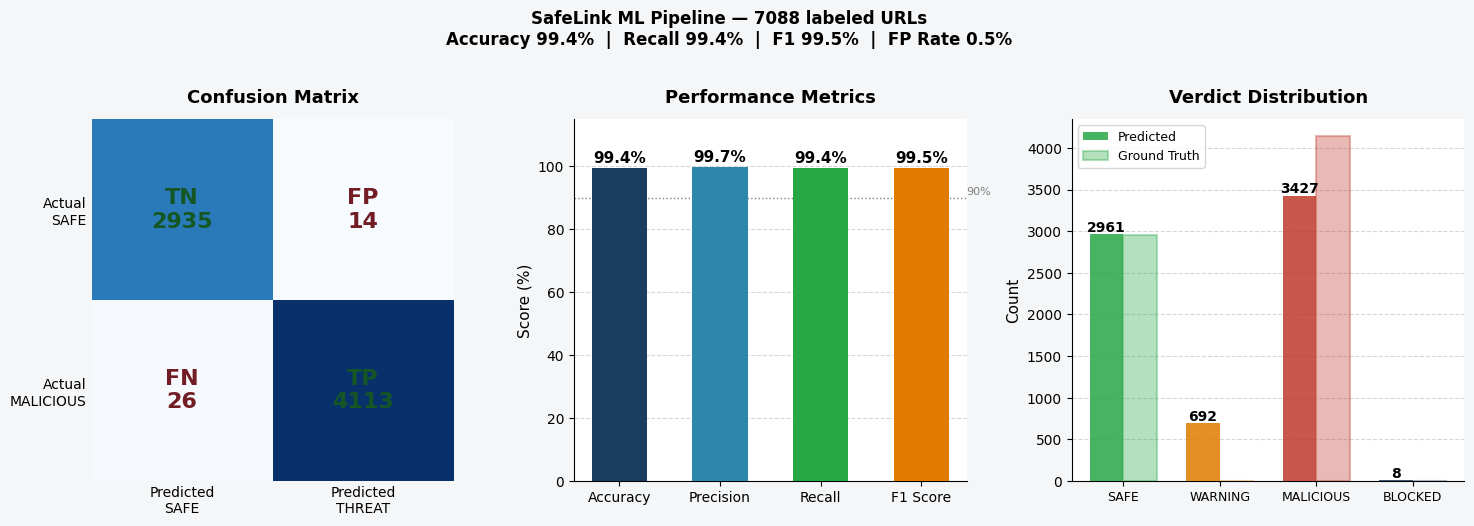

Saved → accuracy_report.png


In [19]:
# ── Cell 9: Accuracy Graphs ──────────────────────────────────────
# Requires Cell 9 to have been run first.
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#F4F6F8')

# ── 1. Confusion Matrix heatmap ───────────────────────────────────
ax1 = axes[0]
cm  = np.array([[TN, FP], [FN, TP]])
ax1.imshow(cm, cmap='Blues', vmin=0, vmax=max(TP, TN, 1))
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for r in range(2):
    for c in range(2):
        color = '#155724' if r == c else '#721c24'
        ax1.text(c, r, f'{cell_labels[r][c]}\n{cm[r,c]}',
                 ha='center', va='center', fontsize=16, fontweight='bold', color=color)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Predicted\nSAFE', 'Predicted\nTHREAT'], fontsize=10)
ax1.set_yticklabels(['Actual\nSAFE', 'Actual\nMALICIOUS'], fontsize=10)
ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
ax1.tick_params(length=0)
for spine in ax1.spines.values():
    spine.set_visible(False)

# ── 2. Metrics bar chart ──────────────────────────────────────────
ax2     = axes[1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [accuracy * 100, precision * 100, recall * 100, f1 * 100]
colors  = ['#1A3C5E', '#2E86AB', '#28A745', '#E07B00']
bars    = ax2.bar(metrics, values, color=colors, width=0.55, zorder=3)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 115)
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title('Performance Metrics', fontsize=13, fontweight='bold', pad=12)
ax2.set_facecolor('#FFFFFF')
ax2.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax2.tick_params(axis='x', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.axhline(90, color='gray', linestyle=':', linewidth=1, zorder=1)
ax2.text(3.45, 91, '90%', fontsize=8, color='gray')

# ── 3. Verdict distribution ───────────────────────────────────────
ax3 = axes[2]
verdict_counts = {}
for r in results:
    verdict_counts[r['verdict']] = verdict_counts.get(r['verdict'], 0) + 1

v_order  = ['SAFE', 'WARNING', 'MALICIOUS', 'BLOCKED']
v_labels = ['SAFE', 'WARNING', 'MALICIOUS', 'BLOCKED']
v_colors = ['#28A745', '#E07B00', '#C0392B', '#1A3C5E']
v_vals   = [verdict_counts.get(v, 0) for v in v_order]
true_vals = [n_safe, 0, n_mal, 0]

x     = np.arange(len(v_order))
width = 0.35
pred_bars = ax3.bar(x, v_vals, width, color=v_colors, alpha=0.85, label='Predicted', zorder=3)
ax3.bar(x + width, true_vals, width, color=v_colors, alpha=0.35,
        edgecolor=v_colors, linewidth=1.5, label='Ground Truth', zorder=3)
for bar, val in zip(pred_bars, v_vals):
    if val > 0:
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_xticks(x + width / 2)
ax3.set_xticklabels(v_labels, fontsize=9)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Verdict Distribution', fontsize=13, fontweight='bold', pad=12)
ax3.set_facecolor('#FFFFFF')
ax3.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.legend(fontsize=9)

plt.suptitle(
    f'SafeLink ML Pipeline — {total} labeled URLs\n'
    f'Accuracy {accuracy*100:.1f}%  |  Recall {recall*100:.1f}%  |  F1 {f1*100:.1f}%  |  FP Rate {fpr*100:.1f}%',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('accuracy_report.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved → accuracy_report.png')
